# Same Same. Validador de equivalencias de formulación en productos labiales

**Diplomado en Ciencia de Datos. Módulo 5, proyecto integrador.**
Brenda Jimena Ramírez Aguilar.

Same Same es una compañía orientada al mercado mexicano de maquillaje. Su producto responde una pregunta concreta de compra: si un labial económico que circula en redes sociales como sustituto, o *dupe*, de un labial de gama alta se parece realmente por dentro, es decir, en su fórmula. El sistema compara listas de ingredientes en nomenclatura INCI, traduce la comparación a una etiqueta en lenguaje sencillo y la acompaña de una explicación verificable en la etiqueta del producto.

Este cuaderno contiene la solución analítica completa, de la adquisición de los datos a la exportación de los artefactos que consume la interfaz de uso. Cada etapa documenta sus decisiones con la misma plantilla de seis pasos, de modo que cualquier resultado pueda rastrearse hasta el dato que lo sostiene:

1. Definición y justificación de negocio.
2. Construcción.
3. Diagnóstico.
4. Decisión de tratamiento, con el criterio explícito.
5. Aplicación.
6. Validación posterior.

| Sección | Contenido |
|---|---|
| 1 | Planteamiento del problema y estrategia |
| 2 | Configuración del entorno y reproducibilidad |
| 3 | Adquisición de datos: recolección de direcciones y extracción de listas INCI |
| 4 | Descripción de los datos y control de integridad |
| 5 | Diagnóstico de valores ausentes |
| 6 | Limpieza y construcción de la unidad de análisis |
| 7 | Análisis exploratorio univariado y bivariado |
| 8 | Valores extremos |
| 9 | Aptitud vegana derivada de la fórmula |
| 10 | Ingeniería de variables e imputación multivariada del formato |
| 11 | Capa de presentación: nombre comercial y línea |
| 12 | Verdad de referencia y bandera de trato ético |
| 13 | Modelo de similitud, selección de hiperparámetros y evaluación |
| 14 | Política de acierto por línea comercial |
| 15 | Sistema consultable: escala, etiquetas, explicación, arquetipos y flujo de inferencia |
| 16 | Precios de referencia en pesos mexicanos |
| 17 | Exportación y verificación de los artefactos de la aplicación |
| 18 | Conclusiones, recomendaciones y siguientes pasos |
| 19 | Referencias |

**Reproducibilidad.** El cuaderno se ejecuta de principio a fin en un entorno limpio de Google Colab con la opción *Entorno de ejecución, Ejecutar todas*. No requiere montar una unidad de almacenamiento, no requiere llaves de acceso a servicios externos y no instala paquetes: todas las bibliotecas que utiliza forman parte de la imagen estándar del entorno. Los datos se obtienen clonando el repositorio público del proyecto, que conserva la instantánea de la extracción y los insumos curados a mano. La extracción en vivo desde la fuente está documentada y disponible, pero desactivada por omisión mediante la constante `EJECUTAR_EXTRACCION`, porque tarda cerca de cuarenta minutos y porque las decisiones manuales documentadas se refieren a los identificadores de la instantánea versionada. Con la extracción desactivada, la ejecución completa toma pocos minutos y produce en la carpeta `salidas_same_same` todas las tablas analíticas y los artefactos de la interfaz.

## 1. Planteamiento del problema y estrategia

### 1.1 Problema

La compra de maquillaje por recomendación en redes sociales se ha vuelto el principal canal de descubrimiento para una parte importante de las consumidoras jóvenes. En la categoría de labiales, ese canal produce un fenómeno característico: la etiqueta *dupe*, que presenta un producto económico como sustituto de uno de gama alta. La etiqueta se asigna por viralidad y por parecido de tono en una fotografía, casi nunca por la composición del producto. La consumidora que decide con base en ese contenido no tiene manera de saber si el labial de ciento cincuenta pesos comparte algo más que el color con el labial de novecientos, y el costo de equivocarse se repite en cada compra.

El problema que se resuelve es la ausencia de un criterio objetivo, accesible y en español para validar esas equivalencias antes de comprar. La información necesaria existe, porque la regulación cosmética obliga a publicar la lista de ingredientes en orden decreciente de concentración, pero está escrita en nomenclatura INCI, dispersa entre marcas y es ilegible para quien compra.

### 1.2 Nicho y usuaria

| Elemento | Definición |
|---|---|
| Usuaria principal | Consumidora mexicana de maquillaje con presupuesto limitado que sigue tendencias de belleza en redes sociales y compra labiales de forma recurrente |
| Necesidad | Saber, antes de comprar, si una alternativa económica se parece por dentro al producto de gama alta que no puede o no quiere pagar |
| Momento de uso | Frente al anaquel o frente a una publicación que recomienda un sustituto |
| Diferenciación | Mercado local, precios en pesos, lenguaje sencillo en español, filtros de consumo responsable y declaración explícita de lo que el sistema no mide |
| Usuaria secundaria, siguiente etapa | Analista de producto o de categoría en una marca o un minorista, interesada en indicadores agregados de similitud, precio y posicionamiento |

### 1.3 Resolución en papel

1. Construir un catálogo de fórmulas labiales de marcas de gama alta y de gama económica con presencia en México, a partir de una fuente pública de listas INCI.
2. Separar en cada fórmula el vehículo químico, es decir aceites, ceras, emolientes y polímeros, de los pigmentos, porque el vehículo determina textura, deslizamiento y permanencia, y el pigmento solo determina el tono.
3. Representar cada vehículo con dos vectores complementarios: qué ingredientes contiene en sus primeras posiciones y cómo reparte esas posiciones entre familias funcionales.
4. Medir la semejanza entre un producto de gama alta y cada alternativa económica con una similitud del coseno híbrida, y elegir sus hiperparámetros con evidencia externa: equivalencias documentadas por la comunidad.
5. Traducir el puntaje a una etiqueta en lenguaje sencillo, calibrada contra esa misma evidencia, y acompañarla de los ingredientes compartidos que la explican.
6. Incorporar el precio de referencia en pesos para que la usuaria vea el ahorro junto con la evidencia de fórmula.

### 1.4 Accionables

| Accionable | Pregunta de la usuaria | Respuesta del sistema |
|---|---|---|
| Buscar alternativas | ¿Qué labiales económicos se parecen por dentro a este de gama alta? | Lista corta ordenada por similitud de fórmula, con filtros de formato, efecto, libre de crueldad animal y aptitud vegana |
| Validar un *dupe* | Vi en redes que este labial económico es igual a este de gama alta. ¿Lo compro? | Veredicto de compra: confirmación sobre la fórmula, compra con reservas o advertencia, con la alternativa mejor posicionada cuando el *dupe* no se sostiene |
| Comparar precio | ¿Cuánto me ahorro? | Rango de precio de referencia en pesos de ambos productos |

### 1.5 Alcance declarado

El sistema compara la base química del producto y no el color. Una etiqueta favorable significa que la fórmula respalda la equivalencia; la coincidencia de tono debe confirmarse por separado. El sistema tampoco evalúa desempeño en uso, duración real ni reacciones de la piel. Esta declaración acompaña a cada resultado de la interfaz, porque una recomendación que no declara su alcance invita a leerla como una promesa que no puede sostener.

### 1.6 Métrica de éxito

El núcleo del sistema es un motor de recuperación: ante una consulta devuelve un orden de alternativas. Su desempeño se mide con Hit Rate a cinco posiciones, que responde si la usuaria encuentra una equivalencia documentada sin desplazarse en la pantalla, y con el rango recíproco medio, que premia colocar la equivalencia correcta en los primeros lugares. Ambas métricas se comparan contra dos referencias mínimas: un orden aleatorio y un orden por popularidad que no mira la consulta.

## 2. Configuración del entorno y reproducibilidad

### 2.1 Bibliotecas

Todas las bibliotecas se importan en un solo lugar. El cuaderno emplea exclusivamente paquetes incluidos en la imagen estándar de Google Colab, de modo que no hay instalaciones que puedan fallar ni versiones que cambien entre ejecuciones por una descarga.

In [ ]:
import gzip
import hashlib
import html
import json
import math
import platform
import random
import re
import subprocess
import time
import unicodedata
from collections import Counter
from datetime import datetime, timezone
from difflib import SequenceMatcher
from pathlib import Path
from urllib.parse import urlparse
from urllib.robotparser import RobotFileParser
from xml.etree import ElementTree

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import scipy
import seaborn as sns
import sklearn
from bs4 import BeautifulSoup, Tag
from matplotlib.patches import Patch
from scipy import sparse
from scipy.stats import chi2_contingency, ks_2samp, wilcoxon
from sklearn.cluster import KMeans
from sklearn.covariance import MinCovDet
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.preprocessing import MinMaxScaler

print(pd.DataFrame([
    ("Python", platform.python_version()),
    ("pandas", pd.__version__),
    ("numpy", np.__version__),
    ("scipy", scipy.__version__),
    ("scikit-learn", sklearn.__version__),
    ("matplotlib", matplotlib.__version__),
    ("seaborn", sns.__version__),
], columns=["componente", "version"]).to_string(index=False))

  componente version
      Python 3.13.15
      pandas   2.2.3
       numpy   2.1.3
       scipy  1.16.3
scikit-learn   1.6.1
  matplotlib  3.10.0
     seaborn  0.13.2


### 2.2 Datos del repositorio y directorios de trabajo

El repositorio público del proyecto conserva dos grupos de archivos. El primero es la instantánea de la extracción, seis tablas producidas por la recolección de direcciones y por el extractor de listas INCI. El segundo son los insumos curados a mano: la lista de equivalencias documentadas por la comunidad, la tabla editorial de Temptalia, la revisión manual de los enlaces dudosos, la revisión manual de los nombres de producto y las observaciones de precio en tiendas. Ninguno de esos insumos se puede derivar por regla, y por eso se versionan como datos y no como código.

El repositorio se clona una sola vez en el directorio de trabajo. Todas las salidas se escriben en `salidas_same_same`, dividido en una carpeta analítica y una carpeta con los artefactos que consume la aplicación.

In [ ]:
URL_REPOSITORIO = "https://github.com/menabrendamena/same-same.git"
DIRECTORIO_REPOSITORIO = Path.cwd() / "same-same"

if not DIRECTORIO_REPOSITORIO.exists():
    subprocess.run(
        ["git", "clone", "--depth", "1", "--quiet", URL_REPOSITORIO, str(DIRECTORIO_REPOSITORIO)],
        check=True, capture_output=True, text=True,
    )

DIRECTORIO_SALIDA = Path.cwd() / "salidas_same_same"
DIRECTORIO_EXTRACCION = DIRECTORIO_SALIDA / "extraccion"
DIRECTORIO_ANALITICO = DIRECTORIO_SALIDA / "analitico"
DIRECTORIO_APP = DIRECTORIO_SALIDA / "app"
for carpeta in (DIRECTORIO_EXTRACCION, DIRECTORIO_ANALITICO, DIRECTORIO_APP):
    carpeta.mkdir(parents=True, exist_ok=True)


def localizar(nombre):
    """Devuelve la ruta de un archivo del repositorio, buscándolo en la carpeta de insumos curados y en la raíz."""
    for carpeta in (DIRECTORIO_REPOSITORIO / "curados", DIRECTORIO_REPOSITORIO / "datos", DIRECTORIO_REPOSITORIO):
        ruta = carpeta / nombre
        if ruta.exists():
            return ruta
    raise FileNotFoundError(f"No se encuentra {nombre} en el repositorio {DIRECTORIO_REPOSITORIO}")


ARCHIVOS_REPOSITORIO = [
    ("catalogo_urls_labiales.csv", "instantánea de la extracción"),
    ("cobertura_marcas.csv", "instantánea de la extracción"),
    ("descartes_zona_ajena.csv", "instantánea de la extracción"),
    ("productos_inci.csv", "instantánea de la extracción"),
    ("producto_ingrediente.csv", "instantánea de la extracción"),
    ("producto_funcion.csv", "instantánea de la extracción"),
    ("lista_dupes.xlsx", "insumo curado"),
    ("pares_extraccion_temptalia.xlsx", "insumo curado"),
    ("pares_enlace_pendiente_revisado.csv", "insumo curado"),
    ("revision_nombres_01b.csv", "insumo curado"),
    ("observaciones_precios.csv", "insumo curado"),
]
inventario_repositorio = pd.DataFrame([
    {"archivo": nombre, "grupo": grupo, "kb": round(localizar(nombre).stat().st_size / 1024, 1)}
    for nombre, grupo in ARCHIVOS_REPOSITORIO
])
print(f"Repositorio: {DIRECTORIO_REPOSITORIO}")
print(f"Salidas:     {DIRECTORIO_SALIDA}")
print()
print(inventario_repositorio.to_string(index=False))

Repositorio: /content/same-same
Salidas:     /content/salidas_same_same

                            archivo                        grupo     kb
         catalogo_urls_labiales.csv instantánea de la extracción  192.0
               cobertura_marcas.csv instantánea de la extracción    1.3
           descartes_zona_ajena.csv instantánea de la extracción    3.4
                 productos_inci.csv instantánea de la extracción  230.0
           producto_ingrediente.csv instantánea de la extracción 2592.7
               producto_funcion.csv instantánea de la extracción 3562.2
                   lista_dupes.xlsx                insumo curado   17.7
    pares_extraccion_temptalia.xlsx                insumo curado   17.1
pares_enlace_pendiente_revisado.csv                insumo curado    7.1
           revision_nombres_01b.csv                insumo curado    5.9
          observaciones_precios.csv                insumo curado   35.2


### 2.3 Constantes globales y bitácora de decisiones

La semilla fija todos los procesos aleatorios del cuaderno. La constante `EJECUTAR_EXTRACCION` controla si la sección 3 vuelve a descargar la fuente; con su valor por omisión, la sección documenta y verifica el procedimiento sobre la instantánea versionada sin emitir solicitudes.

La bitácora acumula, a lo largo de todas las secciones, la decisión de tratamiento tomada en cada bloque y el criterio que la justifica. Se exporta al final como una sola tabla, de modo que cualquier pregunta sobre una variable concreta se responda sin recorrer el documento.

In [ ]:
SEMILLA = 42
EJECUTAR_EXTRACCION = False

random.seed(SEMILLA)
np.random.seed(SEMILLA)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid", palette="crest")
COLOR_PRINCIPAL = "#008080"
COLOR_SECUNDARIO = "#e3b505"
COLOR_NEUTRO = "#9aa5a5"

BITACORA = []


def registrar(variable, tipo, decision, criterio, etapa):
    """Agrega una decisión de tratamiento a la bitácora del proyecto."""
    BITACORA.append({"variable": variable, "tipo": tipo, "decision": decision, "criterio": criterio, "etapa": etapa})


def exportar(tablas, directorio=DIRECTORIO_ANALITICO):
    """Escribe un diccionario de tablas en disco y devuelve su inventario."""
    inventario = []
    for nombre, tabla in tablas.items():
        ruta = directorio / nombre
        tabla.to_csv(ruta, index=False, encoding="utf-8")
        inventario.append({"archivo": nombre, "filas": len(tabla), "columnas": tabla.shape[1], "kb": round(ruta.stat().st_size / 1024, 1)})
    return pd.DataFrame(inventario)

## 3. Adquisición de datos

### 3.1 Fuente y principios de extracción

La fuente primaria de formulación es INKEEDecoder, antes INCIDecoder, una base pública que publica para cada producto su lista de ingredientes en orden de declaración, la función cosmética de cada ingrediente y una valoración editorial. Se eligió después de descartar con evidencia otras alternativas: los minoristas mexicanos no ofrecen una interfaz pública y bloquean la descarga automatizada, y las bases abiertas de productos cosméticos carecen de cobertura en gama alta.

La adquisición se organiza en dos etapas con responsabilidades separadas. La recolección delimita un universo de direcciones fijo y auditable a partir de los mapas de sitio; la extracción descarga y estructura cada página de ese universo. Ambas operan con agente de usuario identificado, respeto a las directivas de `robots.txt`, pausas aleatorias entre solicitudes y reintentos con espera exponencial, y conservan en disco todo lo descargado para que una corrección posterior del analizador no genere una sola solicitud adicional al servidor.

| Producto de la adquisición | Contenido | Granularidad |
|---|---|---|
| `catalogo_urls_labiales.csv` | Direcciones labiales con marca, gama, formato, acabado y efectos declarados | Una por dirección |
| `cobertura_marcas.csv` | Cobertura labial por marca y decisión de admisión | Una por marca |
| `descartes_zona_ajena.csv` | Registros excluidos por pertenecer a otra zona de aplicación | Uno por registro |
| `productos_inci.csv` | Metadatos del catálogo y métricas de extracción | Una por dirección |
| `producto_ingrediente.csv` | Ingredientes con posición, grupo y calificación editorial | Uno por par dirección e ingrediente |
| `producto_funcion.csv` | Ingredientes clasificados por función cosmética | Uno por dirección, función e ingrediente |

### 3.2 Alcance: marcas, gama y patrones de identificador

El diccionario `MARCAS` asigna a cada marca tres atributos:

* **Gama comercial.** Se define por canal de distribución y no por precio. La gama alta corresponde a distribución selectiva, es decir perfumería, tienda departamental y cadenas especializadas de prestigio; la gama económica corresponde a distribución masiva, es decir farmacia, autoservicio y comercio general. El criterio es observable, estable en el tiempo e independiente del precio, que se incorpora después como atributo y no como definición.
* **Origen.** Distingue el núcleo del comparador de las marcas de ampliación, incorporadas para aumentar la presencia de productos de consulta con evidencia documental de sustitutos. Las marcas de ampliación solo se admiten si la fuente ofrece cobertura suficiente.
* **Patrones de identificador.** La fuente registra una misma marca bajo más de una forma. Asumir una sola forma produce una pérdida silenciosa de catálogo, sin error visible y con cifras que parecen plausibles.

`PREFIJOS_EXCLUIDOS` retira submarcas que comparten raíz con una marca del alcance pero pertenecen a otra categoría de negocio, como líneas capilares profesionales o de cuidado de la piel.

In [ ]:
SITIO = "https://inkeedecoder.com"
INDICE_SITEMAP = f"{SITIO}/sitemap-index.xml"
UMBRAL_COBERTURA_MARCA = 15

MARCAS = {
    "benefit": ("alta", "nucleo", ["benefit"]),
    "charlotte-tilbury": ("alta", "nucleo", ["charlotte-tilbury"]),
    "dior": ("alta", "nucleo", ["dior"]),
    "mac": ("alta", "nucleo", ["mac", "m-a-c"]),
    "too-faced": ("alta", "nucleo", ["too-faced"]),
    "chanel": ("alta", "ampliacion", ["chanel"]),
    "clinique": ("alta", "ampliacion", ["clinique"]),
    "fenty-beauty": ("alta", "ampliacion", ["fenty-beauty", "fenty"]),
    "laneige": ("alta", "ampliacion", ["laneige"]),
    "nars": ("alta", "ampliacion", ["nars"]),
    "yves-saint-laurent": ("alta", "ampliacion", ["yves-saint-laurent", "ysl"]),
    "catrice": ("economica", "nucleo", ["catrice"]),
    "essence": ("economica", "nucleo", ["essence"]),
    "kiko": ("economica", "nucleo", ["kiko"]),
    "loreal": ("economica", "nucleo", ["loreal", "l-oreal"]),
    "maybelline": ("economica", "nucleo", ["maybelline"]),
    "milani": ("economica", "nucleo", ["milani"]),
    "nyx": ("economica", "nucleo", ["nyx"]),
    "revolution": ("economica", "nucleo", ["revolution", "makeup-revolution"]),
    "wet-n-wild": ("economica", "nucleo", ["wet-n-wild", "wet-wild"]),
    "elf": ("economica", "ampliacion", ["elf", "e-l-f"]),
    "revlon": ("economica", "ampliacion", ["revlon"]),
}

PREFIJOS_EXCLUIDOS = (
    "fenty-skin", "fenty-hair", "fenty-fragrance", "fenty-eau",
    "revlon-professional", "revlon-colorsilk", "revlon-uniq-one",
    "loreal-professionnel-hair", "elf-skin",
)

GAMAS = {marca: gama for marca, (gama, _, _) in MARCAS.items()}
PATRONES = sorted(
    ((patron, marca) for marca, (_, _, patrones) in MARCAS.items() for patron in patrones),
    key=lambda par: len(par[0]),
    reverse=True,
)

resumen_alcance = pd.DataFrame(
    [(marca, gama, origen) for marca, (gama, origen, _) in MARCAS.items()],
    columns=["marca", "gama", "origen"],
)
print(f"Marcas en el alcance inicial: {len(MARCAS)}")
print(f"Patrones de identificador registrados: {len(PATRONES)}")
print()
print(pd.crosstab(resumen_alcance["gama"], resumen_alcance["origen"], margins=True, margins_name="Total").to_string())

Marcas en el alcance inicial: 22
Patrones de identificador registrados: 29

origen     ampliacion  nucleo  Total
gama                                
alta                6       5     11
economica           2       9     11
Total               8      14     22


### 3.3 Taxonomía labial

**Identificación de marca.** La marca se resuelve sobre el segmento final de la ruta y exige coincidencia exacta o coincidencia seguida de guion. Una comparación por subcadena asignaría a la marca `mac` cualquier identificador que comience con esas tres letras. Los patrones se evalúan de mayor a menor longitud para que un identificador compuesto se resuelva antes que uno corto contenido en él.

**Pertenencia a la categoría.** Se evalúa sobre los tokens del identificador y no sobre la cadena completa, porque la secuencia `lip` aparece dentro de palabras ajenas a la categoría. La detección opera con tres niveles de evidencia, en orden de fuerza:

| Nivel | Criterio | Ejemplo |
|---|---|---|
| `linea` | Línea comercial labial reconocida, aunque el nombre no declare la zona | `superstay-matte-ink` |
| `explicita` | Token labial directo o token que inicia con `lip` y no es un falso prefijo | `lipstick`, `lipglass` |
| `contextual` | Marcador polisémico sin zona competidora declarada | `gloss`, `rouge` |

**Formato.** Describe el vehículo físico del producto y no la promesa de efecto; por eso los voluminizadores no son un formato. La asignación sigue una jerarquía de evidencia: excepciones documentadas, vehículos no comparables, barra explícita, línea comercial reconocida y, al final, prioridad por vehículo. Los productos sin regla aplicable se etiquetan como `no_determinado` y su formato se resuelve después a partir de la fórmula, porque no se infiere del nombre lo que se puede medir en la composición.

**Acabado y efectos.** Son atributos declarados por nomenclatura comercial y no verificados. La presencia de un token es evidencia razonable de que el atributo existe; su ausencia no demuestra que no exista, porque depende de la política de nombres de cada marca.

**Veto por zona ajena.** Los marcadores contextuales `gloss` y `lacquer` atraviesan esmaltes, tratamientos capilares y labiales. El veto se aplica únicamente cuando la detección no es explícita: la palabra *lip* en el nombre es evidencia directa del fabricante y prevalece.

In [ ]:
TOKENS_LABIALES = {
    "lip", "lips", "lipstick", "lipsticks", "lipgloss", "lipglass", "lipliner",
    "lipbalm", "lipstain", "liptint", "lipcolor", "lipcolour", "lipcream",
    "lipoil", "lipcare", "lipscrub", "lipmask", "pintalabios", "pout", "pouts",
}
PREFIJOS_LIP_FALSOS = {
    "lipid", "lipids", "lipidium", "lipidic", "liposome", "liposomes", "lipase",
    "lipoic", "lipoamino", "lipo", "lipophilic", "lipoprotein", "lipolysis",
}
MARCADORES_CONTEXTUALES = {"gloss", "lacquer", "plumper", "plumpgasm", "rouge"}
LINEAS_LABIALES = {
    "superstay-matte-ink": "liquido",
    "super-stay-matte-ink": "liquido",
    "rouge-signature": "liquido",
    "matte-resistance": "liquido",
    "shine-loud": "liquido",
    "matte-revolution": "barra",
    "color-riche": "barra",
    "colour-riche": "barra",
    "butter-gloss": "gloss",
}
LINEAS_SOLO_DETECCION = {
    "juicy-bomb-glossy-butter-balm", "baby-got-glaze", "powder-kiss",
    "coloured-balm", "lifter-plump", "lifter-glaze",
    "super-stay-teddy-tint", "super-stay-ink-crayon",
    "kiss-baume", "colorstay-moisture-stain", "kissing-juicy-tint",
    "megaslicks-balm-stain", "keep-it-full-glossy-plumping-balm",
    "lasting-kiss-liquid-matte-stain", "candy-glow-tinted-butter-balm",
    "gogo-tint", "love-tint",
}
ZONAS_COMPETIDORAS = {
    "eye", "eyes", "eyeshadow", "eyeliner", "eyebrow", "mascara", "brow",
    "lash", "lashes", "nail", "nails", "hair", "shampoo", "body", "hand",
    "foot", "feet", "face", "facial", "foundation", "concealer", "blush",
    "highlighter", "cheek", "cheeks", "skin", "cleanser", "toner", "deodorant",
    "perfume", "fragrance", "sunscreen", "shower", "bath",
}


def obtener_slug(url):
    return urlparse(url).path.rstrip("/").split("/")[-1].lower()


def identificar_marca(slug):
    if slug.startswith(PREFIJOS_EXCLUIDOS):
        return None, None
    for patron, marca in PATRONES:
        if slug == patron or slug.startswith(patron + "-"):
            return marca, patron
    return None, None


def remover_marca(slug, patron):
    if patron and slug.startswith(patron + "-"):
        return slug[len(patron) + 1:]
    return slug


def detectar_labial(descriptor, tokens):
    conjunto = set(tokens)
    if any(linea in descriptor for linea in LINEAS_LABIALES):
        return "linea"
    if any(linea in descriptor for linea in LINEAS_SOLO_DETECCION):
        return "linea"
    if conjunto & TOKENS_LABIALES:
        return "explicita"
    if any(t.startswith("lip") and t not in PREFIJOS_LIP_FALSOS for t in conjunto):
        return "explicita"
    if conjunto & ZONAS_COMPETIDORAS:
        return None
    if conjunto & MARCADORES_CONTEXTUALES:
        return "contextual"
    return None


EXCEPCIONES_FORMATO = {
    "colorburst-lip-butter": "barra",
    "lip-butter-lipstick": "barra",
    "super-stay-ink-crayon": "barra",
    "locked-kiss-ink": "liquido",
}
REGLAS_NO_COMPARABLES = [
    ("exfoliante", {"scrub", "scrubs", "scrubtious", "exfoliant", "exfoliating", "exfoliator", "scrubstick"}),
    ("mascarilla", {"mask", "masks", "masque", "sleeping"}),
    ("prebase", {"primer", "prep"}),
    ("desmaquillante", {"remover", "cleansing"}),
    ("paleta", {"palette", "pallete", "quad"}),
    ("kit", {"kit", "set", "duo", "trio", "bundle", "collection"}),
]
TOKENS_BARRA_EXPLICITA = {"lipstick", "lipsticks"}
TOKENS_LIQUIDO_FUERTE = {"liquid", "paint", "mousse"}
TOKENS_TRAZO = {"crayon", "pencil", "pen"}
TOKENS_ACEITE = {"oil", "oils", "lipoil"}
TOKENS_BALSAMO = {"balm", "lipbalm", "butter", "salve"}
TOKENS_TRATAMIENTO = {"conditioner", "treatment", "serum", "care", "caring"}
REGLAS_FORMATO = [
    ("delineador", {"liner", "lipliner", "definer", "pencil", "pen", "crayon", "contour"}),
    ("cushion", {"cushion"}),
    ("gloss", {"gloss", "lipgloss", "lipglass", "lacquer", "glaze", "varnish", "lustre"}),
    ("tinte", {"stain", "lipstain", "tint", "liptint", "tattoo", "marker"}),
    ("liquido", {"liquid", "ink", "paint", "cream", "creme", "lipcream", "mousse"}),
    ("barra", {"lipstick", "lipsticks", "bullet", "stick", "rouge", "color", "colour"}),
    ("polvo", {"powder"}),
]
FORMATOS_FUERA_DE_ALCANCE = {nombre for nombre, _ in REGLAS_NO_COMPARABLES}


def clasificar_formato(producto_base, tokens_base):
    conjunto = set(tokens_base)
    for clave, formato in EXCEPCIONES_FORMATO.items():
        if clave in producto_base:
            return formato
    for nombre, marcadores in REGLAS_NO_COMPARABLES:
        if conjunto & marcadores:
            return nombre
    if conjunto & TOKENS_BARRA_EXPLICITA:
        if conjunto & TOKENS_LIQUIDO_FUERTE and not conjunto & TOKENS_TRAZO:
            return "liquido"
        return "barra"
    if "stick" in conjunto and conjunto & TOKENS_ACEITE and not conjunto & TOKENS_TRAZO:
        return "barra"

    hay_aceite = bool(conjunto & TOKENS_ACEITE)
    hay_balsamo = bool(conjunto & TOKENS_BALSAMO)
    vehiculos = {n for n, m in REGLAS_FORMATO if conjunto & m}
    if hay_aceite:
        vehiculos.add("aceite")
    if hay_balsamo:
        vehiculos.add("balsamo")

    for linea, formato in LINEAS_LABIALES.items():
        if linea in producto_base:
            propios = set(tokens_base) - set(linea.split("-"))
            vehiculos_propios = {n for n, m in REGLAS_FORMATO if propios & m}
            if not vehiculos_propios or formato in vehiculos_propios:
                return formato

    if "delineador" in vehiculos:
        return "delineador"
    if hay_aceite and hay_balsamo:
        return "balsamo_con_aceite"
    if hay_aceite:
        return "aceite"
    if hay_balsamo:
        return "balsamo"
    for nombre in ("cushion", "gloss", "tinte", "liquido"):
        if nombre in vehiculos:
            return nombre
    if conjunto & TOKENS_TRATAMIENTO:
        return "balsamo"
    for nombre in ("barra", "polvo"):
        if nombre in vehiculos:
            return nombre
    return "no_determinado"


REGLAS_ACABADO = [
    ("vinilo", {"vinyl", "patent", "lacquered"}),
    ("glitter", {"glitter", "glittery", "sparkle", "sparkling", "diamond"}),
    ("metalico", {"metallic", "metal", "chrome", "foil"}),
    ("perlado", {"pearl", "pearly", "nacre", "iridescent", "duochrome", "shimmer"}),
    ("blur", {"blur", "blurring", "blurred", "airbrush"}),
    ("jelly", {"jelly", "gel"}),
    ("mate", {"matte", "mat", "matt", "velvet", "velvety", "suede", "powdery"}),
    ("satinado", {"satin", "silk", "silky"}),
    ("brillante", {"gloss", "glossy", "shine", "shiny", "shining", "glaze", "glow"}),
    ("cremoso", {"cream", "creamy", "creme", "butter", "buttery", "velour"}),
]
REGLAS_EFECTO = {
    "voluminizador": {
        "plump", "plumping", "plumper", "plumpgasm", "booster", "volumizing",
        "volume", "injection", "maximizer", "max", "maxxx", "pump", "fake",
    },
    "larga_duracion": {
        "longwear", "long", "last", "lasting", "superstay", "stay", "forever",
        "endless", "infallible", "fix", "lock", "put", "8h", "8hr",
    },
    "transfer_proof": {"transferproof", "transfer", "kissproof", "smudgeproof"},
    "resistente_agua": {"waterproof", "waterresistant"},
    "hidratante": {
        "hydrating", "hydra", "hydration", "hydrate", "moisturizing",
        "moisturising", "nourishing", "juicy", "melt", "jam",
    },
    "reparador": {"repair", "repairing", "recovery", "regenerating", "restoring", "overnight"},
    "proteccion_solar": {"spf", "sunscreen", "uv", "protect", "protector"},
}
ZONAS_FUERA_DE_ALCANCE = {
    "body", "hand", "hands", "foot", "feet", "skin", "hair", "nail", "nails",
    "eye", "eyes", "eyeshadow", "eyeliner", "mascara", "brow", "brows", "lash",
    "lashes", "blush", "bronzer", "foundation", "concealer", "highlighter",
}
PATRON_TONO = re.compile(r"^\d{2,4}$")


def clasificar_acabado(tokens_base):
    conjunto = set(tokens_base)
    for nombre, marcadores in REGLAS_ACABADO:
        if conjunto & marcadores:
            return nombre
    return "no_declarado"


def separar_variante(tokens):
    for indice, token in enumerate(tokens):
        if indice >= 1 and PATRON_TONO.match(token):
            return "-".join(tokens[:indice]), "-".join(tokens[indice:])
    return "-".join(tokens), None


RAICES_NO_LABIALES = (
    "nail", "top-coat", "base-coat", "manicure",
    "hair", "shampoo", "conditioner", "acondicionador", "scalp",
    "casting-creme", "elvive", "elseve", "glycolic", "nutri-gloss",
    "le-color-gloss", "lamination", "anti-frizz",
    "blush", "cheek", "bronzer", "highlighter",
    "eyeshadow", "eyeliner", "mascara", "brow", "lash",
    "body-", "hand-", "foot-", "shower", "deodorant", "perfume",
    "professional-hair", "colorsilk",
    "-or-rouge", "camelia-rouge",
)
TOKENS_EXENTOS_VETO = {"flash", "brown"}


def hay_zona_ajena(slug):
    depurado = "-".join(t for t in slug.split("-") if t not in TOKENS_EXENTOS_VETO)
    return any(raiz in depurado for raiz in RAICES_NO_LABIALES)


def clasificar_direccion(url):
    """Aplica la taxonomía completa a una dirección y devuelve su registro, o None si no es labial."""
    slug = obtener_slug(url)
    marca, patron = identificar_marca(slug)
    if marca is None:
        return None
    descriptor = remover_marca(slug, patron)
    tokens = descriptor.split("-")
    deteccion = detectar_labial(descriptor, tokens)
    if deteccion is None:
        return None
    producto_base, variante = separar_variante(tokens)
    tokens_base = set(producto_base.split("-"))
    formato = clasificar_formato(producto_base, tokens_base)
    registro = {
        "url": url,
        "slug": slug,
        "producto_base": producto_base,
        "variante": variante,
        "marca": marca,
        "gama": GAMAS[marca],
        "deteccion": deteccion,
        "formato": formato,
        "acabado": clasificar_acabado(tokens_base),
        "zonas_adicionales": "|".join(sorted(tokens_base & ZONAS_COMPETIDORAS)),
        "en_alcance": bool(formato not in FORMATOS_FUERA_DE_ALCANCE and not tokens_base & ZONAS_FUERA_DE_ALCANCE),
    }
    for efecto, marcadores in REGLAS_EFECTO.items():
        registro[f"efecto_{efecto}"] = bool(tokens_base & marcadores)
    return registro

### 3.4 Recolección de direcciones

El índice de mapas de sitio no contiene direcciones de producto sino referencias a los archivos que sí las contienen, de modo que la consolidación ocurre en dos niveles. Cada archivo descargado se conserva en disco y una segunda ejecución lo lee desde ahí. Algunos mapas contienen caracteres que invalidan el XML; en ese caso la lectura estructurada se sustituye por una extracción por patrón de las etiquetas de localización y el archivo queda registrado.

Sobre el universo resultante se aplican en cascada el filtro de marca, la taxonomía labial y el veto por zona ajena. Una marca de ampliación con menos de `UMBRAL_COBERTURA_MARCA` productos base comparables no sostiene pares de referencia ni un vecindario de búsqueda informativo, y se retira; las marcas del núcleo se conservan con independencia de su cobertura, porque su presencia responde a la definición del comparador.

In [ ]:
ENCABEZADOS_SITEMAP = {
    "User-Agent": "SameSame/1.0 (proyecto academico de ciencia de datos)",
    "Accept": "application/xml, text/xml, */*",
}
DIRECTORIO_SITEMAPS = DIRECTORIO_EXTRACCION / "sitemaps"
PATRON_LOCALIZACION = re.compile(rb"<loc>(.*?)</loc>", re.DOTALL)
ETIQUETA_LOC = "{http://www.sitemaps.org/schemas/sitemap/0.9}loc"


def descargar_sitemap(url, reintentos=3, tiempo_limite=20):
    for intento in range(1, reintentos + 1):
        try:
            respuesta = requests.get(url, headers=ENCABEZADOS_SITEMAP, timeout=tiempo_limite)
            respuesta.raise_for_status()
            return respuesta.content
        except requests.RequestException:
            if intento == reintentos:
                raise
            time.sleep(2 ** intento)


def obtener_sitemap(url):
    DIRECTORIO_SITEMAPS.mkdir(parents=True, exist_ok=True)
    destino = DIRECTORIO_SITEMAPS / (Path(urlparse(url).path).name or "sitemap.xml")
    if destino.exists():
        contenido = destino.read_bytes()
    else:
        contenido = descargar_sitemap(url)
        destino.write_bytes(contenido)
        time.sleep(random.uniform(1.0, 2.0))
    return gzip.decompress(contenido) if destino.name.endswith(".gz") else contenido


def leer_localizaciones(contenido_xml, malformados=None, origen=None):
    try:
        raiz = ElementTree.fromstring(contenido_xml)
        return [nodo.text.strip() for nodo in raiz.iter(ETIQUETA_LOC) if nodo.text]
    except ElementTree.ParseError as error:
        if malformados is not None:
            malformados.append((origen, str(error)))
        return [
            html.unescape(coincidencia.decode("utf-8", errors="replace")).strip()
            for coincidencia in PATRON_LOCALIZACION.findall(contenido_xml)
        ]


def recolectar_direcciones():
    malformados = []
    indice = leer_localizaciones(obtener_sitemap(INDICE_SITEMAP))
    archivos_producto = [u for u in indice if "product" in u.lower()]
    direcciones = set()
    for url_sitemap in archivos_producto:
        direcciones.update(leer_localizaciones(obtener_sitemap(url_sitemap), malformados, url_sitemap))
    print(f"Archivos del índice: {len(indice)}; archivos de producto: {len(archivos_producto)}")
    print(f"Direcciones de producto únicas: {len(direcciones)}; archivos leídos por patrón: {len(malformados)}")
    return sorted(direcciones)


def construir_catalogo(direcciones):
    conteo_total = Counter()
    conteo_aproximado = Counter()
    registros = []
    for url in direcciones:
        slug = obtener_slug(url)
        marca, _ = identificar_marca(slug)
        if marca is None:
            continue
        conteo_total[marca] += 1
        if any(raiz in slug for raiz in ("lip", "rouge", "gloss")):
            conteo_aproximado[marca] += 1
        registro = clasificar_direccion(url)
        if registro is not None:
            registros.append(registro)
    catalogo = pd.DataFrame(registros)

    veto = (catalogo["deteccion"] != "explicita") & catalogo["slug"].map(hay_zona_ajena)
    descartes = catalogo.loc[veto, ["slug", "marca", "deteccion", "formato"]]
    catalogo = catalogo.loc[~veto].reset_index(drop=True)

    cobertura = resumen_alcance.assign(
        productos_totales=resumen_alcance["marca"].map(conteo_total),
        labiales_aproximados=resumen_alcance["marca"].map(conteo_aproximado),
        labiales_detectados=resumen_alcance["marca"].map(catalogo.groupby("marca").size()),
        productos_base_en_alcance=resumen_alcance["marca"].map(
            catalogo.loc[catalogo["en_alcance"]].groupby("marca")["producto_base"].nunique()
        ),
    ).sort_values(["gama", "labiales_aproximados"], ascending=[True, False])
    cobertura["admitida"] = cobertura["origen"].eq("nucleo") | cobertura["productos_base_en_alcance"].ge(UMBRAL_COBERTURA_MARCA)
    cobertura["observacion"] = "admitida"
    cobertura.loc[cobertura["origen"].eq("nucleo") & cobertura["productos_base_en_alcance"].lt(UMBRAL_COBERTURA_MARCA), "observacion"] = "nucleo con cobertura limitada"
    cobertura.loc[~cobertura["admitida"], "observacion"] = "retirada por cobertura insuficiente"

    retiradas = cobertura.loc[~cobertura["admitida"], "marca"].tolist()
    catalogo = catalogo.loc[~catalogo["marca"].isin(retiradas)]
    columnas_efecto = [c for c in catalogo.columns if c.startswith("efecto_") and catalogo[c].nunique() > 1]
    columnas = ["url", "slug", "producto_base", "variante", "marca", "gama", "deteccion", "formato",
                "acabado", "zonas_adicionales", "en_alcance"] + columnas_efecto
    catalogo = catalogo[columnas].sort_values(["gama", "marca", "slug"]).reset_index(drop=True)
    return catalogo, descartes, cobertura


if EJECUTAR_EXTRACCION:
    direcciones_producto = recolectar_direcciones()
    catalogo_vivo, descartes_vivo, cobertura_vivo = construir_catalogo(direcciones_producto)
    exportar({
        "catalogo_urls_labiales.csv": catalogo_vivo,
        "descartes_zona_ajena.csv": descartes_vivo,
        "cobertura_marcas.csv": cobertura_vivo,
    }, DIRECTORIO_EXTRACCION)
    print(f"Direcciones labiales recolectadas en esta ejecución: {len(catalogo_vivo)}")
else:
    print("Recolección en vivo desactivada. Se trabaja sobre la instantánea versionada de la adquisición.")

Recolección en vivo desactivada. Se trabaja sobre la instantánea versionada de la adquisición.


### 3.5 Verificación de la taxonomía sobre la instantánea versionada

La instantánea del catálogo se produjo con la misma taxonomía declarada arriba. La prueba de que así fue no se argumenta: se aplica la taxonomía a cada dirección de la instantánea y se compara, columna por columna, contra lo que quedó registrado. Una sola discrepancia indicaría que el catálogo y el código que lo documenta divergieron.

In [ ]:
catalogo_urls = pd.read_csv(localizar("catalogo_urls_labiales.csv"))
cobertura_marcas = pd.read_csv(localizar("cobertura_marcas.csv"))
descartes_zona = pd.read_csv(localizar("descartes_zona_ajena.csv"))

reclasificado = pd.DataFrame([clasificar_direccion(url) for url in catalogo_urls["url"]])
COLUMNAS_TAXONOMIA = [c for c in catalogo_urls.columns if c not in ("url",)]
coincidencia_taxonomia = pd.DataFrame({
    "columna": COLUMNAS_TAXONOMIA,
    "coincidencias": [
        int((reclasificado[c].fillna("").astype(str) == catalogo_urls[c].fillna("").astype(str)).sum())
        for c in COLUMNAS_TAXONOMIA
    ],
})
coincidencia_taxonomia["proporcion"] = coincidencia_taxonomia["coincidencias"] / len(catalogo_urls)

assert catalogo_urls["url"].is_unique, "La instantánea contiene direcciones duplicadas"
assert coincidencia_taxonomia["proporcion"].eq(1.0).all(), "La taxonomía no reproduce la instantánea versionada"
print(f"Direcciones en la instantánea: {len(catalogo_urls)}")
print(f"Dentro del alcance de comparación: {int(catalogo_urls['en_alcance'].sum())}")
print()
print(coincidencia_taxonomia.to_string(index=False))

Direcciones en la instantánea: 797
Dentro del alcance de comparación: 702

                columna  coincidencias  proporcion
                   slug            797         1.0
          producto_base            797         1.0
               variante            797         1.0
                  marca            797         1.0
                   gama            797         1.0
              deteccion            797         1.0
                formato            797         1.0
                acabado            797         1.0
      zonas_adicionales            797         1.0
             en_alcance            797         1.0
   efecto_voluminizador            797         1.0
  efecto_larga_duracion            797         1.0
  efecto_transfer_proof            797         1.0
 efecto_resistente_agua            797         1.0
      efecto_hidratante            797         1.0
       efecto_reparador            797         1.0
efecto_proteccion_solar            797         1.0


**Admisión de marcas y veto por zona ajena.** La tabla de cobertura documenta la decisión de admisión con la taxonomía completa: dos marcas de ampliación, Yves Saint Laurent y NARS, quedan por debajo del umbral y se retiran; Benefit y Too Faced pertenecen al núcleo y se conservan con cobertura limitada, lo que se declara como limitación de la fuente. Los registros vetados por zona ajena se conservan en disco para que la exclusión sea auditable.

In [ ]:
print(cobertura_marcas[["marca", "gama", "origen", "productos_totales", "labiales_detectados",
                        "productos_base_en_alcance", "observacion"]].to_string(index=False))
print()
print(f"Registros vetados por zona ajena: {len(descartes_zona)}")
print(descartes_zona.groupby("marca").size().sort_values(ascending=False).to_string())

             marca      gama     origen  productos_totales  labiales_detectados  productos_base_en_alcance                         observacion
           laneige      alta ampliacion                224                   36                         17                            admitida
              dior      alta     nucleo                235                   29                         25                            admitida
               mac      alta     nucleo                179                   30                         27                            admitida
yves-saint-laurent      alta ampliacion                 94                   15                         13 retirada por cobertura insuficiente
 charlotte-tilbury      alta     nucleo                105                   22                         18                            admitida
          clinique      alta ampliacion                371                   21                         17                            admitida

**Auditoría de cobertura.** Antes de autorizar la extracción masiva se revisan la distribución por nivel de detección, el reparto de formatos por marca y la prevalencia declarada de acabados y efectos. Una tasa anómala en cualquiera de ellas indicaría patrones de identificador incorrectos o una taxonomía demasiado laxa.

In [ ]:
en_alcance_urls = catalogo_urls.loc[catalogo_urls["en_alcance"]]
columnas_efecto_catalogo = [c for c in catalogo_urls.columns if c.startswith("efecto_")]

print("Nivel de detección")
print(catalogo_urls["deteccion"].value_counts().to_string())
print()
print("Formato por gama y marca, direcciones dentro del alcance")
print(pd.crosstab([en_alcance_urls["gama"], en_alcance_urls["marca"]], en_alcance_urls["formato"],
                  margins=True, margins_name="Total").to_string())
print()
print("Prevalencia declarada de efectos")
print(en_alcance_urls[columnas_efecto_catalogo].sum().sort_values(ascending=False).to_string())

Nivel de detección
deteccion
explicita     725
linea          43
contextual     29

Formato por gama y marca, direcciones dentro del alcance
formato                      aceite  balsamo  balsamo_con_aceite  barra  cushion  delineador  gloss  liquido  no_determinado  tinte  Total
gama      marca                                                                                                                           
alta      benefit                 0        1                   0      0        0           0      0        0               0      5      6
          chanel                  0        5                   0      9        0           0      1        3               0      0     18
          charlotte-tilbury       1        0                   0      6        0           2      2        0               7      0     18
          clinique                1        6                   0      5        0           0      2        0               3      0     17
          dior           

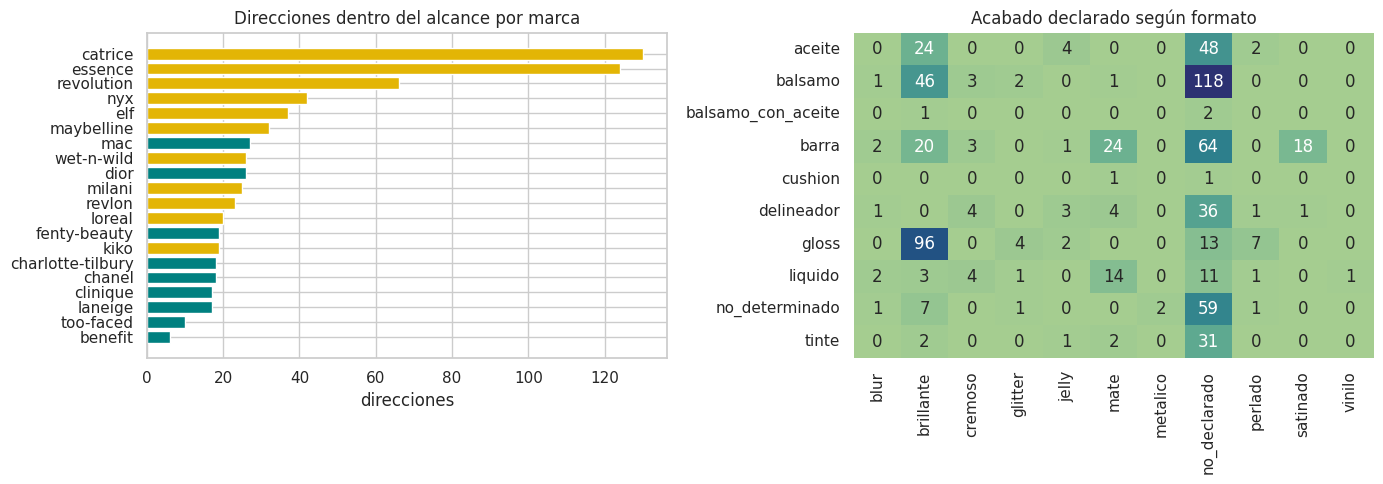

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
orden_marcas = en_alcance_urls.groupby("marca").size().sort_values(ascending=True)
colores_marca = [COLOR_PRINCIPAL if GAMAS[m] == "alta" else COLOR_SECUNDARIO for m in orden_marcas.index]
ejes[0].barh(orden_marcas.index, orden_marcas.to_numpy(), color=colores_marca)
ejes[0].set_title("Direcciones dentro del alcance por marca")
ejes[0].set_xlabel("direcciones")
sns.heatmap(pd.crosstab(en_alcance_urls["formato"], en_alcance_urls["acabado"]), annot=True, fmt="d",
            cmap="crest", cbar=False, ax=ejes[1])
ejes[1].set_title("Acabado declarado según formato")
ejes[1].set_xlabel("")
ejes[1].set_ylabel("")
fig.tight_layout()
plt.show()

### 3.6 Extracción de listas INCI

La página de producto expone cuatro componentes con selectores estables: marca, nombre, lista INCI y funciones cosméticas. La lista se recorre en orden de documento, lo que permite separar el bloque «May Contain», que agrupa los colorantes que pueden estar presentes según el tono, sin depender de que ese bloque tenga un contenedor propio. Cuando una página declara más de una fórmula, cada ingrediente registra el ordinal del grupo más interno que lo contiene.

La regulación cosmética exige declarar los ingredientes en orden decreciente de concentración, al menos para los presentes por encima del uno por ciento. La posición es, por tanto, un indicador ordinal de proporción en la fórmula y se conserva como variable.

| Parámetro de cortesía | Valor | Justificación |
|---|---|---|
| Pausa entre solicitudes | Uniforme entre 1.5 y 3.0 s | El componente aleatorio evita un patrón periódico y reparte la carga |
| Tiempo de espera | 15 s | Acota el bloqueo ante una respuesta que nunca llega |
| Intentos por dirección | 4 | Absorben fallas transitorias sin insistir indefinidamente |
| Espera entre intentos | 5 · 2^(k−1) s más ruido | Cada reintento concede al servidor el doble de tiempo; si declara `Retry-After`, prevalece |
| Fallos consecutivos tolerados | 10 | Una racha de fallos indica bloqueo o caída del sitio |
| Códigos transitorios | 408, 425, 429, 5xx | Describen saturación temporal y justifican el reintento |

Cada página se escribe primero en un archivo temporal y después se renombra, operación atómica que impide dejar en disco un archivo truncado. La bitácora de descargas se abre en modo de anexión y se vacía tras cada evento. Antes de la corrida completa, una prueba de humo sobre dos productos de estructura verificada detecta cualquier cambio de plantilla con dos solicitudes y no con setecientas.

In [ ]:
ENCABEZADOS_PRODUCTO = {
    "User-Agent": "SameSame-Academic/1.0 (Diplomado en Ciencia de Datos, FES Acatlan, UNAM)",
    "Accept": "text/html,application/xhtml+xml",
    "Accept-Language": "en-US,en;q=0.9",
}
PAUSA_MINIMA, PAUSA_MAXIMA = 1.5, 3.0
TIEMPO_ESPERA = 15
MAX_INTENTOS = 4
ESPERA_BASE = 5
MAX_FALLOS_CONSECUTIVOS = 10
CODIGOS_TRANSITORIOS = {408, 425, 429, 500, 502, 503, 504}
DIRECTORIO_HTML = DIRECTORIO_EXTRACCION / "html"
RUTA_BITACORA_DESCARGAS = DIRECTORIO_EXTRACCION / "bitacora_descargas.jsonl"
SLUGS_REFERENCIA = ["dior-rouge-dior-lipstick", "nyx-professional-makeup-butter-gloss-non-sticky-lip-gloss"]
CORRECCIONES_MARCA = {"benefit-hangover-pillow-balm-lip-treatment": "too-faced"}
PATRON_PUEDE_CONTENER = re.compile(r"may\s*contain", re.IGNORECASE)


def ruta_cache(slug):
    return DIRECTORIO_HTML / f"{slug}.html.gz"


def guardar_html(slug, contenido):
    DIRECTORIO_HTML.mkdir(parents=True, exist_ok=True)
    destino = ruta_cache(slug)
    temporal = destino.with_name(destino.name + ".tmp")
    with gzip.open(temporal, "wt", encoding="utf-8") as archivo:
        archivo.write(contenido)
    temporal.replace(destino)


def leer_html(slug):
    with gzip.open(ruta_cache(slug), "rt", encoding="utf-8") as archivo:
        return archivo.read()


def registrar_evento(evento):
    evento = {**evento, "marca_tiempo": datetime.now(timezone.utc).isoformat(timespec="seconds")}
    with open(RUTA_BITACORA_DESCARGAS, "a", encoding="utf-8") as archivo:
        archivo.write(json.dumps(evento, ensure_ascii=False) + "\n")
        archivo.flush()


def leer_bitacora_descargas():
    if not RUTA_BITACORA_DESCARGAS.exists() or RUTA_BITACORA_DESCARGAS.stat().st_size == 0:
        return pd.DataFrame(columns=["url", "slug", "estado", "codigo_http", "intentos", "error"])
    return pd.read_json(RUTA_BITACORA_DESCARGAS, lines=True)


def calcular_espera(intento, respuesta=None):
    if respuesta is not None:
        indicada = respuesta.headers.get("Retry-After", "").strip()
        if indicada.isdigit():
            return float(indicada)
    return ESPERA_BASE * 2 ** (intento - 1) + random.uniform(0, 1)


def descargar_html(sesion, url, slug):
    if ruta_cache(slug).exists():
        return {"url": url, "slug": slug, "estado": "en_cache", "codigo_http": None, "intentos": 0, "error": None}
    codigo, error = None, None
    for intento in range(1, MAX_INTENTOS + 1):
        respuesta = None
        try:
            respuesta = sesion.get(url, timeout=TIEMPO_ESPERA)
            codigo = respuesta.status_code
            if codigo == 200:
                guardar_html(slug, respuesta.text)
                return {"url": url, "slug": slug, "estado": "descargado", "codigo_http": codigo, "intentos": intento, "error": None}
            error = f"HTTP {codigo}"
            if codigo not in CODIGOS_TRANSITORIOS:
                return {"url": url, "slug": slug, "estado": "fallo_permanente", "codigo_http": codigo, "intentos": intento, "error": error}
        except requests.RequestException as excepcion:
            error = type(excepcion).__name__
        if intento < MAX_INTENTOS:
            time.sleep(calcular_espera(intento, respuesta))
    return {"url": url, "slug": slug, "estado": "fallo_transitorio", "codigo_http": codigo, "intentos": MAX_INTENTOS, "error": error}


def es_ancla_ingrediente(nodo):
    return isinstance(nodo, Tag) and nodo.name == "a" and "ingred-link" in (nodo.get("class") or [])


def obtener_calificacion(ancla):
    span_info = ancla.find_next_sibling("span", class_="info-circle")
    if span_info is None:
        return None
    for clase in span_info.get("class", []):
        if clase.startswith("our-take-"):
            return clase.replace("our-take-", "")
    return None


def describir_ingrediente(ancla):
    return {
        "ingrediente": ancla.get("href", "").rstrip("/").split("/")[-1],
        "nombre_ingrediente": ancla.get_text(" ", strip=True),
        "calificacion": obtener_calificacion(ancla),
    }


def extraer_lista_inci(soup):
    contenedor = soup.find(id="showmore-section-ingredlist-short")
    if contenedor is None:
        return [], [], None, False
    marcador = contenedor.find(lambda t: t.name == "i" and PATRON_PUEDE_CONTENER.search(t.get_text()))
    grupos = contenedor.find_all("div", attrs={"role": "group"})
    grupos_hoja = [g for g in grupos if g.find("div", attrs={"role": "group"}) is None]
    ordinal_grupo = {id(g): k for k, g in enumerate(grupos_hoja, start=1)}
    base, posibles, contador = [], [], {}
    en_posibles = False
    for nodo in contenedor.descendants:
        if marcador is not None and nodo is marcador:
            en_posibles = True
            continue
        if not es_ancla_ingrediente(nodo):
            continue
        registro = describir_ingrediente(nodo)
        padre = nodo.find_parent("div", attrs={"role": "group"})
        registro["subgrupo"] = ordinal_grupo.get(id(padre), 0) if padre is not None else 0
        destino = posibles if en_posibles else base
        registro["posicion"] = len(destino) + 1
        clave = (en_posibles, registro["subgrupo"])
        contador[clave] = contador.get(clave, 0) + 1
        registro["posicion_subgrupo"] = contador[clave]
        destino.append(registro)
    return base, posibles, contenedor.get_text(" ", strip=True), marcador is not None


def extraer_funciones(soup):
    filas = []
    for numero_bloque, bloque in enumerate(soup.find_all("div", class_="ingredlist-by-function-block"), start=1):
        encabezado = bloque.find_previous(["h2", "h3", "h4", "h5"])
        titulo = encabezado.get_text(" ", strip=True) if encabezado is not None else None
        for div_funcion in bloque.find_all("div", recursive=False):
            etiqueta = div_funcion.find("a", class_="func-link")
            if etiqueta is None:
                continue
            funcion = etiqueta.get_text(strip=True)
            for ancla in div_funcion.find_all("a", class_="ingred-link"):
                filas.append({"bloque": numero_bloque, "titulo_bloque": titulo, "funcion": funcion, **describir_ingrediente(ancla)})
    return filas


def texto_de(soup, identificador):
    etiqueta = soup.find(id=identificador)
    return etiqueta.get_text(" ", strip=True) if etiqueta is not None else None


def analizar_producto(contenido, url, slug):
    soup = BeautifulSoup(contenido, "html.parser")
    base, posibles, texto, tiene_marcador = extraer_lista_inci(soup)
    return {
        "url": url, "slug": slug,
        "marca_pagina": texto_de(soup, "product-brand-title"),
        "nombre_pagina": texto_de(soup, "product-title"),
        "ingredientes_base": base,
        "ingredientes_posibles": posibles,
        "funciones": extraer_funciones(soup),
        "texto_lista": texto,
        "marcador_puede_contener": tiene_marcador,
    }


def contar_segmentos(texto):
    if not texto:
        return 0
    principal = PATRON_PUEDE_CONTENER.split(texto)[0]
    return sum(1 for segmento in principal.split(", ") if segmento.strip())


def huella_lista(ingredientes):
    secuencia = "|".join(i["ingrediente"] for i in ingredientes)
    return hashlib.sha1(secuencia.encode("utf-8")).hexdigest()[:12] if secuencia else None


def construir_tablas_inci(registros, objetivo):
    filas_producto, filas_ingrediente, filas_funcion = [], [], []
    for registro in registros:
        base, posibles = registro["ingredientes_base"], registro["ingredientes_posibles"]
        filas_producto.append({
            "url": registro["url"],
            "marca_pagina": registro["marca_pagina"],
            "nombre_pagina": registro["nombre_pagina"],
            "n_ingredientes": len(base),
            "n_puede_contener": len(posibles),
            "n_funciones": len({f["funcion"] for f in registro["funciones"]}),
            "n_subgrupos": len({i["subgrupo"] for i in base}),
            "segmentos_texto": contar_segmentos(registro["texto_lista"]),
            "marcador_puede_contener": registro["marcador_puede_contener"],
            "texto_menciona_puede_contener": bool(registro["texto_lista"] and PATRON_PUEDE_CONTENER.search(registro["texto_lista"])),
            "huella_formulacion": huella_lista(base),
        })
        for grupo, lista in (("base", base), ("puede_contener", posibles)):
            for ingrediente in lista:
                filas_ingrediente.append({"url": registro["url"], "grupo": grupo, **ingrediente})
        for fila_funcion in registro["funciones"]:
            filas_funcion.append({"url": registro["url"], **fila_funcion})

    productos = objetivo.merge(pd.DataFrame(filas_producto), on="url", how="left")
    productos["marca"] = productos["slug"].map(CORRECCIONES_MARCA).fillna(productos["marca"])
    productos["estado_extraccion"] = "sin_descarga"
    productos.loc[productos["nombre_pagina"].notna(), "estado_extraccion"] = "sin_lista"
    productos.loc[productos["n_ingredientes"].fillna(0) > 0, "estado_extraccion"] = "completo"
    ingredientes = pd.DataFrame(filas_ingrediente, columns=[
        "url", "grupo", "subgrupo", "posicion", "posicion_subgrupo", "ingrediente", "nombre_ingrediente", "calificacion"])
    funciones = pd.DataFrame(filas_funcion, columns=[
        "url", "bloque", "titulo_bloque", "funcion", "ingrediente", "nombre_ingrediente", "calificacion"])
    return productos, ingredientes, funciones


def ejecutar_descarga(sesion, tabla, factor_pausa=1.0):
    fallos_consecutivos = 0
    conteo = Counter()
    for posicion, fila in enumerate(tabla.itertuples(), start=1):
        resultado = descargar_html(sesion, fila.url, fila.slug)
        if resultado["estado"] == "en_cache":
            continue
        registrar_evento({**resultado, "marca": fila.marca})
        conteo[resultado["estado"]] += 1
        fallos_consecutivos = 0 if resultado["estado"] == "descargado" else fallos_consecutivos + 1
        if fallos_consecutivos >= MAX_FALLOS_CONSECUTIVOS:
            print(f"Extracción detenida tras {fallos_consecutivos} fallos consecutivos: {resultado['error']}")
            break
        if posicion % 50 == 0:
            print(f"  {posicion} de {len(tabla)} direcciones procesadas")
        time.sleep(random.uniform(PAUSA_MINIMA, PAUSA_MAXIMA) * factor_pausa)
    return dict(conteo)


def ejecutar_extraccion(catalogo):
    global PAUSA_MINIMA, PAUSA_MAXIMA
    sesion = requests.Session()
    sesion.headers.update(ENCABEZADOS_PRODUCTO)

    respuesta_robots = sesion.get(f"{SITIO}/robots.txt", timeout=TIEMPO_ESPERA)
    robots = RobotFileParser()
    if respuesta_robots.status_code in (401, 403):
        robots.disallow_all = True
    else:
        robots.parse(respuesta_robots.text.splitlines())
    retraso = robots.crawl_delay(ENCABEZADOS_PRODUCTO["User-Agent"])
    if retraso is not None:
        PAUSA_MINIMA = max(PAUSA_MINIMA, float(retraso))
        PAUSA_MAXIMA = max(PAUSA_MAXIMA, PAUSA_MINIMA + 1.0)

    objetivo = catalogo.loc[catalogo["en_alcance"]].copy()
    permitidas = objetivo["url"].map(lambda u: robots.can_fetch(ENCABEZADOS_PRODUCTO["User-Agent"], u))
    objetivo = objetivo.loc[permitidas].sample(frac=1, random_state=SEMILLA).reset_index(drop=True)
    print(f"Direcciones a extraer: {len(objetivo)}; no permitidas por robots.txt: {int((~permitidas).sum())}")

    for fila in objetivo.loc[objetivo["slug"].isin(SLUGS_REFERENCIA)].itertuples():
        resultado = descargar_html(sesion, fila.url, fila.slug)
        registrar_evento({**resultado, "marca": fila.marca})
        assert resultado["estado"] in {"descargado", "en_cache"}, resultado
        prueba = analizar_producto(leer_html(fila.slug), fila.url, fila.slug)
        assert prueba["nombre_pagina"] and prueba["ingredientes_base"], f"La plantilla cambió en {fila.slug}"

    print("Primera pasada:", ejecutar_descarga(sesion, objetivo))
    bitacora = leer_bitacora_descargas()
    permanentes = set(bitacora.loc[bitacora["estado"] == "fallo_permanente", "slug"])
    restantes = objetivo.loc[~objetivo["slug"].map(lambda s: ruta_cache(s).exists()) & ~objetivo["slug"].isin(permanentes)]
    if len(restantes) > 0:
        print("Segunda pasada:", ejecutar_descarga(sesion, restantes, factor_pausa=2.0))

    registros = [
        analizar_producto(leer_html(fila.slug), fila.url, fila.slug)
        for fila in objetivo.itertuples() if ruta_cache(fila.slug).exists()
    ]
    return construir_tablas_inci(registros, objetivo)


if EJECUTAR_EXTRACCION:
    productos_vivo, ingredientes_vivo, funciones_vivo = ejecutar_extraccion(catalogo_vivo)
    exportar({
        "productos_inci.csv": productos_vivo,
        "producto_ingrediente.csv": ingredientes_vivo,
        "producto_funcion.csv": funciones_vivo,
    }, DIRECTORIO_EXTRACCION)
else:
    print("Extracción en vivo desactivada. Se trabaja sobre la instantánea versionada de la adquisición.")

Extracción en vivo desactivada. Se trabaja sobre la instantánea versionada de la adquisición.


### 3.7 Carga de la instantánea y auditoría de la extracción

El análisis parte siempre de la instantánea versionada, porque las revisiones manuales de las secciones 11 y 12 se refieren a identificadores de esa instantánea. Cuando la extracción en vivo está activa, su resultado se contrasta contra la instantánea para documentar cuánto cambió la fuente desde la fecha de captura.

La auditoría verifica la calidad del dato en cinco dimensiones: completitud por marca, coherencia entre la marca del catálogo y la publicada en la página, fidelidad del analizador frente al texto visible, detección del bloque «May Contain» y plausibilidad de los ingredientes más frecuentes.

In [ ]:
productos_inci = pd.read_csv(localizar("productos_inci.csv"))
producto_ingrediente = pd.read_csv(localizar("producto_ingrediente.csv"))
producto_funcion = pd.read_csv(localizar("producto_funcion.csv"))

if EJECUTAR_EXTRACCION:
    comunes = set(productos_vivo["url"]) & set(productos_inci["url"])
    huellas_vivas = productos_vivo.set_index("url")["huella_formulacion"]
    huellas_versionadas = productos_inci.set_index("url")["huella_formulacion"]
    iguales = sum(huellas_vivas.get(u) == huellas_versionadas.get(u) for u in comunes)
    print(f"Direcciones comunes entre la extracción en vivo y la instantánea: {len(comunes)} de {len(productos_inci)}")
    print(f"Direcciones con la misma lista de ingredientes: {iguales}")

print(f"productos_inci:        {productos_inci.shape}")
print(f"producto_ingrediente:  {producto_ingrediente.shape}")
print(f"producto_funcion:      {producto_funcion.shape}")
print()
print(pd.crosstab([productos_inci["gama"], productos_inci["marca"]], productos_inci["estado_extraccion"], margins=True).to_string())

productos_inci:        (702, 29)
producto_ingrediente:  (19245, 8)
producto_funcion:      (23478, 7)

estado_extraccion            completo  All
gama      marca                           
alta      benefit                   5    5
          chanel                   18   18
          charlotte-tilbury        18   18
          clinique                 17   17
          dior                     26   26
          fenty-beauty             19   19
          laneige                  17   17
          mac                      27   27
          too-faced                11   11
economica catrice                 130  130
          elf                      37   37
          essence                 124  124
          kiko                     19   19
          loreal                   20   20
          maybelline               32   32
          milani                   25   25
          nyx                      42   42
          revlon                   23   23
          revolution               66 

In [ ]:
def compactar(texto):
    texto = unicodedata.normalize("NFKD", str(texto).lower())
    return re.sub(r"[^a-z0-9]", "", "".join(c for c in texto if not unicodedata.combining(c)))


completos = productos_inci.loc[productos_inci["estado_extraccion"] == "completo"].copy()
completos["marca_coincide"] = [
    compactar(codigo) in compactar(pagina) or compactar(pagina) in compactar(codigo)
    for codigo, pagina in zip(completos["marca"], completos["marca_pagina"])
]
completos["diferencia_texto"] = completos["segmentos_texto"] - completos["n_ingredientes"]
anclas_base = producto_ingrediente.loc[producto_ingrediente["grupo"] == "base"].groupby("url").size()
completos["anclas_base"] = completos["url"].map(anclas_base).fillna(0).astype(int)

auditoria_extraccion = pd.DataFrame([
    ("Direcciones con extracción completa", f"{len(completos)} de {len(productos_inci)}"),
    ("Direcciones con marca incoherente entre catálogo y página", int((~completos["marca_coincide"]).sum())),
    ("Direcciones con diferencia mayor a dos entre texto visible y anclas", int(completos["diferencia_texto"].abs().gt(2).sum())),
    ("Direcciones con conteo de ingredientes distinto al número de anclas", int((completos["n_ingredientes"] != completos["anclas_base"]).sum())),
    ("Direcciones que declaran «May Contain» en el texto", int(completos["texto_menciona_puede_contener"].sum())),
    ("Direcciones donde el analizador detectó el bloque «May Contain»", int(completos["marcador_puede_contener"].sum())),
    ("Direcciones con más de una fórmula declarada", int((completos["n_subgrupos"] > 1).sum())),
    ("Huellas de formulación distintas", f"{productos_inci['huella_formulacion'].nunique()} de {len(productos_inci)}"),
], columns=["verificacion", "resultado"])
print(auditoria_extraccion.to_string(index=False))
print()
print(completos.loc[completos["diferencia_texto"].abs() > 2, ["marca", "slug", "n_ingredientes", "segmentos_texto"]].to_string(index=False))

                                                       verificacion  resultado
                                Direcciones con extracción completa 702 de 702
          Direcciones con marca incoherente entre catálogo y página          0
Direcciones con diferencia mayor a dos entre texto visible y anclas          2
Direcciones con conteo de ingredientes distinto al número de anclas          0
                 Direcciones que declaran «May Contain» en el texto        249
    Direcciones donde el analizador detectó el bloque «May Contain»        249
                       Direcciones con más de una fórmula declarada          6
                                   Huellas de formulación distintas 689 de 702

     marca                                 slug  n_ingredientes  segmentos_texto
wet-n-wild wet-n-wild-mega-last-matte-lip-color              45               49
   benefit  benefit-cosmetics-benefit-love-tint              29               42


Las dos direcciones con diferencia entre el texto visible y las anclas se revisaron a mano: el analizador capturó todos los ingredientes enlazados y la diferencia proviene de sinónimos entre paréntesis y de marcadores de interfaz en el texto plano, no de ingredientes omitidos. La coincidencia exacta entre el conteo de ingredientes y el número de anclas confirma la fidelidad del analizador de forma independiente del texto.

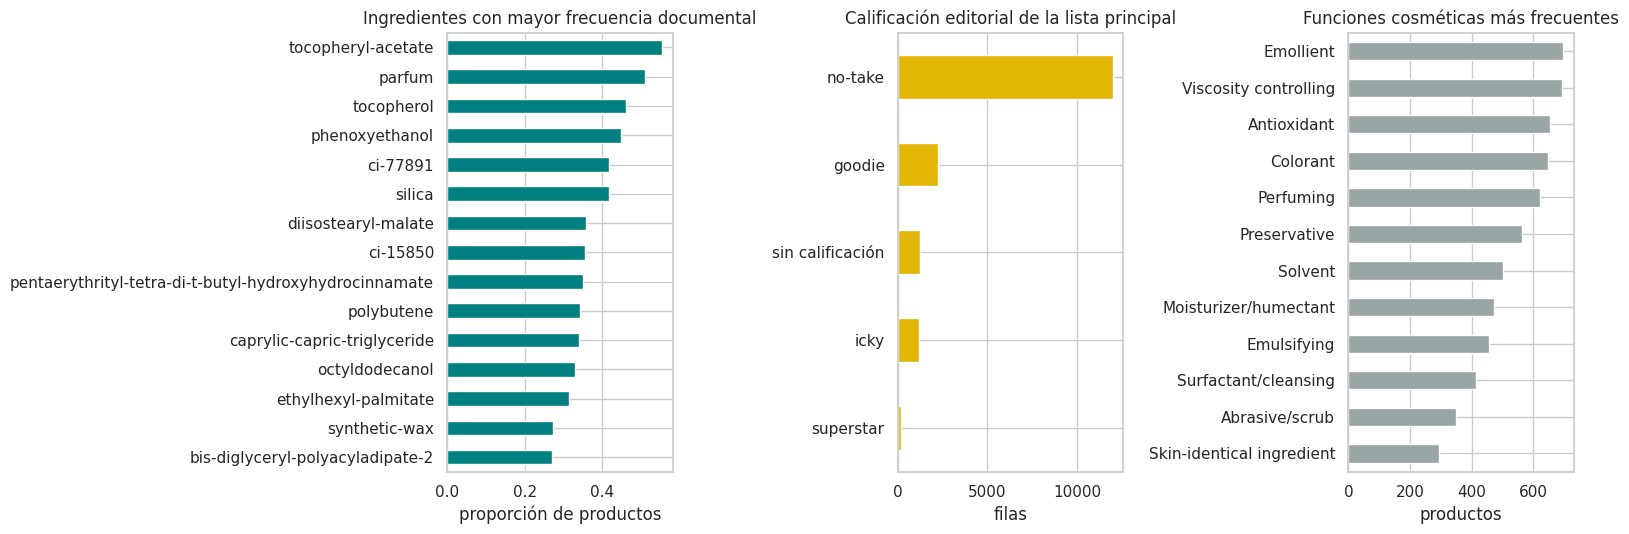

In [ ]:
base_completa = producto_ingrediente.loc[producto_ingrediente["grupo"] == "base"]
frecuencia_documental = base_completa.drop_duplicates(["url", "ingrediente"])["ingrediente"].value_counts() / len(completos)
funciones_frecuentes = producto_funcion.drop_duplicates(["url", "funcion"])["funcion"].value_counts()

fig, ejes = plt.subplots(1, 3, figsize=(16, 5.5))
frecuencia_documental.head(15).sort_values().plot(kind="barh", color=COLOR_PRINCIPAL, ax=ejes[0])
ejes[0].set_title("Ingredientes con mayor frecuencia documental")
ejes[0].set_xlabel("proporción de productos")
base_completa["calificacion"].fillna("sin calificación").value_counts().sort_values().plot(kind="barh", color=COLOR_SECUNDARIO, ax=ejes[1])
ejes[1].set_title("Calificación editorial de la lista principal")
ejes[1].set_xlabel("filas")
funciones_frecuentes.head(12).sort_values().plot(kind="barh", color=COLOR_NEUTRO, ax=ejes[2])
ejes[2].set_title("Funciones cosméticas más frecuentes")
ejes[2].set_xlabel("productos")
for eje in ejes:
    eje.set_ylabel("")
fig.tight_layout()
plt.show()

registrar("adquisicion", "fuente", "Recolección por mapas de sitio y extracción de páginas con cortesía y caché local",
          "La instantánea versionada fija el universo de estudio y hace reproducible todo el análisis posterior", "Adquisición")
registrar("marca", "admisión", f"Marcas de ampliación con al menos {UMBRAL_COBERTURA_MARCA} productos base comparables",
          "Una marca con cobertura insuficiente no sostiene pares de referencia ni un vecindario informativo", "Adquisición")

## 4. Descripción de los datos y control de integridad

La extracción entregó tres tablas relacionadas por la llave `url`, que identifica una dirección de producto en la fuente. Antes de describir o transformar nada se comprueba que esa relación se sostenga, porque toda agregación posterior depende de ella: si una dirección de la tabla de ingredientes no existiera en la tabla de productos, sus ingredientes se perderían de forma silenciosa al unir.

Dos constantes gobiernan decisiones que más adelante se aplican de forma mecánica:

* `UMBRAL_AUSENCIA_IMPUTABLE = 0.30`. Proporción de ausencia por encima de la cual una variable deja de considerarse imputable. Cuando la mayoría de los registros carece del dato, el valor estimado queda determinado por el modelo imputador y no por la evidencia observada.
* `CONTAMINACION = 0.02`. Proporción esperada de observaciones atípicas que se declara a los detectores multivariados. Es un parámetro de operación, no una estimación: fija cuántas fórmulas se someten a revisión manual.

In [ ]:
UMBRAL_AUSENCIA_IMPUTABLE = 0.30
CONTAMINACION = 0.02

productos = productos_inci.copy()
ingredientes = producto_ingrediente.copy()
funciones = producto_funcion.copy()

urls_con_lista = set(ingredientes.loc[ingredientes["grupo"].eq("base"), "url"])
control_integridad = pd.DataFrame([
    ("Unicidad de la llave url en la tabla de productos", bool(productos["url"].is_unique)),
    ("Toda dirección de ingredientes existe en productos", set(ingredientes["url"]) <= set(productos["url"])),
    ("Toda dirección de funciones existe en productos", set(funciones["url"]) <= set(productos["url"])),
    ("Extracción marcada como completa en todas las direcciones", bool(productos["estado_extraccion"].eq("completo").all())),
    ("Toda dirección tiene lista principal de ingredientes", bool(productos["url"].isin(urls_con_lista).all())),
    ("Todas las direcciones pertenecen al alcance labial", bool(productos["en_alcance"].all())),
    ("La posición de los ingredientes es estrictamente positiva", bool(ingredientes["posicion"].gt(0).all())),
], columns=["verificacion", "resultado"])
assert control_integridad["resultado"].all(), "Hay verificaciones de integridad sin superar"

print(f"Marcas: {productos['marca'].nunique()}")
print(f"Ingredientes distintos: {ingredientes['ingrediente'].nunique()}")
print()
print(control_integridad.to_string(index=False))

Marcas: 20
Ingredientes distintos: 1045

                                             verificacion  resultado
        Unicidad de la llave url en la tabla de productos       True
       Toda dirección de ingredientes existe en productos       True
          Toda dirección de funciones existe en productos       True
Extracción marcada como completa en todas las direcciones       True
     Toda dirección tiene lista principal de ingredientes       True
       Todas las direcciones pertenecen al alcance labial       True
La posición de los ingredientes es estrictamente positiva       True


### Diccionario de datos

**Tabla de productos.** Una fila por dirección de producto en la fuente.

| Variable | Tipo | Descripción |
|---|---|---|
| `url`, `slug` | Identificador | Dirección de la página y su identificador textual |
| `producto_base`, `variante` | Categórica | Línea comercial y tono o edición específica |
| `marca`, `gama` | Categórica | Marca normalizada en el catálogo y segmento: alta o económica |
| `marca_pagina`, `nombre_pagina` | Texto | Marca y nombre tal como los publica la fuente |
| `deteccion` | Categórica | Criterio por el que la dirección se clasificó como labial |
| `formato` | Categórica | Presentación física: barra, gloss, bálsamo, aceite, tinte, líquido o delineador |
| `acabado` | Categórica | Efecto visual declarado en el nombre comercial |
| `efecto_*` | Binaria | Beneficio declarado en el nombre comercial |
| `n_ingredientes`, `n_puede_contener` | Conteo | Ingredientes de la lista principal y del bloque «May Contain» |
| `n_funciones`, `n_subgrupos` | Conteo | Funciones cosméticas distintas y fórmulas declaradas en la página |
| `huella_formulacion` | Identificador | Resumen criptográfico de la lista principal completa |

**Tabla de ingredientes.** Una fila por par dirección e ingrediente.

| Variable | Tipo | Descripción |
|---|---|---|
| `grupo` | Categórica | Lista principal (`base`) o bloque de colorantes opcionales (`puede_contener`) |
| `subgrupo` | Ordinal | Fórmula de la página a la que pertenece el ingrediente |
| `posicion` | Ordinal | Lugar de declaración en la etiqueta, indicador de concentración relativa |
| `ingrediente`, `nombre_ingrediente` | Identificador | Nombre normalizado por la fuente y nombre declarado en la etiqueta |
| `calificacion` | Categórica | Valoración editorial de la fuente: superstar, goodie, no-take o icky |

**Tabla de funciones.** Una fila por dirección, función e ingrediente, con el bloque de la página, destacados o lista general, y la función cosmética del ingrediente.

**Nota sobre el orden de declaración.** La regulación cosmética exige declarar los ingredientes en orden decreciente de concentración, al menos para los presentes por encima del uno por ciento: así lo establecen el Reglamento (CE) 1223/2009 en la Unión Europea y la sección 701.3 del título 21 del Código de Regulaciones Federales en Estados Unidos, y en México la NOM-141-SSA1/SCFI-2012 regula la declaración de ingredientes en el etiquetado de los cosméticos preenvasados. Por lo tanto `posicion` no es un identificador arbitrario sino una variable con contenido físico: los primeros lugares concentran la mayor parte de la masa del producto. Esta propiedad sostiene toda la representación que se construye en la sección 10.

## 5. Diagnóstico de valores ausentes

Se distinguen dos naturalezas de ausencia, y la distinción determina el tratamiento.

La **ausencia estructural** ocurre cuando el dato no existe en la realidad observada: un nombre comercial que no declara acabado, o un ingrediente que la fuente aún no ha valorado. No hay un valor real latente que estimar, de modo que imputarla equivale a inventar información. Se codifica como categoría propia, y la codificación conserva la señal.

La **ausencia imputable** ocurre cuando existe un valor real no observado que puede estimarse a partir de otras variables. Todo labial tiene un formato físico aunque su nombre comercial no lo revele, y ese formato deja huella en la fórmula: un bálsamo se apoya en ceras y emolientes, un tinte en solventes. Esa huella es el insumo del modelo imputador.

In [ ]:
def resumen_ausencias(df):
    resumen = df.isna().sum().rename("n_ausente").reset_index().rename(columns={"index": "columna"})
    resumen["proporcion"] = resumen["n_ausente"] / len(df)
    return resumen.loc[resumen["n_ausente"] > 0]


for nombre, tabla in (("productos", productos), ("ingredientes", ingredientes), ("funciones", funciones)):
    print(f"{nombre}: {int(tabla.isna().sum().sum())} celdas vacías de {tabla.size}")
    print(resumen_ausencias(tabla).round(4).to_string(index=False))
    print()

inventario_ausencias = pd.DataFrame([
    ("productos", "zonas_adicionales", "celda vacía", int(productos["zonas_adicionales"].isna().sum()), len(productos)),
    ("productos", "acabado", "no_declarado", int(productos["acabado"].eq("no_declarado").sum()), len(productos)),
    ("productos", "formato", "no_determinado", int(productos["formato"].eq("no_determinado").sum()), len(productos)),
    ("ingredientes", "calificacion", "celda vacía", int(ingredientes["calificacion"].isna().sum()), len(ingredientes)),
    ("funciones", "calificacion", "celda vacía", int(funciones["calificacion"].isna().sum()), len(funciones)),
], columns=["tabla", "variable", "codificacion_original", "n_ausente", "n_total"])
inventario_ausencias["proporcion"] = inventario_ausencias["n_ausente"] / inventario_ausencias["n_total"]
inventario_ausencias["naturaleza"] = np.where(
    inventario_ausencias["variable"].eq("formato") & inventario_ausencias["proporcion"].le(UMBRAL_AUSENCIA_IMPUTABLE),
    "imputable", "estructural",
)
calificaciones_por_ingrediente = (
    pd.concat([ingredientes[["ingrediente", "calificacion"]], funciones[["ingrediente", "calificacion"]]])
    .dropna().groupby("ingrediente")["calificacion"].nunique()
)
print("Inventario de ausencias, incluidas las codificadas con etiqueta")
print(inventario_ausencias.round(4).to_string(index=False))
print()
print(f"Ingredientes con más de una calificación distinta: {int((calificaciones_por_ingrediente > 1).sum())}")

productos: 1253 celdas vacías de 20358
          columna  n_ausente  proporcion
         variante        579      0.8248
zonas_adicionales        674      0.9601

ingredientes: 1241 celdas vacías de 153960
     columna  n_ausente  proporcion
calificacion       1241      0.0645

funciones: 0 celdas vacías de 164346
Empty DataFrame
Columns: [columna, n_ausente, proporcion]
Index: []

Inventario de ausencias, incluidas las codificadas con etiqueta
       tabla          variable codificacion_original  n_ausente  n_total  proporcion  naturaleza
   productos zonas_adicionales           celda vacía        674      702      0.9601 estructural
   productos           acabado          no_declarado        383      702      0.5456 estructural
   productos           formato        no_determinado         71      702      0.1011   imputable
ingredientes      calificacion           celda vacía       1241    19245      0.0645 estructural
   funciones      calificacion           celda vacía          0   

**Lectura del inventario.**

El acabado no declarado supera con holgura el umbral, de modo que se conserva como categoría informativa: con más de la mitad de los registros estimados, cualquier contraste entre acabados compararía en buena medida las predicciones del imputador consigo mismas.

La calificación editorial no admite imputación por una razón más fuerte: ningún ingrediente recibe dos valoraciones distintas, lo que prueba que la calificación es un atributo del ingrediente y no del par producto e ingrediente. Su ausencia significa que la fuente aún no evaluó ese ingrediente, no que exista una valoración oculta, que es exactamente el supuesto que la imputación por ecuaciones encadenadas no satisface.

Las zonas adicionales están vacías cuando el producto es exclusivamente labial, que es el caso general. El formato es la única variable con ausencia imputable, y su tratamiento se difiere a la sección 10 porque el modelo imputador necesita como predictores el perfil funcional y la matriz de ingredientes, que se construyen allí. No se puede imputar antes de disponer del insumo predictivo.

## 6. Limpieza y construcción de la unidad de análisis

Cada ficha de esta sección se presenta en orden de dependencia: la coherencia de marca precede a la unidad de análisis porque la marca forma parte de su llave, y la armonización de colorantes precede a la base química porque define qué ingredientes se retiran del vehículo.

### Ficha L1. `marca`, coherencia entre catálogo y página

**1. Definición y justificación de negocio.** `marca` es la marca normalizada que se asignó a partir de la dirección, y `marca_pagina` es la que publica la fuente en el encabezado del producto. La marca forma parte de la llave de la unidad de análisis, porque dos marcas distintas con el mismo vehículo son precisamente el hallazgo que el producto busca.

**2. Construcción.** Los nombres de página se normalizan al formato del catálogo y para cada nombre normalizado se determina la marca canónica por mayoría. Esto tolera las variantes comerciales legítimas de una misma marca y aísla los casos en que la página atribuye el producto a otra.

**3. Diagnóstico.** Se reporta la correspondencia entre nombres de página y marcas canónicas, y las direcciones discrepantes.

**4. Decisión de tratamiento.** La página es la autoridad sobre la marca, porque la marca del catálogo se dedujo de la dirección y una dirección puede alojarse bajo el directorio de otra marca. La gama se reasigna a partir de la marca corregida, porque es un atributo de marca y no de producto.

**5. Aplicación y 6. Validación.** Se sustituye `marca`, se conserva `marca_original` como rastro de auditoría y se verifica que cada marca conserve una sola gama.

In [ ]:
def normaliza_texto(texto):
    return re.sub(r"[^a-z0-9]+", "-", str(texto).lower()).strip("-")


productos["marca_pagina_normalizada"] = productos["marca_pagina"].map(normaliza_texto)
correspondencia_marca = (
    productos.groupby("marca_pagina_normalizada")["marca"].agg(lambda s: s.value_counts().idxmax()).rename("marca_canonica")
)
productos["marca_canonica"] = productos["marca_pagina_normalizada"].map(correspondencia_marca)
discrepantes = productos.loc[productos["marca"].ne(productos["marca_canonica"])]

gama_por_marca = productos.groupby("marca")["gama"].agg(lambda s: s.value_counts().idxmax())
productos["marca_original"] = productos["marca"]
productos["marca"] = productos["marca_canonica"]
productos["gama"] = productos["marca"].map(gama_por_marca)

assert productos["marca"].eq(productos["marca_canonica"]).all(), "Quedan discrepancias de marca"
assert (productos.groupby("marca")["gama"].nunique() == 1).all(), "Hay marcas con más de una gama"
print(f"Nombres de página distintos: {productos['marca_pagina'].nunique()}, marcas canónicas: {productos['marca'].nunique()}")
print(f"Direcciones con marca discrepante corregidas: {len(discrepantes)}")
print()
print(productos.groupby("gama").agg(marcas=("marca", "nunique"), direcciones=("url", "size")).to_string())

Nombres de página distintos: 40, marcas canónicas: 20
Direcciones con marca discrepante corregidas: 0

           marcas  direcciones
gama                          
alta            9          158
economica      11          544


### Ficha L2. `calificacion`, valoración editorial del ingrediente

**1. Definición y justificación de negocio.** La fuente clasifica cada ingrediente evaluado en cuatro categorías editoriales: superstar, goodie, no-take e icky. La valoración alimenta el perfil editorial de la fórmula, insumo del mensaje que recibe la usuaria cuando el sistema explica por qué dos productos se parecen.

**2. Construcción y 3. Diagnóstico.** La variable llega tal cual de la extracción; la sección anterior mostró que la ausencia es estructural.

**4. Decisión de tratamiento.** La ausencia se codifica como categoría propia, `sin_calificacion`, que preserva una señal real: una fórmula construida con ingredientes que la fuente aún no evaluó es una fórmula sobre la que el sistema puede decir menos.

**5. Aplicación y 6. Validación.** Se rellena la ausencia en ambas tablas y se verifica que no queden celdas vacías.

In [ ]:
distribucion_previa = ingredientes["calificacion"].value_counts(dropna=False)
ingredientes["calificacion"] = ingredientes["calificacion"].fillna("sin_calificacion")
funciones["calificacion"] = funciones["calificacion"].fillna("sin_calificacion")

assert ingredientes["calificacion"].notna().all() and funciones["calificacion"].notna().all()
print(pd.DataFrame({
    "antes": distribucion_previa.rename(index=lambda v: "sin_calificacion" if pd.isna(v) else v),
    "despues": ingredientes["calificacion"].value_counts(),
}).to_string())

registrar("marca", "categórica", "Corrección desde la marca publicada en la página",
          "La página es la autoridad sobre la marca; la marca forma parte de la llave de agrupación", "Limpieza")
registrar("gama", "categórica", "Reasignación a partir de la marca corregida", "La gama es un atributo de marca y no de producto", "Limpieza")
registrar("calificacion", "categórica", "Codificación de la ausencia como sin_calificacion",
          "Ausencia estructural: la fuente no ha evaluado el ingrediente", "Limpieza")

                  antes  despues
calificacion                    
no-take           14428    14428
goodie             2249     2249
sin_calificacion   1241     1241
icky               1153     1153
superstar           174      174


### Ficha L3. `ingrediente` y `es_colorante`, armonización de pigmentos

**1. Definición y justificación de negocio.** El vehículo químico es lo que se compara; el pigmento es lo que se descarta. Separar ambos permite afirmar que dos tonos de una misma línea son la misma fórmula, y que un labial de gama alta y uno económico comparten vehículo aunque difieran en color.

**2. Construcción.** Primero se resuelven los sinónimos de la fuente, que asigna identificadores distintos a un mismo pigmento: los óxidos de hierro aparecen como `iron-oxides` o por sus tres índices de color, y el dióxido de titanio con tres identificadores. Después se clasifica como colorante o partícula de efecto todo ingrediente que corresponda a un índice de color, cuya única función declarada sea la de colorante, o que pertenezca a los sustratos de brillo y nácar: micas, borosilicatos, óxido de estaño y tereftalato de polietileno.

**3. Diagnóstico.** Se reporta el tamaño del conjunto resultante y su peso dentro de la lista principal.

**4. Decisión de tratamiento.** Los ingredientes que la fuente clasifica como colorantes pero que además cumplen funciones de textura, como el caolín o los estearatos, permanecen en el vehículo. El criterio es funcional y no nominal: si contribuye a la textura, forma parte de lo que la usuaria percibe al aplicar el producto.

**5. Aplicación y 6. Validación.** Se sustituyen los sinónimos, se agrega la bandera `es_colorante` y se verifica que los pigmentos más frecuentes queden marcados.

In [ ]:
SINONIMOS_COLORANTES = {
    "ci-77491": "iron-oxides",
    "ci-77492": "iron-oxides",
    "ci-77499": "iron-oxides",
    "titanium-dioxide": "ci-77891",
    "titanium-titanium-dioxide": "ci-77891",
}
SUSTRATOS_DE_EFECTO = {
    "mica", "synthetic-fluorphlogopite", "tin-oxide", "calcium-aluminum-borosilicate",
    "calcium-sodium-borosilicate", "calcium-titanium-borosilicate", "polyethylene-terephthalate",
}

identificadores_previos = ingredientes["ingrediente"].nunique()
ingredientes["ingrediente"] = ingredientes["ingrediente"].replace(SINONIMOS_COLORANTES)
funciones["ingrediente"] = funciones["ingrediente"].replace(SINONIMOS_COLORANTES)

funciones_por_ingrediente = funciones.groupby("ingrediente")["funcion"].agg(frozenset)
solo_colorante = set(funciones_por_ingrediente[funciones_por_ingrediente == frozenset({"Colorant"})].index)
COLORANTES = (
    solo_colorante | SUSTRATOS_DE_EFECTO | {"iron-oxides"}
    | {i for i in ingredientes["ingrediente"].unique() if i.startswith("ci-")}
)
ingredientes["es_colorante"] = ingredientes["ingrediente"].isin(COLORANTES)

print(f"Identificadores distintos antes de armonizar:   {identificadores_previos}")
print(f"Identificadores distintos después de armonizar: {ingredientes['ingrediente'].nunique()}")
print(f"Ingredientes clasificados como colorante o efecto: {len(COLORANTES)}")
print(f"Filas de colorante dentro de la lista principal: {int(ingredientes.loc[ingredientes['grupo'].eq('base'), 'es_colorante'].sum())}")
print()
print("Pigmentos más frecuentes en la lista principal")
print(ingredientes.loc[ingredientes["grupo"].eq("base") & ingredientes["es_colorante"]]
      .groupby("ingrediente")["url"].nunique().sort_values(ascending=False).head(8).to_string())

Identificadores distintos antes de armonizar:   1045
Identificadores distintos después de armonizar: 1040
Ingredientes clasificados como colorante o efecto: 31
Filas de colorante dentro de la lista principal: 2314

Pigmentos más frecuentes en la lista principal
ingrediente
ci-77891                     303
ci-15850                     249
iron-oxides                  231
tin-oxide                    183
mica                         162
synthetic-fluorphlogopite    144
ci-42090                     116
ci-45410                     104


### Ficha L4. Duplicados dentro de una misma dirección

**1. Definición y justificación de negocio.** Una fila duplicada inflaría la longitud declarada de la fórmula y desplazaría el rango de los ingredientes posteriores. Como el rango pondera la representación del modelo, un duplicado no corregido se propaga a toda la medida de similitud.

**2. Construcción.** La duplicación es una consecuencia de la normalización de la fuente, que asigna un mismo identificador a pigmentos que la etiqueta declara por separado; el caso característico es el índice CI 15850, bajo el que conviven las variantes Red 6 y Red 7.

**3. Diagnóstico.** Se cuentan las filas que repiten la combinación de dirección, grupo, subgrupo e ingrediente.

**4. Decisión de tratamiento.** Se conserva la aparición de menor posición, que corresponde a la de mayor concentración declarada. El subgrupo forma parte de la llave para no alterar las fórmulas que una página declara por separado.

**5. Aplicación y 6. Validación.** Se eliminan las repeticiones y se verifica que la llave quede sin duplicados.

In [ ]:
filas_antes_ingredientes, filas_antes_funciones = len(ingredientes), len(funciones)
duplicados_detectados = int(ingredientes.duplicated(["url", "grupo", "subgrupo", "ingrediente"]).sum())

ingredientes = (
    ingredientes.sort_values(["url", "grupo", "subgrupo", "posicion"])
    .drop_duplicates(["url", "grupo", "subgrupo", "ingrediente"], keep="first")
    .reset_index(drop=True)
)
funciones = funciones.drop_duplicates(["url", "funcion", "ingrediente"]).reset_index(drop=True)

assert not ingredientes.duplicated(["url", "grupo", "subgrupo", "ingrediente"]).any()
assert not funciones.duplicated(["url", "funcion", "ingrediente"]).any()
print(f"Filas duplicadas detectadas en ingredientes: {duplicados_detectados}")
print(f"Ingredientes: {filas_antes_ingredientes} -> {len(ingredientes)}")
print(f"Funciones:    {filas_antes_funciones} -> {len(funciones)}")

Filas duplicadas detectadas en ingredientes: 867
Ingredientes: 19245 -> 18378
Funciones:    23478 -> 23063


### Ficha L5. `subgrupo`, selección de la fórmula principal

**1. Definición y justificación de negocio.** Una página puede declarar más de una lista de ingredientes. Si se concatenaran, el producto resultante sería una mezcla que no existe en el mercado y su vehículo no sería comparable con ningún otro.

**2. Construcción.** El fenómeno tiene tres causas, que se documentan una por una: un estuche con dos fórmulas, una declaración repetida de la misma fórmula y un producto medicado cuya etiqueta separa los ingredientes activos de los inactivos por exigencia normativa.

**3. Diagnóstico.** Se identifican las direcciones afectadas y se clasifica cada una por su causa.

**4. Decisión de tratamiento.** En los tres casos la fórmula principal es el subgrupo con más ingredientes. En los medicados esto excluye del vehículo a los filtros solares, cuyo orden responde a la norma de etiquetado y no a la concentración; su presencia queda registrada en la bandera de protección solar.

**5. Aplicación y 6. Validación.** Se determina el subgrupo principal de cada dirección y se verifica que toda dirección con varios subgrupos esté clasificada.

In [ ]:
TIPO_MULTIGRUPO = {
    "essence-what-the-fake-extreme-plumping-lip-filler-icy-effect": "declaracion_repetida",
    "maybelline-super-stay-24-r-color-2-step-liquid-lipstick": "estuche_dos_formulas",
    "e-l-f-sun-boss-gloss-spf-25": "medicado",
    "maybelline-baby-lips-dr-rescue-r-medicated-lip-balm": "medicado",
    "revlon-kiss-baume": "medicado",
    "revlon-kiss-lip-balm": "medicado",
}

lista_principal = ingredientes.loc[ingredientes["grupo"].eq("base")]
tamano_subgrupo = lista_principal.groupby(["url", "subgrupo"]).size().rename("n").reset_index()
subgrupo_principal = (
    tamano_subgrupo.sort_values(["url", "n", "subgrupo"], ascending=[True, False, True])
    .drop_duplicates("url").set_index("url")["subgrupo"]
)
multigrupo = productos.loc[productos["n_subgrupos"] > 1, ["url", "slug", "marca", "n_subgrupos"]].copy()
multigrupo["tipo"] = multigrupo["slug"].map(TIPO_MULTIGRUPO)
multigrupo["subgrupo_principal"] = multigrupo["url"].map(subgrupo_principal)

assert multigrupo["tipo"].notna().all(), "Hay direcciones con varios subgrupos sin clasificar"
print(f"Direcciones con más de un subgrupo: {len(multigrupo)}")
print(multigrupo.drop(columns="url").to_string(index=False))

Direcciones con más de un subgrupo: 6
                                                        slug      marca  n_subgrupos                 tipo  subgrupo_principal
essence-what-the-fake-extreme-plumping-lip-filler-icy-effect    essence            2 declaracion_repetida                   2
     maybelline-super-stay-24-r-color-2-step-liquid-lipstick maybelline            2 estuche_dos_formulas                   1
                                 e-l-f-sun-boss-gloss-spf-25        elf            2             medicado                   2
         maybelline-baby-lips-dr-rescue-r-medicated-lip-balm maybelline            2             medicado                   2
                                           revlon-kiss-baume     revlon            2             medicado                   2
                                        revlon-kiss-lip-balm     revlon            2             medicado                   2


### Ficha L6. `base_quimica`, `rango_base` y `huella_base`

**1. Definición y justificación de negocio.** La base química es el objeto que el sistema compara: los ingredientes de la lista principal que pertenecen al subgrupo principal y que no son colorantes ni partículas de efecto. La huella es su resumen criptográfico: dos direcciones con la misma huella comparten exactamente el mismo vehículo, aunque se vendan como tonos distintos.

**2. Construcción.** Retirados los colorantes, el orden relativo de los ingredientes restantes se conserva y se renumera como `rango_base`, porque las posiciones originales quedarían con huecos y el rango debe ser una secuencia continua para que la ponderación tenga sentido.

**3. Diagnóstico.** La diferencia entre el número de huellas de la lista completa y el de la base química cuantifica cuánta redundancia de tono absorbe la decisión de excluir el color.

**4. Decisión de tratamiento.** La base química es la estructura de trabajo y la huella la llave de agrupación. Los colorantes no se descartan: se resumen en la métrica `n_colorantes`.

**5. Aplicación y 6. Validación.** Se verifica que toda dirección tenga base química y que el rango comience en uno y sea continuo.

In [ ]:
def huella(secuencia):
    return hashlib.sha1("|".join(secuencia).encode("utf-8")).hexdigest()[:12]


es_subgrupo_principal = ingredientes["subgrupo"].eq(ingredientes["url"].map(subgrupo_principal))
base_direccion = ingredientes.loc[
    ingredientes["grupo"].eq("base") & es_subgrupo_principal & ~ingredientes["es_colorante"]
].sort_values(["url", "posicion"]).copy()
base_direccion["rango_base"] = base_direccion.groupby("url").cumcount() + 1

huellas_base = base_direccion.groupby("url")["ingrediente"].apply(huella).rename("huella_base")
productos = productos.merge(huellas_base, on="url", how="left")

longitud = base_direccion.groupby("url")["rango_base"].agg(["min", "max", "size"])
assert productos["huella_base"].notna().all(), "Hay direcciones sin base química"
assert longitud["min"].eq(1).all() and longitud["max"].eq(longitud["size"]).all(), "El rango no es continuo"

print(f"Filas de la lista principal:            {int(ingredientes['grupo'].eq('base').sum())}")
print(f"Filas que integran la base química:     {len(base_direccion)}")
print(f"Huellas distintas de la lista completa: {productos['huella_formulacion'].nunique()}")
print(f"Huellas distintas de la base química:   {productos['huella_base'].nunique()}")
print(f"Direcciones que colapsan al excluir el color: {productos['huella_formulacion'].nunique() - productos['huella_base'].nunique()}")

Filas de la lista principal:            16466
Filas que integran la base química:     14399
Huellas distintas de la lista completa: 689
Huellas distintas de la base química:   644
Direcciones que colapsan al excluir el color: 45


### Ficha L7. `id_formula`, construcción de la unidad de análisis

**1. Definición y justificación de negocio.** La unidad de observación deja de ser la dirección y pasa a ser la fórmula base. Sin este paso, una línea con veinte tonos pesaría veinte veces más que una con un solo tono en cualquier estadístico, y el modelo devolvería veinte veces el mismo producto como recomendación.

**2. Construcción.** Las direcciones se agrupan por marca y huella de base. La marca forma parte de la llave de forma deliberada: dos marcas distintas que comparten vehículo son el hallazgo central del producto y deben permanecer separadas para poder emparejarse.

**3. Diagnóstico.** Se reporta la reducción de direcciones a fórmulas y los vehículos compartidos entre marcas distintas.

**4. Decisión de tratamiento.** El formato y el acabado toman la moda de los valores informativos de sus variantes, de modo que una sola variante sin declarar no arrastra a toda la línea. Los efectos se combinan con disyunción lógica, porque un beneficio anunciado en cualquier variante es una propiedad de la fórmula. La dirección representante es la primera en orden alfabético, criterio reproducible.

**5. Aplicación y 6. Validación.** Se verifica la correspondencia uno a uno entre fórmulas y representantes, y que la suma de variantes reconstruya el total de direcciones.

In [ ]:
COLUMNAS_EFECTO = [c for c in productos.columns if c.startswith("efecto_")]


def moda_informativa(serie, no_informativo):
    validos = serie.loc[serie.ne(no_informativo)]
    if validos.empty:
        return no_informativo
    return validos.value_counts().sort_index().idxmax()


productos = productos.sort_values(["marca", "huella_base", "slug"]).reset_index(drop=True)
formulas = productos.groupby(["marca", "huella_base"], sort=True).agg(
    gama=("gama", "first"),
    url_representante=("url", "first"),
    slug_representante=("slug", "first"),
    nombre_representante=("nombre_pagina", "first"),
    lineas=("producto_base", lambda s: "|".join(sorted(set(s)))),
    n_variantes=("url", "size"),
    formato_original=("formato", lambda s: moda_informativa(s, "no_determinado")),
    acabado=("acabado", lambda s: moda_informativa(s, "no_declarado")),
    formatos_distintos=("formato", lambda s: s.loc[s.ne("no_determinado")].nunique()),
    **{c: (c, "any") for c in COLUMNAS_EFECTO},
).reset_index()
formulas.insert(0, "id_formula", [f"F{k:04d}" for k in range(1, len(formulas) + 1)])
formulas["deteccion"] = formulas["url_representante"].map(productos.set_index("url")["deteccion"])

productos = productos.merge(formulas[["marca", "huella_base", "id_formula"]], on=["marca", "huella_base"], how="left")
productos["es_representante"] = productos["url"].isin(formulas["url_representante"])

assert formulas["id_formula"].is_unique and formulas["url_representante"].is_unique
assert int(formulas["n_variantes"].sum()) == len(productos), "Las variantes no reconstruyen el total de direcciones"

compartidas = formulas.groupby("huella_base").filter(lambda g: g["marca"].nunique() > 1)
print(f"Direcciones:                          {len(productos)}")
print(f"Fórmulas base:                        {len(formulas)}")
print(f"Reducción por consolidación de tonos: {len(productos) - len(formulas)}")
print(f"Fórmulas con más de una variante:     {int((formulas['n_variantes'] > 1).sum())}")
print()
print(formulas.groupby("gama").agg(marcas=("marca", "nunique"), formulas=("id_formula", "size"), direcciones=("n_variantes", "sum")).to_string())
print()
print(f"Vehículos idénticos entre marcas distintas: {compartidas['huella_base'].nunique()}")
print(compartidas[["huella_base", "marca", "gama", "formato_original", "nombre_representante"]].to_string(index=False))

registrar("ingrediente", "identificador", "Armonización de sinónimos de pigmentos",
          "Un mismo pigmento con dos identificadores rompería la coincidencia de huellas", "Limpieza")
registrar("es_colorante", "binaria", "Derivación por índice de color, función única y sustratos de efecto",
          "Separar el vehículo del color es la operación que hace posible la comparación", "Limpieza")
registrar("duplicados", "limpieza", "Se conserva la aparición de menor posición por dirección, grupo, subgrupo e ingrediente",
          "Un duplicado desplazaría el rango de los ingredientes posteriores", "Limpieza")
registrar("subgrupo", "ordinal", "Selección del subgrupo con más ingredientes", "Concatenar fórmulas produciría un producto inexistente", "Limpieza")
registrar("rango_base", "ordinal", "Renumeración continua tras excluir colorantes", "El rango pondera la representación y exige secuencia sin huecos", "Limpieza")
registrar("huella_base", "identificador", "Resumen criptográfico de la secuencia del vehículo", "Identifica vehículos idénticos entre tonos y entre marcas", "Limpieza")
registrar("id_formula", "identificador", "Agrupación por marca y huella de base",
          "Evita que una línea con muchos tonos domine estadísticos y recomendaciones", "Limpieza")

Direcciones:                          702
Fórmulas base:                        645
Reducción por consolidación de tonos: 57
Fórmulas con más de una variante:     45

           marcas  formulas  direcciones
gama                                    
alta            9       147          158
economica      11       498          544

Vehículos idénticos entre marcas distintas: 1
 huella_base marca      gama formato_original            nombre_representante
5be4758e6430  kiko economica       delineador Creamy Colour Comfort Lip Liner
5be4758e6430   nyx economica       delineador            Line Loud Lip Pencil


## 7. Análisis exploratorio

### 7.1 Métricas de conteo de la fórmula

Las métricas descriptivas se calculan sobre la dirección representante de cada fórmula, de modo que una línea con muchos tonos aporta una sola observación y no sobrerrepresenta su vehículo. Cuatro métricas de conteo describen juntas la arquitectura de una fórmula, y el número de variantes mide la extensión comercial de la línea.

In [ ]:
base_formula_03 = (
    base_direccion.loc[base_direccion["url"].isin(formulas["url_representante"])]
    .merge(formulas[["id_formula", "url_representante"]], left_on="url", right_on="url_representante")
    .drop(columns="url_representante")
)
lista_representante = ingredientes.loc[ingredientes["url"].isin(formulas["url_representante"])]

metricas = pd.DataFrame({
    "url_representante": formulas["url_representante"],
    "n_ingredientes_base": formulas["url_representante"].map(base_formula_03.groupby("url").size()),
    "n_colorantes": formulas["url_representante"].map(
        lista_representante.loc[lista_representante["grupo"].eq("base") & lista_representante["es_colorante"]].groupby("url").size()
    ),
    "n_puede_contener": formulas["url_representante"].map(
        lista_representante.loc[lista_representante["grupo"].eq("puede_contener")].groupby("url").size()
    ),
    "n_funciones": formulas["url_representante"].map(
        funciones.merge(base_formula_03[["url", "ingrediente"]], on=["url", "ingrediente"]).groupby("url")["funcion"].nunique()
    ),
}).fillna(0)
formulas = formulas.merge(metricas, on="url_representante", how="left")
VARIABLES_CONTEO = ["n_ingredientes_base", "n_colorantes", "n_puede_contener", "n_funciones", "n_variantes"]
formulas[VARIABLES_CONTEO] = formulas[VARIABLES_CONTEO].astype(int)


def estadisticos(serie):
    valores = serie.astype(float).to_numpy()
    return pd.Series({
        "minimo": valores.min(), "P01": np.percentile(valores, 1), "P05": np.percentile(valores, 5),
        "media": valores.mean(), "mediana": np.median(valores), "P95": np.percentile(valores, 95),
        "P99": np.percentile(valores, 99), "maximo": valores.max(),
        "varianza": valores.var(ddof=1), "desv_std": valores.std(ddof=1),
    }).round(4)


def graficar_distribucion(variable, titulo):
    fig, ejes = plt.subplots(1, 2, figsize=(12, 3.4), gridspec_kw={"width_ratios": [1, 2.4]})
    sns.boxplot(x=formulas[variable], color=COLOR_PRINCIPAL, ax=ejes[0])
    sns.histplot(formulas[variable], discrete=True, color=COLOR_PRINCIPAL, ax=ejes[1])
    ejes[0].set_title("Diagrama de caja")
    ejes[1].set_title("Histograma")
    for eje in ejes:
        eje.set_xlabel(titulo)
    fig.tight_layout()
    plt.show()


print(pd.concat({v: estadisticos(formulas[v]) for v in VARIABLES_CONTEO}, axis=1).to_string())

          n_ingredientes_base  n_colorantes  n_puede_contener  n_funciones  n_variantes
minimo                 4.0000        0.0000            0.0000       4.0000       1.0000
P01                    7.0000        0.0000            0.0000       4.0000       1.0000
P05                   10.0000        0.0000            0.0000       5.0000       1.0000
media                 20.6233        2.8667            2.7783       9.2574       1.0884
mediana               19.0000        2.0000            0.0000       9.0000       1.0000
P95                   35.0000        7.8000           13.0000      14.0000       2.0000
P99                   43.5600       15.0000           14.5600      15.0000       3.0000
maximo                58.0000       17.0000           17.0000      15.0000       4.0000
varianza              61.8936        9.1996           18.7287       5.8001       0.1304
desv_std               7.8672        3.0331            4.3277       2.4083       0.3611


### Ficha V1. `n_ingredientes_base`, longitud del vehículo

**1. Definición y justificación de negocio.** Número de ingredientes de la base química, es decir la complejidad del vehículo una vez retirado el color. Responde una pregunta comercial directa: si el lujo estuviera en la fórmula, cabría esperar vehículos sistemáticamente más elaborados en la gama alta.

**2. Construcción.** Conteo de filas de la base química de la dirección representante.

**3. Diagnóstico.** La media supera a la mediana y los percentiles superiores se alejan más que los inferiores: la distribución es asimétrica a la derecha, lo que justifica las pruebas no paramétricas del análisis bivariado.

**4. Decisión de tratamiento.** Se conserva sin transformar. El escalamiento se aplica en la sección 10, inmediatamente antes de alimentar el modelo; los valores extremos se marcan en la sección 8 y no se eliminan.

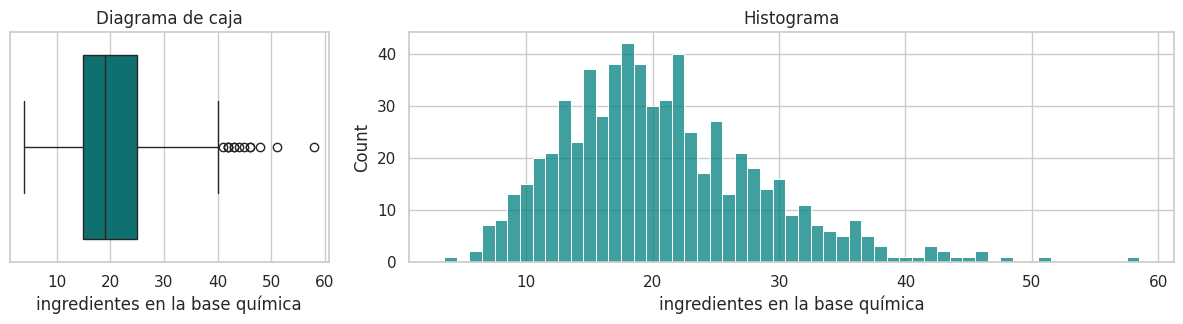

In [ ]:
graficar_distribucion("n_ingredientes_base", "ingredientes en la base química")

### Fichas V2 y V3. `n_colorantes` y `n_puede_contener`, carga de pigmento

**1. Definición y justificación de negocio.** `n_colorantes` es el número de colorantes y partículas de efecto de la lista principal, la magnitud de lo que se retiró del vehículo. `n_puede_contener` es el número de ingredientes del bloque «May Contain», que la etiqueta usa para cubrir con una sola lista todos los tonos de una línea; su magnitud es un indicador indirecto de la amplitud del abanico de tonos.

**2. Construcción.** Conteos sobre la dirección representante.

**3. Diagnóstico.** Una mediana baja frente a un máximo elevado indica que el pigmento se concentra en pocas líneas de alta pigmentación, y una proporción alta de ceros en el bloque condicional indica cuántas líneas no usan ese mecanismo de etiquetado.

**4. Decisión de tratamiento.** Ambas se conservan como descriptores y como insumo de la detección multivariada de extremos. Ninguna entra en la representación de similitud: incluir el pigmento reintroduciría el color, y el bloque «May Contain» es condicional por definición, de modo que incluirlo afirmaría una equivalencia que la etiqueta no sostiene.

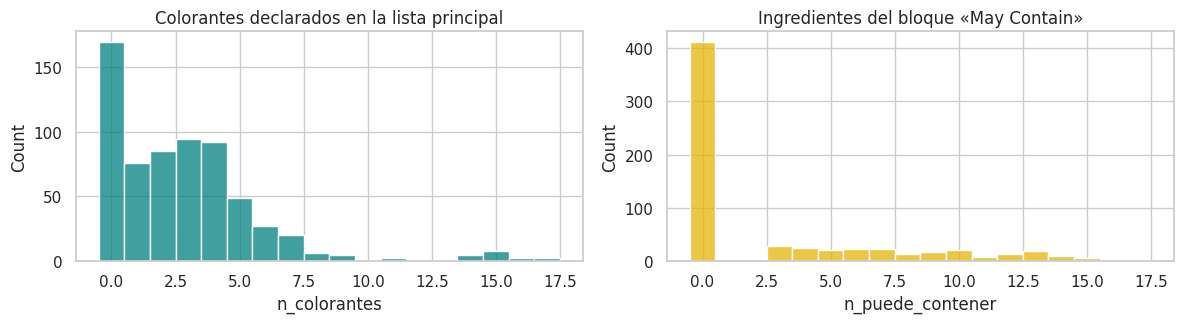

Fórmulas sin bloque «May Contain»: 411 de 645


In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 3.4))
sns.histplot(formulas["n_colorantes"], discrete=True, color=COLOR_PRINCIPAL, ax=ejes[0])
sns.histplot(formulas["n_puede_contener"], discrete=True, color=COLOR_SECUNDARIO, ax=ejes[1])
ejes[0].set_title("Colorantes declarados en la lista principal")
ejes[1].set_title("Ingredientes del bloque «May Contain»")
fig.tight_layout()
plt.show()
print(f"Fórmulas sin bloque «May Contain»: {int(formulas['n_puede_contener'].eq(0).sum())} de {len(formulas)}")

### Fichas V4 y V5. `n_funciones` y `n_variantes`

**1. Definición y justificación de negocio.** `n_funciones` es el número de funciones cosméticas distintas que cumplen los ingredientes del vehículo. A diferencia de la longitud, mide amplitud y no tamaño, y es la variable que más se aproxima a la noción de sofisticación técnica. `n_variantes` es el número de direcciones que colapsaron en la misma fórmula, es decir cuántos tonos comparten un mismo vehículo.

**2. Construcción.** Funciones distintas entre los ingredientes de la base química; tamaño del grupo formado por marca y huella.

**4. Decisión de tratamiento.** `n_funciones` se conserva sin transformar y se usa como predictor del formato. `n_variantes` es un metadato: la popularidad comercial de una línea no es una propiedad de su química y sesgaría las recomendaciones hacia las marcas con catálogos más extensos.

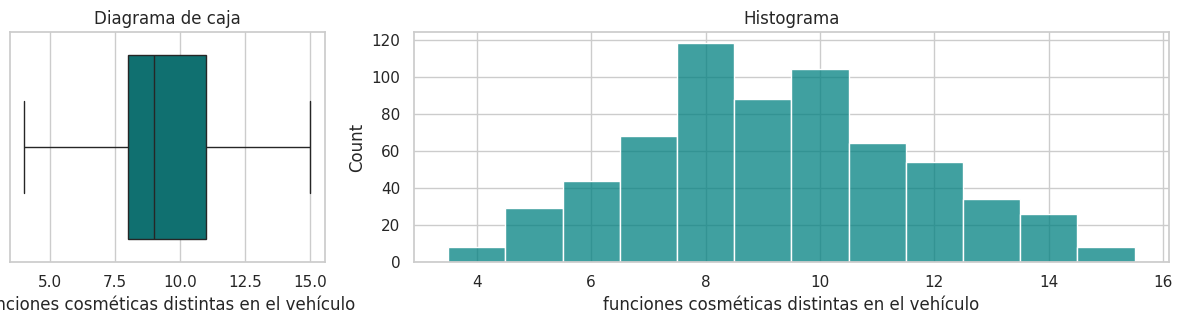

Fórmulas con más variantes de tono bajo un mismo vehículo
id_formula   marca      gama                               nombre_representante  n_variantes
     F0057 catrice economica        Glossin' Glow Tinted Lip Oil 020 Drama Mama            4
     F0105 catrice economica      Melt & Shine Juicy Lip Balm 060 Malibu Barbie            4
     F0112 catrice economica                     Melt & Plump Juicy Lip Plumper            4
     F0313 essence economica Meta Glow Multi-Reflective Lipgloss 01 Cyber Space            4
     F0035 catrice economica                        Melt & Shine Juicy Lip Balm            3
     F0065 catrice economica             Care In Colours Lip Balm Everyday 24/7            3


In [ ]:
graficar_distribucion("n_funciones", "funciones cosméticas distintas en el vehículo")
print("Fórmulas con más variantes de tono bajo un mismo vehículo")
print(formulas.nlargest(6, "n_variantes")[["id_formula", "marca", "gama", "nombre_representante", "n_variantes"]].to_string(index=False))

### 7.2 Correlación entre las métricas de conteo

Se emplea el coeficiente de Spearman y no el de Pearson porque las cinco variables son conteos discretos y asimétricos, y la relación de interés es monótona y no necesariamente lineal. Spearman opera sobre rangos, de modo que no exige normalidad ni se ve arrastrado por los valores extremos.

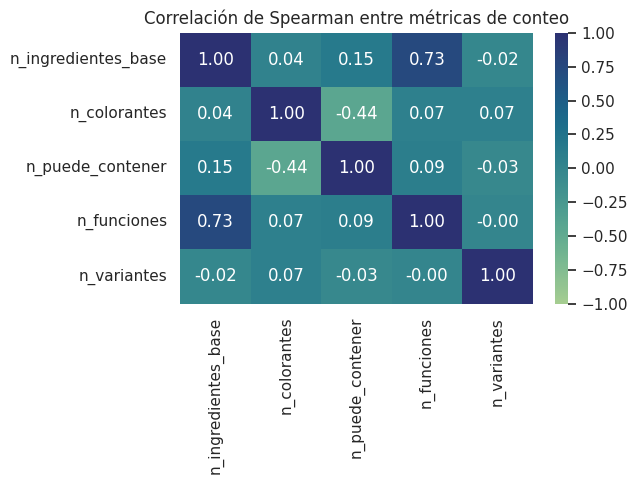

In [ ]:
correlacion_conteos = formulas[VARIABLES_CONTEO].corr(method="spearman")
plt.figure(figsize=(6.5, 5))
sns.heatmap(correlacion_conteos, annot=True, fmt=".2f", cmap="crest", vmin=-1, vmax=1)
plt.title("Correlación de Spearman entre métricas de conteo")
plt.tight_layout()
plt.show()

### 7.3 Variables categóricas

* `gama` separa el catálogo en alta y económica. Es la variable de contraste: el producto existe porque se sospecha que la diferencia de precio no corresponde a una diferencia de fórmula.
* `formato_original` describe la presentación física declarada en el nombre comercial.
* `acabado` describe el efecto visual declarado. Conserva `no_declarado` como categoría informativa, según el umbral de la sección 5.
* `deteccion` registra el criterio de recolección; es un control de calidad y no entra en ningún modelo.

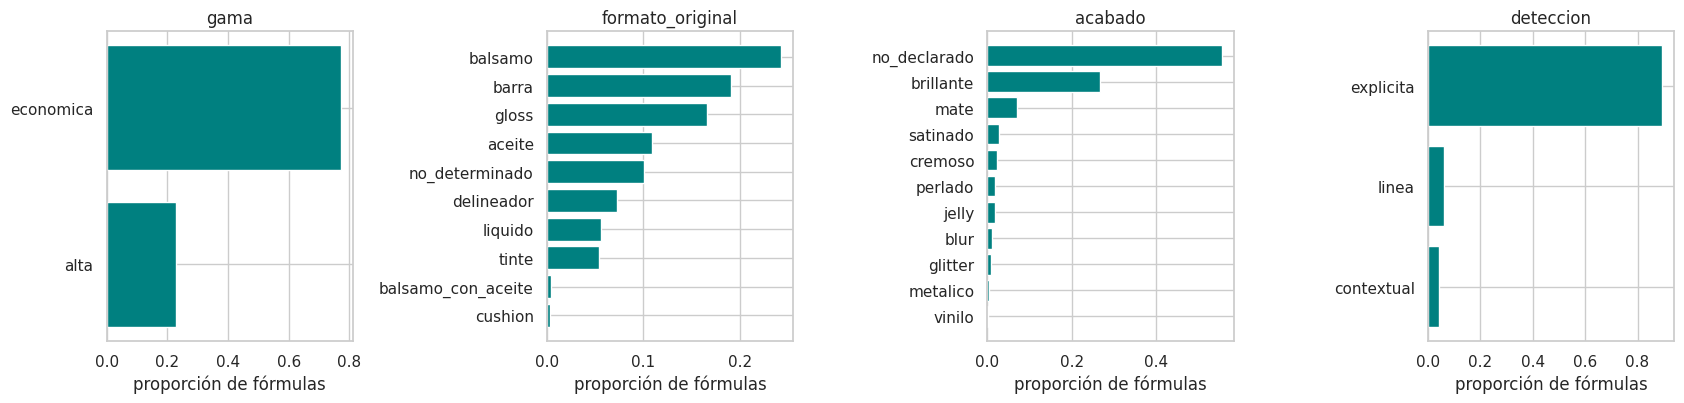

gama
economica    498
alta         147

formato_original
balsamo               157
barra                 123
gloss                 107
aceite                 70
no_determinado         65
delineador             47
liquido                36
tinte                  35
balsamo_con_aceite      3
cushion                 2



In [ ]:
fig, ejes = plt.subplots(1, 4, figsize=(17, 4.2))
for eje, variable in zip(ejes, ["gama", "formato_original", "acabado", "deteccion"]):
    proporciones = formulas[variable].value_counts(normalize=True).sort_values()
    eje.barh(proporciones.index.astype(str), proporciones.to_numpy(), color=COLOR_PRINCIPAL)
    eje.set_title(variable)
    eje.set_xlabel("proporción de fórmulas")
fig.tight_layout()
plt.show()
for variable in ["gama", "formato_original"]:
    print(formulas[variable].value_counts().to_string())
    print()

### 7.4 Complejidad del vehículo por formato y gama

La comparación se hace dentro de cada formato, porque el formato condiciona la longitud del vehículo por razones técnicas: un aceite necesita menos ingredientes que un bálsamo. Comparar gamas sin separar por formato confundiría el efecto de la gama con la distinta composición de formatos de cada una.

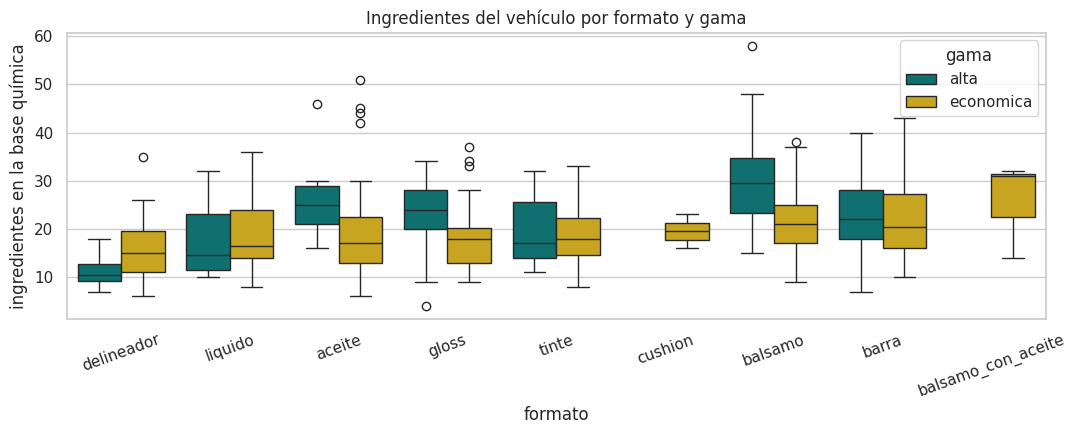

                    size           median          
gama                alta economica   alta economica
formato_original                                   
aceite               7.0      63.0   25.0      17.0
balsamo             34.0     123.0   29.5      21.0
balsamo_con_aceite   NaN       3.0    NaN      31.0
barra               43.0      80.0   22.0      20.5
cushion              NaN       2.0    NaN      19.5
delineador           4.0      43.0   10.5      15.0
gloss               19.0      88.0   24.0      18.0
liquido              8.0      28.0   14.5      16.5
tinte               11.0      24.0   17.0      18.0


In [ ]:
conocidas = formulas.loc[formulas["formato_original"].ne("no_determinado")]
orden_formato = conocidas.groupby("formato_original")["n_ingredientes_base"].median().sort_values(kind="stable").index

plt.figure(figsize=(11, 4.5))
sns.boxplot(data=conocidas, x="formato_original", y="n_ingredientes_base", hue="gama", order=orden_formato,
            palette=[COLOR_PRINCIPAL, COLOR_SECUNDARIO])
plt.title("Ingredientes del vehículo por formato y gama")
plt.xlabel("formato")
plt.xticks(rotation=20)
plt.ylabel("ingredientes en la base química")
plt.tight_layout()
plt.show()
print(conocidas.groupby(["formato_original", "gama"])["n_ingredientes_base"].agg(["size", "median"]).unstack().to_string())

### 7.5 Contraste de distribuciones entre gamas

La prueba de Kolmogorov y Smirnov para dos muestras contrasta la hipótesis nula de que ambas gamas provienen de la misma distribución. No supone normalidad y compara las funciones de distribución completas, de modo que detecta diferencias de forma o de dispersión que una comparación de medianas pasaría por alto. Un valor p pequeño indica que la diferencia es difícil de atribuir al azar, no que sea grande; por eso el estadístico, que es la distancia máxima entre ambas funciones de distribución, se reporta junto a las medianas.

In [ ]:
alta = formulas["gama"].eq("alta")
contrastes = []
for variable in VARIABLES_CONTEO[:4]:
    estadistico, valor_p = ks_2samp(formulas.loc[alta, variable], formulas.loc[~alta, variable])
    contrastes.append({
        "variable": variable,
        "mediana_alta": formulas.loc[alta, variable].median(),
        "mediana_economica": formulas.loc[~alta, variable].median(),
        "estadistico_KS": round(estadistico, 4),
        "valor_p": round(valor_p, 4),
        "difiere_al_5_por_ciento": valor_p < 0.05,
    })
print(pd.DataFrame(contrastes).to_string(index=False))

           variable  mediana_alta  mediana_economica  estadistico_KS  valor_p  difiere_al_5_por_ciento
n_ingredientes_base          23.0               19.0          0.2444   0.0000                     True
       n_colorantes           2.0                3.0          0.1567   0.0066                     True
   n_puede_contener           3.0                0.0          0.2526   0.0000                     True
        n_funciones          10.0                9.0          0.1992   0.0002                     True


### 7.6 Asociación entre formato y gama

La prueba ji cuadrada de independencia evalúa si la mezcla de formatos difiere entre gamas. Como el estadístico crece con el tamaño de muestra, se reporta además la V de Cramér, acotada entre cero y uno con independencia del número de observaciones, y el número de celdas con frecuencia esperada menor que cinco, porque la aproximación pierde validez cuando esa proporción es alta.

In [ ]:
tabla_formato = pd.crosstab(conocidas["formato_original"], conocidas["gama"])
chi2, valor_p, gl, esperadas = chi2_contingency(tabla_formato)
v_cramer = np.sqrt(chi2 / (tabla_formato.to_numpy().sum() * (min(tabla_formato.shape) - 1)))
print(tabla_formato.to_string())
print()
print(f"Ji cuadrada: {chi2:.3f}, grados de libertad: {gl}, valor p: {valor_p:.4f}")
print(f"V de Cramér: {v_cramer:.3f}")
print(f"Celdas con frecuencia esperada menor que 5: {int((esperadas < 5).sum())} de {esperadas.size}")

gama                alta  economica
formato_original                   
aceite                 7         63
balsamo               34        123
balsamo_con_aceite     0          3
barra                 43         80
cushion                0          2
delineador             4         43
gloss                 19         88
liquido                8         28
tinte                 11         24

Ji cuadrada: 27.477, grados de libertad: 8, valor p: 0.0006
V de Cramér: 0.218
Celdas con frecuencia esperada menor que 5: 4 de 18


### 7.7 Ingredientes del vehículo por gama

La frecuencia documental de un ingrediente es la proporción de fórmulas de una gama que lo contienen en su base química. La diferencia entre gamas identifica qué ingredientes caracterizan a cada segmento de precio, y es el material con el que después se construye la explicación que recibe la usuaria.

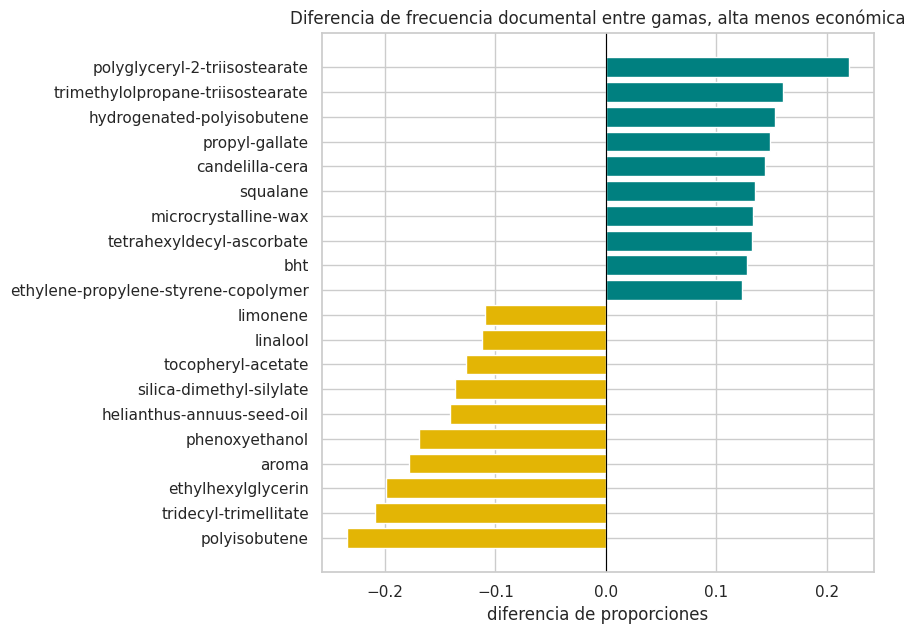

Ingredientes más frecuentes en cada gama
                                                  alta  proporcion_alta                                              economica  proporcion_economica
                                                parfum            0.551                                     tocopheryl-acetate                 0.582
                                            tocopherol            0.490                                                 parfum                 0.502
                                    tocopheryl-acetate            0.456                                         phenoxyethanol                 0.482
                                                silica            0.449                                             tocopherol                 0.436
                                   diisostearyl-malate            0.408                                                 silica                 0.404
                                            polybutene           

In [ ]:
presencia_gama = (
    base_formula_03.merge(formulas[["id_formula", "gama"]], on="id_formula")
    .groupby(["ingrediente", "gama"])["id_formula"].nunique()
    .unstack(fill_value=0)
)
presencia_gama = presencia_gama / formulas["gama"].value_counts()
presencia_gama["diferencia"] = presencia_gama["alta"] - presencia_gama["economica"]

contrastantes = pd.concat([presencia_gama.nlargest(10, "diferencia"), presencia_gama.nsmallest(10, "diferencia")]).sort_values("diferencia")
plt.figure(figsize=(9, 6.5))
plt.barh(contrastantes.index, contrastantes["diferencia"], color=np.where(contrastantes["diferencia"] > 0, COLOR_PRINCIPAL, COLOR_SECUNDARIO))
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Diferencia de frecuencia documental entre gamas, alta menos económica")
plt.xlabel("diferencia de proporciones")
plt.tight_layout()
plt.show()
print("Ingredientes más frecuentes en cada gama")
print(pd.DataFrame({
    "alta": presencia_gama["alta"].nlargest(10).index,
    "proporcion_alta": presencia_gama["alta"].nlargest(10).round(3).to_numpy(),
    "economica": presencia_gama["economica"].nlargest(10).index,
    "proporcion_economica": presencia_gama["economica"].nlargest(10).round(3).to_numpy(),
}).to_string(index=False))

### Ficha V6. Perfil editorial de la fórmula

**1. Definición y justificación de negocio.** Proporción de ingredientes del vehículo que la fuente clasifica en cada categoría editorial. Traduce la fórmula a un lenguaje que la usuaria entiende sin conocer nomenclatura INCI.

**2. Construcción.** Tabla cruzada de fórmula contra calificación, normalizada por fila. La normalización evita confundir composición con longitud: una fórmula larga tendría más ingredientes de cada tipo por el solo hecho de ser larga.

**4. Decisión de tratamiento.** Cinco variables continuas acotadas entre cero y uno. La proporción de ingredientes mal valorados y la de ingredientes sin valorar entran en la detección multivariada de extremos, porque una fórmula con valores altos en ambas es candidata a error de extracción.

**6. Validación.** Las proporciones suman uno en todas las fórmulas.

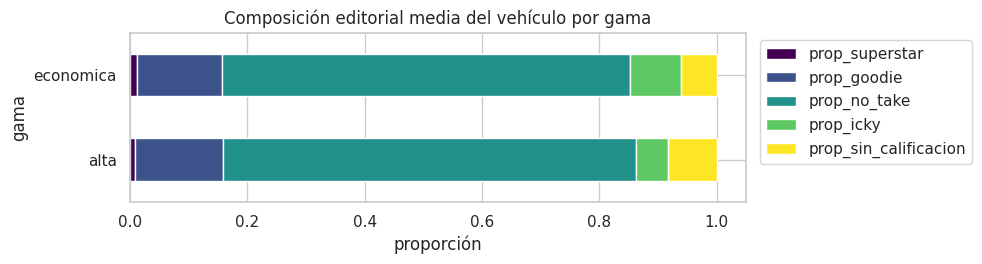

           prop_superstar  prop_goodie  prop_no_take  prop_icky  prop_sin_calificacion
gama                                                                                  
alta                0.008        0.150         0.704      0.054                  0.084
economica           0.012        0.145         0.695      0.087                  0.061


In [ ]:
CATEGORIAS_CALIFICACION = ["superstar", "goodie", "no-take", "icky", "sin_calificacion"]
perfil_editorial = (
    pd.crosstab(base_formula_03["id_formula"], base_formula_03["calificacion"], normalize="index")
    .reindex(columns=CATEGORIAS_CALIFICACION, fill_value=0)
)
perfil_editorial.columns = ["prop_" + c.replace("-", "_") for c in perfil_editorial.columns]
formulas = formulas.merge(perfil_editorial, left_on="id_formula", right_index=True, how="left")
VARIABLES_EDITORIALES = list(perfil_editorial.columns)
formulas[VARIABLES_EDITORIALES] = formulas[VARIABLES_EDITORIALES].fillna(0)
assert np.allclose(formulas[VARIABLES_EDITORIALES].sum(axis=1), 1.0), "Las proporciones editoriales no suman uno"

composicion_editorial = formulas.groupby("gama")[VARIABLES_EDITORIALES].mean()
composicion_editorial.plot(kind="barh", stacked=True, figsize=(10, 2.8), colormap="viridis")
plt.title("Composición editorial media del vehículo por gama")
plt.xlabel("proporción")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()
print(composicion_editorial.round(3).to_string())

### 7.8 Cobertura por marca

La cobertura es una condición de viabilidad y no un resultado analítico. El sistema solo puede proponer alternativas a un producto de gama alta si dispone de suficientes fórmulas de ambos lados, y una marca con pocas fórmulas rara vez aparecerá entre las recomendaciones por razones de disponibilidad y no de similitud. Esta tabla documenta ese sesgo antes de que el modelo exista.

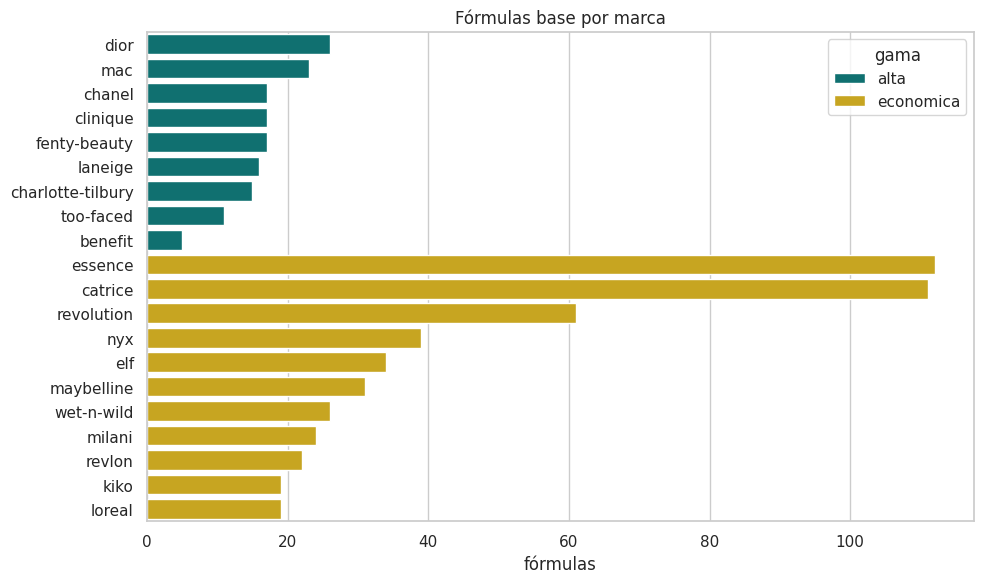

In [ ]:
cobertura = (
    formulas.groupby(["gama", "marca"])
    .agg(formulas=("id_formula", "size"), direcciones=("n_variantes", "sum"), formatos=("formato_original", "nunique"))
    .reset_index().sort_values(["gama", "formulas"], ascending=[True, False])
)
plt.figure(figsize=(10, 6))
sns.barplot(data=cobertura, y="marca", x="formulas", hue="gama", dodge=False, palette=[COLOR_PRINCIPAL, COLOR_SECUNDARIO])
plt.title("Fórmulas base por marca")
plt.xlabel("fórmulas")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Hallazgos del análisis exploratorio.**

* La gama alta declara vehículos más largos, con mediana de 23 frente a 19 ingredientes, y con una función cosmética más. La prueba de Kolmogorov y Smirnov confirma la diferencia, pero su estadístico, cercano a 0.24, indica que las dos distribuciones se traslapan ampliamente.
* La asociación entre formato y gama es estadísticamente significativa pero débil, con V de Cramér de 0.22: ambas gamas ofrecen los mismos vehículos en proporciones parecidas, lo que hace posible la comparación.
* Distinguen a la gama alta ésteres emolientes como los triisoestearatos de poliglicerilo 2 y de trimetilolpropano, ceras como la candelilla y la microcristalina, y antioxidantes como el galato de propilo y el ascorbato de tetrahexildecilo. Distinguen a la gama económica el poliisobuteno, el trimelitato de tridecilo, conservadores como el fenoxietanol y la etilhexilglicerina, y el saborizante. La diferencia existe, pero se concentra en pocos componentes y no en la arquitectura general del vehículo, que ambas gamas construyen con los mismos emolientes, polímeros y antioxidantes de uso común.

## 8. Valores extremos

**Criterio general.** Los valores extremos se marcan y no se eliminan. Cada fórmula corresponde a un producto real que una usuaria puede consultar; retirarla impediría responder esa consulta. La marca dirige la auditoría manual hacia las fórmulas con mayor probabilidad de error de extracción y advierte que sus resultados deben interpretarse con cautela.

### 8.1 Métodos univariados

El criterio intercuartílico define cercas en el primer cuartil menos una vez y media el rango intercuartílico y en el tercer cuartil más la misma cantidad; el criterio de percentiles marca lo que queda fuera de los percentiles uno y noventa y nueve. El primero se adapta a la dispersión de la variable, el segundo fija de antemano la proporción marcada.

In [ ]:
def mascara_iqr(df, col):
    q1, q3 = df[col].quantile([0.25, 0.75])
    rango = q3 - q1
    return (df[col] < q1 - 1.5 * rango) | (df[col] > q3 + 1.5 * rango)


def mascara_percentiles(df, col, inferior=0.01, superior=0.99):
    return (df[col] < df[col].quantile(inferior)) | (df[col] > df[col].quantile(superior))


univariado = pd.DataFrame({
    "variable": VARIABLES_CONTEO[:4],
    "atipicos_iqr": [int(mascara_iqr(formulas, v).sum()) for v in VARIABLES_CONTEO[:4]],
    "atipicos_percentiles": [int(mascara_percentiles(formulas, v).sum()) for v in VARIABLES_CONTEO[:4]],
})
formulas["atipico_longitud"] = mascara_iqr(formulas, "n_ingredientes_base")
print(univariado.to_string(index=False))
print()
print(f"Fórmulas con longitud atípica: {int(formulas['atipico_longitud'].sum())}")
print(formulas.loc[formulas["atipico_longitud"], ["id_formula", "marca", "gama", "nombre_representante", "formato_original", "n_ingredientes_base"]]
      .sort_values("n_ingredientes_base").to_string(index=False))

           variable  atipicos_iqr  atipicos_percentiles
n_ingredientes_base            13                    10
       n_colorantes            21                     4
   n_puede_contener            36                     7
        n_funciones             0                     0

Fórmulas con longitud atípica: 13
id_formula             marca      gama                       nombre_representante formato_original  n_ingredientes_base
     F0377           laneige      alta                Bouncy & Firm Lip Treatment          balsamo                   41
     F0384           laneige      alta                                    Lipbalm          balsamo                   42
     F0635        wet-n-wild economica                  Mega Last Matte Lip Color            barra                   42
     F0483            milani economica   Fruit Fetish Lip Oils (Strawberry Melon)           aceite                   42
     F0374           laneige      alta                        Gummy Bear Lip Balm    

### 8.2 Métodos multivariados

Una fórmula puede ser ordinaria en cada variable por separado y aun así constituir una combinación improbable. El bosque de aislamiento construye particiones aleatorias del espacio y mide cuántos cortes hace falta para dejar sola a cada observación: las atípicas quedan aisladas antes. La covarianza de determinante mínimo estima una media y una matriz de covarianzas robustas a partir del subconjunto más compacto de los datos y mide la distancia de Mahalanobis respecto de esa estimación, de modo que los propios extremos no contaminan el centro respecto del cual se les mide.

En ambos métodos el puntaje de anomalía se convierte en marca con el mismo criterio: se señala la proporción `CONTAMINACION` de puntajes más altos. Se exige consenso de ambos para declarar una fórmula atípica multivariada, porque cada método tiene su propio sesgo, el primero hacia observaciones periféricas en cualquier dirección y el segundo hacia las que rompen la estructura de correlación, y la intersección reduce los falsos positivos.

In [ ]:
VARIABLES_EXTREMOS = ["n_ingredientes_base", "n_colorantes", "n_puede_contener", "n_funciones", "prop_icky", "prop_sin_calificacion"]
matriz_extremos = formulas[VARIABLES_EXTREMOS].to_numpy(dtype=float)


def marcar_por_contaminacion(puntaje, contaminacion=CONTAMINACION):
    return puntaje > np.percentile(puntaje, 100 * (1 - contaminacion))


bosque_aislamiento = IsolationForest(n_estimators=500, contamination=CONTAMINACION, random_state=SEMILLA).fit(matriz_extremos)
puntaje_bosque = -bosque_aislamiento.decision_function(matriz_extremos)
distancia_robusta = MinCovDet(random_state=SEMILLA).fit(matriz_extremos).dist_

formulas["atipico_iforest"] = marcar_por_contaminacion(puntaje_bosque)
formulas["atipico_mcd"] = marcar_por_contaminacion(distancia_robusta)
formulas["atipico_multivariado"] = formulas["atipico_iforest"] & formulas["atipico_mcd"]
formulas["revision_manual"] = formulas["atipico_longitud"] | formulas["atipico_multivariado"]

print(f"Marcadas por bosque de aislamiento: {int(formulas['atipico_iforest'].sum())}")
print(f"Marcadas por covarianza robusta:    {int(formulas['atipico_mcd'].sum())}")
print(f"Consenso de ambos métodos:          {int(formulas['atipico_multivariado'].sum())}")
print(f"Señaladas para revisión manual:     {int(formulas['revision_manual'].sum())} de {len(formulas)}")
print()
print(formulas.loc[formulas["atipico_multivariado"], ["id_formula", "marca", "gama", "nombre_representante"] + VARIABLES_EXTREMOS]
      .round(3).to_string(index=False))

Marcadas por bosque de aislamiento: 13
Marcadas por covarianza robusta:    13
Consenso de ambos métodos:          5
Señaladas para revisión manual:     16 de 645

id_formula    marca      gama                       nombre_representante  n_ingredientes_base  n_colorantes  n_puede_contener  n_funciones  prop_icky  prop_sin_calificacion
     F0125   chanel      alta                           Rouge Coco Flash                   32            15                 0           15      0.062                  0.031
     F0133   chanel      alta    Rouge Coco Gloss Moisturizing Glossimer                   28            17                 0           14      0.071                  0.000
     F0150 clinique      alta        Repairwear™ Intensive Lip Treatment                   58             0                12           14      0.000                  0.138
     F0424      mac      alta                           Love Me Lipstick                   13            15                 0            5      0

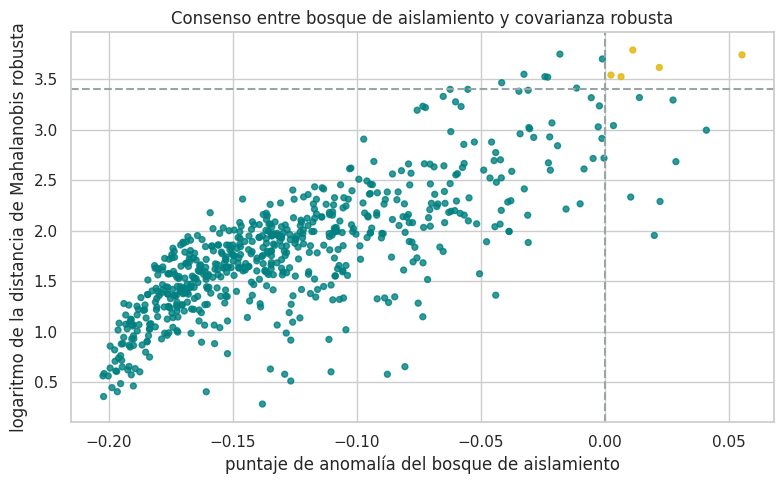

In [ ]:
fig, eje = plt.subplots(figsize=(8, 5))
eje.scatter(puntaje_bosque, np.log1p(distancia_robusta), s=18, c=np.where(formulas["atipico_multivariado"], COLOR_SECUNDARIO, COLOR_PRINCIPAL), alpha=0.8)
eje.axvline(np.percentile(puntaje_bosque, 100 * (1 - CONTAMINACION)), color=COLOR_NEUTRO, linestyle="--")
eje.axhline(np.log1p(np.percentile(distancia_robusta, 100 * (1 - CONTAMINACION))), color=COLOR_NEUTRO, linestyle="--")
eje.set_title("Consenso entre bosque de aislamiento y covarianza robusta")
eje.set_xlabel("puntaje de anomalía del bosque de aislamiento")
eje.set_ylabel("logaritmo de la distancia de Mahalanobis robusta")
fig.tight_layout()
plt.show()

## 9. Ficha V7. `aptitud_vegana`, derivación desde la fórmula

**1. Definición y justificación de negocio.** El filtro vegano forma parte del producto mínimo viable, pero la fuente no publica certificaciones. La aptitud vegana sí puede derivarse de la lista de ingredientes, que es un dato verificable en la etiqueta. La condición de libre de crueldad animal no puede derivarse de la fórmula, porque depende de las prácticas de ensayo de la marca; se resuelve como dato de marca en la sección 12.

**2. Construcción.** A partir del recurso de ingredientes de origen animal de PETA se definen dos conjuntos:

* **Origen animal.** Cera de abeja y sus derivados, miel, lanolina y sus derivados, carmín identificado como CI 75470, goma laca, nácar, seda y colágeno.
* **Origen incierto.** Ingredientes que pueden obtenerse de fuente animal o vegetal sin que la etiqueta lo distinga: escualano, escualeno, colesterol, ácido esteárico y lecitina.

La glicerina se excluye deliberadamente del segundo conjunto: aparece en la mayoría de las fórmulas y se obtiene de forma predominante de fuentes vegetales o sintéticas, de modo que incluirla anularía el poder discriminante de la bandera.

**3. Diagnóstico.** La clasificación se evalúa sobre todas las variantes de la fórmula y no solo sobre la representante, porque el ingrediente de origen animal puede aparecer en el bloque de color de un tono y no en el de otro.

**4. Decisión de tratamiento.** Cuatro categorías ordenadas por severidad:

| Categoría | Regla |
|---|---|
| `no_vegana` | Hay un ingrediente de origen animal en el vehículo, o en los colorantes declarados de todas las variantes |
| `depende_del_tono` | El ingrediente de origen animal aparece solo en los colorantes o en el bloque «May Contain» de alguna variante |
| `origen_incierto` | No hay ingredientes de origen animal, pero sí de origen incierto en el vehículo |
| `vegana_por_formula` | No hay ingredientes de origen animal ni de origen incierto |

La categoría intermedia es la aportación metodológica de esta ficha: un labial puede ser vegano en un tono y no serlo en otro, porque el carmín es un pigmento.

**Limitación declarada.** La aptitud vegana derivada de la fórmula no equivale a una certificación: no considera el origen de los proveedores, los auxiliares de proceso ni los ensayos en animales.

In [ ]:
ORIGEN_ANIMAL = {
    "cera-alba", "polyglyceryl-3-beeswax", "peg-8-beeswax",
    "honey", "honey-extract",
    "lanolin", "lanolin-oil", "lanolin-wax", "acetylated-lanolin", "acetylated-lanolin-alcohol",
    "c10-30-cholesterol-lanosterol-esters",
    "ci-75470", "shellac", "mother-of-pearl",
    "silk", "silk-powder",
    "collagen", "soluble-collagen", "atelocollagen", "hydrolyzed-collagen", "cocoyl-hydrolyzed-collagen",
}
ORIGEN_INCIERTO = {"squalane", "squalene", "cholesterol", "stearic-acid", "lecithin", "hydrogenated-lecithin"}

detalle_vegano = ingredientes.merge(productos[["url", "id_formula"]], on="url")
detalle_vegano["animal"] = detalle_vegano["ingrediente"].isin(ORIGEN_ANIMAL)
detalle_vegano["incierto"] = detalle_vegano["ingrediente"].isin(ORIGEN_INCIERTO)
detalle_vegano["en_vehiculo"] = detalle_vegano["grupo"].eq("base") & ~detalle_vegano["es_colorante"]
detalle_vegano["en_colorante_declarado"] = detalle_vegano["grupo"].eq("base") & detalle_vegano["es_colorante"]

animal_vehiculo = detalle_vegano.loc[detalle_vegano["animal"] & detalle_vegano["en_vehiculo"]].groupby("id_formula").size()
variantes_con_animal = detalle_vegano.loc[detalle_vegano["animal"] & detalle_vegano["en_colorante_declarado"]].groupby("id_formula")["url"].nunique()
animal_cualquiera = detalle_vegano.loc[detalle_vegano["animal"]].groupby("id_formula").size()
incierto_vehiculo = detalle_vegano.loc[detalle_vegano["incierto"] & detalle_vegano["en_vehiculo"]].groupby("id_formula").size()

variantes = formulas.set_index("id_formula")["n_variantes"]
todas_con_animal = variantes_con_animal.reindex(variantes.index, fill_value=0).eq(variantes)
aptitud = pd.Series("vegana_por_formula", index=variantes.index)
aptitud.loc[aptitud.index.isin(incierto_vehiculo.index)] = "origen_incierto"
aptitud.loc[aptitud.index.isin(animal_cualquiera.index)] = "depende_del_tono"
aptitud.loc[todas_con_animal | aptitud.index.isin(animal_vehiculo.index)] = "no_vegana"
formulas["aptitud_vegana"] = formulas["id_formula"].map(aptitud)

print(pd.crosstab(formulas["aptitud_vegana"], formulas["gama"], margins=True).to_string())
print()
print("Ingredientes de origen animal por número de fórmulas en que aparecen")
print(detalle_vegano.loc[detalle_vegano["animal"]].groupby("ingrediente")["id_formula"].nunique().sort_values(ascending=False).to_string())

gama                alta  economica  All
aptitud_vegana                          
depende_del_tono      19         11   30
no_vegana             38         62  100
origen_incierto       35         71  106
vegana_por_formula    55        354  409
All                  147        498  645

Ingredientes de origen animal por número de fórmulas en que aparecen
ingrediente
ci-75470                                62
cera-alba                               42
atelocollagen                           11
soluble-collagen                        10
c10-30-cholesterol-lanosterol-esters    10
cocoyl-hydrolyzed-collagen               9
lanolin-oil                              6
honey                                    5
acetylated-lanolin                       5
mother-of-pearl                          4
polyglyceryl-3-beeswax                   3
silk-powder                              3
peg-8-beeswax                            2
acetylated-lanolin-alcohol               1
hydrolyzed-collagen          

### 9.1 Exportación de la tabla depurada

Se persisten la tabla de fórmulas, la correspondencia entre fórmulas y direcciones, la base química por dirección y las tablas de ingredientes y funciones en su versión depurada. La sección siguiente las consume desde disco, de modo que la limpieza documentada aquí no tenga que repetirse ni pueda divergir.

In [ ]:
COLUMNAS_FORMULA_03A = (
    ["id_formula", "marca", "gama", "huella_base", "url_representante", "slug_representante", "nombre_representante",
     "lineas", "n_variantes", "deteccion", "formato_original", "formatos_distintos", "acabado", "aptitud_vegana"]
    + COLUMNAS_EFECTO + VARIABLES_CONTEO[:4] + VARIABLES_EDITORIALES
    + ["atipico_longitud", "atipico_iforest", "atipico_mcd", "atipico_multivariado", "revision_manual"]
)
formula_direccion = productos[[
    "id_formula", "url", "slug", "marca", "marca_original", "gama", "producto_base", "variante",
    "formato", "acabado", "huella_base", "huella_formulacion", "es_representante",
]].sort_values(["id_formula", "slug"])
base_quimica = (
    base_direccion[["url", "ingrediente", "nombre_ingrediente", "rango_base", "posicion", "calificacion"]]
    .merge(productos[["url", "id_formula", "es_representante"]], on="url", how="left")
    .sort_values(["id_formula", "url", "rango_base"])
)

registrar("n_ingredientes_base", "conteo", "Se conserva sin transformar; extremos marcados", "Cada fórmula es un producto real consultable", "Análisis exploratorio")
registrar("n_colorantes, n_puede_contener", "conteo", "Descriptores excluidos del vehículo", "Incluirlos reintroduciría el color o afirmaría presencias condicionales", "Análisis exploratorio")
registrar("n_variantes", "conteo", "Metadato excluido de la similitud", "La popularidad comercial no es una propiedad química", "Análisis exploratorio")
registrar("acabado", "categórica", "no_declarado se conserva como categoría informativa", "Ausencia por encima del umbral de imputación", "Análisis exploratorio")
registrar("prop_* editorial", "proporción", "Cinco proporciones normalizadas por fórmula", "Traduce la fórmula al lenguaje de la usuaria", "Análisis exploratorio")
registrar("atipico_*", "binaria", "Marcado sin eliminación, por consenso de dos métodos multivariados",
          "Retirar un producto real impediría responder la consulta de la usuaria", "Valores extremos")
registrar("aptitud_vegana", "categórica", "Derivación en cuatro categorías desde la lista de ingredientes",
          "El filtro vegano del producto mínimo viable no cuenta con certificación disponible", "Aptitud vegana")

print(exportar({
    "formulas_base_03a.csv": formulas[COLUMNAS_FORMULA_03A],
    "formula_direccion.csv": formula_direccion,
    "base_quimica.csv": base_quimica,
    "ingredientes_limpios.csv": ingredientes,
    "funciones_limpias.csv": funciones,
}).to_string(index=False))

                 archivo  filas  columnas     kb
   formulas_base_03a.csv    645        35  260.8
   formula_direccion.csv    702        13  160.4
        base_quimica.csv  14399         8 2038.6
ingredientes_limpios.csv  18378         9 2605.7
   funciones_limpias.csv  23063         7 3506.3


## 10. Ingeniería de variables

Esta sección convierte la tabla depurada de fórmulas en la matriz analítica que alimenta el modelo de similitud. La información pasa del nivel ingrediente al nivel fórmula mediante agregaciones con significado cosmético, se construye la representación vectorial del vehículo, se resuelve el formato no determinado mediante imputación multivariada, se cuantifica el contenido informativo de cada variable respecto de la gama y se lleva todo a una escala común.

Cinco constantes gobiernan decisiones que después se aplican de forma mecánica:

* `RANGO_MAXIMO = 15`. Posición a partir de la cual un ingrediente deja de contribuir a la representación. Los ingredientes declarados después suelen encontrarse por debajo del uno por ciento, donde el orden ya no responde a la concentración sino a la conveniencia del fabricante.
* `SOPORTE_MINIMO = 5`. Número mínimo de fórmulas en las que un ingrediente debe aparecer para formar parte del vocabulario. Un ingrediente de una sola fórmula no permite comparar dos productos.
* `SOPORTE_FUNCIONAL = 0.05`. Proporción mínima de fórmulas en las que una función debe aparecer para incorporarse al perfil funcional.
* `EXACTITUD_OBJETIVO = 0.80`. Exactitud mínima exigida a una imputación para considerarla confiable; fija el umbral de probabilidad con la evidencia de la validación cruzada.
* `SEMILLA`. Declarada en la configuración del entorno.

In [ ]:
RANGO_MAXIMO = 15
SOPORTE_MINIMO = 5
SOPORTE_FUNCIONAL = 0.05
EXACTITUD_OBJETIVO = 0.80

formulas = pd.read_csv(DIRECTORIO_ANALITICO / "formulas_base_03a.csv")
formula_direccion = pd.read_csv(DIRECTORIO_ANALITICO / "formula_direccion.csv")
base_quimica = pd.read_csv(DIRECTORIO_ANALITICO / "base_quimica.csv")
funciones = pd.read_csv(DIRECTORIO_ANALITICO / "funciones_limpias.csv")
base_formula = base_quimica.loc[base_quimica["es_representante"]].copy()

longitud_efectiva = base_formula.groupby("id_formula").size().reindex(formulas["id_formula"])
continuidad = base_formula.groupby("id_formula")["rango_base"].agg(["min", "max", "size"])
controles = pd.DataFrame([
    ("Unicidad de la llave de fórmula", formulas["id_formula"].is_unique),
    ("Toda fórmula tiene base química", set(formulas["id_formula"]) <= set(base_formula["id_formula"])),
    ("Toda base química tiene fórmula", set(base_formula["id_formula"]) <= set(formulas["id_formula"])),
    ("Una sola dirección representante por fórmula", bool(base_formula.groupby("id_formula")["url"].nunique().eq(1).all())),
    ("Longitud declarada igual al conteo efectivo", bool((longitud_efectiva.to_numpy() == formulas["n_ingredientes_base"].to_numpy()).all())),
    ("El rango inicia en uno y es continuo", bool(continuidad["min"].eq(1).all() and continuidad["max"].eq(continuidad["size"]).all())),
    ("Integridad referencial de la tabla de funciones", set(funciones["url"]) <= set(formula_direccion["url"])),
], columns=["control", "resultado"])
assert controles["resultado"].all(), "Las entradas de la ingeniería de variables no superan el control de integridad"
print(f"formulas_base_03a: {formulas.shape}; base química de las representantes: {base_formula.shape}")
print()
print(controles.to_string(index=False))

formulas_base_03a: (645, 35); base química de las representantes: (13302, 8)

                                        control  resultado
                Unicidad de la llave de fórmula       True
                Toda fórmula tiene base química       True
                Toda base química tiene fórmula       True
   Una sola dirección representante por fórmula       True
    Longitud declarada igual al conteo efectivo       True
           El rango inicia en uno y es continuo       True
Integridad referencial de la tabla de funciones       True


### Ficha V8. Perfil funcional

**1. Definición y justificación de negocio.** Proporción de ingredientes del vehículo que desempeñan cada función cosmética. Dos fórmulas pueden compartir pocos ingredientes y aun así comportarse igual sobre el labio si reparten sus posiciones entre las mismas familias funcionales: un bálsamo se sostiene sobre emolientes y ceras, un tinte sobre solventes, un brillo sobre polímeros que controlan la viscosidad.

**2. Construcción.** Se cuentan los ingredientes distintos del vehículo que declaran cada función y se divide entre la longitud del vehículo, para que la variable mida arquitectura y no longitud.

**3. Diagnóstico.** Se mide el soporte de cada función, es decir, en qué proporción de las fórmulas aparece al menos una vez.

**4. Decisión de tratamiento.** Se retienen las funciones con soporte igual o superior al mínimo. La función de colorante se excluye por diseño aunque supere el umbral, porque incorporarla reintroduciría el color. La función de filtro solar queda fuera por soporte insuficiente y su información se conserva en la bandera de protección solar.

**5. Aplicación y 6. Validación.** Las fórmulas sin ingredientes de una función reciben un cero, que es el valor correcto y no un dato ausente; se verifica que todas las proporciones queden entre cero y uno.

In [ ]:
NOMBRES_FUNCION = {
    "Emollient": "emoliente", "Viscosity controlling": "control_viscosidad", "Antioxidant": "antioxidante",
    "Perfuming": "perfume", "Preservative": "conservador", "Solvent": "solvente", "Moisturizer/humectant": "humectante",
    "Emulsifying": "emulsionante", "Surfactant/cleansing": "tensioactivo", "Skin-identical ingredient": "identico_piel",
    "Abrasive/scrub": "abrasivo", "Soothing": "calmante", "Antimicrobial/antibacterial": "antimicrobiano",
    "Buffering": "regulador_ph", "Cell-communicating ingredient": "comunicador_celular", "Chelating": "quelante",
    "Exfoliant": "exfoliante", "Skin brightening": "aclarante", "Sunscreen": "filtro_solar", "Anti-acne": "anti_acne",
    "Colorant": "colorante",
}
FUNCIONES_EXCLUIDAS = {"Colorant"}

funcion_base = funciones.merge(base_formula[["url", "id_formula", "ingrediente"]], on=["url", "ingrediente"])
soporte_funcional = funcion_base.groupby("funcion")["id_formula"].nunique().div(len(formulas)).sort_values(ascending=False)
FUNCIONES_RETENIDAS = [f for f in soporte_funcional.index if f not in FUNCIONES_EXCLUIDAS and soporte_funcional[f] >= SOPORTE_FUNCIONAL]

perfil_funcional = (
    funcion_base.loc[funcion_base["funcion"].isin(FUNCIONES_RETENIDAS)]
    .groupby(["id_formula", "funcion"])["ingrediente"].nunique()
    .unstack(fill_value=0)
    .reindex(index=formulas["id_formula"], columns=FUNCIONES_RETENIDAS, fill_value=0)
    .rename(columns=lambda c: "prop_" + NOMBRES_FUNCION[c])
    .div(formulas.set_index("id_formula")["n_ingredientes_base"], axis=0)
)
formulas = formulas.merge(perfil_funcional, left_on="id_formula", right_index=True, how="left")
VARIABLES_FUNCIONALES = list(perfil_funcional.columns)
formulas[VARIABLES_FUNCIONALES] = formulas[VARIABLES_FUNCIONALES].fillna(0.0)
assert formulas[VARIABLES_FUNCIONALES].to_numpy().min() >= 0 and formulas[VARIABLES_FUNCIONALES].to_numpy().max() <= 1

print(pd.DataFrame({
    "funcion": soporte_funcional.index.map(NOMBRES_FUNCION),
    "soporte": soporte_funcional.to_numpy().round(3),
    "retenida": [f in FUNCIONES_RETENIDAS for f in soporte_funcional.index],
}).to_string(index=False))
print()
print(f"Funciones retenidas para el perfil: {len(FUNCIONES_RETENIDAS)} de {len(soporte_funcional)}")

            funcion  soporte  retenida
          emoliente    0.994      True
 control_viscosidad    0.991      True
       antioxidante    0.924      True
            perfume    0.885      True
        conservador    0.800      True
           solvente    0.724      True
         humectante    0.676      True
       emulsionante    0.654      True
       tensioactivo    0.595      True
      identico_piel    0.426      True
           abrasivo    0.347      True
           calmante    0.312      True
     antimicrobiano    0.229      True
       regulador_ph    0.214      True
comunicador_celular    0.141      True
           quelante    0.101      True
         exfoliante    0.071      True
          aclarante    0.070      True
          colorante    0.067     False
       filtro_solar    0.028     False
          anti_acne    0.008     False

Funciones retenidas para el perfil: 18 de 21


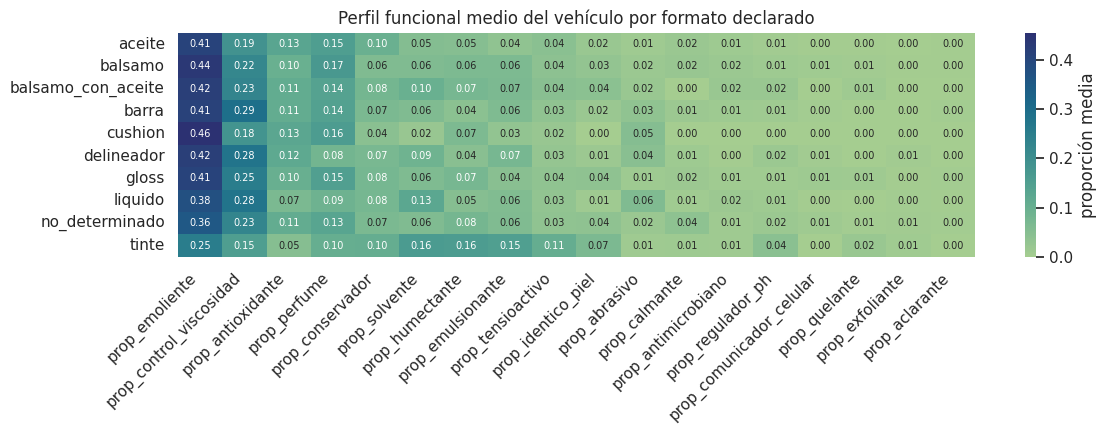

In [ ]:
plt.figure(figsize=(12, 4.5))
sns.heatmap(formulas.groupby("formato_original")[VARIABLES_FUNCIONALES].mean(), annot=True, fmt=".2f", cmap="crest",
            annot_kws={"size": 7}, cbar_kws={"label": "proporción media"})
plt.title("Perfil funcional medio del vehículo por formato declarado")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Ficha V9. `n_destacados`, ingredientes destacados

**1. Definición y justificación de negocio.** Número de ingredientes que la fuente separa en un bloque propio por considerarlos relevantes para el cuidado del labio. Mide el argumento de cuidado que el producto sostiene, distinto de su composición.

**2. Construcción.** Cuando la página presenta dos bloques de funciones, el primero corresponde a los destacados; con un solo bloque la página no destaca ningún ingrediente.

**4. Decisión de tratamiento.** La ausencia de bloque destacado es la afirmación de que la fuente no destacó ningún ingrediente y se codifica como cero.

### Ficha V10. `rango_primer_*`, posición del primer ingrediente funcional clave

**1. Definición y justificación de negocio.** Rango en el que aparece por primera vez un ingrediente emoliente, humectante o de control de viscosidad, las tres funciones que definen la experiencia sensorial. Un humectante declarado en tercer lugar determina la sensación del producto; el mismo humectante en vigésimo lugar es un argumento de etiqueta.

**2. Construcción.** Para cada fórmula y función se toma el rango mínimo entre los ingredientes del vehículo que la declaran.

**4. Decisión de tratamiento.** La ausencia de una función se codifica con la longitud del vehículo más uno, que traduce la ausencia al lenguaje de la variable, donde un valor mayor significa contribución menor, y evita a la vez un dato faltante y un cero que significaría lo contrario de lo observado.

In [ ]:
bloques_por_direccion = funciones.groupby("url")["bloque"].nunique()
destacados = funciones.loc[funciones["url"].map(bloques_por_direccion).gt(1) & funciones["bloque"].eq(1)]
formulas["n_destacados"] = formulas["url_representante"].map(destacados.groupby("url")["ingrediente"].nunique()).fillna(0).astype(int)
assert (formulas["n_destacados"] <= formulas["n_ingredientes_base"] + formulas["n_colorantes"]).all()

FUNCIONES_RANGO = {"Emollient": "emoliente", "Moisturizer/humectant": "humectante", "Viscosity controlling": "control_viscosidad"}
primer_rango = (
    funcion_base.loc[funcion_base["funcion"].isin(FUNCIONES_RANGO)]
    .merge(base_formula[["id_formula", "ingrediente", "rango_base"]], on=["id_formula", "ingrediente"])
    .groupby(["id_formula", "funcion"])["rango_base"].min()
    .unstack()
    .reindex(index=formulas["id_formula"], columns=list(FUNCIONES_RANGO))
    .rename(columns=lambda c: "rango_primer_" + FUNCIONES_RANGO[c])
)
formulas = formulas.merge(primer_rango, left_on="id_formula", right_index=True, how="left")
VARIABLES_RANGO = list(primer_rango.columns)
ausentes_por_funcion = formulas[VARIABLES_RANGO].isna().sum()
for variable in VARIABLES_RANGO:
    formulas[variable] = formulas[variable].fillna(formulas["n_ingredientes_base"] + 1).astype(int)
assert (formulas[VARIABLES_RANGO].max(axis=1) <= formulas["n_ingredientes_base"] + 1).all()

print(formulas.groupby("gama")["n_destacados"].describe().round(2).to_string())
print()
print("Fórmulas sin la función declarada, codificadas con la longitud más uno")
print(ausentes_por_funcion.to_string())
print()
print(formulas[VARIABLES_RANGO].describe().round(2).to_string())

           count  mean   std  min  25%  50%  75%   max
gama                                                  
alta       147.0  3.48  2.54  0.0  1.0  3.0  5.0  11.0
economica  498.0  2.61  1.81  0.0  1.0  2.0  4.0   9.0

Fórmulas sin la función declarada, codificadas con la longitud más uno
rango_primer_emoliente               4
rango_primer_humectante            209
rango_primer_control_viscosidad      6

       rango_primer_emoliente  rango_primer_humectante  rango_primer_control_viscosidad
count                  645.00                   645.00                           645.00
mean                     1.50                    14.25                             3.04
std                      1.64                     6.46                             2.52
min                      1.00                     1.00                             1.00
25%                      1.00                    10.00                             1.00
50%                      1.00                    14.00        

### Ficha V11. Representación vectorial del vehículo

**1. Definición y justificación de negocio.** La comparación entre un producto de gama alta y su alternativa económica se resuelve sobre la composición. Para compararla hace falta convertir cada fórmula en un vector, de modo que la semejanza entre dos productos se calcule como un ángulo entre vectores y no como una impresión.

**2. Construcción.** Se construyen dos representaciones sobre un mismo vocabulario:

* **Presencia.** Vale uno si el ingrediente forma parte del vehículo. Se usa como predictor en la imputación y en el análisis entrópico, donde interesa si el ingrediente está y no dónde está.
* **Pesos por rango.** El peso decae con el rango según el descuento logarítmico de los sistemas de recuperación de información, anulado después del rango máximo:

$$w(r) = \begin{cases} \dfrac{1}{\log_2(r+1)} & r \le 15 \\ 0 & r > 15 \end{cases}$$

El primer ingrediente recibe peso uno y el decimoquinto 0.25. La función de decaimiento definitiva no se fija aquí por convención: se elige con evidencia en la sección 13, que evalúa esta y otras tres alternativas.

**3. Diagnóstico.** Se reporta el tamaño del vocabulario, la densidad de la matriz y la proporción del peso total que retiene el vocabulario.

**4. Decisión de tratamiento.** El vocabulario retiene los ingredientes presentes en al menos cinco fórmulas. El recorte no elimina información útil: un ingrediente exclusivo de una fórmula nunca puede explicar un parecido entre dos productos. Las columnas se ordenan por soporte decreciente y, a igualdad de soporte, por nombre del ingrediente. El desempate explícito no es un detalle cosmético: el bosque aleatorio de la ficha V12 sortea subconjuntos de columnas por su posición, de modo que un orden de columnas que dependiera del algoritmo de ordenamiento del equipo produciría imputaciones distintas en máquinas distintas.

**5. Aplicación y 6. Validación.** Ambas matrices se construyen en formato disperso. La prueba directa de que la representación mide lo que dice medir es que las fórmulas que comparten huella de vehículo pese a pertenecer a marcas distintas alcancen una similitud del coseno igual a uno.

In [ ]:
soporte = base_formula.groupby("ingrediente")["id_formula"].nunique()
vocabulario = (
    soporte.loc[soporte >= SOPORTE_MINIMO].rename("soporte").reset_index()
    .sort_values(["soporte", "ingrediente"], ascending=[False, True])["ingrediente"].tolist()
)
indice_columna = {ingrediente: k for k, ingrediente in enumerate(vocabulario)}
indice_fila = {id_formula: k for k, id_formula in enumerate(formulas["id_formula"])}

base_formula["peso"] = np.where(base_formula["rango_base"] <= RANGO_MAXIMO, 1 / np.log2(base_formula["rango_base"] + 1), 0.0)
base_formula["en_vocabulario"] = base_formula["ingrediente"].isin(indice_columna)
en_vocabulario = base_formula.loc[base_formula["en_vocabulario"]]
filas = en_vocabulario["id_formula"].map(indice_fila).to_numpy()
columnas = en_vocabulario["ingrediente"].map(indice_columna).to_numpy()
dimension = (len(formulas), len(vocabulario))

matriz_presencia = sparse.csr_matrix((np.ones(len(filas)), (filas, columnas)), shape=dimension)
matriz_ponderada = sparse.csr_matrix((en_vocabulario["peso"].to_numpy(), (filas, columnas)), shape=dimension)
matriz_ponderada.eliminate_zeros()
cobertura_masa = en_vocabulario.groupby("id_formula")["peso"].sum().div(base_formula.groupby("id_formula")["peso"].sum())
assert matriz_presencia.getnnz(axis=1).min() > 0, "Hay fórmulas sin representación en el vocabulario"

print(f"Ingredientes distintos en el vehículo: {len(soporte)}")
print(f"Ingredientes en el vocabulario: {len(vocabulario)}")
print(f"Ingredientes presentes en una sola fórmula: {int(soporte.eq(1).sum())}")
print(f"Dimensión de las matrices: {dimension}")
print(f"Densidad de la matriz ponderada: {matriz_ponderada.nnz / np.prod(dimension):.4f}")
print(f"Proporción media del peso total retenida por el vocabulario: {cobertura_masa.mean():.3f}")

gemelas = formulas.groupby("huella_base").filter(lambda g: g["marca"].nunique() > 1)
posiciones_gemelas = [indice_fila[i] for i in gemelas["id_formula"]]
similitud_gemelas = cosine_similarity(matriz_ponderada[posiciones_gemelas])
assert np.isclose(similitud_gemelas[np.triu_indices(len(posiciones_gemelas), k=1)].max(), 1.0), "La representación no reproduce la identidad de vehículos gemelos"
print()
print(gemelas[["id_formula", "marca", "nombre_representante", "huella_base"]].to_string(index=False))
print(f"Similitud del coseno entre los vehículos gemelos: {similitud_gemelas[0, 1]:.4f}")

Ingredientes distintos en el vehículo: 1004
Ingredientes en el vocabulario: 378
Ingredientes presentes en una sola fórmula: 352
Dimensión de las matrices: (645, 378)
Densidad de la matriz ponderada: 0.0349
Proporción media del peso total retenida por el vocabulario: 0.938

id_formula marca            nombre_representante  huella_base
     F0360  kiko Creamy Colour Comfort Lip Liner 5be4758e6430
     F0501   nyx            Line Loud Lip Pencil 5be4758e6430
Similitud del coseno entre los vehículos gemelos: 1.0000


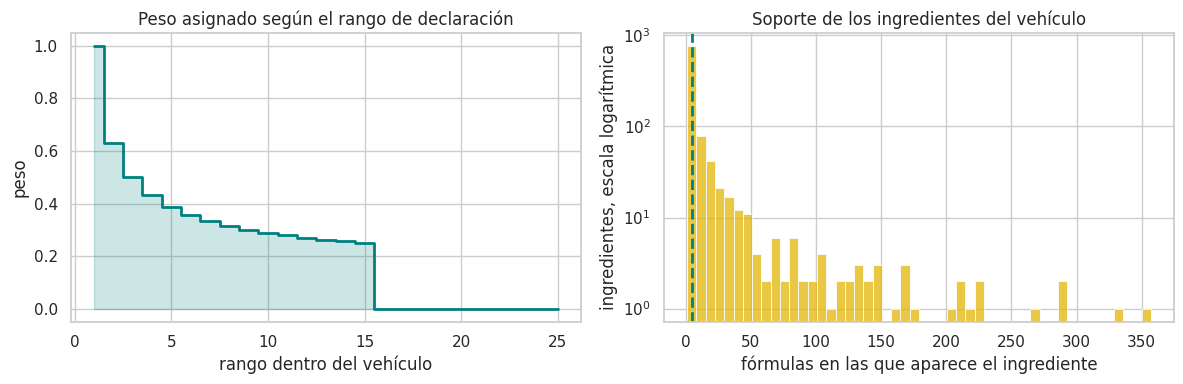

In [ ]:
rangos_ilustrativos = np.arange(1, 26)
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
pesos_ilustrativos = np.where(rangos_ilustrativos <= RANGO_MAXIMO, 1 / np.log2(rangos_ilustrativos + 1), 0.0)
ejes[0].step(rangos_ilustrativos, pesos_ilustrativos, where="mid", color=COLOR_PRINCIPAL, linewidth=2)
ejes[0].fill_between(rangos_ilustrativos, pesos_ilustrativos, step="mid", color=COLOR_PRINCIPAL, alpha=0.2)
ejes[0].set_title("Peso asignado según el rango de declaración")
ejes[0].set_xlabel("rango dentro del vehículo")
ejes[0].set_ylabel("peso")
sns.histplot(soporte, bins=50, color=COLOR_SECUNDARIO, ax=ejes[1])
ejes[1].axvline(SOPORTE_MINIMO, color=COLOR_PRINCIPAL, linestyle="--", linewidth=2)
ejes[1].set_yscale("log")
ejes[1].set_title("Soporte de los ingredientes del vehículo")
ejes[1].set_xlabel("fórmulas en las que aparece el ingrediente")
ejes[1].set_ylabel("ingredientes, escala logarítmica")
fig.tight_layout()
plt.show()

### Ficha V12. `formato`, imputación multivariada

**1. Definición y justificación de negocio.** Presentación física del producto. Es la única variable con ausencia imputable, y dejarla sin resolver retiraría de la oferta filtrada a las fórmulas afectadas, que son las que ninguna búsqueda por formato encontraría.

**2. Construcción y 3. Diagnóstico.** Las fórmulas cuyo nombre comercial no revela la presentación conservan la etiqueta de no determinado. Dos clases tienen menos de cinco fórmulas y no admiten validación cruzada estratificada: el bálsamo con aceite se integra al bálsamo, porque su vehículo es una base cerosa con aceites añadidos, y el cushion se integra al tinte, porque los dos productos del catálogo son tintes aplicados con esponja.

**4. Decisión de tratamiento.** Se imputa con un clasificador multiclase de bosque aleatorio, ajustado sobre las fórmulas de formato conocido, con la composición como predictor. La imputación por ecuaciones encadenadas ajusta de forma iterativa un modelo por cada variable incompleta, condicionado a las demás; cuando una sola variable presenta ausencias, el ciclo se reduce a un único modelo condicional y las iteraciones no modifican el resultado, de modo que el procedimiento equivale a ajustar directamente ese modelo. Se elige un clasificador y no un regresor porque el formato es nominal: codificar las categorías como enteros supondría un orden entre presentaciones que no existe.

**5. Aplicación.** Los predictores son la matriz de presencia, el perfil funcional, el perfil editorial, los rangos funcionales, la longitud del vehículo y el número de destacados; es decir, el formato se infiere de la fórmula y no del nombre, que es precisamente el dato que falta. La validación cruzada es estratificada y agrupada por línea comercial: la agrupación impide que dos fórmulas de una misma línea aparezcan a la vez en entrenamiento y en prueba, lo que produciría una estimación optimista. Se compara contra un clasificador que siempre predice la clase mayoritaria.

**6. Validación.** Se contrasta la exactitud y la medida F1 macro contra la referencia, se elige el umbral de confianza con la evidencia de la validación cruzada, se marcan las imputaciones que no lo alcanzan y se comprueba con una prueba ji cuadrada que la distribución de formatos imputados no distorsione la composición del catálogo.

In [ ]:
RECATEGORIZACION_FORMATO = {"balsamo_con_aceite": "balsamo", "cushion": "tinte"}
formulas["formato_recategorizado"] = formulas["formato_original"].replace(RECATEGORIZACION_FORMATO)
VARIABLES_EDITORIALES = [c for c in formulas.columns if c.startswith("prop_") and c not in VARIABLES_FUNCIONALES]
VARIABLES_PERFIL = ["n_ingredientes_base", "n_funciones", "n_destacados"] + VARIABLES_FUNCIONALES + VARIABLES_EDITORIALES + VARIABLES_RANGO

predictores = sparse.hstack([matriz_presencia, sparse.csr_matrix(formulas[VARIABLES_PERFIL].to_numpy(dtype=float))]).tocsr()
conocido = formulas["formato_recategorizado"].ne("no_determinado").to_numpy()
x_conocido = predictores[conocido]
y_conocido = formulas.loc[conocido, "formato_recategorizado"].to_numpy()
grupos = (formulas.loc[conocido, "marca"] + "|" + formulas.loc[conocido, "lineas"].str.split("|").str[0]).to_numpy()

validacion = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
clasificador = RandomForestClassifier(n_estimators=500, class_weight="balanced", min_samples_leaf=2, random_state=SEMILLA, n_jobs=-1)
referencia = DummyClassifier(strategy="most_frequent")

probabilidad_cv = cross_val_predict(clasificador, x_conocido, y_conocido, cv=validacion, groups=grupos, method="predict_proba")
clases = np.array(sorted(set(y_conocido)))
prediccion_cv = clases[probabilidad_cv.argmax(axis=1)]
confianza_cv = probabilidad_cv.max(axis=1)
prediccion_referencia = cross_val_predict(referencia, x_conocido, y_conocido, cv=validacion, groups=grupos)

print(f"Variables del perfil: {len(VARIABLES_PERFIL)}; dimensión de los predictores: {predictores.shape}")
print(f"Fórmulas con formato conocido: {int(conocido.sum())}; por imputar: {int((~conocido).sum())}; líneas usadas como grupo: {len(set(grupos))}")
print()
print(pd.DataFrame({
    "modelo": ["clase mayoritaria", "bosque aleatorio"],
    "exactitud": [accuracy_score(y_conocido, prediccion_referencia), accuracy_score(y_conocido, prediccion_cv)],
    "F1_macro": [f1_score(y_conocido, prediccion_referencia, average="macro", zero_division=0),
                 f1_score(y_conocido, prediccion_cv, average="macro", zero_division=0)],
}).round(4).to_string(index=False))
print()
print(classification_report(y_conocido, prediccion_cv, digits=3, zero_division=0))

Variables del perfil: 29; dimensión de los predictores: (645, 407)
Fórmulas con formato conocido: 580; por imputar: 65; líneas usadas como grupo: 529

           modelo  exactitud  F1_macro
clase mayoritaria     0.2759    0.0618
 bosque aleatorio     0.6310    0.6214

              precision    recall  f1-score   support

      aceite      0.627     0.600     0.613        70
     balsamo      0.641     0.681     0.661       160
       barra      0.597     0.675     0.634       123
  delineador      0.808     0.447     0.575        47
       gloss      0.617     0.617     0.617       107
     liquido      0.583     0.583     0.583        36
       tinte      0.686     0.649     0.667        37

    accuracy                          0.631       580
   macro avg      0.651     0.607     0.621       580
weighted avg      0.638     0.631     0.630       580



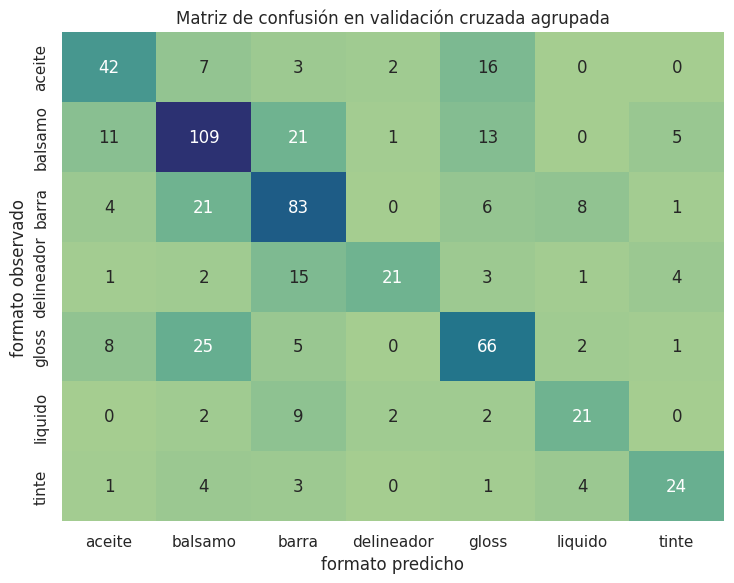

In [ ]:
plt.figure(figsize=(7.5, 6))
sns.heatmap(pd.DataFrame(confusion_matrix(y_conocido, prediccion_cv, labels=list(clases)), index=clases, columns=clases),
            annot=True, fmt="d", cmap="crest", cbar=False)
plt.title("Matriz de confusión en validación cruzada agrupada")
plt.xlabel("formato predicho")
plt.ylabel("formato observado")
plt.tight_layout()
plt.show()

**Umbral de confianza.** Un bosque aleatorio con siete clases reparte la probabilidad entre varias de ellas, de modo que un umbral tomado de la costumbre carece de interpretación. El umbral es el menor valor de probabilidad máxima a partir del cual la exactitud de las predicciones en validación cruzada alcanza el objetivo declarado. Por debajo de él la imputación conserva el formato asignado pero queda marcada, y cualquier filtro por formato debe tratar esas fórmulas con flexibilidad.

In [ ]:
umbrales = np.round(np.arange(0.20, 0.81, 0.05), 2)
curva_confianza = pd.DataFrame([
    {"umbral": t, "cobertura": (confianza_cv >= t).mean(),
     "exactitud": accuracy_score(y_conocido[confianza_cv >= t], prediccion_cv[confianza_cv >= t])}
    for t in umbrales if (confianza_cv >= t).sum() > 0
])
alcanzan = curva_confianza.loc[curva_confianza["exactitud"] >= EXACTITUD_OBJETIVO, "umbral"]
UMBRAL_CONFIANZA_FORMATO = float(alcanzan.min()) if not alcanzan.empty else float(curva_confianza["umbral"].max())

clasificador.fit(x_conocido, y_conocido)
probabilidades = clasificador.predict_proba(predictores[~conocido])
formulas["formato"] = formulas["formato_recategorizado"]
formulas.loc[~conocido, "formato"] = clasificador.classes_[probabilidades.argmax(axis=1)]
formulas["formato_imputado"] = ~conocido
formulas["confianza_formato"] = 1.0
formulas.loc[~conocido, "confianza_formato"] = probabilidades.max(axis=1)
formulas["formato_baja_confianza"] = formulas["confianza_formato"] < UMBRAL_CONFIANZA_FORMATO
assert formulas["formato"].ne("no_determinado").all(), "Quedan fórmulas sin formato resuelto"

comparacion_imputacion = pd.crosstab(formulas["formato"], formulas["formato_imputado"]).rename(columns={False: "observado", True: "imputado"})
chi2_imputacion, valor_p_imputacion, _, _ = chi2_contingency(comparacion_imputacion)

print(curva_confianza.round(3).to_string(index=False))
print()
print(f"Umbral de confianza seleccionado: {UMBRAL_CONFIANZA_FORMATO}")
print(f"Imputaciones de baja confianza: {int(formulas.loc[~conocido, 'formato_baja_confianza'].sum())} de {int((~conocido).sum())}")
print()
print(comparacion_imputacion.assign(
    prop_observado=(comparacion_imputacion["observado"] / comparacion_imputacion["observado"].sum()).round(3),
    prop_imputado=(comparacion_imputacion["imputado"] / comparacion_imputacion["imputado"].sum()).round(3),
).to_string())
print(f"Ji cuadrada: {chi2_imputacion:.3f}, valor p: {valor_p_imputacion:.4f}")

 umbral  cobertura  exactitud
   0.20      1.000      0.631
   0.25      0.931      0.656
   0.30      0.774      0.684
   0.35      0.588      0.760
   0.40      0.428      0.802
   0.45      0.307      0.876
   0.50      0.217      0.897
   0.55      0.166      0.896
   0.60      0.114      0.909
   0.65      0.072      0.976
   0.70      0.047      0.963
   0.75      0.034      0.950
   0.80      0.016      1.000

Umbral de confianza seleccionado: 0.4
Imputaciones de baja confianza: 50 de 65

formato_imputado  observado  imputado  prop_observado  prop_imputado
formato                                                             
aceite                   70         8           0.121          0.123
balsamo                 160        25           0.276          0.385
barra                   123        11           0.212          0.169
delineador               47         1           0.081          0.015
gloss                   107        14           0.184          0.215
liquido         

El bosque aleatorio más que duplica la exactitud de la referencia mayoritaria y multiplica cerca de diez veces su F1 macro, con un desempeño parejo entre clases salvo en el delineador, que el modelo tiende a confundir con la barra por la similitud de sus vehículos cerosos. Con el umbral seleccionado, la exactitud supera el ochenta por ciento sobre la fracción de predicciones que lo alcanzan. La prueba ji cuadrada no rechaza que los formatos imputados sigan la misma distribución que los observados al cinco por ciento, de modo que la imputación completa el catálogo sin distorsionar su composición.

### 10.1 Transformaciones entrópicas

Esta subsección cuantifica cuánta información aporta cada variable para distinguir una fórmula de gama alta de una económica. El propósito no es predecir la gama, que ya se conoce, sino responder con evidencia propia la pregunta que sostiene el proyecto: qué paga la consumidora cuando compra lujo. Si pocos ingredientes separan a las dos gamas, la base química de ambos segmentos es en gran medida intercambiable.

**Información mutua.** Mide la reducción de incertidumbre sobre la gama que se obtiene al conocer la variable. Vale cero cuando ambas son independientes y no supone ninguna forma funcional.

**Peso de la evidencia y valor de información.** Para cada categoría de la variable,

$$\text{WoE} = \ln\frac{\%\,\text{alta}}{\%\,\text{económica}}, \qquad \text{IV} = \sum (\%\,\text{alta} - \%\,\text{económica}) \cdot \text{WoE}.$$

Un peso positivo indica asociación con la gama alta. Cuando un ingrediente aparece solo en una gama, una proporción es cero y el logaritmo diverge; se suma un medio a cada conteo, que es la corrección de continuidad habitual. Las variables continuas se discretizan en quintiles, y cuando la acumulación de ceros impide formar dos intervalos se contrasta la presencia contra la ausencia. En la escala convencional, un valor de información menor que 0.02 no discrimina, entre 0.02 y 0.1 es débil, entre 0.1 y 0.3 medio, por encima de 0.3 fuerte, y por encima de 0.5 conviene sospechar que la variable identifica a la marca en lugar de describir a la fórmula.

In [ ]:
def informacion_mutua(X, y, discreta):
    mi = mutual_info_classif(X, y, discrete_features=discreta, random_state=SEMILLA)
    return pd.DataFrame({"Variable": X.columns, "Mutual_Information": mi}).sort_values("Mutual_Information", ascending=False, kind="stable").reset_index(drop=True)


def woe_iv(df, variable, objetivo, bins=5, discretizar=False):
    datos = df[[variable, objetivo]].copy()
    if discretizar:
        cortes = pd.qcut(datos[variable], q=bins, duplicates="drop")
        if cortes.nunique() < 2:
            cortes = datos[variable].gt(datos[variable].median())
        datos[variable] = cortes
    conteos = pd.crosstab(datos[variable], datos[objetivo]).reindex(columns=[0, 1], fill_value=0) + 0.5
    tabla = conteos / conteos.sum()
    tabla.columns = ["%economica", "%alta"]
    tabla["WoE"] = np.log(tabla["%alta"] / tabla["%economica"])
    tabla["IV_contrib"] = (tabla["%alta"] - tabla["%economica"]) * tabla["WoE"]
    return tabla, tabla["IV_contrib"].sum()


def tabla_iv(df, variables, objetivo, bins=5, discretizar=False):
    filas_iv = []
    for variable in variables:
        tabla, iv = woe_iv(df, variable, objetivo, bins=bins, discretizar=discretizar)
        filas_iv.append({"Variable": variable, "IV": iv, "WoE_categoria_superior": tabla["WoE"].iloc[-1]})
    return pd.DataFrame(filas_iv).sort_values("IV", ascending=False, kind="stable").reset_index(drop=True)


objetivo_gama = formulas["gama"].eq("alta").astype(int)
presencia_df = pd.DataFrame(matriz_presencia.toarray().astype(int), columns=vocabulario)
presencia_df["es_alta"] = objetivo_gama.to_numpy()
entropia_ingredientes = (
    informacion_mutua(presencia_df[vocabulario], presencia_df["es_alta"], discreta=True)
    .merge(tabla_iv(presencia_df, vocabulario, "es_alta"), on="Variable")
)
entropia_ingredientes["asociacion"] = np.where(entropia_ingredientes["WoE_categoria_superior"] > 0, "alta", "economica")
entropia_ingredientes["soporte"] = entropia_ingredientes["Variable"].map(soporte)
entropia_ingredientes = entropia_ingredientes.sort_values("IV", ascending=False, kind="stable").reset_index(drop=True)

perfil_df = formulas[VARIABLES_PERFIL].copy()
perfil_df["es_alta"] = objetivo_gama.to_numpy()
entropia_perfil = (
    informacion_mutua(perfil_df[VARIABLES_PERFIL], perfil_df["es_alta"], discreta=False)
    .merge(tabla_iv(perfil_df, VARIABLES_PERFIL, "es_alta", bins=5, discretizar=True), on="Variable")
    .sort_values("IV", ascending=False, kind="stable").reset_index(drop=True)
)

print("Quince ingredientes con mayor valor de información")
print(entropia_ingredientes.head(15).round(4).to_string(index=False))
print()
print("Reparto del vocabulario según la escala convencional del valor de información")
print(pd.cut(entropia_ingredientes["IV"], [-np.inf, 0.02, 0.1, 0.3, 0.5, np.inf],
             labels=["sin poder", "débil", "medio", "fuerte", "sospechoso"]).value_counts().sort_index().to_string())
print()
print("Variables del perfil con mayor valor de información")
print(entropia_perfil.head(10).round(4).to_string(index=False))

Quince ingredientes con mayor valor de información
                         Variable  Mutual_Information     IV  WoE_categoria_superior asociacion  soporte
                    polyisobutene              0.0471 0.7951                 -3.1708  economica      121
        tetrahexyldecyl-ascorbate              0.0379 0.4624                  3.3195       alta       22
                   propyl-gallate              0.0389 0.4541                  2.8683       alta       27
            tridecyl-trimellitate              0.0319 0.4376                 -1.8798  economica      126
                      cholesterol              0.0305 0.4155                  4.5112       alta       13
trimethylolpropane-triisostearate              0.0365 0.4103                  2.3525       alta       34
                    jojoba-esters              0.0288 0.3424                  3.1025       alta       18
               ethylhexylglycerin              0.0261 0.3369                 -1.4848  economica      134
    

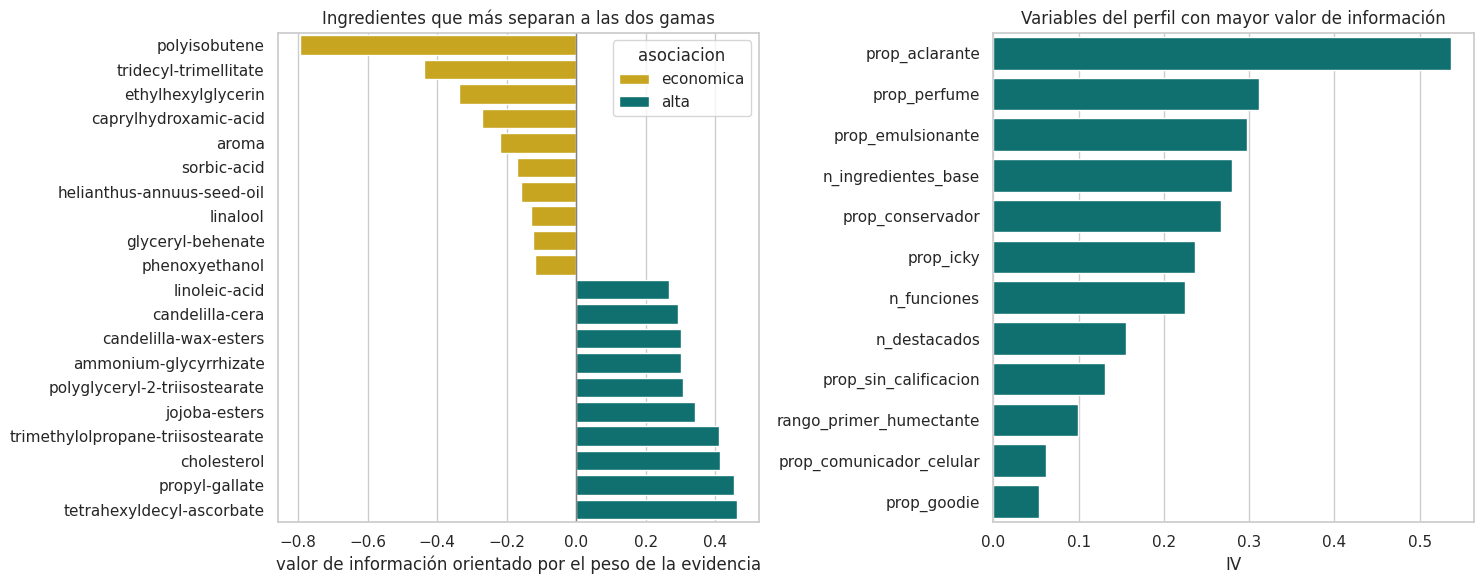

In [ ]:
marcadores = pd.concat([
    entropia_ingredientes.loc[entropia_ingredientes["asociacion"].eq("alta")].head(10),
    entropia_ingredientes.loc[entropia_ingredientes["asociacion"].eq("economica")].head(10),
])
marcadores["IV_orientado"] = np.where(marcadores["asociacion"].eq("alta"), marcadores["IV"], -marcadores["IV"])
fig, ejes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=marcadores.sort_values("IV_orientado"), y="Variable", x="IV_orientado", hue="asociacion", dodge=False,
            palette={"alta": COLOR_PRINCIPAL, "economica": COLOR_SECUNDARIO}, ax=ejes[0])
ejes[0].axvline(0, color="grey", linewidth=1)
ejes[0].set_title("Ingredientes que más separan a las dos gamas")
ejes[0].set_xlabel("valor de información orientado por el peso de la evidencia")
sns.barplot(data=entropia_perfil.head(12), y="Variable", x="IV", color=COLOR_PRINCIPAL, ax=ejes[1])
ejes[1].set_title("Variables del perfil con mayor valor de información")
for eje in ejes:
    eje.set_ylabel("")
fig.tight_layout()
plt.show()

**Lectura.** De los 378 ingredientes del vocabulario, más de la mitad no tiene poder discriminante sobre la gama y solo una decena alcanza un valor de información fuerte. El único con valor sospechoso, el poliisobuteno, es un polímero que las marcas económicas del catálogo emplean de forma casi exclusiva: identifica un estilo de formulación de ciertas marcas más que una diferencia de calidad. En el perfil funcional, las variables con más información son la proporción de agentes aclarantes y la carga de perfume, atributos de posicionamiento y de experiencia olfativa que no definen la textura; las variables que sí la definen, como la carga emoliente y el control de viscosidad, tienen un valor de información débil o nulo. La evidencia sostiene la premisa del proyecto: la base química de las dos gamas es en gran medida intercambiable y la diferencia de precio no se explica por la arquitectura del vehículo.

### 10.2 Escalamiento

Las variables del perfil combinan conteos, proporciones y rangos cuyas escalas difieren en órdenes de magnitud. Sin una escala común, cualquier medida de distancia quedaría dominada por las variables de rango mayor. Se aplica el escalamiento por mínimo y máximo, que lleva cada variable al intervalo de cero a uno. Se prefiere a la estandarización porque conserva los ceros de las proporciones, que indican la ausencia de una familia funcional, y porque no supone simetría en la distribución. Los parámetros del escalador se exportan para que el flujo de consulta aplique exactamente la misma transformación a un producto nuevo.

In [ ]:
escalador = MinMaxScaler()
perfil_escalado = pd.DataFrame(escalador.fit_transform(formulas[VARIABLES_PERFIL]), columns=VARIABLES_PERFIL, index=formulas["id_formula"])
assert perfil_escalado.to_numpy().min() >= 0.0 and perfil_escalado.to_numpy().max() <= 1.0
parametros_escalador = pd.DataFrame({"variable": VARIABLES_PERFIL, "minimo": escalador.data_min_, "maximo": escalador.data_max_})
print(perfil_escalado.describe().loc[["min", "max", "mean", "std"]].round(3).T.to_string())

                                 min  max   mean    std
n_ingredientes_base              0.0  1.0  0.308  0.146
n_funciones                      0.0  1.0  0.478  0.219
n_destacados                     0.0  1.0  0.256  0.184
prop_emoliente                   0.0  1.0  0.489  0.156
prop_control_viscosidad          0.0  1.0  0.393  0.166
prop_antioxidante                0.0  1.0  0.267  0.157
prop_perfume                     0.0  1.0  0.265  0.187
prop_conservador                 0.0  1.0  0.256  0.196
prop_solvente                    0.0  1.0  0.159  0.149
prop_humectante                  0.0  1.0  0.129  0.132
prop_emulsionante                0.0  1.0  0.159  0.164
prop_tensioactivo                0.0  1.0  0.130  0.139
prop_identico_piel               0.0  1.0  0.120  0.171
prop_abrasivo                    0.0  1.0  0.100  0.166
prop_calmante                    0.0  1.0  0.105  0.178
prop_antimicrobiano              0.0  1.0  0.058  0.119
prop_regulador_ph                0.0  1.0  0.068

### 10.3 Exportación de la tabla analítica

Se exportan la tabla analítica completa, las dos matrices dispersas, el vocabulario con su contenido informativo, la base química ponderada, el perfil escalado y los parámetros del escalador. Ese conjunto es la entrada del modelo de similitud y del flujo de consulta.

In [ ]:
registrar("perfil funcional", "proporción", f"Dieciocho funciones con soporte mínimo de {SOPORTE_FUNCIONAL:.0%}, sin la función de colorante",
          "Describe la arquitectura del vehículo; el color queda fuera de la representación por diseño", "Ingeniería de variables")
registrar("n_destacados", "conteo", "Conteo del primer bloque de funciones, cero cuando la página no destaca ingredientes",
          "Mide el argumento de cuidado declarado, distinto de la composición", "Ingeniería de variables")
registrar("rango_primer_*", "ordinal", "Rango mínimo por función clave; la ausencia se codifica con la longitud más uno",
          "La posición aproxima la concentración: una función declarada al final aporta poco", "Ingeniería de variables")
registrar("vocabulario", "criterio", f"Ingredientes presentes en al menos {SOPORTE_MINIMO} fórmulas",
          "Un ingrediente de una sola fórmula no puede explicar un parecido entre dos productos", "Ingeniería de variables")
registrar("formato", "categórica", "Imputación multivariada con bosque aleatorio y validación agrupada por línea",
          "Ausencia imputable; sin formato la fórmula quedaría fuera de toda búsqueda filtrada", "Ingeniería de variables")
registrar("confianza_formato", "continua", f"Probabilidad de la clase asignada, con umbral en {UMBRAL_CONFIANZA_FORMATO}",
          "Distingue la imputación confiable de la que exige flexibilidad en el filtro", "Ingeniería de variables")
registrar("información mutua e IV", "diagnóstico", "Cuantificación del contenido informativo respecto de la gama",
          "Sostiene con datos propios la premisa comercial del proyecto", "Ingeniería de variables")
registrar("perfil escalado", "continua", "Escalamiento por mínimo y máximo, con parámetros conservados",
          "Impide que la unidad de medida domine la distancia y hace comparables dos sesiones", "Ingeniería de variables")

COLUMNAS_FORMULA_03B = (
    ["id_formula", "marca", "gama", "huella_base", "url_representante", "slug_representante", "nombre_representante",
     "lineas", "n_variantes", "deteccion", "formato", "formato_original", "formato_imputado", "confianza_formato",
     "formato_baja_confianza", "formatos_distintos", "acabado", "aptitud_vegana"]
    + [c for c in formulas.columns if c.startswith("efecto_")]
    + VARIABLES_PERFIL
    + ["n_colorantes", "n_puede_contener", "atipico_longitud", "atipico_iforest", "atipico_mcd", "atipico_multivariado", "revision_manual"]
)
vocabulario_base = pd.DataFrame({
    "columna": range(len(vocabulario)), "ingrediente": vocabulario, "soporte": soporte.loc[vocabulario].to_numpy(),
}).merge(
    entropia_ingredientes[["Variable", "Mutual_Information", "IV", "WoE_categoria_superior", "asociacion"]],
    left_on="ingrediente", right_on="Variable", how="left",
).drop(columns="Variable")
base_quimica_ponderada = base_formula[
    ["id_formula", "url", "rango_base", "ingrediente", "nombre_ingrediente", "calificacion", "peso", "en_vocabulario"]
].sort_values(["id_formula", "rango_base"])

assert (formulas["id_formula"].to_numpy() == perfil_escalado.index.to_numpy()).all()
sparse.save_npz(DIRECTORIO_ANALITICO / "matriz_base_ponderada.npz", matriz_ponderada)
sparse.save_npz(DIRECTORIO_ANALITICO / "matriz_base_presencia.npz", matriz_presencia)
print(exportar({
    "formulas_base_03b.csv": formulas[COLUMNAS_FORMULA_03B],
    "perfil_formulas_escalado.csv": perfil_escalado.reset_index(),
    "base_quimica_ponderada.csv": base_quimica_ponderada,
    "vocabulario_base.csv": vocabulario_base,
    "entropia_perfil.csv": entropia_perfil,
    "entropia_ingredientes.csv": entropia_ingredientes,
    "parametros_escalador.csv": parametros_escalador,
}).to_string(index=False))

                     archivo  filas  columnas     kb
       formulas_base_03b.csv    645        61  400.8
perfil_formulas_escalado.csv    645        30  232.4
  base_quimica_ponderada.csv  13302         8 2006.5
        vocabulario_base.csv    378         7   36.1
         entropia_perfil.csv     29         4    2.1
   entropia_ingredientes.csv    378         6   34.7
    parametros_escalador.csv     29         3    1.0


## 11. Capa de presentación: nombre comercial y línea

**Fundamento.** La unidad de análisis del modelo es la fórmula base, porque dos tonos de una misma línea pueden declarar vehículos distintos y el modelo debe tratarlos como objetos distintos. La unidad de presentación es otra: quien consulta reconoce productos comerciales, no vehículos. Un producto con ocho sabores aparecería ocho veces si la interfaz adoptara la unidad del modelo, y esa repetición se leería como un defecto del catálogo aunque la representación química fuera correcta.

Esta sección introduce la unidad de presentación sin alterar la unidad de análisis. Las fórmulas, sus identificadores, sus vectores y la matriz de similitud permanecen intactos; lo que se agrega es una capa de nombres y una clave de agrupación que la interfaz consume para mostrar un producto una sola vez y enumerar sus variantes.

**Origen del problema.** La separación entre producto y tono en la recolección exige que el tono declare un código numérico después del primer token del identificador. Los tonos nombrados sin código quedan incorporados al nombre del producto, y como la tabla de fórmulas toma como nombre visible el título de página de su dirección representante, el tono incorporado se propaga hasta la pantalla.

Cuatro constantes gobiernan las decisiones de esta sección:

* `LONGITUD_MINIMA_LINEA = 2`. Número mínimo de tokens que debe conservar una línea para ser candidata; evita que un identificador corto absorba productos distintos que comparten su raíz.
* `TOKENS_MAXIMOS_TONO = 4`. Extensión máxima que se admite para un nombre de tono sin código numérico; un residuo más largo describe un producto y no un color.
* `UMBRAL_GAMA_AMPLIA = 4`. Número de fórmulas de una línea a partir del cual la evidencia de una gama de tonos se considera suficiente por sí misma.
* `RETIRAR_SIMBOLOS_DE_MARCA = True`. Los símbolos de marca registrada son notación legal y no ortografía del producto.

In [ ]:
LONGITUD_MINIMA_LINEA = 2
TOKENS_MAXIMOS_TONO = 4
UMBRAL_GAMA_AMPLIA = 4
RETIRAR_SIMBOLOS_DE_MARCA = True
SIMBOLOS_DE_MARCA = "™®©"

productos_nombres = productos_inci.loc[productos_inci["en_alcance"].astype(bool)].reset_index(drop=True)
formulas_nombres = pd.read_csv(DIRECTORIO_ANALITICO / "formulas_base_03b.csv")

controles = pd.DataFrame([
    ("La llave de fórmula es única", formulas_nombres["id_formula"].is_unique),
    ("Toda fórmula tiene dirección representante en la extracción", bool(formulas_nombres["url_representante"].isin(set(productos_nombres["url"])).all())),
    ("Las marcas coinciden entre ambas tablas", set(formulas_nombres["marca"]) == set(productos_nombres["marca"])),
    ("Toda dirección declara producto base", bool(productos_nombres["producto_base"].notna().all())),
], columns=["control", "resultado"])
assert controles["resultado"].all(), "Las entradas de la capa de nombres no superan el control de integridad"
print(controles.to_string(index=False))

                                                    control  resultado
                               La llave de fórmula es única       True
Toda fórmula tiene dirección representante en la extracción       True
                    Las marcas coinciden entre ambas tablas       True
                       Toda dirección declara producto base       True


### Ficha N1. Saneamiento del descriptor

**1. Definición y justificación de negocio.** El producto base se obtuvo retirando del identificador el patrón de marca reconocido. Ese corte es sintáctico y deja dos residuos: el eco de marca, porque la fuente registra algunos productos con el nombre corporativo completo y retirar el patrón corto deja fragmentos como el sufijo corporativo o la ciudad de origen; y el sufijo de desambiguación, un dígito que la fuente agrega cuando publica dos fichas del mismo producto.

**2. Construcción.** El eco se retira con un diccionario declarado por marca, aplicado de forma iterativa hasta que el descriptor deja de cambiar. El sufijo se retira únicamente cuando el descriptor resultante existe como descriptor de otro producto de la misma marca: esa condición distingue un sufijo de desambiguación de un código de tono de un solo dígito, porque el primero tiene un hermano sin sufijo y el segundo no.

**4. Decisión de tratamiento y 6. Validación.** El descriptor saneado sustituye al producto base como insumo de la resolución de línea; se verifica que no queden descriptores vacíos y que todo descriptor siga siendo parte del identificador original.

In [ ]:
ECOS_DE_MARCA = {
    "benefit": ["cosmetics"], "charlotte-tilbury": ["cosmetics"], "elf": ["cosmetics"], "fenty-beauty": ["beauty"],
    "kiko": ["milano"], "loreal": ["paris"], "mac": ["cosmetics"], "maybelline": ["new-york"], "milani": ["cosmetics"],
    "nyx": ["professional-makeup", "cosmetics"], "revolution": ["makeup", "haircare", "skincare", "beauty"],
    "too-faced": ["cosmetics"], "wet-n-wild": ["cosmetics"],
}


def retirar_eco(marca, descriptor):
    cambio = True
    while cambio:
        cambio = False
        for eco in ECOS_DE_MARCA.get(marca, []):
            if descriptor != eco and descriptor.startswith(eco + "-"):
                descriptor = descriptor[len(eco) + 1:]
                cambio = True
        for forma in (marca, marca.replace("-", "")):
            if descriptor.startswith(forma + "-") and len(descriptor) > len(forma) + 1:
                descriptor = descriptor[len(forma) + 1:]
                cambio = True
    return descriptor


productos_nombres["descriptor"] = [retirar_eco(m, str(b)) for m, b in zip(productos_nombres["marca"], productos_nombres["producto_base"])]
con_eco = int((productos_nombres["descriptor"] != productos_nombres["producto_base"]).sum())
descriptores_existentes = set(zip(productos_nombres["marca"], productos_nombres["descriptor"]))


def retirar_sufijo(marca, descriptor):
    coincidencia = re.match(r"^(.*)-(\d)$", descriptor)
    if coincidencia and (marca, coincidencia.group(1)) in descriptores_existentes:
        return coincidencia.group(1), coincidencia.group(2)
    return descriptor, None


separado = [retirar_sufijo(m, d) for m, d in zip(productos_nombres["marca"], productos_nombres["descriptor"])]
productos_nombres["descriptor"] = [d for d, _ in separado]
productos_nombres["sufijo_fuente"] = [s for _, s in separado]

assert productos_nombres["descriptor"].str.len().gt(0).all(), "Hay descriptores vacíos"
assert bool(productos_nombres.apply(lambda f: f["descriptor"] in f["slug"], axis=1).all()), "Algún descriptor no procede del identificador"
print(f"Descriptores con eco de marca retirado:  {con_eco}")
print(f"Descriptores con sufijo de desambiguación: {int(productos_nombres['sufijo_fuente'].notna().sum())}")
print(f"Descriptores distintos: {productos_nombres['descriptor'].nunique()}")

Descriptores con eco de marca retirado:  68
Descriptores con sufijo de desambiguación: 14
Descriptores distintos: 606


### Ficha N2. Resolución de la línea comercial

**1. Definición y justificación de negocio.** La línea comercial es el producto tal como lo nombra el fabricante y lo reconoce quien compra, con independencia del tono. Resolverla exige decidir, para cada descriptor, si su parte final es un tono de una línea más corta o si forma parte del nombre del producto.

**2. Construcción.** Un descriptor pertenece a una línea más corta cuando esa línea existe como descriptor de otro producto de la misma marca y el residuo tiene forma de tono. Los prefijos se evalúan del más largo al más corto, para asignar cada producto a la línea más específica que lo contiene.

**3. Diagnóstico y 4. Decisión.** Una marca de gama alta construye familias por extensión del mismo nombre, de modo que una línea corta puede absorber productos hermanos que no son tonos suyos. El residuo se rechaza como tono cuando nombra un vehículo o una zona de aplicación, y ese veto se evalúa antes que la aceptación por código numérico, porque un identificador puede iniciar su residuo con una cifra del nombre comercial y continuar describiendo el vehículo.

In [ ]:
VOCABULARIO_DE_PRODUCTO = {
    "lipstick", "lipsticks", "lipgloss", "lipglass", "lipliner", "lipbalm", "lipstain", "liptint", "lipcolor",
    "lipcolour", "lipcream", "lipoil", "lip", "lips", "balm", "gloss", "oil", "oils", "liner", "definer", "pencil",
    "crayon", "pen", "tint", "stain", "cream", "creme", "lacquer", "glaze", "butter", "stick", "serum", "treatment",
    "plumper", "mask", "scrub", "ink", "matte", "satin", "velvet", "powder", "cushion", "marker", "varnish", "lustre",
    "mousse", "liquid", "paint", "salve", "baume", "step",
}
MARCADORES_DE_TONO = ("in-shade", "shade")


def tiene_forma_de_tono(residuo):
    tokens = residuo.split("-")
    if set(tokens) & VOCABULARIO_DE_PRODUCTO:
        return False
    if re.match(r"^\d{1,4}$", tokens[0]):
        return True
    if residuo.startswith(MARCADORES_DE_TONO):
        return True
    return len(tokens) <= TOKENS_MAXIMOS_TONO


descriptores_por_marca = {m: set(g["descriptor"]) for m, g in productos_nombres.groupby("marca")}


def resolver_linea(marca, descriptor):
    tokens = descriptor.split("-")
    for corte in range(len(tokens) - 1, LONGITUD_MINIMA_LINEA - 1, -1):
        candidata, residuo = "-".join(tokens[:corte]), "-".join(tokens[corte:])
        if candidata in descriptores_por_marca[marca] and tiene_forma_de_tono(residuo):
            return candidata, residuo
    return descriptor, None


resuelto = [resolver_linea(m, d) for m, d in zip(productos_nombres["marca"], productos_nombres["descriptor"])]
productos_nombres["linea_slug"] = [l for l, _ in resuelto]
productos_nombres["tono_slug"] = [t for _, t in resuelto]
productos_nombres["tono_slug"] = productos_nombres["tono_slug"].fillna(productos_nombres["variante"])
productos_nombres["formulas_en_linea_previa"] = productos_nombres.groupby(["marca", "linea_slug"])["url"].transform("size")

coherentes = [
    linea == descriptor or linea in descriptores_por_marca[marca]
    for marca, descriptor, linea in zip(productos_nombres["marca"], productos_nombres["descriptor"], productos_nombres["linea_slug"])
]
assert all(coherentes), "Hay líneas resueltas que no existen como descriptor de su marca"
print(f"Líneas comerciales resueltas: {productos_nombres.groupby(['marca', 'linea_slug']).ngroups}")
print(f"Direcciones con tono identificado: {int(productos_nombres['tono_slug'].notna().sum())}")
print(f"  por código numérico en la recolección: {int(productos_nombres['variante'].notna().sum())}")
print(f"  incorporadas por la resolución de línea: {int(productos_nombres['tono_slug'].notna().sum() - productos_nombres['variante'].notna().sum())}")

Líneas comerciales resueltas: 560
Direcciones con tono identificado: 171
  por código numérico en la recolección: 123
  incorporadas por la resolución de línea: 48


### Ficha N3. Nombre para pantalla

**1. Definición y justificación de negocio.** El nombre que lee quien consulta debe ser el nombre comercial con la ortografía y la puntuación que el fabricante emplea, signos que forman parte de su identidad y que una reconstrucción desde el identificador perdería.

**2. Construcción.** El nombre se obtiene recortando el tono del final del título de página: el recorte avanza de derecha a izquierda acumulando la forma normalizada de cada palabra hasta reproducir el tono y devuelve las palabras anteriores tal como aparecen en el título. La normalización elide el apóstrofo, porque la fuente lo suprime al construir sus identificadores.

**4. Decisión de tratamiento.** Cuando el recorte no alinea, el nombre es el título completo y el tono se declara nulo, porque un tono que el fabricante no imprime en el título no es verificable. Como segunda regla, cuando un producto sin hermanos en el catálogo separa su tono con un guion, una barra vertical o un paréntesis al final del título, ese signo es una declaración explícita de frontera y se emplea como evidencia, siempre que la parte conservada tenga al menos dos palabras.

In [ ]:
SEPARADORES_FINALES = " -\u2013\u2014,|:;("
SEPARADORES_DECLARADOS = re.compile(r"\s+[-\u2013\u2014|]\s+")
PARENTESIS_FINAL_TONO = re.compile(r"^(.*?)\s*[\(\[]([^\(\)\[\]]+)[\)\]]\s*$")


def normalizar_slug(texto):
    texto = unicodedata.normalize("NFKD", str(texto)).encode("ascii", "ignore").decode()
    texto = texto.replace("'", "").replace("’", "")
    return re.sub(r"-+", "-", re.sub(r"[^a-z0-9]+", "-", texto.lower())).strip("-")


def recortar_tono(titulo, tono):
    if not isinstance(titulo, str):
        return None
    limpio = titulo.strip()
    if not isinstance(tono, str) or not tono:
        return limpio.rstrip(SEPARADORES_FINALES)
    objetivo, palabras, acumulado = tono.split("-"), limpio.split(), []
    for posicion in range(len(palabras) - 1, -1, -1):
        forma = normalizar_slug(palabras[posicion])
        if forma:
            acumulado = forma.split("-") + acumulado
        if acumulado == objetivo:
            return " ".join(palabras[:posicion]).rstrip(SEPARADORES_FINALES) or None
        if len(acumulado) >= len(objetivo):
            return None
    return None


def separar_por_signo(nombre):
    encerrado = PARENTESIS_FINAL_TONO.match(nombre)
    if encerrado and len(encerrado.group(1).split()) >= 2:
        return encerrado.group(1).strip(), encerrado.group(2).strip()
    partes = SEPARADORES_DECLARADOS.split(nombre, maxsplit=1)
    if len(partes) == 2 and len(partes[0].split()) >= 2 and partes[1]:
        return partes[0].strip(), partes[1].strip()
    return nombre, None


representante = productos_nombres.set_index("url")
for destino, origen in [("linea_slug", "linea_slug"), ("tono_slug", "tono_slug"), ("descriptor", "descriptor"),
                        ("titulo_pagina", "nombre_pagina"), ("sufijo_fuente", "sufijo_fuente"),
                        ("formulas_en_linea_previa", "formulas_en_linea_previa")]:
    formulas_nombres[destino] = formulas_nombres["url_representante"].map(representante[origen])

formulas_nombres["nombre_comercial"] = [recortar_tono(t, s) for t, s in zip(formulas_nombres["titulo_pagina"], formulas_nombres["tono_slug"])]
sin_alineacion = formulas_nombres["nombre_comercial"].isna()
formulas_nombres.loc[sin_alineacion, "nombre_comercial"] = formulas_nombres.loc[sin_alineacion, "titulo_pagina"].str.strip().str.rstrip(SEPARADORES_FINALES + ")")
formulas_nombres.loc[sin_alineacion, "tono_slug"] = None
formulas_nombres["tono"] = [
    " ".join(p.capitalize() if not p.isdigit() else p for p in str(t).split("-")) if isinstance(t, str) else ""
    for t in formulas_nombres["tono_slug"]
]

sin_tono = formulas_nombres["tono_slug"].isna()
por_signo = [separar_por_signo(n) if s else (n, None) for n, s in zip(formulas_nombres["nombre_comercial"], sin_tono)]
formulas_nombres["tono_por_signo"] = [t for _, t in por_signo]
aplicadas = formulas_nombres["tono_por_signo"].notna()
formulas_nombres.loc[aplicadas, "nombre_comercial"] = [n for n, t in por_signo if t is not None]
formulas_nombres.loc[aplicadas, "tono"] = formulas_nombres.loc[aplicadas, "tono_por_signo"]
formulas_nombres.loc[aplicadas, "tono_slug"] = formulas_nombres.loc[aplicadas, "tono_por_signo"].map(normalizar_slug)

assert formulas_nombres["nombre_comercial"].str.strip().str.len().gt(0).all(), "Hay nombres comerciales vacíos"
assert not formulas_nombres["nombre_comercial"].str.contains(r"[-\u2013,|(]\s*$", regex=True, na=False).any()
print(f"Nombres resueltos por recorte del título: {int((~sin_alineacion).sum())}")
print(f"Nombres tomados íntegros del título:      {int(sin_alineacion.sum())}")
print(f"Tonos separados por signo del fabricante: {int(aplicadas.sum())}")
print()
print(formulas_nombres[["id_formula", "marca", "titulo_pagina", "nombre_comercial", "tono"]].iloc[5:11].to_string(index=False))

Nombres resueltos por recorte del título: 639
Nombres tomados íntegros del título:      6
Tonos separados por signo del fabricante: 24

id_formula   marca                                             titulo_pagina                           nombre_comercial                      tono
     F0006 catrice                Clean ID Hydra Lip Plumper - 030 Pink Lily                 Clean ID Hydra Lip Plumper             030 Pink Lily
     F0007 catrice                Max It Up Lip Booster Extreme Holo Plumper Max It Up Lip Booster Extreme Holo Plumper                          
     F0008 catrice Better Than Fake Lips Volume Gloss - 020 Dazzling Apricot         Better Than Fake Lips Volume Gloss      020 Dazzling Apricot
     F0009 catrice          Volumizing Extreme Lip Booster - 020 Ginger Shot             Volumizing Extreme Lip Booster           020 Ginger Shot
     F0010 catrice              Glossin' Glow Tinted Lip Oil 040 Gossip Girl               Glossin' Glow Tinted Lip Oil           040 

### Ficha N4. Clave de agrupación y cola de revisión manual

**1. Definición y justificación de negocio.** La interfaz necesita saber qué fórmulas corresponden al mismo producto comercial. Esa relación se expresa con una clave por marca y línea. Una línea que reúne fórmulas de gama distinta se separa por gama, porque la gama define el rol del producto en el comparador; una línea que reúne formatos distintos se conserva, porque un mismo producto comercial puede ofrecerse en más de un vehículo.

**2. Construcción.** Cada separación de tono recibe un nivel de confianza según la evidencia que la sostiene: el código numérico y el marcador explícito de tono son concluyentes; el léxico de color y sabor es evidencia directa; la amplitud de la gama es evidencia indirecta, porque una familia de productos hermanos rara vez alcanza esa cardinalidad.

**4. Decisión de tratamiento.** Las separaciones sin ninguna de esas evidencias se exportan a una cola de resolución manual, porque resolverlas por regla introduciría errores silenciosos en el nombre que lee quien consulta. La cola resuelta forma parte de los insumos curados del repositorio.

In [ ]:
LEXICO_DE_TONO = {
    "peach", "berry", "vanilla", "cherry", "pear", "grapefruit", "mint", "rose", "nude", "pink", "red", "coral", "plum",
    "mauve", "beige", "brown", "nougat", "caramel", "honey", "toffee", "apricot", "papaya", "banana", "mango", "melon",
    "candy", "bubblegum", "cocoa", "chocolate", "latte", "pitaya", "raspberry", "strawberry", "blueberry", "watermelon",
    "guava", "lychee", "matcha", "gummy", "bear", "sweet", "clear", "universal", "rosewood", "mahogany", "wine",
    "burgundy", "fuchsia", "nectarine", "blossom", "bare", "naked", "milk", "tea", "bubble", "sugar", "cinnamon",
}


def nombre_canonico(serie):
    conteo = serie.value_counts()
    return min(sorted(conteo[conteo == conteo.max()].index), key=len)


formulas_nombres["clave_linea"] = formulas_nombres["marca"] + "::" + formulas_nombres["linea_slug"]
cruza_gama = formulas_nombres.groupby("clave_linea")["gama"].transform("nunique") > 1
formulas_nombres.loc[cruza_gama, "clave_linea"] = formulas_nombres.loc[cruza_gama, "clave_linea"] + "::" + formulas_nombres.loc[cruza_gama, "gama"]
formulas_nombres["formulas_en_linea"] = formulas_nombres.groupby("clave_linea")["id_formula"].transform("size")
formulas_nombres["nombre_comercial"] = formulas_nombres.groupby("clave_linea")["nombre_comercial"].transform(nombre_canonico)
orden_representante = formulas_nombres.sort_values(["clave_linea", "n_ingredientes_base", "id_formula"], ascending=[True, False, True])
representantes_01b = orden_representante.groupby("clave_linea")["id_formula"].first()
formulas_nombres["es_representante_linea"] = formulas_nombres["id_formula"].isin(representantes_01b)


def nivel_de_confianza(fila):
    tono = fila["tono_slug"]
    if not isinstance(tono, str) or not tono:
        return "sin_separacion"
    tokens = tono.split("-")
    if re.match(r"^\d{1,4}$", tokens[0]):
        return "alta_codigo_numerico"
    if tono.startswith(MARCADORES_DE_TONO):
        return "alta_marcador_explicito"
    if set(tokens) & LEXICO_DE_TONO:
        return "alta_lexico_de_tono"
    if fila["formulas_en_linea"] >= UMBRAL_GAMA_AMPLIA:
        return "alta_gama_amplia"
    return "revision_manual"


formulas_nombres["confianza_separacion"] = formulas_nombres.apply(nivel_de_confianza, axis=1)
cola_revision = formulas_nombres.loc[formulas_nombres["confianza_separacion"].eq("revision_manual"),
                                     ["id_formula", "marca", "gama", "titulo_pagina", "nombre_comercial", "tono", "formulas_en_linea"]]
separadas = int(formulas_nombres["tono_slug"].notna().sum())
assert formulas_nombres["clave_linea"].notna().all() and len(cola_revision) / separadas < 0.25

nombres_01b = formulas_nombres[[
    "id_formula", "marca", "gama", "clave_linea", "linea_slug", "nombre_comercial", "tono", "tono_slug", "descriptor",
    "titulo_pagina", "nombre_representante", "sufijo_fuente", "formulas_en_linea", "es_representante_linea", "confianza_separacion",
]]
nombres_01b.to_csv(DIRECTORIO_ANALITICO / "nombres_normalizados_01b.csv", index=False, encoding="utf-8")
cola_revision.to_csv(DIRECTORIO_ANALITICO / "cola_revision_nombres.csv", index=False, encoding="utf-8")

print(f"Líneas comerciales por regla: {formulas_nombres['clave_linea'].nunique()} sobre {len(formulas_nombres)} fórmulas")
print(formulas_nombres["confianza_separacion"].value_counts().to_string())
print()
print(f"Separaciones enviadas a resolución manual: {len(cola_revision)} de {separadas} ({len(cola_revision) / separadas:.1%})")

Líneas comerciales por regla: 543 sobre 645 fórmulas
confianza_separacion
sin_separacion          488
alta_codigo_numerico     96
revision_manual          34
alta_lexico_de_tono      22
alta_gama_amplia          5

Separaciones enviadas a resolución manual: 34 de 157 (21.7%)


### Ficha N5. Aplicación de la resolución manual

**1. Definición y justificación de negocio.** La cola admite más situaciones que las dos que su formato declara, aceptar o revertir. Se reconocen seis tratamientos:

| Tratamiento | Situación | Efecto sobre el nombre | Efecto sobre el tono |
|---|---|---|---|
| aceptar | El residuo es un tono legítimo | Se conserva | Se conserva |
| revertir | El residuo forma parte del nombre del producto | Absorbe el residuo | Se anula |
| corregir | El residuo es un tono, pero el nombre estaba incompleto | Se sustituye | Se conserva |
| marcador | El residuo describe el mercado o el modo de uso de la ficha | Se recorta el segmento | Se anula |
| calificador | El residuo declara el acabado del producto | Se recorta el segmento | Pasa a acabado |
| reasignar | La composición contradice la asignación de línea | Se fija por evidencia química | Se conserva |

**2. Construcción.** La distinción entre revertir y corregir se deduce por contención: si el nombre corregido contiene el texto del tono, quien resolvió el caso incorporó el residuo al nombre y la separación se revierte; si no lo contiene, el tono sigue siendo un atributo. El marcador de ficha se reconoce porque la fuente lo encierra entre corchetes rectos. El acabado se acepta solo si pertenece a un léxico declarado y coincide con la variable de acabado derivada de forma independiente en la recolección; una discrepancia detiene la ejecución.

**3. Diagnóstico.** La reasignación por formulación se declara de forma explícita con su justificación química, porque contradice a la regla por diseño: una línea comercial se reconoce por su nombre, pero se define por su formulación.

**4. Decisión de tratamiento y 5. Aplicación.** Los tratamientos se aplican una sola vez sobre la capa de nombres, cada fórmula registra el origen de su nombre visible y la clave de agrupación se reconstruye por completo, porque un nombre que absorbe su residuo deja de pertenecer a la línea corta que lo contenía. Ninguna fórmula se elimina: dos acabados distintos son dos vehículos químicos distintos que se muestran juntos y se modelan separados.

In [ ]:
CODIFICACIONES = ("utf-8", "utf-8-sig", "cp1252", "latin-1")
SINONIMOS_DE_DECISION = {
    "aceptar": "aceptar", "acepto": "aceptar", "aceptado": "aceptar", "si": "aceptar",
    "revertir": "revertir", "reveritr": "revertir", "revertirlo": "revertir", "revertido": "revertir", "revertr": "revertir",
    "quitar repetido": "repetido", "quitar duplicado": "repetido", "repetido": "repetido",
}
CORCHETE_FINAL = re.compile(r"^(.*?)\s*\[([^\[\]]+)\]\s*$")
PARENTESIS_FINAL = re.compile(r"^(.*?)\s*\(([^\(\)]+)\)\s*$")
LEXICO_DE_ACABADO = {
    "satin": "satinado", "satin-finish": "satinado", "satinado": "satinado", "matte": "mate", "matte-finish": "mate",
    "mate": "mate", "shiny": "brillante", "glossy": "brillante", "shine-finish": "brillante",
    "cream-finish": "cremoso", "creamy": "cremoso",
}
REASIGNACIONES_POR_FORMULACION = {
    "F0353": {
        "nombre_comercial": "Gloss Bomb",
        "tono": "Glass Slipper",
        "justificacion": (
            "La línea Ice Cooling se define por sus activos refrescantes, mentol y aceite de menta piperita, presentes en "
            "las dos fórmulas de esa línea del catálogo y ausentes en esta; la asignación se resuelve por composición y no "
            "por proximidad del nombre."
        ),
    },
}


def leer_tolerante(ruta):
    for codificacion in CODIFICACIONES:
        try:
            return pd.read_csv(ruta, encoding=codificacion)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Ninguna codificación declarada abre {ruta.name}")


def limpiar_simbolos(texto):
    if not RETIRAR_SIMBOLOS_DE_MARCA or not isinstance(texto, str):
        return texto
    return re.sub(r"\s{2,}", " ", texto.translate({ord(s): None for s in SIMBOLOS_DE_MARCA})).strip()


def contiene_tono(nombre, tono):
    return bool(nombre and tono) and normalizar_slug(tono) in normalizar_slug(nombre)


nombres = pd.read_csv(DIRECTORIO_ANALITICO / "nombres_normalizados_01b.csv")
formulas_03b = pd.read_csv(DIRECTORIO_ANALITICO / "formulas_base_03b.csv")
revision_nombres = leer_tolerante(localizar("revision_nombres_01b.csv"))
for columna in ("decision", "nombre_comercial_corregido", "justificacion"):
    revision_nombres[columna] = revision_nombres[columna].fillna("").astype(str).str.strip()
revision_nombres["decision_normalizada"] = revision_nombres["decision"].str.lower().str.strip().map(SINONIMOS_DE_DECISION)
acabado_declarado = formulas_03b.set_index("id_formula")["acabado"].to_dict()
tonos_previos = int(nombres["tono"].fillna("").astype(str).str.strip().str.len().gt(0).sum())
lineas_previas = set(nombres["clave_linea"])

controles = pd.DataFrame([
    ("La cola resuelta declara una decisión en cada fila", bool((revision_nombres["decision"] != "").all())),
    ("Todas las decisiones pertenecen al vocabulario reconocido", bool(revision_nombres["decision_normalizada"].notna().all())),
    ("La cola resuelta coincide con la cola generada por regla", set(revision_nombres["id_formula"]) == set(cola_revision["id_formula"])),
    ("Ninguna fórmula aparece dos veces en la cola", bool(revision_nombres["id_formula"].is_unique)),
], columns=["control", "resultado"])
assert controles["resultado"].all(), "La cola resuelta no supera el control de integridad"


def clasificar_tratamiento(fila):
    titulo, tono, corregido = str(fila["titulo_pagina"]), str(fila["tono"]).strip(), fila["nombre_comercial_corregido"]
    if fila["id_formula"] in REASIGNACIONES_POR_FORMULACION:
        return "reasignar"
    corchete = CORCHETE_FINAL.match(titulo)
    if corchete and normalizar_slug(corchete.group(2)) == normalizar_slug(tono):
        return "marcador"
    parentesis = PARENTESIS_FINAL.match(titulo)
    if parentesis and normalizar_slug(parentesis.group(2)) in LEXICO_DE_ACABADO:
        return "calificador"
    if fila["decision_normalizada"] == "repetido":
        return "calificador"
    if fila["decision_normalizada"] == "aceptar":
        return "aceptar"
    return "corregir" if corregido and not contiene_tono(corregido, tono) else "revertir"


revision_nombres["tratamiento"] = revision_nombres.apply(clasificar_tratamiento, axis=1)
conflictos = [
    fila["id_formula"] for _, fila in revision_nombres.loc[revision_nombres["tratamiento"].eq("calificador")].iterrows()
    if LEXICO_DE_ACABADO.get(normalizar_slug(fila["tono"])) != acabado_declarado.get(fila["id_formula"])
]
assert not conflictos, f"El acabado deducido no coincide con el derivado en la recolección: {conflictos}"

nombres["calificador_presentacion"] = ""
nombres["origen_nombre"] = "regla"
indice_nombres = nombres.set_index("id_formula")
for _, fila in revision_nombres.iterrows():
    identificador, tratamiento = fila["id_formula"], fila["tratamiento"]
    titulo = str(indice_nombres.at[identificador, "titulo_pagina"])
    tono = str(indice_nombres.at[identificador, "tono"]).strip()
    corregido = fila["nombre_comercial_corregido"]
    posicion = nombres.index[nombres["id_formula"] == identificador][0]
    if tratamiento == "aceptar":
        nombres.at[posicion, "origen_nombre"] = "revision_manual"
        continue
    if tratamiento == "reasignar":
        nombre_final, tono_final, origen = (REASIGNACIONES_POR_FORMULACION[identificador]["nombre_comercial"],
                                            REASIGNACIONES_POR_FORMULACION[identificador]["tono"], "evidencia_formulacion")
    elif tratamiento == "marcador":
        nombre_final, tono_final, origen = corregido or CORCHETE_FINAL.match(titulo).group(1).strip(), "", "marcador_de_ficha"
    elif tratamiento == "calificador":
        nombre_final, tono_final, origen = corregido or PARENTESIS_FINAL.match(titulo).group(1).strip(), "", "acabado_del_producto"
        nombres.at[posicion, "calificador_presentacion"] = acabado_declarado[identificador]
    elif tratamiento == "corregir":
        nombre_final, tono_final, origen = corregido, tono, "revision_manual"
    else:
        nombre_final = corregido or f"{indice_nombres.at[identificador, 'nombre_comercial']} {tono}".strip()
        tono_final, origen = "", "revision_manual"
    nombres.at[posicion, "nombre_comercial"] = nombre_final
    nombres.at[posicion, "tono"] = tono_final
    nombres.at[posicion, "tono_slug"] = normalizar_slug(tono_final) if tono_final else None
    nombres.at[posicion, "linea_slug"] = normalizar_slug(nombre_final)
    nombres.at[posicion, "origen_nombre"] = origen

nombres["nombre_comercial"] = nombres["nombre_comercial"].map(limpiar_simbolos)
nombres["tono"] = nombres["tono"].fillna("").astype(str).str.strip()
print(controles.to_string(index=False))
print()
print(pd.crosstab(revision_nombres["decision_normalizada"], revision_nombres["tratamiento"]).to_string())
print()
print(nombres["origen_nombre"].value_counts().to_string())

                                                  control  resultado
       La cola resuelta declara una decisión en cada fila       True
Todas las decisiones pertenecen al vocabulario reconocido       True
 La cola resuelta coincide con la cola generada por regla       True
             Ninguna fórmula aparece dos veces en la cola       True

tratamiento           aceptar  calificador  marcador  reasignar  revertir
decision_normalizada                                                     
aceptar                    20            1         3          0         0
repetido                    0            1         0          0         0
revertir                    0            0         1          1         7

origen_nombre
regla                    611
revision_manual           27
marcador_de_ficha          4
acabado_del_producto       2
evidencia_formulacion      1


In [ ]:
nombres["clave_linea"] = nombres["marca"] + "::" + nombres["linea_slug"]
cruza_gama = nombres.groupby("clave_linea")["gama"].transform("nunique") > 1
nombres.loc[cruza_gama, "clave_linea"] = nombres.loc[cruza_gama, "clave_linea"] + "::" + nombres.loc[cruza_gama, "gama"]
nombres["nombre_comercial"] = nombres.groupby("clave_linea")["nombre_comercial"].transform(nombre_canonico)
nombres["formulas_en_linea"] = nombres.groupby("clave_linea")["id_formula"].transform("size")
nombres = nombres.merge(formulas_03b[["id_formula", "formato", "n_ingredientes_base"]], on="id_formula", how="left")
representantes_linea = (
    nombres.sort_values(["clave_linea", "n_ingredientes_base", "id_formula"], ascending=[True, False, True])
    .groupby("clave_linea")["id_formula"].first()
)
nombres["es_representante_linea"] = nombres["id_formula"].isin(set(representantes_linea))

lineas_comerciales = (
    nombres.groupby("clave_linea").agg(
        marca=("marca", "first"), gama=("gama", "first"), nombre_comercial=("nombre_comercial", "first"),
        formulas=("id_formula", "size"), formatos=("formato", "nunique"), formato_dominante=("formato", lambda s: s.mode().iloc[0]),
        tonos=("tono", lambda s: " | ".join(sorted(t for t in s if t))),
        acabados=("calificador_presentacion", lambda s: " | ".join(sorted({a for a in s if a}))),
    ).reset_index()
)
lineas_comerciales["id_formula_representante"] = lineas_comerciales["clave_linea"].map(representantes_linea)

validaciones = pd.DataFrame([
    ("Toda fórmula tiene clave de línea", bool(nombres["clave_linea"].notna().all())),
    ("La agrupación reconstruye el catálogo", int(lineas_comerciales["formulas"].sum()) == len(nombres)),
    ("Cada línea tiene exactamente un representante", int(nombres["es_representante_linea"].sum()) == len(lineas_comerciales)),
    ("Ninguna línea reúne dos nombres visibles", bool(nombres.groupby("clave_linea")["nombre_comercial"].nunique().eq(1).all())),
    ("Ninguna línea cruza gama", bool(nombres.groupby("clave_linea")["gama"].nunique().eq(1).all())),
    ("Ningún nombre conserva el separador de tono", not bool(nombres["nombre_comercial"].str.contains(r"[-\u2013|(\[]\s*$", regex=True, na=False).any())),
    ("La cola de revisión quedó agotada", set(revision_nombres["id_formula"]) <= set(nombres.loc[nombres["origen_nombre"] != "regla", "id_formula"])),
], columns=["validacion", "resultado"])
assert validaciones["resultado"].all(), "La capa de nombres no supera la validación"

print(validaciones.to_string(index=False))
print()
print(pd.DataFrame([
    ("Fórmulas del catálogo analítico", len(nombres), len(nombres)),
    ("Unidades que ve quien consulta", len(lineas_previas), len(lineas_comerciales)),
    ("Fórmulas con tono separado", tonos_previos, int(nombres["tono"].str.len().gt(0).sum())),
    ("Fórmulas con acabado declarado como variante", 0, int(nombres["calificador_presentacion"].str.len().gt(0).sum())),
], columns=["magnitud", "por regla", "tras la revisión"]).to_string(index=False))
print()
print("Líneas comerciales con más variantes")
print(lineas_comerciales.nlargest(6, "formulas")[["marca", "nombre_comercial", "formulas", "tonos"]].to_string(index=False, max_colwidth=70))

registrar("línea comercial", "resolución de entidad", "Prefijo presente como descriptor de la misma marca, evaluado del más largo al más corto, con veto por vocabulario de producto",
          "La evidencia de la línea proviene del propio catálogo; una familia de productos hermanos no debe absorberse como tono", "Capa de presentación")
registrar("nombre para pantalla", "presentación", "Recorte del tono desde el final del título, conservando la ortografía del fabricante",
          "Reconstruir el nombre desde el identificador pierde la puntuación que forma parte de la identidad de marca", "Capa de presentación")
registrar("resolución manual", "calibración", "Seis tratamientos aplicados de forma mecánica y trazable sobre la cola de casos dudosos",
          "La separación entre tono y familia de productos no siempre se decide por regla sin introducir error silencioso", "Capa de presentación")
registrar("agrupación", "capa de presentación", "Clave por marca y línea, sin alterar la tabla analítica ni la matriz de similitud",
          "La unidad de análisis es el vehículo químico y la unidad de presentación es el producto comercial", "Capa de presentación")

COLUMNAS_NOMBRES = [
    "id_formula", "marca", "gama", "clave_linea", "linea_slug", "nombre_comercial", "tono", "tono_slug", "calificador_presentacion",
    "formato", "titulo_pagina", "nombre_representante", "formulas_en_linea", "es_representante_linea", "confianza_separacion", "origen_nombre",
]
print()
print(exportar({
    "nombres_normalizados_01c.csv": nombres[COLUMNAS_NOMBRES],
    "lineas_comerciales_01c.csv": lineas_comerciales[["clave_linea", "marca", "gama", "nombre_comercial", "formulas", "formatos",
                                                      "formato_dominante", "tonos", "acabados", "id_formula_representante"]],
}).to_string(index=False))

                                   validacion  resultado
            Toda fórmula tiene clave de línea       True
        La agrupación reconstruye el catálogo       True
Cada línea tiene exactamente un representante       True
     Ninguna línea reúne dos nombres visibles       True
                     Ninguna línea cruza gama       True
  Ningún nombre conserva el separador de tono       True
            La cola de revisión quedó agotada       True

                                    magnitud  por regla  tras la revisión
             Fórmulas del catálogo analítico        645               645
              Unidades que ve quien consulta        543               548
                  Fórmulas con tono separado        157               144
Fórmulas con acabado declarado como variante          0                 2

Líneas comerciales con más variantes
  marca                nombre_comercial  formulas                                                                  tonos
essence       

## 12. Verdad de referencia y bandera de trato ético

**Objetivo.** Convertir la lista de equivalencias documentadas por la comunidad, validada a mano contra sus fuentes, en un conjunto evaluable: cada par de un producto de gama alta y su alternativa económica enlazado a un identificador de fórmula, colapsado a nivel de producto, con su fuerza de evidencia y su bandera de trato ético. Un segundo conjunto, editorial e independiente, se construye con el mismo criterio a partir de los pares de Temptalia.

**Fundamento.** El modelo compara vehículos sin colorantes y por diseño no distingue tonos. La verdad de referencia debe leerse al mismo nivel, o la evaluación penalizaría al modelo por una distinción que su arquitectura no puede hacer: un par confirmado en varios tonos de un mismo producto no aporta varios pares, aporta un solo par con evidencia más fuerte.

In [ ]:
UMBRAL_ENLACE_ALTO = 0.80
UMBRAL_ENLACE_MEDIO = 0.55

formulas_ref = pd.read_csv(DIRECTORIO_ANALITICO / "formulas_base_03b.csv")
lista_dupes = pd.read_excel(localizar("lista_dupes.xlsx"), sheet_name="Hoja1")
pares_temptalia = pd.read_excel(localizar("pares_extraccion_temptalia.xlsx"), sheet_name="pares_temptalia")

COLUMNAS_DUPES_REQUERIDAS = ["id_par", "origen", "marca_lujo", "linea_lujo", "tono_lujo", "formato_lujo", "marca_dupe", "linea_dupe",
                             "tono_dupe", "formato_dupe", "n_fuentes", "tipo_comparacion", "fuente_medio", "fuente_url"]
COLUMNAS_TEMPTALIA_REQUERIDAS = ["id_par", "marca_lujo", "linea_lujo", "tono_lujo", "marca_dupe", "linea_dupe", "tono_dupe", "similitud",
                                 "tipo_comparacion", "estado_enlace", "producto_base_lujo", "producto_base_dupe", "fuente_url"]
controles = pd.DataFrame([
    ("Columnas requeridas presentes en la lista de equivalencias", set(COLUMNAS_DUPES_REQUERIDAS) <= set(lista_dupes.columns)),
    ("Identificador de par único en la lista de equivalencias", lista_dupes["id_par"].is_unique),
    ("Sin filas duplicadas en la lista de equivalencias", not lista_dupes.duplicated().any()),
    ("Columnas requeridas presentes en la tabla de Temptalia", set(COLUMNAS_TEMPTALIA_REQUERIDAS) <= set(pares_temptalia.columns)),
    ("Identificador de par único en la tabla de Temptalia", pares_temptalia["id_par"].is_unique),
], columns=["control", "resultado"])
assert controles["resultado"].all(), "Los insumos de la verdad de referencia no superan el control de integridad"
print(f"Equivalencias capturadas a nivel de tono: {lista_dupes.shape}")
print(f"Pares editoriales de Temptalia:           {pares_temptalia.shape}")
print()
print(controles.to_string(index=False))
print()
print(lista_dupes.groupby(["origen", "nivel_evidencia"]).size().unstack(fill_value=0).to_string())

Equivalencias capturadas a nivel de tono: (62, 23)
Pares editoriales de Temptalia:           (13, 26)

                                                   control  resultado
Columnas requeridas presentes en la lista de equivalencias       True
   Identificador de par único en la lista de equivalencias       True
         Sin filas duplicadas en la lista de equivalencias       True
    Columnas requeridas presentes en la tabla de Temptalia       True
       Identificador de par único en la tabla de Temptalia       True

nivel_evidencia   C
origen             
Pinterest         1
Reddit           23
TikTok           12


### Ficha E1. Colapso de tonos a producto base

**1. Definición y justificación de negocio.** La comunidad documenta y confirma sustitutos tono por tono, porque así se consume el contenido en redes sociales. Dos filas que comparten el mismo par de productos y difieren solo en el tono son la misma observación para el modelo, confirmada dos veces.

**2. Construcción.** Se normalizan marca y línea de cada lado, quitando acentos, mayúsculas y palabras de relleno como *lipstick*, *lip*, *color* o *labial*, y se agrupa por la combinación normalizada. Dentro de cada grupo se concatenan los tonos como texto de trazabilidad y se suma el número de fuentes.

**6. Validación.** El colapso no pierde filas y ningún par tiene menos fuentes que tonos confirmados.

In [ ]:
def normalizar_nombre_par(texto):
    texto = str(texto).strip().lower()
    for acentuada, simple in zip("áéíóúüñ", "aeiouun"):
        texto = texto.replace(acentuada, simple)
    texto = texto.replace("’", "").replace("'", "")
    for relleno in ["lipstick", " lip ", "labial", "the ", " de ", "color", "colour"]:
        texto = texto.replace(relleno, " ")
    texto = "".join(c if c.isalnum() or c == " " else " " for c in texto)
    return " ".join(texto.split())


for lado in ("lujo", "dupe"):
    lista_dupes[f"marca_{lado}_norm"] = lista_dupes[f"marca_{lado}"].map(normalizar_nombre_par)
    lista_dupes[f"linea_{lado}_norm"] = lista_dupes[f"linea_{lado}"].map(normalizar_nombre_par)
CLAVE_PAR = ["marca_lujo_norm", "linea_lujo_norm", "marca_dupe_norm", "linea_dupe_norm"]

pares_colapsados = (
    lista_dupes.groupby(CLAVE_PAR).agg(
        id_par_origen=("id_par", lambda s: ";".join(s)),
        marca_lujo=("marca_lujo", "first"), linea_lujo=("linea_lujo", "first"),
        tonos_lujo=("tono_lujo", lambda s: ";".join(sorted(set(str(t) for t in s)))),
        marca_dupe=("marca_dupe", "first"), linea_dupe=("linea_dupe", "first"),
        tonos_dupe=("tono_dupe", lambda s: ";".join(sorted(set(str(t) for t in s)))),
        n_tonos_confirmados=("id_par", "size"), n_fuentes_total=("n_fuentes", "sum"),
        origen=("origen", lambda s: ";".join(sorted(set(s)))),
        tipo_comparacion=("tipo_comparacion", lambda s: ";".join(sorted(set(s)))),
        fuente_url=("fuente_url", lambda s: s.iloc[0]),
    ).reset_index()
)
pares_colapsados.insert(0, "id_par", [f"P{i + 1:03d}" for i in range(len(pares_colapsados))])

assert pares_colapsados["id_par"].is_unique and pares_colapsados["n_tonos_confirmados"].sum() == len(lista_dupes)
assert (pares_colapsados["n_fuentes_total"] >= pares_colapsados["n_tonos_confirmados"]).all()
print(f"Filas capturadas a nivel de tono: {len(lista_dupes)}")
print(f"Pares únicos a nivel de producto: {len(pares_colapsados)}")

Filas capturadas a nivel de tono: 62
Pares únicos a nivel de producto: 46


### Ficha E2. Exclusión de pares sin ancla en el catálogo o fuera de alcance

**1. Definición y justificación de negocio.** Un par solo puede evaluarse si ambos productos existen en el catálogo, y queda fuera si la alternativa propuesta no es de gama económica, que es la definición de negocio de un sustituto.

**2. Construcción y 3. Diagnóstico.** Cada producto de gama alta se revisó contra las líneas efectivamente extraídas por marca. Yves Saint Laurent se retiró del alcance por cobertura insuficiente; las líneas Melted Matte y Melted Liquifid de Too Faced y Fenty Treatz de Fenty Beauty no aparecen en la extracción; y el par que propone a Clinique Pop Longwear como alternativa queda fuera porque Clinique es una marca de gama alta. Las exclusiones se documentan por el identificador original de la fila capturada, no por coincidencia de texto, para que sean reproducibles.

**4. Decisión de tratamiento.** Los pares excluidos se conservan en una tabla aparte con su motivo, para que la exclusión quede auditable y no se confunda con un fallo de enlace.

In [ ]:
IDS_ORIGEN_EXCLUIDOS = {
    "G1": "marca retirada del alcance del catálogo por cobertura insuficiente",
    "G2": "marca retirada del alcance del catálogo por cobertura insuficiente",
    "E2": "línea Melted Matte no presente en la extracción para esta marca",
    "E3": "línea Melted Matte no presente en la extracción para esta marca",
    "E4": "línea Melted Matte no presente en la extracción para esta marca",
    "E5": "línea Melted Liquifid no presente en la extracción para esta marca",
    "E6": "línea Melted Liquifid no presente en la extracción para esta marca",
    "F3": "línea Fenty Treatz Hydrating and Strengthening Lip Oil no presente en la extracción para esta marca",
    "A10": "la alternativa propuesta, Clinique Pop Longwear, pertenece a gama alta y no cumple la definición de negocio",
}


def motivo_exclusion(id_par_origen):
    for id_original in id_par_origen.split(";"):
        if id_original in IDS_ORIGEN_EXCLUIDOS:
            return IDS_ORIGEN_EXCLUIDOS[id_original]
    return None


pares_colapsados["motivo_exclusion"] = pares_colapsados["id_par_origen"].map(motivo_exclusion)
descartes_alcance = pares_colapsados.loc[pares_colapsados["motivo_exclusion"].notna(),
                                         ["id_par", "marca_lujo", "linea_lujo", "marca_dupe", "linea_dupe", "motivo_exclusion"]
                                         ].rename(columns={"motivo_exclusion": "motivo"}).assign(conjunto="primario")
pares_vigentes = pares_colapsados.loc[pares_colapsados["motivo_exclusion"].isna()].drop(columns=["motivo_exclusion"]).copy()

assert set(IDS_ORIGEN_EXCLUIDOS) <= set(";".join(pares_colapsados["id_par_origen"]).split(";"))
assert len(descartes_alcance) + len(pares_vigentes) == len(pares_colapsados)
print(f"Pares descartados por alcance: {len(descartes_alcance)}")
print(descartes_alcance[["id_par", "marca_lujo", "linea_lujo", "marca_dupe", "motivo"]].to_string(index=False))
print()
print(f"Pares vigentes para enlace: {len(pares_vigentes)}")

Pares descartados por alcance: 8
id_par         marca_lujo                                     linea_lujo marca_dupe                                                                                                      motivo
  P024       Fenty Beauty Fenty Treatz Hydrating + Strengthening Lip Oil Maybelline         línea Fenty Treatz Hydrating and Strengthening Lip Oil no presente en la extracción para esta marca
  P038                MAC                    LABIAL MACXIMAL SLEEK SATIN  clinique  la alternativa propuesta, Clinique Pop Longwear, pertenece a gama alta y no cumple la definición de negocio
  P041          Too Faced                                Melted Liquifid        nyx                                          línea Melted Liquifid no presente en la extracción para esta marca
  P042          Too Faced                                   Melted Matte Maybelline                                             línea Melted Matte no presente en la extracción para esta marca
  P043 

### Ficha E3. Enlace difuso contra el catálogo de fórmulas

**1. Definición y justificación de negocio.** Cada producto de ambas listas debe apuntar a un identificador de fórmula para poder compararse contra la matriz de similitud. Las listas se capturaron con nombres comerciales que no siempre coinciden en forma exacta con el nombre bajo el que el producto fue extraído.

**2. Construcción.** Para cada lado de cada par se filtran las fórmulas de la misma marca y se calcula la razón de similitud de texto de `SequenceMatcher` entre la línea normalizada y el nombre, las líneas y el identificador de cada fórmula candidata; se conserva la de mayor puntaje. Un único alias explícito traduce KIKO Milano al identificador de marca del catálogo.

**3. Diagnóstico.** El puntaje mínimo entre los dos lados del par se clasifica en tres bandas: alto, por encima de 0.80; medio, entre 0.55 y 0.80; bajo, por debajo de 0.55.

**4. Decisión de tratamiento.** Solo la banda alta se acepta como enlace automático. Las bandas media y baja de ambos conjuntos se consolidan en un solo listado de revisión manual, porque un enlace incierto en la verdad de referencia contaminaría las métricas sin que el error fuera detectable. La revisión describe cada caso por el nombre del producto en el catálogo, no por su identificador interno, y el enlace final se obtiene buscando ese nombre dentro de su marca.

In [ ]:
ALIAS_MARCA = {"kiko milano": "kiko"}
TEXTO_COLS = ["nombre_representante", "lineas", "slug_representante"]
marca_normalizada_catalogo = formulas_ref["marca"].astype(str).str.lower().map(normalizar_nombre_par)


def marca_catalogo(texto):
    marca_norm = normalizar_nombre_par(texto)
    return ALIAS_MARCA.get(marca_norm, marca_norm)


def mejor_candidato(marca_norm, linea_norm):
    candidatos = formulas_ref.loc[marca_normalizada_catalogo == marca_norm]
    mejor_id, mejor_texto, mejor_score = None, None, 0.0
    for _, fila in candidatos.iterrows():
        textos = [normalizar_nombre_par(fila[c]) for c in TEXTO_COLS if pd.notna(fila[c])]
        if not textos or linea_norm == "":
            continue
        score = max(SequenceMatcher(None, linea_norm, t).ratio() for t in textos)
        if score > mejor_score:
            mejor_id, mejor_texto, mejor_score = fila["id_formula"], fila["nombre_representante"], score
    return mejor_id, mejor_texto, round(mejor_score, 3)


def banda(score):
    if score >= UMBRAL_ENLACE_ALTO:
        return "alto"
    return "medio" if score >= UMBRAL_ENLACE_MEDIO else "bajo"


def enlazar_conjunto(pares):
    filas_enlace = []
    for _, fila in pares.iterrows():
        id_l, texto_l, score_l = mejor_candidato(marca_catalogo(fila["marca_lujo"]), normalizar_nombre_par(fila["linea_lujo"]))
        id_d, texto_d, score_d = mejor_candidato(marca_catalogo(fila["marca_dupe"]), normalizar_nombre_par(fila["linea_dupe"]))
        filas_enlace.append({"id_par": fila["id_par"], "id_formula_lujo": id_l, "candidato_lujo": texto_l, "score_lujo": score_l,
                             "id_formula_dupe": id_d, "candidato_dupe": texto_d, "score_dupe": score_d})
    resultado = pares.merge(pd.DataFrame(filas_enlace), on="id_par", how="left")
    resultado["score_minimo"] = resultado[["score_lujo", "score_dupe"]].min(axis=1)
    resultado["banda_confianza"] = resultado["score_minimo"].map(banda)
    return resultado


enlaces_primario = enlazar_conjunto(pares_vigentes)
pares_temptalia_vigentes = pares_temptalia.loc[pares_temptalia["estado_enlace"] != "no enlazable"].copy()
enlaces_secundario = enlazar_conjunto(pares_temptalia_vigentes)

assert enlaces_primario["id_par"].is_unique and enlaces_secundario["id_par"].is_unique
print("Conjunto primario, comunidad")
print(enlaces_primario["banda_confianza"].value_counts().to_string())
print()
print("Conjunto secundario, Temptalia")
print(enlaces_secundario["banda_confianza"].value_counts().to_string())
print(f"Marcados como no enlazables en la revisión previa de Temptalia: {int((pares_temptalia['estado_enlace'] == 'no enlazable').sum())}")

Conjunto primario, comunidad
banda_confianza
alto     27
medio     9
bajo      2

Conjunto secundario, Temptalia
banda_confianza
bajo    12
Marcados como no enlazables en la revisión previa de Temptalia: 1


### Ficha E4. Resolución manual unificada de enlaces pendientes

La revisión manual forma parte de los insumos curados. Cubre todos los pares de banda media y baja y, además, los pares de banda alta cuyo enlace se inspeccionó por otra razón; el caso que lo justifica es el de un par cuyo enlace automático alcanzó puntaje alto contra un delineador de la misma familia de nombre, cuando la publicación describe una barra, y que solo se detecta porque la misma fórmula aparecía sirviendo a dos líneas declaradas distintas. Cada fila declara la decisión, aceptar o descartar, el nombre exacto de cada producto en el catálogo cuando se acepta y la justificación. El cuaderno vuelve a buscar esos nombres dentro de su marca para obtener el identificador de fórmula, de modo que la revisión describe el producto y no el identificador interno. Un par pendiente que no aparezca en la revisión detiene la ejecución, en lugar de asumirse resuelto.

In [ ]:
revision_enlaces = pd.read_csv(localizar("pares_enlace_pendiente_revisado.csv"), encoding="utf-8-sig")
revision_enlaces["decision"] = revision_enlaces["decision"].astype(str).str.strip().str.lower()
pendientes = pd.concat([
    enlaces_primario.loc[enlaces_primario["banda_confianza"] != "alto"].assign(conjunto="primario"),
    enlaces_secundario.loc[enlaces_secundario["banda_confianza"] != "alto"].assign(conjunto="secundario_temptalia"),
], ignore_index=True)
claves_revisadas = set(zip(revision_enlaces["conjunto"], revision_enlaces["id_par"]))
assert set(zip(pendientes["conjunto"], pendientes["id_par"])) <= claves_revisadas, "Hay pares pendientes sin revisión manual"
revisados_banda_alta = sorted(claves_revisadas - set(zip(pendientes["conjunto"], pendientes["id_par"])))


def resolver_por_nombre(marca_texto, nombre_texto):
    if pd.isna(nombre_texto) or str(nombre_texto).strip() == "":
        return None
    return mejor_candidato(marca_catalogo(marca_texto), normalizar_nombre_par(nombre_texto))[0]


def aplicar_revision(enlaces, nombre_conjunto):
    revision = revision_enlaces.loc[revision_enlaces["conjunto"] == nombre_conjunto]
    enlaces = enlaces.copy()
    for _, fila in revision.loc[revision["decision"] == "aceptar"].iterrows():
        id_l = resolver_por_nombre(fila["marca_lujo"], fila["candidato_lujo_final"])
        id_d = resolver_por_nombre(fila["marca_dupe"], fila["candidato_dupe_final"])
        assert id_l is not None and id_d is not None, f"No se pudo resolver {fila['id_par']} con el nombre confirmado"
        posicion = enlaces["id_par"] == fila["id_par"]
        enlaces.loc[posicion, ["id_formula_lujo", "id_formula_dupe", "banda_confianza"]] = [id_l, id_d, "manual_confirmado"]
    descartados = revision.loc[revision["decision"] == "descartar"]
    enlaces.loc[enlaces["id_par"].isin(descartados["id_par"]), "banda_confianza"] = "descartado_manual"
    descartes = (enlaces.loc[enlaces["banda_confianza"] == "descartado_manual", ["id_par", "marca_lujo", "linea_lujo", "marca_dupe", "linea_dupe"]]
                 .assign(motivo=lambda t: t["id_par"].map(descartados.set_index("id_par")["justificacion"]).fillna("descartado en revisión manual"),
                         conjunto=nombre_conjunto))
    resueltos = enlaces.loc[enlaces["banda_confianza"].isin(["alto", "manual_confirmado"])].copy()
    sin_resolver = enlaces.loc[~enlaces["banda_confianza"].isin(["alto", "manual_confirmado", "descartado_manual"])]
    assert sin_resolver.empty, f"Quedan pares sin resolver en {nombre_conjunto}"
    return resueltos, descartes


pares_enlazados, descartes_primario = aplicar_revision(enlaces_primario, "primario")
temptalia_enlazado, descartes_secundario = aplicar_revision(enlaces_secundario, "secundario_temptalia")

print(f"Revisión manual: {len(revision_enlaces)} filas, {int((revision_enlaces['decision'] == 'aceptar').sum())} aceptadas, "
      f"{int((revision_enlaces['decision'] == 'descartar').sum())} descartadas")
print(f"Pares de banda alta revisados además de los pendientes: {[par for _, par in revisados_banda_alta]}")
print(f"Pares primarios con enlace resuelto: {len(pares_enlazados)} de {len(enlaces_primario)}")
print(f"Pares de Temptalia con enlace resuelto: {len(temptalia_enlazado)} de {len(enlaces_secundario)}")

Revisión manual: 28 filas, 16 aceptadas, 12 descartadas
Pares de banda alta revisados además de los pendientes: ['P010', 'P011', 'P012', 'P028', 'P032']
Pares primarios con enlace resuelto: 36 de 38
Pares de Temptalia con enlace resuelto: 2 de 12


### Fichas E5 y E6. Filtro de gama y fuerza de evidencia

**Filtro de gama.** Un producto de gama alta que imite a otro de gama alta no es un sustituto accesible, es una comparación entre pares. Cualquier par cuyo producto propuesto resulte de gama alta se mueve a la tabla de descartados con su motivo explícito.

**Fuerza de evidencia.** Un par confirmado por quince publicaciones no es evidencia del mismo peso que uno confirmado por una sola. Se deriva una variable ordinal a partir del número total de fuentes acumuladas tras el colapso de tonos: alta con cinco o más fuentes, media entre dos y cuatro, baja con una sola. Los umbrales siguen la distribución observada en la captura, donde la mayoría de los pares de foros de discusión registra una sola fuente y los de videos cortos concentran varias. La variable permite un análisis de sensibilidad en lugar de un número agregado que oculta la heterogeneidad.

In [ ]:
gama_por_formula = formulas_ref.set_index("id_formula")["gama"]


def filtrar_por_gama(enlazados, nombre_conjunto):
    enlazados = enlazados.assign(gama_dupe=enlazados["id_formula_dupe"].map(gama_por_formula))
    viola = enlazados["gama_dupe"] != "economica"
    descartes = enlazados.loc[viola, ["id_par", "marca_lujo", "linea_lujo", "marca_dupe", "linea_dupe"]].assign(
        motivo="el producto propuesto pertenece a gama alta y no cumple la definición de negocio", conjunto=nombre_conjunto)
    return enlazados.loc[~viola].copy(), descartes


def nivel_fuerza(n_fuentes):
    if n_fuentes >= 5:
        return "alta"
    return "media" if n_fuentes >= 2 else "baja"


pares_enlazados, descartes_gama_primario = filtrar_por_gama(pares_enlazados, "primario")
temptalia_enlazado, descartes_gama_secundario = filtrar_por_gama(temptalia_enlazado, "secundario_temptalia")
pares_enlazados["nivel_fuerza_evidencia"] = pares_enlazados["n_fuentes_total"].map(nivel_fuerza)

assert (pares_enlazados["gama_dupe"] == "economica").all() and (temptalia_enlazado["gama_dupe"] == "economica").all()
print(f"Pares que violan la regla de gama: {len(descartes_gama_primario) + len(descartes_gama_secundario)}")
print(f"Pares evaluables primarios:   {len(pares_enlazados)}")
print(f"Pares evaluables secundarios: {len(temptalia_enlazado)}")
print()
print(pd.crosstab(pares_enlazados["origen"], pares_enlazados["nivel_fuerza_evidencia"], margins=True).to_string())

Pares que violan la regla de gama: 0
Pares evaluables primarios:   36
Pares evaluables secundarios: 2

nivel_fuerza_evidencia  alta  baja  media  All
origen                                        
Pinterest                  0     1      0    1
Reddit                     1    18      7   26
TikTok                     3     5      1    9
All                        4    24      8   36


### Ficha E7. Bandera de trato ético por marca

**1. Definición y justificación de negocio.** La interfaz ofrece a la usuaria restringir las alternativas a marcas libres de crueldad animal. La condición no puede derivarse de la fórmula, porque depende de las prácticas de ensayo de la marca, y se investigó a mano contra dos fuentes independientes, PETA y Cruelty-Free Kitty, que no siempre coinciden.

**2. Construcción.** Cada marca se clasifica en tres niveles. Certificado, cuando ambas fuentes confirman de forma explícita que la marca no prueba en animales. No libre, cuando al menos una fuente afirma que sí prueba sin que la otra lo contradiga con una confirmación igualmente explícita. Zona gris, cuando las dos fuentes se contradicen.

**3. Diagnóstico.** Charlotte Tilbury y Fenty Beauty quedan en zona gris porque una fuente las confirma y la otra no ofrece certificación. KIKO Milano presenta la misma discrepancia, pero evidencia adicional de otras fuentes independientes la confirma como libre de crueldad, y se codifica como certificada; la excepción queda en la bitácora.

**4. Decisión de tratamiento.** La clasificación del par se resuelve por el identificador de marca del catálogo, tomado a través del identificador de fórmula, y no por el nombre comercial capturado en la lista, que es texto libre y varía entre fuentes. La diferencia no es teórica: resolver por nombre deja sin clasificación a los pares cuya alternativa se capturó como KIKO Milano, y una marca sin clasificación queda excluida en silencio del filtro ético. La clasificación del par es la menos favorable de sus dos marcas, porque una recomendación no puede presentarse como éticamente limpia si cualquiera de sus extremos no lo está.

In [ ]:
CRUELTY_FREE = {
    "mac": "no_libre", "dior": "no_libre", "clinique": "no_libre", "loreal": "no_libre", "maybelline": "no_libre",
    "revlon": "no_libre", "benefit": "no_libre", "chanel": "no_libre", "laneige": "no_libre", "nars": "no_libre",
    "yves-saint-laurent": "no_libre", "too-faced": "certificado", "catrice": "certificado", "essence": "certificado",
    "revolution": "certificado", "elf": "certificado", "nyx": "certificado", "wet-n-wild": "certificado",
    "milani": "certificado", "kiko": "certificado", "charlotte-tilbury": "zona_gris", "fenty-beauty": "zona_gris",
}
ORDEN_ETICO = {"no_libre": 0, "zona_gris": 1, "certificado": 2, "sin_dato": -1}
bandera_cruelty_free = pd.DataFrame({"marca": list(CRUELTY_FREE), "clasificacion": list(CRUELTY_FREE.values())})
bandera_cruelty_free["marca_en_catalogo"] = bandera_cruelty_free["marca"].isin(formulas_ref["marca"].unique())
assert set(formulas_ref.loc[formulas_ref["gama"] == "economica", "marca"]) <= set(CRUELTY_FREE)

marca_por_formula = formulas_ref.set_index("id_formula")["marca"]


def clasificacion_par(clasificacion_lujo, clasificacion_dupe):
    return min([clasificacion_lujo, clasificacion_dupe], key=lambda v: ORDEN_ETICO[v])


def clasificacion_por_nombre(marca_norm):
    return next((v for k, v in CRUELTY_FREE.items() if normalizar_nombre_par(k) == marca_norm), "sin_dato")


for lado in ("lujo", "dupe"):
    pares_enlazados[f"cruelty_free_{lado}"] = pares_enlazados[f"id_formula_{lado}"].map(marca_por_formula).map(CRUELTY_FREE).fillna("sin_dato")
pares_enlazados["cruelty_free_par"] = [clasificacion_par(a, b) for a, b in zip(pares_enlazados["cruelty_free_lujo"], pares_enlazados["cruelty_free_dupe"])]
por_nombre = [
    clasificacion_par(clasificacion_por_nombre(a), clasificacion_por_nombre(b))
    for a, b in zip(pares_enlazados["marca_lujo_norm"], pares_enlazados["marca_dupe_norm"])
]
diferencias_eticas = pares_enlazados.loc[pd.Series(por_nombre, index=pares_enlazados.index) != pares_enlazados["cruelty_free_par"],
                                         ["id_par", "marca_lujo", "marca_dupe", "cruelty_free_par"]].assign(
    clasificacion_por_nombre=[p for p, c in zip(por_nombre, pares_enlazados["cruelty_free_par"]) if p != c])

assert pares_enlazados["cruelty_free_par"].isin(["certificado", "zona_gris", "no_libre"]).all()
print(bandera_cruelty_free.to_string(index=False))
print()
print("Pares que la resolución por nombre comercial habría dejado mal clasificados")
print(diferencias_eticas.to_string(index=False))
print()
print(pares_enlazados["cruelty_free_par"].value_counts().to_string())

             marca clasificacion  marca_en_catalogo
               mac      no_libre               True
              dior      no_libre               True
          clinique      no_libre               True
            loreal      no_libre               True
        maybelline      no_libre               True
            revlon      no_libre               True
           benefit      no_libre               True
            chanel      no_libre               True
           laneige      no_libre               True
              nars      no_libre              False
yves-saint-laurent      no_libre              False
         too-faced   certificado               True
           catrice   certificado               True
           essence   certificado               True
        revolution   certificado               True
               elf   certificado               True
               nyx   certificado               True
        wet-n-wild   certificado               True
            

In [ ]:
COLUMNAS_PAR_PRIMARIO = [
    "id_par", "marca_lujo", "linea_lujo", "id_formula_lujo", "tonos_lujo", "marca_dupe", "linea_dupe", "id_formula_dupe", "tonos_dupe",
    "gama_dupe", "n_tonos_confirmados", "n_fuentes_total", "nivel_fuerza_evidencia", "origen", "tipo_comparacion",
    "score_lujo", "score_dupe", "banda_confianza", "cruelty_free_lujo", "cruelty_free_dupe", "cruelty_free_par",
]
COLUMNAS_PAR_SECUNDARIO = [
    "id_par", "marca_lujo", "linea_lujo", "id_formula_lujo", "marca_dupe", "linea_dupe", "id_formula_dupe", "gama_dupe",
    "similitud", "tipo_comparacion", "votos_comunidad", "nivel_evidencia", "score_lujo", "score_dupe", "banda_confianza",
]
pares_evaluables_primarios = pares_enlazados[COLUMNAS_PAR_PRIMARIO].copy()
pares_evaluables_secundarios = temptalia_enlazado[COLUMNAS_PAR_SECUNDARIO].copy()
pares_descartados = pd.concat(
    [t for t in (descartes_alcance, descartes_primario, descartes_secundario, descartes_gama_primario, descartes_gama_secundario) if not t.empty],
    ignore_index=True,
)

registrar("colapso de tonos", "agregación", "Agrupación por marca y línea normalizadas de ambos lados, con los tonos como trazabilidad",
          "El modelo compara vehículos sin color; un par confirmado en varios tonos es una sola observación con más evidencia", "Verdad de referencia")
registrar("exclusión de pares", "descarte", "Pares sin producto en el catálogo o cuya alternativa no es de gama económica, con motivo documentado",
          "La exclusión debe ser auditable y no confundirse con un fallo de enlace", "Verdad de referencia")
registrar("enlace a fórmula", "difuso", f"SequenceMatcher por marca con umbral alto {UMBRAL_ENLACE_ALTO}; bandas media y baja resueltas a mano",
          "Un enlace incierto contaminaría las métricas sin que el error fuera detectable", "Verdad de referencia")
registrar("fuerza de evidencia", "ordinal", "Alta con cinco o más fuentes, media entre dos y cuatro, baja con una",
          "Permite un análisis de sensibilidad en lugar de un promedio que oculta la heterogeneidad", "Verdad de referencia")
registrar("bandera ética", "categórica de tres niveles", "Clasificación por marca resuelta por el identificador del catálogo; KIKO Milano certificada por evidencia adicional",
          "El nombre comercial es texto libre y una marca sin clasificación queda excluida en silencio del filtro", "Verdad de referencia")

print(exportar({
    "pares_evaluables_primarios.csv": pares_evaluables_primarios,
    "pares_evaluables_secundarios_temptalia.csv": pares_evaluables_secundarios,
    "pares_descartados.csv": pares_descartados,
    "bandera_cruelty_free.csv": bandera_cruelty_free,
}).to_string(index=False))

                                   archivo  filas  columnas  kb
            pares_evaluables_primarios.csv     36        21 7.5
pares_evaluables_secundarios_temptalia.csv      2        15 0.4
                     pares_descartados.csv     20         7 3.5
                  bandera_cruelty_free.csv     22         3 0.6


## 13. Modelo de similitud, selección de hiperparámetros y evaluación

**Objetivo.** Construir el motor de recuperación que, dado un producto de gama alta, ordena el catálogo de gama económica por equivalencia de base química, y medir su desempeño contra la verdad de referencia con Hit Rate@K y rango recíproco medio. La etapa fija la función de similitud, la política de filtrado del universo de candidatos y los hiperparámetros de la representación, todo seleccionado con evidencia y no por convención.

**Fundamento de la elección metodológica.** La equivalencia cosmética es un problema de proximidad local, no de estructura global. A la usuaria no le interesa a qué grupo pertenece un labial; le interesan los cinco productos accesibles más parecidos al que no puede pagar. Por eso la evaluación usa métricas de recuperación, que interrogan la vecindad inmediata de cada consulta, y no índices de cohesión de conglomerados, que pueden ser altos mientras el vecino correcto queda en el lugar doscientos.

**Unidad de evaluación.** La consulta, definida como una fórmula de gama alta presente en la verdad de referencia, con su conjunto de fórmulas económicas consideradas equivalentes por la evidencia documentada.

Constantes de la etapa:

* `VALORES_K`. Profundidades de corte. El valor cinco, `K_NEGOCIO`, corresponde a las alternativas que una pantalla muestra sin obligar a desplazarse.
* `COBERTURA_MINIMA_FILTRO = 0.95`. Proporción mínima de la verdad de referencia que una política de filtrado debe preservar. Un filtro que expulsa a los productos que la evidencia declara equivalentes no hace al modelo más preciso: le impone un techo y además lo oculta.
* `REJILLA_ALFA` y `RANGOS_MAXIMOS`. Valores del peso entre representaciones y posiciones de corte de la ponderación; el cero significa sin recorte.
* `N_REPETICIONES_AZAR = 200`. Permutaciones con las que se estima la referencia aleatoria.
* `TOP_EXPORTACION = 50`. Profundidad del ranking que se persiste.

In [ ]:
VALORES_K = (1, 3, 5, 10, 20)
K_NEGOCIO = 5
COBERTURA_MINIMA_FILTRO = 0.95
REJILLA_ALFA = np.round(np.arange(0.0, 1.001, 0.05), 2)
RANGOS_MAXIMOS = (10, 15, 20, 0)
N_REPETICIONES_AZAR = 200
TOP_EXPORTACION = 50
generador = np.random.default_rng(SEMILLA)

formulas = pd.read_csv(DIRECTORIO_ANALITICO / "formulas_base_03b.csv")
perfil_escalado = pd.read_csv(DIRECTORIO_ANALITICO / "perfil_formulas_escalado.csv")
vocabulario_base = pd.read_csv(DIRECTORIO_ANALITICO / "vocabulario_base.csv")
base_ponderada = pd.read_csv(DIRECTORIO_ANALITICO / "base_quimica_ponderada.csv")
pares = pd.read_csv(DIRECTORIO_ANALITICO / "pares_evaluables_primarios.csv")
pares_secundarios = pd.read_csv(DIRECTORIO_ANALITICO / "pares_evaluables_secundarios_temptalia.csv")
bandera_etica = pd.read_csv(DIRECTORIO_ANALITICO / "bandera_cruelty_free.csv")
matriz_ponderada_03b = sparse.load_npz(DIRECTORIO_ANALITICO / "matriz_base_ponderada.npz").tocsr()
matriz_presencia = sparse.load_npz(DIRECTORIO_ANALITICO / "matriz_base_presencia.npz").tocsr()

VARIABLES_PERFIL = [c for c in perfil_escalado.columns if c != "id_formula"]
vocabulario = vocabulario_base.sort_values("columna")["ingrediente"].tolist()
ids_catalogo = set(formulas["id_formula"])
gama_por_formula = formulas.set_index("id_formula")["gama"]
clasificacion_por_marca = bandera_etica.set_index("marca")["clasificacion"]

controles = pd.DataFrame([
    ("Unicidad de la llave de fórmula", formulas["id_formula"].is_unique),
    ("Las matrices tienen una fila por fórmula", matriz_ponderada_03b.shape[0] == len(formulas) == matriz_presencia.shape[0]),
    ("El perfil escalado conserva el orden de la tabla analítica", bool((perfil_escalado["id_formula"].to_numpy() == formulas["id_formula"].to_numpy()).all())),
    ("El vocabulario corresponde con las columnas de las matrices", len(vocabulario) == matriz_ponderada_03b.shape[1]),
    ("Los identificadores de ambos conjuntos existen en el catálogo",
     set(pares["id_formula_lujo"]) | set(pares["id_formula_dupe"]) | set(pares_secundarios["id_formula_lujo"]) | set(pares_secundarios["id_formula_dupe"]) <= ids_catalogo),
    ("Toda ancla pertenece a la gama alta", bool(gama_por_formula.reindex(pares["id_formula_lujo"]).eq("alta").all())),
    ("Toda alternativa pertenece a la gama económica", bool(gama_por_formula.reindex(pares["id_formula_dupe"]).eq("economica").all())),
], columns=["control", "resultado"])
assert controles["resultado"].all(), "Las entradas del modelo no superan el control de integridad"
print(controles.to_string(index=False))

                                                      control  resultado
                              Unicidad de la llave de fórmula       True
                     Las matrices tienen una fila por fórmula       True
   El perfil escalado conserva el orden de la tabla analítica       True
  El vocabulario corresponde con las columnas de las matrices       True
Los identificadores de ambos conjuntos existen en el catálogo       True
                          Toda ancla pertenece a la gama alta       True
               Toda alternativa pertenece a la gama económica       True


### Ficha M1. Estructura del conjunto de referencia

**1. Definición y justificación de negocio.** Un conjunto de pares no es una muestra de consultas independientes: varios pares comparten la misma ancla, porque la comunidad propone varias alternativas para un mismo producto de lujo popular. Esa dependencia determina qué promedio es legítimo.

**3. Diagnóstico.** Se cuenta el número de anclas distintas, la distribución de alternativas por ancla y la concentración del conjunto en su ancla mayoritaria.

**4. Decisión de tratamiento.** Las métricas se reportan en dos agregaciones. El promedio micro, sobre pares, responde cuántas de las equivalencias documentadas recupera el sistema. El promedio macro, calculado dentro de cada ancla y después entre anclas, responde para cuántos productos de lujo distintos funciona el sistema, y es el único insensible a la sobrerrepresentación. Cuando ambos difieran, la conclusión se sostiene sobre el macro, porque un ancla que aporta la tercera parte de los pares puede mover por sí sola el micro.

In [ ]:
resumen_anclas = (
    pares.groupby("id_formula_lujo").agg(
        n_alternativas=("id_par", "size"), marca=("marca_lujo", "first"), linea=("linea_lujo", "first"),
        evidencia_maxima=("nivel_fuerza_evidencia", lambda s: s.map({"baja": 0, "media": 1, "alta": 2}).max()),
    ).sort_values("n_alternativas", ascending=False, kind="stable")
)
resumen_anclas["evidencia_maxima"] = resumen_anclas["evidencia_maxima"].map({0: "baja", 1: "media", 2: "alta"})
anclas = resumen_anclas.index.tolist()
concentracion = resumen_anclas["n_alternativas"].max() / len(pares)

assert resumen_anclas["n_alternativas"].sum() == len(pares) and len(anclas) >= 10
print(resumen_anclas.to_string())
print()
print(f"Anclas distintas: {len(anclas)}; pares de referencia: {len(pares)}")
print(f"Alternativas por ancla, mediana: {resumen_anclas['n_alternativas'].median():.1f}")
print(f"Concentración del ancla más documentada: {concentracion:.1%} de los pares")

                 n_alternativas              marca                                  linea evidencia_maxima
id_formula_lujo                                                                                           
F0144                        13  Charlotte Tilbury                       Matte Revolution            media
F0176                         4               Dior                           Lip Glow Oil             alta
F0428                         4                MAC   Labial MACXIMAL SILKY MATTE LIPSTICK             alta
F0414                         3                MAC       Lustreglass Sheer-Shine Lipstick             alta
F0004                         2            Benefit                               Benetint             baja
F0135                         2  Charlotte Tilbury                              Lip Cheat             baja
F0346                         2       Fenty Beauty          Poutsicle Hydrating Lip Stain             baja
F0348                         2      

### Ficha M2. Universo de candidatos y política de filtrado

**1. Definición y justificación de negocio.** Ante una consulta, el sistema ordena el subconjunto que tiene sentido ofrecer. Restringir por formato evita proponer un aceite como sustituto de una barra, pero también elimina equivalencias que la comunidad documenta y usa, como sustituir una barra mate por un delineador aplicado en toda la boca.

**2. Construcción.** Sobre el universo de fórmulas económicas se evalúan cuatro políticas: sin filtro; formato idéntico; familia de formato, que agrupa barra, delineador y bálsamo como cerosos, brillo y aceite como oleosos, y líquido y tinte como acuosos; y formato idéntico con tolerancia para las fórmulas imputadas con baja confianza.

**3. Diagnóstico.** La cobertura, proporción de pares cuyo equivalente sobrevive en el universo de su consulta, es el techo de la recuperación: ningún modelo recupera lo que el filtro ya eliminó.

**4. Decisión de tratamiento.** Se adopta la política más restrictiva cuya cobertura alcance el mínimo declarado. Si ninguna restrictiva lo alcanza, el formato deja de operar como compuerta y pasa a ser un filtro que la usuaria decide activar. Esa es la diferencia entre imponer una regla y aprenderla.

In [ ]:
FAMILIA_FORMATO = {"barra": "ceroso", "delineador": "ceroso", "balsamo": "ceroso", "gloss": "oleoso", "aceite": "oleoso",
                   "liquido": "acuoso", "tinte": "acuoso"}
formulas["familia_formato"] = formulas["formato"].map(FAMILIA_FORMATO)
assert formulas["familia_formato"].notna().all()

IDX_FORMULA = {f: i for i, f in enumerate(formulas["id_formula"])}
formato_por_formula = formulas.set_index("id_formula")["formato"]
familia_por_formula = formulas.set_index("id_formula")["familia_formato"]
baja_confianza_por_formula = formulas.set_index("id_formula")["formato_baja_confianza"].astype(bool)
marca_por_formula = formulas.set_index("id_formula")["marca"]
POSICIONES_CANDIDATAS = np.flatnonzero(formulas["gama"].eq("economica").to_numpy())
IDS_CANDIDATOS = formulas.loc[POSICIONES_CANDIDATAS, "id_formula"].to_numpy()
POS_CANDIDATO = {f: j for j, f in enumerate(IDS_CANDIDATOS)}
formato_candidatos = formato_por_formula.reindex(IDS_CANDIDATOS).to_numpy()
familia_candidatos = familia_por_formula.reindex(IDS_CANDIDATOS).to_numpy()
tolerancia_candidatos = baja_confianza_por_formula.reindex(IDS_CANDIDATOS).to_numpy()


def mascara_politica(id_ancla, politica):
    if politica == "sin_filtro":
        mascara = np.ones(len(IDS_CANDIDATOS), dtype=bool)
    elif politica == "formato_identico":
        mascara = formato_candidatos == formato_por_formula[id_ancla]
    elif politica == "familia_formato":
        mascara = familia_candidatos == familia_por_formula[id_ancla]
    elif politica == "formato_con_tolerancia":
        mascara = (formato_candidatos == formato_por_formula[id_ancla]) | tolerancia_candidatos
    else:
        raise ValueError(f"Política no reconocida: {politica}")
    if id_ancla in POS_CANDIDATO:
        mascara[POS_CANDIDATO[id_ancla]] = False
    return mascara


POLITICAS = ["sin_filtro", "formato_con_tolerancia", "familia_formato", "formato_identico"]
diagnostico_filtro = []
for politica in POLITICAS:
    mascaras_politica = {a: mascara_politica(a, politica) for a in anclas}
    sobrevive = np.array([mascaras_politica[a][POS_CANDIDATO[d]] for a, d in zip(pares["id_formula_lujo"], pares["id_formula_dupe"])])
    diagnostico_filtro.append({"politica": politica, "cobertura_pares": sobrevive.mean(), "pares_perdidos": int((~sobrevive).sum()),
                               "candidatos_medios": float(np.mean([m.sum() for m in mascaras_politica.values()])),
                               "admisible": bool(sobrevive.mean() >= COBERTURA_MINIMA_FILTRO)})
diagnostico_filtro = pd.DataFrame(diagnostico_filtro)
admisibles = diagnostico_filtro.loc[diagnostico_filtro["admisible"]]
POLITICA_SELECCIONADA = admisibles.sort_values("candidatos_medios", kind="stable").iloc[0]["politica"] if not admisibles.empty else "sin_filtro"
FORMATO_COMO_COMPUERTA = POLITICA_SELECCIONADA != "sin_filtro"
MASCARAS = {a: mascara_politica(a, POLITICA_SELECCIONADA) for a in anclas}

auditoria_formato = pares[["id_par", "marca_lujo", "linea_lujo", "marca_dupe", "linea_dupe", "banda_confianza"]].copy()
for lado in ("lujo", "dupe"):
    auditoria_formato[f"formato_{lado}"] = pares[f"id_formula_{lado}"].map(formato_por_formula)
    auditoria_formato[f"familia_{lado}"] = pares[f"id_formula_{lado}"].map(familia_por_formula)
auditoria_formato["formato_coincide"] = auditoria_formato["formato_lujo"] == auditoria_formato["formato_dupe"]
auditoria_formato["familia_coincide"] = auditoria_formato["familia_lujo"] == auditoria_formato["familia_dupe"]

cobertura_final = np.array([MASCARAS[a][POS_CANDIDATO[d]] for a, d in zip(pares["id_formula_lujo"], pares["id_formula_dupe"])])
assert cobertura_final.mean() >= COBERTURA_MINIMA_FILTRO and all(m.sum() > 0 for m in MASCARAS.values())
print(diagnostico_filtro.round(3).to_string(index=False))
print()
print(f"Política seleccionada: {POLITICA_SELECCIONADA}; el formato opera como compuerta: {FORMATO_COMO_COMPUERTA}")
print(f"Pares que coinciden en formato: {int(auditoria_formato['formato_coincide'].sum())} de {len(pares)}; "
      f"en familia de vehículo: {int(auditoria_formato['familia_coincide'].sum())} de {len(pares)}")

              politica  cobertura_pares  pares_perdidos  candidatos_medios  admisible
            sin_filtro            1.000               0            498.000       True
formato_con_tolerancia            0.750               9            106.750      False
       familia_formato            0.833               6            210.917      False
      formato_identico            0.722              10             77.500      False

Política seleccionada: sin_filtro; el formato opera como compuerta: False
Pares que coinciden en formato: 26 de 36; en familia de vehículo: 30 de 36


### Ficha M3. Función de similitud y reconstrucción de la representación

**1. Definición y justificación de negocio.** La semejanza entre dos fórmulas se mide como el coseno del ángulo entre sus vectores de vehículo. El coseno normaliza por la magnitud: una fórmula con treinta ingredientes y otra con doce pueden tener la misma arquitectura, y una distancia sensible a la magnitud las declararía lejanas por el solo hecho de que una lista es más larga.

$$\text{sim}(u, v) = \frac{\sum_j u_j v_j}{\sqrt{\sum_j u_j^2}\,\sqrt{\sum_j v_j^2}}$$

**2. Construcción.** El peso de un ingrediente decae con su posición en la lista, única aproximación pública a su concentración. Se consideran cuatro funciones de decaimiento sobre el rango $r$, cada una anulada más allá de un rango de corte:

$$w_{\log}(r) = \frac{1}{\log_2(r+1)}, \quad w_{\text{rec}}(r) = \frac{1}{r}, \quad w_{\exp}(r) = 0.85^{\,r-1}, \quad w_{\text{unif}}(r) = 1.$$

El logarítmico conserva contribución en las posiciones cuarta y quinta, donde suelen declararse ceras y polímeros; el recíproco concentra el peso en las dos primeras; el uniforme ignora el orden y permite cuantificar cuánto aporta realmente ponderar.

**3. Diagnóstico y 6. Validación.** La reconstrucción con decaimiento logarítmico y corte en quince debe reproducir exactamente la matriz de la ingeniería de variables, y dos fórmulas de marcas distintas con el mismo vehículo deben alcanzar similitud igual a uno.

Diferencia máxima entre la matriz reconstruida y la original: 0.00e+00
Similitud entre vehículos gemelos de marcas distintas: 1.0000


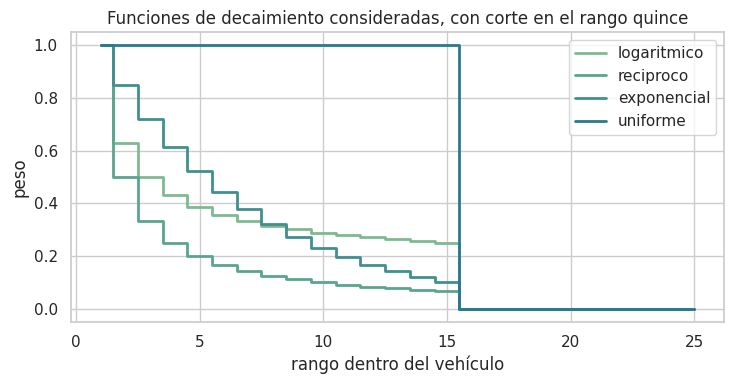

In [ ]:
IDX_COLUMNA = {ingrediente: k for k, ingrediente in enumerate(vocabulario)}
DECAIMIENTOS = {
    "logaritmico": lambda r: 1.0 / np.log2(r + 1.0),
    "reciproco": lambda r: 1.0 / r,
    "exponencial": lambda r: 0.85 ** (r - 1.0),
    "uniforme": lambda r: np.ones_like(r, dtype=float),
}
base_vocabulario = base_ponderada.loc[base_ponderada["en_vocabulario"].astype(bool)].copy()
assert base_vocabulario["ingrediente"].isin(IDX_COLUMNA).all()
FILAS_BASE = base_vocabulario["id_formula"].map(IDX_FORMULA).to_numpy()
COLUMNAS_BASE = base_vocabulario["ingrediente"].map(IDX_COLUMNA).to_numpy()
RANGOS_BASE = base_vocabulario["rango_base"].to_numpy(dtype=float)
DIMENSION = (len(formulas), len(vocabulario))


def construir_matriz(nombre_decaimiento, rango_maximo):
    peso = DECAIMIENTOS[nombre_decaimiento](RANGOS_BASE)
    if rango_maximo > 0:
        peso = np.where(RANGOS_BASE <= rango_maximo, peso, 0.0)
    matriz = sparse.csr_matrix((peso, (FILAS_BASE, COLUMNAS_BASE)), shape=DIMENSION)
    matriz.eliminate_zeros()
    return matriz


reconstruida = construir_matriz("logaritmico", 15)
diferencia_reconstruccion = abs(reconstruida - matriz_ponderada_03b).max()
gemelas = formulas.groupby("huella_base").filter(lambda g: g["marca"].nunique() > 1)
similitud_gemelas = cosine_similarity(reconstruida[[IDX_FORMULA[i] for i in gemelas["id_formula"]]])
assert diferencia_reconstruccion < 1e-9, "La reconstrucción no reproduce la representación de la ingeniería de variables"
assert np.isclose(similitud_gemelas[0, 1], 1.0), "La representación no reproduce la identidad de vehículos gemelos"
print(f"Diferencia máxima entre la matriz reconstruida y la original: {diferencia_reconstruccion:.2e}")
print(f"Similitud entre vehículos gemelos de marcas distintas: {similitud_gemelas[0, 1]:.4f}")

rangos_ilustrativos = np.arange(1, 26, dtype=float)
plt.figure(figsize=(7.5, 4))
for nombre, funcion in DECAIMIENTOS.items():
    plt.step(rangos_ilustrativos, np.where(rangos_ilustrativos <= 15, funcion(rangos_ilustrativos), 0.0), where="mid", linewidth=2, label=nombre)
plt.title("Funciones de decaimiento consideradas, con corte en el rango quince")
plt.xlabel("rango dentro del vehículo")
plt.ylabel("peso")
plt.legend()
plt.tight_layout()
plt.show()

### Ficha M4. Protocolo de evaluación

**1. Definición y justificación de negocio.** El sistema es un motor de recuperación, no un clasificador: no emite una etiqueta, emite un orden. Sea $Q$ el conjunto de consultas, $R_q$ las alternativas documentadas para la consulta $q$ y $\rho(q, d)$ el lugar de la alternativa $d$ en el orden del modelo:

$$\text{HitRate@}K = \frac{1}{|Q|}\sum_{q \in Q} \mathbf{1}\Big[\min_{d \in R_q} \rho(q,d) \le K\Big], \qquad \text{Recall@}K = \frac{1}{|Q|}\sum_{q \in Q} \frac{|\{d \in R_q : \rho(q,d) \le K\}|}{|R_q|},$$

$$\text{MRR}_{\text{macro}} = \frac{1}{|Q|}\sum_{q \in Q} \frac{1}{\min_{d \in R_q} \rho(q,d)}, \qquad \text{MRR}_{\text{micro}} = \frac{1}{\sum_q |R_q|}\sum_{q \in Q}\sum_{d \in R_q} \frac{1}{\rho(q,d)}.$$

El Hit Rate responde si la usuaria encuentra al menos una alternativa válida sin desplazarse; el Recall, qué proporción del conocimiento disponible recupera el sistema; el MRR premia colocar la alternativa correcta arriba y distingue entre dos modelos que aciertan igual pero ordenan distinto.

**2. Construcción.** El rango cuenta cuántos candidatos superan en similitud al objetivo, y los empates se resuelven con el rango promedio. Esta convención evita las dos alternativas sesgadas: la optimista, que colocaría al objetivo al frente de todo empate y premiaría a un modelo por no discriminar, y la pesimista. Dos similitudes se consideran empatadas cuando difieren en menos de `TOLERANCIA_EMPATE`, un billonésimo: dos vehículos con la misma composición tienen un coseno matemáticamente idéntico, pero el cálculo en coma flotante puede diferir en el último dígito según el procesador y el orden de las sumas, y ese ruido, del orden de $10^{-16}$, no debe alterar el orden que se reporta.

In [ ]:
TOLERANCIA_EMPATE = 1e-12
ANCLA_DE_PAR = pares["id_formula_lujo"].to_numpy()
DUPE_DE_PAR = pares["id_formula_dupe"].to_numpy()
FILA_DE_ANCLA = {a: i for i, a in enumerate(anclas)}


def rango_de_objetivo(fila, mascara, posicion_objetivo):
    diferencias = fila[mascara] - fila[posicion_objetivo]
    return int((diferencias > TOLERANCIA_EMPATE).sum()) + (int((np.abs(diferencias) <= TOLERANCIA_EMPATE).sum()) + 1) / 2.0


def rangos_de_pares(similitudes):
    rangos = np.empty(len(pares), dtype=float)
    for k, (ancla, dupe) in enumerate(zip(ANCLA_DE_PAR, DUPE_DE_PAR)):
        mascara, posicion = MASCARAS[ancla], POS_CANDIDATO[dupe]
        rangos[k] = rango_de_objetivo(similitudes[FILA_DE_ANCLA[ancla]], mascara, posicion) if mascara[posicion] else mascara.sum() + 1
    return rangos


def metricas_de_rangos(rangos, etiqueta, valores_k=VALORES_K):
    tabla = pd.DataFrame({"ancla": ANCLA_DE_PAR, "rango": rangos})
    mejor_por_ancla = tabla.groupby("ancla")["rango"].min()
    fila = {"modelo": etiqueta}
    for k in valores_k:
        fila[f"HitRate@{k}"] = float((mejor_por_ancla <= k).mean())
    for k in valores_k:
        fila[f"Recall@{k}"] = float(tabla.assign(acierto=tabla["rango"] <= k).groupby("ancla")["acierto"].mean().mean())
    for k in valores_k:
        fila[f"HitRate_micro@{k}"] = float((rangos <= k).mean())
    fila["MRR_macro"] = float((1.0 / mejor_por_ancla).mean())
    fila["MRR_micro"] = float((1.0 / rangos).mean())
    fila["rango_mediano"] = float(np.median(rangos))
    return fila


def similitudes_desde(matriz):
    return cosine_similarity(matriz[[IDX_FORMULA[a] for a in anclas]], matriz[POSICIONES_CANDIDATAS])


MATRIZ_PERFIL = perfil_escalado[VARIABLES_PERFIL].to_numpy(dtype=float)
SIM_PERFIL = similitudes_desde(MATRIZ_PERFIL)
SIM_INGREDIENTES_BASE = similitudes_desde(construir_matriz("logaritmico", 15))
rangos_base = rangos_de_pares(SIM_INGREDIENTES_BASE)
tamanos_universo = np.array([MASCARAS[a].sum() for a in ANCLA_DE_PAR])

assert (rangos_base >= 1).all() and (rangos_base <= tamanos_universo + 1).all() and np.isfinite(rangos_base).all()
print(f"Tamaño del universo de candidatos por consulta: {tamanos_universo.min()} a {tamanos_universo.max()}")
print(f"Rango de los pares bajo el modelo base: {rangos_base.min():.1f} a {rangos_base.max():.1f}")

Tamaño del universo de candidatos por consulta: 498 a 498
Rango de los pares bajo el modelo base: 2.0 a 488.5


### Ficha M5. Referencias mínimas

**1. Definición y justificación de negocio.** Una métrica sin punto de comparación no significa nada. Se construyen dos referencias que cualquier modelo debe superar para justificar su existencia.

**2. Construcción.** La referencia aleatoria ordena el universo por sorteo, repetido doscientas veces. La referencia por popularidad ordena los candidatos por su similitud media contra todas las fórmulas de gama alta, es decir, propone siempre los mismos productos genéricamente parecidos a cualquier lujo, sin mirar la consulta.

**4. Decisión de tratamiento.** Se exige superar la referencia por popularidad en MRR macro. Superar solo el azar no demuestra que el sistema personalice: si no supera a la popularidad, está devolviendo un catálogo de éxitos y no respondiendo a la consulta.

In [ ]:
def evaluar_azar(n_repeticiones=N_REPETICIONES_AZAR):
    acumulado = [metricas_de_rangos(rangos_de_pares(generador.random((len(anclas), len(IDS_CANDIDATOS)))), "azar") for _ in range(n_repeticiones)]
    promedio = pd.DataFrame(acumulado).drop(columns="modelo").mean().to_dict()
    promedio["modelo"] = "referencia aleatoria"
    return promedio


fila_azar = evaluar_azar()
posiciones_altas = np.flatnonzero(formulas["gama"].eq("alta").to_numpy())
matriz_base_15 = construir_matriz("logaritmico", 15)
popularidad = cosine_similarity(matriz_base_15[posiciones_altas], matriz_base_15[POSICIONES_CANDIDATAS]).mean(axis=0)
SIM_POPULARIDAD = np.tile(popularidad, (len(anclas), 1))
fila_popularidad = metricas_de_rangos(rangos_de_pares(SIM_POPULARIDAD), "referencia por popularidad")
fila_base = metricas_de_rangos(rangos_base, "coseno ponderado, logaritmico, corte 15")

comparacion_referencias = pd.DataFrame([fila_azar, fila_popularidad, fila_base])
COLUMNAS_VISTA = ["modelo", "HitRate@1", "HitRate@5", "HitRate@10", "Recall@5", "MRR_macro", "MRR_micro", "rango_mediano"]
assert fila_base["MRR_macro"] > fila_azar["MRR_macro"] and fila_base["MRR_macro"] > fila_popularidad["MRR_macro"]
print(comparacion_referencias[COLUMNAS_VISTA].round(4).to_string(index=False))

                                 modelo  HitRate@1  HitRate@5  HitRate@10  Recall@5  MRR_macro  MRR_micro  rango_mediano
                   referencia aleatoria     0.0058     0.0262      0.0525    0.0105     0.0289     0.0131         247.35
             referencia por popularidad     0.0000     0.0833      0.0833    0.0208     0.0480     0.0193         298.50
coseno ponderado, logaritmico, corte 15     0.0000     0.2500      0.3333    0.1314     0.1211     0.0502         191.50


### Ficha M6. Representaciones alternativas y modelo híbrido

**1. Definición y justificación de negocio.** La representación por ingredientes compara qué hay dentro del producto; la representación por perfil compara cómo está construido: qué proporción del vehículo cumple cada función, en qué posición aparece el primer emoliente, cuántos ingredientes declara. Dos fórmulas pueden compartir pocos ingredientes y comportarse igual sobre el labio si reparten sus posiciones entre las mismas familias funcionales.

**2. Construcción.** Se evalúan el coseno ponderado por rango, el coseno sobre presencia binaria, el índice de Jaccard sobre presencia, el coseno sobre el perfil y la combinación convexa

$$\text{sim}_\alpha(q, c) = \alpha\,\text{sim}_{\text{ingredientes}}(q, c) + (1-\alpha)\,\text{sim}_{\text{perfil}}(q, c), \qquad \alpha \in [0, 1].$$

**4. Decisión de tratamiento.** La comparación es descriptiva y no selecciona nada: elegir la variante ganadora sobre el mismo conjunto con el que se reporta el desempeño produciría una estimación optimista. La selección se hace en la ficha siguiente con un procedimiento que separa la elección de la medición.

                       modelo  HitRate@1  HitRate@5  HitRate@10  Recall@5  MRR_macro  MRR_micro  rango_mediano
   coseno ponderado por rango     0.0000     0.2500      0.3333    0.1314     0.1211     0.0502         191.50
       coseno sobre presencia     0.0833     0.1667      0.2500    0.0897     0.1520     0.0607         182.75
      Jaccard sobre presencia     0.0833     0.2500      0.2500    0.1314     0.1561     0.0619         185.00
coseno sobre perfil funcional     0.0833     0.2500      0.3333    0.1378     0.1708     0.0747         121.00
           híbrido, alfa 0.70     0.0833     0.2500      0.3333    0.1314     0.1865     0.0734         159.00


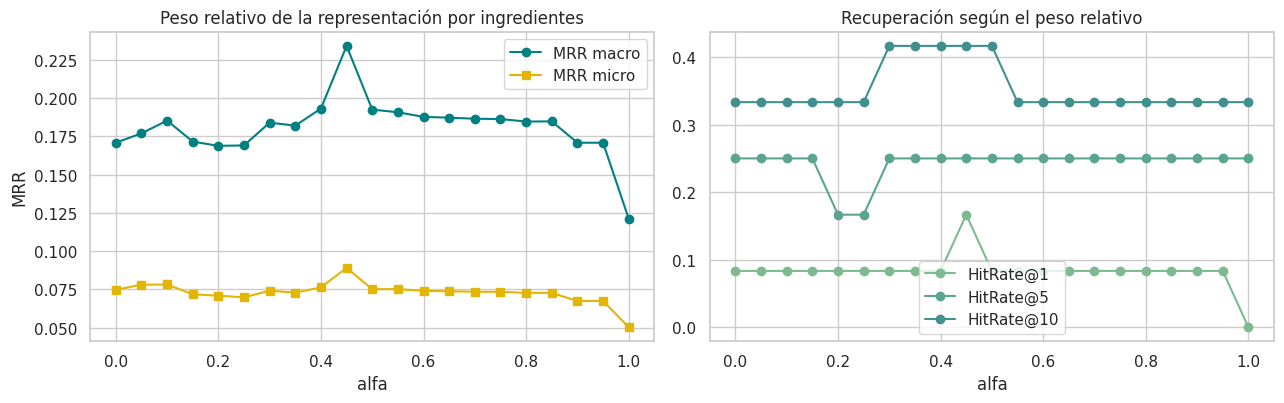

In [ ]:
def similitud_jaccard(matriz_binaria):
    binaria = (matriz_binaria > 0).astype(float)
    anclas_bin, candidatos_bin = binaria[[IDX_FORMULA[a] for a in anclas]], binaria[POSICIONES_CANDIDATAS]
    interseccion = np.asarray((anclas_bin @ candidatos_bin.T).todense())
    union = np.asarray(anclas_bin.sum(axis=1)).ravel()[:, None] + np.asarray(candidatos_bin.sum(axis=1)).ravel()[None, :] - interseccion
    return np.divide(interseccion, union, out=np.zeros_like(interseccion), where=union > 0)


variantes = {
    "coseno ponderado por rango": SIM_INGREDIENTES_BASE,
    "coseno sobre presencia": similitudes_desde(matriz_presencia),
    "Jaccard sobre presencia": similitud_jaccard(matriz_presencia),
    "coseno sobre perfil funcional": SIM_PERFIL,
    "híbrido, alfa 0.70": 0.70 * SIM_INGREDIENTES_BASE + 0.30 * SIM_PERFIL,
}
comparacion_variantes = pd.DataFrame([metricas_de_rangos(rangos_de_pares(s), nombre) for nombre, s in variantes.items()])
print(comparacion_variantes[COLUMNAS_VISTA].round(4).to_string(index=False))

curva_alfa = pd.DataFrame([
    {**metricas_de_rangos(rangos_de_pares(alfa * SIM_INGREDIENTES_BASE + (1 - alfa) * SIM_PERFIL), f"alfa {alfa:.2f}"), "alfa": alfa}
    for alfa in REJILLA_ALFA
])
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.2))
ejes[0].plot(curva_alfa["alfa"], curva_alfa["MRR_macro"], marker="o", color=COLOR_PRINCIPAL, label="MRR macro")
ejes[0].plot(curva_alfa["alfa"], curva_alfa["MRR_micro"], marker="s", color=COLOR_SECUNDARIO, label="MRR micro")
ejes[0].set_title("Peso relativo de la representación por ingredientes")
ejes[0].set_xlabel("alfa")
ejes[0].set_ylabel("MRR")
ejes[0].legend()
for k in (1, 5, 10):
    ejes[1].plot(curva_alfa["alfa"], curva_alfa[f"HitRate@{k}"], marker="o", label=f"HitRate@{k}")
ejes[1].set_title("Recuperación según el peso relativo")
ejes[1].set_xlabel("alfa")
ejes[1].legend()
fig.tight_layout()
plt.show()

### Ficha M7. Selección de hiperparámetros con validación dejando un ancla fuera

**1. Definición y justificación de negocio.** La rejilla tiene cientos de configuraciones y el conjunto de referencia pocas anclas. Elegir la configuración que maximiza la métrica sobre ese mismo conjunto y reportar esa métrica como desempeño es el error clásico de selección: se informaría el máximo de una muestra pequeña, no el desempeño esperado ante un producto nuevo.

**2. Construcción.** Para cada ancla, la configuración se elige maximizando el MRR macro sobre las demás anclas y el desempeño se mide únicamente sobre la que quedó fuera. La partición se hace por ancla y no por par, porque dos pares que comparten ancla comparten también la consulta y el orden completo de candidatos. La rejilla combina las cuatro funciones de decaimiento, los cuatro rangos de corte y los veintiún valores de alfa.

**4. Decisión de tratamiento.** La configuración final es la que resulta ganadora con mayor frecuencia entre las repeticiones, y el desempeño esperado es el calculado sobre las anclas dejadas fuera, que es el único honesto. Se contrasta además si la mejora sobre el modelo base es sistemática entre pares con la prueba de rangos con signo de Wilcoxon, que no supone normalidad.

In [ ]:
SIM_INGREDIENTES = {(d, r): similitudes_desde(construir_matriz(d, r)) for d in DECAIMIENTOS for r in RANGOS_MAXIMOS}
CONFIGURACIONES = [(d, r, float(a)) for d in DECAIMIENTOS for r in RANGOS_MAXIMOS for a in REJILLA_ALFA]
RANGOS_POR_CONFIGURACION = {c: rangos_de_pares(c[2] * SIM_INGREDIENTES[(c[0], c[1])] + (1 - c[2]) * SIM_PERFIL) for c in CONFIGURACIONES}


def mrr_macro_en(rangos, mascara_pares):
    tabla = pd.DataFrame({"ancla": ANCLA_DE_PAR[mascara_pares], "rango": rangos[mascara_pares]})
    return float((1.0 / tabla.groupby("ancla")["rango"].min()).mean())


barrido = pd.DataFrame([
    {"decaimiento": c[0], "rango_maximo": c[1], "alfa": c[2], **{k: v for k, v in metricas_de_rangos(RANGOS_POR_CONFIGURACION[c], "x").items() if k != "modelo"}}
    for c in CONFIGURACIONES
])
seleccion_por_ancla, rangos_fuera = [], np.empty(len(pares), dtype=float)
for ancla_fuera in anclas:
    es_fuera = ANCLA_DE_PAR == ancla_fuera
    mejor = max(CONFIGURACIONES, key=lambda c: mrr_macro_en(RANGOS_POR_CONFIGURACION[c], ~es_fuera))
    rangos_fuera[es_fuera] = RANGOS_POR_CONFIGURACION[mejor][es_fuera]
    seleccion_por_ancla.append({"ancla_fuera": ancla_fuera, "decaimiento": mejor[0], "rango_maximo": mejor[1], "alfa": mejor[2],
                                "mejor_rango_fuera": float(RANGOS_POR_CONFIGURACION[mejor][es_fuera].min())})
seleccion_por_ancla = pd.DataFrame(seleccion_por_ancla)
frecuencia = seleccion_por_ancla.groupby(["decaimiento", "rango_maximo", "alfa"]).size().sort_values(ascending=False, kind="stable")
DECAIMIENTO_FINAL, RANGO_FINAL, ALFA_FINAL = frecuencia.index[0]

SIM_FINAL = ALFA_FINAL * SIM_INGREDIENTES[(DECAIMIENTO_FINAL, RANGO_FINAL)] + (1 - ALFA_FINAL) * SIM_PERFIL
rangos_finales = rangos_de_pares(SIM_FINAL)
fila_optimista = metricas_de_rangos(rangos_finales, "modelo final, medido sobre el conjunto de selección")
fila_honesta = metricas_de_rangos(rangos_fuera, "modelo final, medido sobre anclas dejadas fuera")
resumen_seleccion = pd.DataFrame([fila_azar, fila_popularidad, fila_base, fila_optimista, fila_honesta])

print(f"Configuraciones evaluadas: {len(CONFIGURACIONES)}")
print(seleccion_por_ancla.to_string(index=False))
print()
print(f"Configuración final: decaimiento {DECAIMIENTO_FINAL}, rango máximo {RANGO_FINAL}, alfa {ALFA_FINAL}")
print()
print(resumen_seleccion[COLUMNAS_VISTA].round(4).to_string(index=False))
print()
print(f"Optimismo por selección, en MRR macro: {fila_optimista['MRR_macro'] - fila_honesta['MRR_macro']:+.4f}")

diferencias_rango = rangos_base - rangos_fuera
estadistico, valor_p = wilcoxon(rangos_base, rangos_fuera, zero_method="zsplit")
assert fila_honesta["MRR_macro"] > fila_popularidad["MRR_macro"], "El modelo seleccionado no supera a la referencia por popularidad"
print(f"Prueba de rangos con signo contra el modelo base: estadístico {estadistico:.1f}, valor p {valor_p:.4f}")
print(f"Pares que mejoran: {int((diferencias_rango > 0).sum())}, que empeoran: {int((diferencias_rango < 0).sum())}, sin cambio: {int((diferencias_rango == 0).sum())}")

Configuraciones evaluadas: 336
ancla_fuera decaimiento  rango_maximo  alfa  mejor_rango_fuera
      F0144    uniforme            15  0.55                1.0
      F0176    uniforme            10  0.45               23.0
      F0428    uniforme            15  0.55               89.0
      F0414    uniforme            15  0.55               25.0
      F0004    uniforme            15  0.55                4.0
      F0135    uniforme            15  0.55              250.0
      F0346    uniforme            15  0.55                1.0
      F0348    uniforme            15  0.55              220.0
      F0169    uniforme            15  0.40               14.0
      F0350    uniforme            15  0.55              296.0
      F0426    uniforme            15  0.55               92.0
      F0617    uniforme            15  0.55              132.0

Configuración final: decaimiento uniforme, rango máximo 15, alfa 0.55

                                             modelo  HitRate@1  HitRate@5  Hit

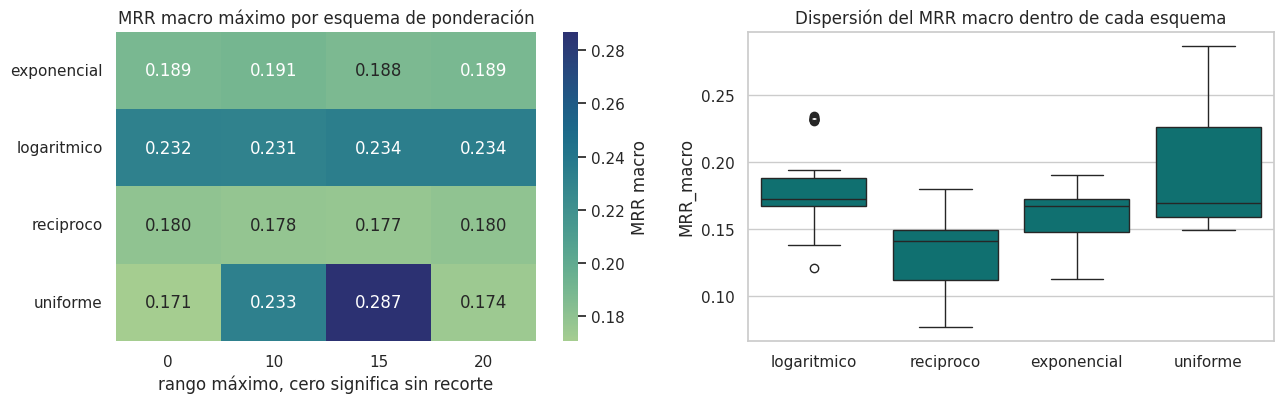

In [ ]:
tabla_calor = barrido.groupby(["decaimiento", "rango_maximo"])["MRR_macro"].max().reset_index().pivot(index="decaimiento", columns="rango_maximo", values="MRR_macro")
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.heatmap(tabla_calor, annot=True, fmt=".3f", cmap="crest", ax=ejes[0], cbar_kws={"label": "MRR macro"})
ejes[0].set_title("MRR macro máximo por esquema de ponderación")
ejes[0].set_xlabel("rango máximo, cero significa sin recorte")
ejes[0].set_ylabel("")
sns.boxplot(data=barrido, x="decaimiento", y="MRR_macro", ax=ejes[1], color=COLOR_PRINCIPAL)
ejes[1].set_title("Dispersión del MRR macro dentro de cada esquema")
ejes[1].set_xlabel("")
fig.tight_layout()
plt.show()

**Lectura de la selección.** La configuración ganadora es estable entre repeticiones: diez de las doce anclas eligen la misma. El decaimiento uniforme con corte en quince significa que, dentro de las primeras quince posiciones, el orden de declaración no aporta información adicional a la presencia: lo que distingue a dos vehículos es qué ingredientes estructurales comparten, no el lugar exacto de cada uno. El peso de 0.55 reparte la evidencia casi por mitades entre composición y arquitectura funcional. El modelo seleccionado, medido sobre anclas que no participaron en su elección, cuadruplica el MRR macro de la referencia por popularidad; la prueba de Wilcoxon no encuentra una mejora sistemática par por par frente al modelo base, lo que indica que la ganancia se concentra en colocar arriba a los equivalentes que ya estaban cerca y no en rescatar a los que estaban lejos.

### Ficha M8. Análisis de sensibilidad y validación externa

**1. Definición y justificación de negocio.** El conjunto de referencia no es homogéneo. Interesa saber si el sistema acierta mejor donde la evidencia es más sólida, porque ese es el patrón que cabría esperar si capturara equivalencia real y no ruido.

**4. Decisión de tratamiento.** Los estratos con muy pocas anclas se reportan como indicativos y no como validación. Un conjunto editorial de dos pares no confirma ni refuta nada.

In [ ]:
def metricas_en_subconjunto(rangos, mascara, etiqueta):
    tabla = pd.DataFrame({"ancla": ANCLA_DE_PAR[mascara], "rango": rangos[mascara]})
    mejor = tabla.groupby("ancla")["rango"].min()
    return {"estrato": etiqueta, "pares": int(mascara.sum()), "anclas": int(tabla["ancla"].nunique()),
            f"HitRate@{K_NEGOCIO}": float((mejor <= K_NEGOCIO).mean()), "MRR_macro": float((1.0 / mejor).mean()),
            "MRR_micro": float((1.0 / tabla["rango"]).mean()), "rango_mediano": float(tabla["rango"].median())}


estratos = [
    (np.ones(len(pares), dtype=bool), "conjunto completo"),
    (pares["nivel_fuerza_evidencia"].eq("alta").to_numpy(), "evidencia alta"),
    (pares["nivel_fuerza_evidencia"].eq("media").to_numpy(), "evidencia media"),
    (pares["nivel_fuerza_evidencia"].eq("baja").to_numpy(), "evidencia baja"),
    (pares["banda_confianza"].eq("alto").to_numpy(), "enlace automático"),
    (pares["banda_confianza"].eq("manual_confirmado").to_numpy(), "enlace confirmado a mano"),
    (auditoria_formato["formato_coincide"].to_numpy(), "mismo formato"),
    ((~auditoria_formato["formato_coincide"]).to_numpy(), "formato distinto"),
]
sensibilidad = pd.DataFrame([metricas_en_subconjunto(rangos_finales, m, e) for m, e in estratos if m.sum() > 0])

matriz_final = construir_matriz(DECAIMIENTO_FINAL, RANGO_FINAL)
anclas_secundarias = pares_secundarios["id_formula_lujo"].unique().tolist()
posiciones_secundarias = [IDX_FORMULA[a] for a in anclas_secundarias]
sim_secundaria = (ALFA_FINAL * cosine_similarity(matriz_final[posiciones_secundarias], matriz_final[POSICIONES_CANDIDATAS])
                  + (1 - ALFA_FINAL) * cosine_similarity(MATRIZ_PERFIL[posiciones_secundarias], MATRIZ_PERFIL[POSICIONES_CANDIDATAS]))
validacion_externa = pd.DataFrame([
    {"id_par": par["id_par"], "marca_lujo": par["marca_lujo"], "marca_dupe": par["marca_dupe"], "similitud_declarada": par["similitud"],
     "rango_alcanzado": rango_de_objetivo(sim_secundaria[anclas_secundarias.index(par["id_formula_lujo"])],
                                          mascara_politica(par["id_formula_lujo"], POLITICA_SELECCIONADA), POS_CANDIDATO[par["id_formula_dupe"]]),
     "candidatos": len(IDS_CANDIDATOS)}
    for _, par in pares_secundarios.iterrows()
])
validacion_externa[f"dentro_de_{K_NEGOCIO}"] = validacion_externa["rango_alcanzado"] <= K_NEGOCIO
assert sensibilidad.loc[0, "pares"] == len(pares)
print(sensibilidad.round(4).to_string(index=False))
print()
print("Conjunto editorial independiente, verificación indicativa")
print(validacion_externa.to_string(index=False))

                 estrato  pares  anclas  HitRate@5  MRR_macro  MRR_micro  rango_mediano
       conjunto completo     36      12     0.3333     0.2869     0.1077          138.5
          evidencia alta      4       4     0.0000     0.0078     0.0078          131.0
         evidencia media      8       5     0.2000     0.2075     0.1339          170.5
          evidencia baja     24      10     0.3000     0.2433     0.1156          132.0
       enlace automático     22       9     0.2222     0.2449     0.1156          117.5
enlace confirmado a mano     14       8     0.2500     0.1605     0.0952          194.5
           mismo formato     26      10     0.3000     0.2456     0.1092           97.5
        formato distinto     10       6     0.1667     0.1705     0.1036          279.0

Conjunto editorial independiente, verificación indicativa
id_par marca_lujo marca_dupe  similitud_declarada  rango_alcanzado  candidatos  dentro_de_5
   P01        mac maybelline                 0.95        

**Lectura.** El hallazgo central del proyecto aparece aquí: los pares con evidencia comunitaria más fuerte son los peor recuperados por el modelo. La lectura no es que el modelo falle donde más importa, sino que la comunidad valida los sustitutos por coincidencia de tono, que es lo que se ve en una fotografía, mientras que el sistema mide equivalencia de vehículo, que es lo que determina textura, deslizamiento y permanencia. Un sustituto viral puede ser idéntico en color y muy distinto por dentro, y esa es precisamente la información que Same Same agrega a la decisión de compra.

### Ficha M9. Costo del filtro ético

**1. Definición y justificación de negocio.** El filtro ético es una opción de la usuaria y no participa en la función de similitud, pero al activarse reduce el universo de candidatos. La interfaz debe poder anticipar ese costo en lugar de devolver una lista vacía.

**4. Decisión de tratamiento.** El filtro se implementa como restricción del universo y no como penalización del puntaje, porque una promesa ética que solo reordena sigue mostrando marcas que la usuaria pidió excluir.

In [ ]:
clasificacion_candidatos = np.array([clasificacion_por_marca.get(marca_por_formula[f], "sin_dato") for f in IDS_CANDIDATOS])
REGIMENES_ETICOS = {
    "sin restricción": np.ones(len(IDS_CANDIDATOS), dtype=bool),
    "certificado y zona gris": np.isin(clasificacion_candidatos, ["certificado", "zona_gris"]),
    "solo certificado": clasificacion_candidatos == "certificado",
}
costo_etico = []
for nombre, permitido in REGIMENES_ETICOS.items():
    disponibles, aciertos = [], []
    for ancla in anclas:
        mascara = MASCARAS[ancla] & permitido
        sobreviven = [d for d in DUPE_DE_PAR[ANCLA_DE_PAR == ancla] if mascara[POS_CANDIDATO[d]]]
        disponibles.append(int(mascara.sum()))
        if sobreviven:
            fila = SIM_FINAL[FILA_DE_ANCLA[ancla]]
            aciertos.append(min(rango_de_objetivo(fila, mascara, POS_CANDIDATO[d]) for d in sobreviven) <= K_NEGOCIO)
    costo_etico.append({"regimen": nombre, "candidatos_medios": float(np.mean(disponibles)), "anclas_con_alternativa_documentada": len(aciertos),
                        f"HitRate@{K_NEGOCIO}_entre_esas_anclas": float(np.mean(aciertos)) if aciertos else np.nan})
assert REGIMENES_ETICOS["solo certificado"].sum() > 0
print(pd.DataFrame(costo_etico).round(3).to_string(index=False))

                regimen  candidatos_medios  anclas_con_alternativa_documentada  HitRate@5_entre_esas_anclas
        sin restricción              498.0                                  12                        0.333
certificado y zona gris              426.0                                   9                        0.444
       solo certificado              426.0                                   9                        0.444


### Ficha M10. Diagnóstico de errores

**1. Definición y justificación de negocio.** Una métrica agregada dice cuánto falla el sistema, no por qué. El diagnóstico por par distingue si el fallo proviene del modelo, que colocó lejos a un equivalente real, o de la verdad de referencia, que declara equivalentes a dos productos que no comparten vehículo. Un par con rango alto y similitud baja contra su equivalente apunta a una etiqueta dudosa; un par con rango alto y similitud alta apunta a un universo poblado de candidatos igualmente parecidos.

**4. Decisión de tratamiento.** Los pares con diagnóstico de etiqueta dudosa se marcan sin eliminarlos. Eliminar un par porque el modelo falla en él es justamente la forma de hacer que cualquier modelo parezca bueno.

Diez pares con peor rango
id_par                              ancla            equivalente_documentado  rango  similitud_documentado  similitud_primer_lugar  formato_coincide evidencia
  P029 Fenty Beauty Slip Shine Sheer Shin revlon Super Lustrous Glass Shine   449.0                  0.309                   0.640             False     media
  P006 Charlotte Tilbury Matte Revolution               elf Glossy Lip Stain  445.0                  0.301                   0.766             False      baja
  P036    MAC LABIAL MACXIMAL SILKY MATTE    Maybelline SUPER STAY MATTE INK  437.0                  0.321                   0.623             False      baja
  P033 MAC Lustreglass Sheer-Shine Lipsti     L'Oreal Colour Riche Lipcolour  408.0                  0.348                   0.647              True      baja
  P003        Charlotte Tilbury Lip Cheat     L'Oreal Colour Riche Lip Liner  313.0                  0.419                   0.625              True      baja
  P025 Fenty Beauty 

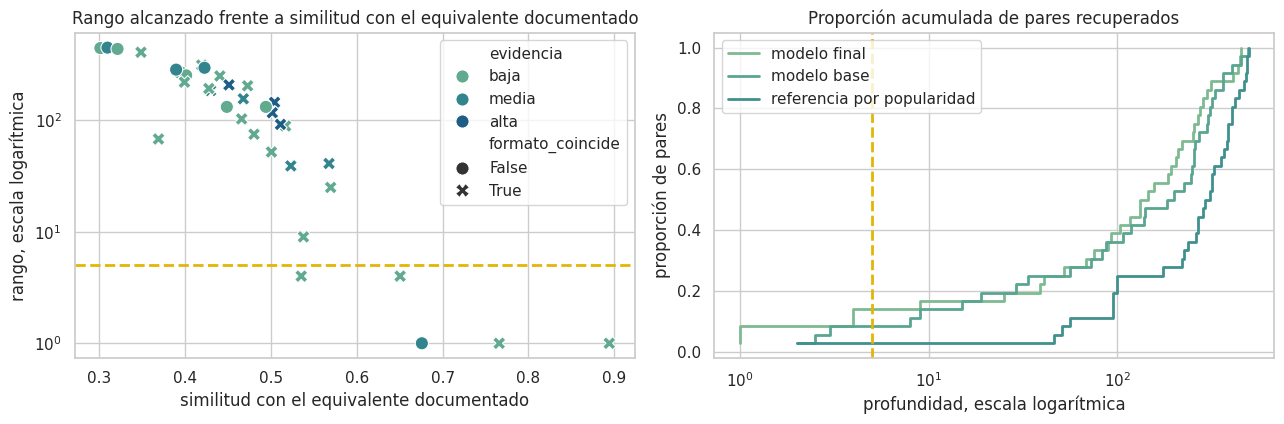

In [ ]:
nombre_por_formula = formulas.set_index("id_formula")["nombre_representante"]
diagnostico = []
for k, (ancla, dupe) in enumerate(zip(ANCLA_DE_PAR, DUPE_DE_PAR)):
    fila, mascara = SIM_FINAL[FILA_DE_ANCLA[ancla]], MASCARAS[ancla]
    valores, ids_visibles = fila[mascara], IDS_CANDIDATOS[mascara]
    mejor_posicion = int(np.argmax(valores))
    diagnostico.append({
        "id_par": pares["id_par"].iloc[k],
        "ancla": f"{pares['marca_lujo'].iloc[k]} {pares['linea_lujo'].iloc[k]}"[:34],
        "equivalente_documentado": f"{pares['marca_dupe'].iloc[k]} {pares['linea_dupe'].iloc[k]}"[:34],
        "rango": rangos_finales[k],
        "similitud_documentado": float(fila[POS_CANDIDATO[dupe]]),
        "similitud_primer_lugar": float(valores[mejor_posicion]),
        "primer_lugar": nombre_por_formula.get(ids_visibles[mejor_posicion], ""),
        "formato_coincide": bool(auditoria_formato["formato_coincide"].iloc[k]),
        "evidencia": pares["nivel_fuerza_evidencia"].iloc[k],
    })
diagnostico = pd.DataFrame(diagnostico)
diagnostico["brecha"] = diagnostico["similitud_primer_lugar"] - diagnostico["similitud_documentado"]
diagnostico["etiqueta_dudosa"] = (diagnostico["rango"] > 20) & (diagnostico["similitud_documentado"] < diagnostico["similitud_documentado"].median())
assert len(diagnostico) == len(pares) and diagnostico["similitud_documentado"].between(-1.0001, 1.0001).all()

print("Diez pares con peor rango")
print(diagnostico.sort_values("rango", ascending=False, kind="stable").head(10)[
    ["id_par", "ancla", "equivalente_documentado", "rango", "similitud_documentado", "similitud_primer_lugar", "formato_coincide", "evidencia"]
].round(3).to_string(index=False))
print()
print(f"Pares marcados para revisión de la verdad de referencia: {int(diagnostico['etiqueta_dudosa'].sum())}")

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.4))
sns.scatterplot(data=diagnostico, x="similitud_documentado", y="rango", hue="evidencia", style="formato_coincide", s=90, palette="crest", ax=ejes[0])
ejes[0].set_yscale("log")
ejes[0].axhline(K_NEGOCIO, color=COLOR_SECUNDARIO, linestyle="--", linewidth=2)
ejes[0].set_title("Rango alcanzado frente a similitud con el equivalente documentado")
ejes[0].set_xlabel("similitud con el equivalente documentado")
ejes[0].set_ylabel("rango, escala logarítmica")
for etiqueta, serie in [("modelo final", rangos_finales), ("modelo base", rangos_base), ("referencia por popularidad", rangos_de_pares(SIM_POPULARIDAD))]:
    ordenados = np.sort(serie)
    ejes[1].step(ordenados, np.arange(1, len(ordenados) + 1) / len(ordenados), where="post", linewidth=2, label=etiqueta)
ejes[1].set_xscale("log")
ejes[1].axvline(K_NEGOCIO, color=COLOR_SECUNDARIO, linestyle="--", linewidth=2)
ejes[1].set_title("Proporción acumulada de pares recuperados")
ejes[1].set_xlabel("profundidad, escala logarítmica")
ejes[1].set_ylabel("proporción de pares")
ejes[1].legend()
fig.tight_layout()
plt.show()

### 13.1 Exportación del modelo

Se persisten la configuración seleccionada, el ranking de candidatos para cada fórmula de gama alta del catálogo, las métricas de todos los modelos y referencias, el barrido completo de hiperparámetros, el diagnóstico por par y la verdad de referencia con la auditoría de formato y el rango del modelo final. El ranking se calcula para las 147 fórmulas de gama alta y no solo para las doce anclas, porque el flujo de consulta debe responder ante cualquier producto del catálogo.

In [ ]:
posiciones_altas_todas = np.flatnonzero(formulas["gama"].eq("alta").to_numpy())
ids_altas = formulas.loc[posiciones_altas_todas, "id_formula"].to_numpy()
sim_todas = (ALFA_FINAL * cosine_similarity(matriz_final[posiciones_altas_todas], matriz_final[POSICIONES_CANDIDATAS])
             + (1 - ALFA_FINAL) * cosine_similarity(MATRIZ_PERFIL[posiciones_altas_todas], MATRIZ_PERFIL[POSICIONES_CANDIDATAS]))
filas_ranking = []
for i, id_alta in enumerate(ids_altas):
    visibles = np.flatnonzero(mascara_politica(id_alta, POLITICA_SELECCIONADA))
    for posicion, j in enumerate(visibles[np.argsort(-sim_todas[i, visibles], kind="stable")][:TOP_EXPORTACION], start=1):
        id_candidato = IDS_CANDIDATOS[j]
        filas_ranking.append({
            "id_formula_lujo": id_alta, "nombre_lujo": nombre_por_formula[id_alta], "marca_lujo": marca_por_formula[id_alta],
            "posicion": posicion, "id_formula_candidato": id_candidato, "nombre_candidato": nombre_por_formula[id_candidato],
            "marca_candidato": marca_por_formula[id_candidato], "formato_candidato": formato_por_formula[id_candidato],
            "similitud": round(float(sim_todas[i, j]), 6), "cruelty_free_candidato": clasificacion_por_marca.get(marca_por_formula[id_candidato], "sin_dato"),
            "formato_coincide": bool(formato_por_formula[id_candidato] == formato_por_formula[id_alta]),
        })
ranking_top = pd.DataFrame(filas_ranking)

configuracion_modelo = {
    "funcion_similitud": "coseno", "decaimiento": DECAIMIENTO_FINAL, "rango_maximo": int(RANGO_FINAL),
    "alfa_ingredientes": float(ALFA_FINAL), "politica_candidatos": POLITICA_SELECCIONADA,
    "formato_como_compuerta": bool(FORMATO_COMO_COMPUERTA), "variables_perfil": VARIABLES_PERFIL,
    "tamano_vocabulario": len(vocabulario), "k_negocio": K_NEGOCIO, "convencion_empates": "rango promedio", "semilla": SEMILLA,
    "desempeno_anclas_fuera": {"MRR_macro": round(fila_honesta["MRR_macro"], 6), "MRR_micro": round(fila_honesta["MRR_micro"], 6),
                               f"HitRate@{K_NEGOCIO}": round(fila_honesta[f"HitRate@{K_NEGOCIO}"], 6)},
}
pares_modelo = pares.merge(auditoria_formato[["id_par", "formato_lujo", "formato_dupe", "formato_coincide", "familia_coincide"]], on="id_par", how="left")
pares_modelo["rango_modelo_final"] = rangos_finales

registrar("universo de candidatos", "política de filtrado", f"Política {POLITICA_SELECCIONADA}, la más restrictiva con cobertura de al menos {COBERTURA_MINIMA_FILTRO:.0%}",
          "Un filtro que elimina equivalencias documentadas impone un techo invisible a la recuperación", "Modelo de similitud")
registrar("función de similitud", "coseno", "Coseno del ángulo entre vectores de vehículo y de perfil",
          "Normaliza por magnitud y evita que la longitud de la lista domine la comparación", "Modelo de similitud")
registrar("hiperparámetros", "selección", f"Decaimiento {DECAIMIENTO_FINAL}, corte {RANGO_FINAL}, alfa {ALFA_FINAL}, elegidos por validación dejando un ancla fuera",
          "Dos pares de una misma ancla comparten el orden de candidatos; separarlos filtraría información", "Modelo de similitud")
registrar("métricas", "evaluación", "Hit Rate@K, Recall@K y MRR en agregación micro y macro, con rango promedio ante empates",
          "Solo el promedio macro es insensible a la sobrerrepresentación de un ancla", "Modelo de similitud")
registrar("referencias mínimas", "control", "Referencia aleatoria y referencia por popularidad independiente de la consulta",
          "Superar el azar no demuestra personalización; superar la popularidad sí", "Modelo de similitud")
registrar("filtro ético", "regla de negocio", "Restricción del universo de candidatos y no penalización del puntaje",
          "Una promesa ética que solo reordena sigue mostrando marcas que la usuaria pidió excluir", "Modelo de similitud")
registrar("pares dudosos", "diagnóstico", f"{int(diagnostico['etiqueta_dudosa'].sum())} pares marcados para revisión y conservados",
          "Eliminar un par porque el modelo falla en él hace que cualquier modelo parezca bueno", "Modelo de similitud")

(DIRECTORIO_ANALITICO / "configuracion_modelo_04a.json").write_text(json.dumps(configuracion_modelo, ensure_ascii=False, indent=2), encoding="utf-8")
sparse.save_npz(DIRECTORIO_ANALITICO / "matriz_base_modelo_04a.npz", matriz_final)
print(exportar({
    "ranking_top50_04a.csv": ranking_top,
    "metricas_modelo_04a.csv": pd.concat([comparacion_referencias, comparacion_variantes, resumen_seleccion], ignore_index=True),
    "curva_hiperparametros_04a.csv": barrido,
    "seleccion_hiperparametros_04a.csv": seleccion_por_ancla,
    "diagnostico_errores_04a.csv": diagnostico,
    "sensibilidad_04a.csv": sensibilidad,
    "validacion_externa_04a.csv": validacion_externa,
    "pares_evaluables_primarios_04a.csv": pares_modelo,
}).to_string(index=False))
print()
print(json.dumps(configuracion_modelo["desempeno_anclas_fuera"], indent=2))

                           archivo  filas  columnas    kb
             ranking_top50_04a.csv   7350        11 904.7
           metricas_modelo_04a.csv     13        19   4.5
     curva_hiperparametros_04a.csv    336        21 106.7
 seleccion_hiperparametros_04a.csv     12         5   0.4
       diagnostico_errores_04a.csv     36        11   6.2
              sensibilidad_04a.csv      8         7   0.7
        validacion_externa_04a.csv      2         7   0.2
pares_evaluables_primarios_04a.csv     36        26   8.6

{
  "MRR_macro": 0.203876,
  "MRR_micro": 0.079752,
  "HitRate@5": 0.25
}


## 14. Política de acierto por línea comercial

**Objetivo.** La evaluación anterior exige que el modelo coloque en las primeras posiciones exactamente la fórmula documentada. Esta sección reevalúa el mismo modelo, con los mismos hiperparámetros, bajo un segundo criterio: una alternativa cuenta como encontrada si el modelo posiciona cualquier fórmula de la misma línea comercial que la documentada.

**Fundamento.** La verdad de referencia declara equivalencias a nivel de producto comercial, tal como las reporta la comunidad, y no a nivel de fórmula química exacta. Cuando una línea reúne varias fórmulas económicas, cada una con los colorantes de su tono, exigir la fórmula exacta impone una vara más estricta que la que la evidencia sostiene. La capa de presentación de la sección 11 unificó el nombre visible sin alterar ningún vector, de modo que el cambio de criterio no toca el modelo y aísla el efecto de la granularidad.

### Ficha L1. Rango por línea comercial

**2. Construcción.** Para cada par se identifican las fórmulas económicas de la misma línea que la documentada. Cuando la línea tiene más de una, el rango se calcula sobre la hermana de mayor similitud, con la misma convención de rango promedio ante empates; cuando tiene una sola, coincide con el rango exacto.

**4. Decisión de tratamiento.** El criterio de línea se reporta junto al criterio exacto y no lo reemplaza. El exacto mide si el sistema encuentra el tono preciso que la comunidad probó; el de línea mide si encuentra el producto correcto en cualquiera de sus variantes, que es la pregunta que responde la interfaz cuando muestra un nombre de línea y no un código de tono.

**6. Validación.** La política de línea nunca puede empeorar el rango de un par, y el criterio exacto debe reproducir el desempeño documentado sobre las anclas dejadas fuera.

In [ ]:
nombres_linea = pd.read_csv(DIRECTORIO_ANALITICO / "nombres_normalizados_01c.csv")
clave_linea_por_formula = nombres_linea.set_index("id_formula")["clave_linea"]
nombre_comercial_por_formula = nombres_linea.set_index("id_formula")["nombre_comercial"]
linea_a_candidatas = {}
for id_formula in IDS_CANDIDATOS:
    linea_a_candidatas.setdefault(clave_linea_por_formula[id_formula], []).append(id_formula)


def rango_por_linea(fila_similitud, mascara, dupe):
    hermanos = linea_a_candidatas.get(clave_linea_por_formula[dupe], [dupe])
    visibles = [(h, fila_similitud[POS_CANDIDATO[h]]) for h in hermanos if mascara[POS_CANDIDATO[h]]]
    mejor_hermano = max(visibles, key=lambda t: t[1])[0]
    return rango_de_objetivo(fila_similitud, mascara, POS_CANDIDATO[mejor_hermano]), mejor_hermano, len(hermanos)


detalle_linea = []
rangos_linea = np.empty(len(pares), dtype=float)
for k, (ancla, dupe) in enumerate(zip(ANCLA_DE_PAR, DUPE_DE_PAR)):
    rangos_linea[k], mejor_hermano, n_hermanos = rango_por_linea(SIM_FINAL[FILA_DE_ANCLA[ancla]], MASCARAS[ancla], dupe)
    detalle_linea.append({"id_par": pares["id_par"].iloc[k], "marca_lujo": pares["marca_lujo"].iloc[k], "linea_lujo": pares["linea_lujo"].iloc[k],
                          "marca_dupe": pares["marca_dupe"].iloc[k], "id_formula_dupe": dupe, "n_formulas_en_linea": n_hermanos,
                          "rango_exacto": rangos_finales[k], "mejor_hermano": nombre_comercial_por_formula[mejor_hermano],
                          "rango_linea": rangos_linea[k], "mejora": rangos_finales[k] - rangos_linea[k]})
detalle_linea = pd.DataFrame(detalle_linea)

rangos_fuera_linea = np.empty(len(pares), dtype=float)
rangos_fuera_exacto = np.empty(len(pares), dtype=float)
for _, seleccion in seleccion_por_ancla.iterrows():
    ancla = seleccion["ancla_fuera"]
    fila_pliegue = (seleccion["alfa"] * SIM_INGREDIENTES[(seleccion["decaimiento"], int(seleccion["rango_maximo"]))]
                    + (1 - seleccion["alfa"]) * SIM_PERFIL)[FILA_DE_ANCLA[ancla]]
    for k in np.flatnonzero(ANCLA_DE_PAR == ancla):
        rangos_fuera_exacto[k] = rango_de_objetivo(fila_pliegue, MASCARAS[ancla], POS_CANDIDATO[DUPE_DE_PAR[k]])
        rangos_fuera_linea[k] = rango_por_linea(fila_pliegue, MASCARAS[ancla], DUPE_DE_PAR[k])[0]

metricas_linea = pd.DataFrame([
    metricas_de_rangos(rangos_finales, "exacto, conjunto de selección"),
    metricas_de_rangos(rangos_linea, "línea comercial, conjunto de selección"),
    metricas_de_rangos(rangos_fuera_exacto, "exacto, anclas dejadas fuera"),
    metricas_de_rangos(rangos_fuera_linea, "línea comercial, anclas dejadas fuera"),
])

assert (detalle_linea["rango_linea"] <= detalle_linea["rango_exacto"]).all()
assert (detalle_linea.loc[detalle_linea["n_formulas_en_linea"] == 1, "mejora"] == 0).all()
assert np.allclose(rangos_fuera_exacto, rangos_fuera), "El criterio exacto no reproduce la evaluación sobre anclas dejadas fuera"
print("Pares cuya línea documentada reúne más de una fórmula económica")
print(detalle_linea.loc[detalle_linea["n_formulas_en_linea"] > 1].sort_values("mejora", ascending=False, kind="stable")[
    ["id_par", "marca_lujo", "linea_lujo", "marca_dupe", "n_formulas_en_linea", "rango_exacto", "mejor_hermano", "rango_linea"]].to_string(index=False))
print()
print(metricas_linea[["modelo", "HitRate@1", "HitRate@3", "HitRate@5", "HitRate@10", "Recall@5", "MRR_macro", "MRR_micro", "rango_mediano"]].round(4).to_string(index=False))

registrar("criterio de acierto", "política de evaluación", "Acierto por línea comercial reportado junto al acierto por fórmula exacta",
          "La verdad de referencia documenta equivalencia de producto comercial, no de tono específico", "Política de línea comercial")
print()
print(exportar({"metricas_linea_comercial_04a.csv": metricas_linea, "diagnostico_linea_comercial_04a.csv": detalle_linea}).to_string(index=False))

Pares cuya línea documentada reúne más de una fórmula económica
id_par        marca_lujo                            linea_lujo marca_dupe  n_formulas_en_linea  rango_exacto                 mejor_hermano  rango_linea
  P016 Charlotte Tilbury                      Matte Revolution        nyx                    2         285.0               Slim Lip Pencil         61.0
  P002           Benefit                              Benetint    essence                    3           4.0 What A Tint! Lip & Cheek Tint          1.0
  P022              Dior                          Lip Glow Oil        nyx                    3          41.0              Fat Oil Lip Drip         38.0
  P025      Fenty Beauty Gloss Bomb Cream Color Drip Lip Cream        nyx                    3         296.0              Fat Oil Lip Drip        296.0

                                modelo  HitRate@1  HitRate@3  HitRate@5  HitRate@10  Recall@5  MRR_macro  MRR_micro  rango_mediano
         exacto, conjunto de selección     0

**Lectura.** Solo cuatro de los treinta y seis pares documentan una línea con más de una fórmula económica, y el cambio de criterio mejora el primer lugar de la consulta en uno de ellos. El MRR macro sobre anclas dejadas fuera sube de 0.20 a 0.27 sin tocar el modelo: una parte de la brecha entre el desempeño medido y el percibido por la usuaria proviene de evaluar con una granularidad más fina que la de la propia evidencia. El resto de la brecha persiste y tiene la explicación ya documentada: la comunidad valida por tono y el sistema por vehículo.

## 15. Sistema consultable: escala, etiquetas, explicación, arquetipos y flujo de inferencia

**Objetivo.** Convertir el motor de recuperación en un sistema que la interfaz pueda consultar en tiempo real: la matriz completa de similitud, una escala de comparación válida entre consultas distintas, una capa de etiquetas calibrada contra la evidencia documentada, la explicación de cada resultado en términos de formulación, una partición del catálogo en arquetipos de fórmula y dos funciones de inferencia puras.

**Fundamento.** El motor entrega un número, el coseno híbrido entre dos fórmulas, que no es interpretable por sí mismo: una similitud de 0.45 puede ser el mejor candidato disponible para un producto o uno mediocre para otro, porque la escala depende de la densidad del vecindario de cada consulta. La capa que se construye aquí traduce ese número a una posición relativa dentro del universo de la propia consulta, y solo entonces a una etiqueta en lenguaje natural, con umbrales derivados de los datos y validados contra los pares documentados.

Constantes de la etapa:

* `PERCENTIL_NIVEL_1 = 99`. Corte de percentil para aspirar al nivel de respaldo más alto; corresponde a las cinco primeras posiciones del universo económico, lo que cabe en una pantalla.
* `VARIANZA_RETENIDA = 0.80`. Proporción mínima de varianza que conserva la representación sobre la que se construyen los arquetipos.
* `REJILLA_K`. Números de arquetipos considerados.
* `UNIVERSO_MINIMO_AVISO = 50`. Tamaño del universo por debajo del cual la posición relativa deja de ser informativa y la interfaz debe advertirlo.
* `SOPORTE_POCO_COMUN = 0.05`. Proporción del catálogo por debajo de la cual un ingrediente compartido se considera una coincidencia distintiva.

In [ ]:
PERCENTIL_NIVEL_1 = 99.0
VARIANZA_RETENIDA = 0.80
REJILLA_K = range(2, 11)
UNIVERSO_MINIMO_AVISO = 50
SOPORTE_POCO_COMUN = 0.05

configuracion_04a = json.loads((DIRECTORIO_ANALITICO / "configuracion_modelo_04a.json").read_text(encoding="utf-8"))
DECAIMIENTO = configuracion_04a["decaimiento"]
RANGO_MAXIMO_MODELO = int(configuracion_04a["rango_maximo"])
ALFA = float(configuracion_04a["alfa_ingredientes"])
POLITICA_CANDIDATOS = configuracion_04a["politica_candidatos"]
VARIABLES_PERFIL = list(configuracion_04a["variables_perfil"])
K_NEGOCIO = int(configuracion_04a["k_negocio"])

ranking_04a = pd.read_csv(DIRECTORIO_ANALITICO / "ranking_top50_04a.csv")
pares_04a = pd.read_csv(DIRECTORIO_ANALITICO / "pares_evaluables_primarios_04a.csv")
nombres_catalogo = pd.read_csv(DIRECTORIO_ANALITICO / "nombres_normalizados_01c.csv")
assert set(VARIABLES_PERFIL) <= set(perfil_escalado.columns) and len(vocabulario) == configuracion_04a["tamano_vocabulario"]
assert set(nombres_catalogo["id_formula"]) == set(formulas["id_formula"])
print(f"Configuración heredada: decaimiento {DECAIMIENTO}, corte {RANGO_MAXIMO_MODELO}, alfa {ALFA}, política {POLITICA_CANDIDATOS}")

Configuración heredada: decaimiento uniforme, corte 15, alfa 0.55, política sin_filtro


### Ficha S1. Matriz completa y verificación contra el ranking exportado

**1. Definición y justificación de negocio.** El ranking exportado conserva las cincuenta primeras posiciones de cada consulta. Esa profundidad basta para recomendar, pero no para validar: cuando la usuaria llega con un sustituto que vio en redes, ese sustituto puede ocupar cualquier posición, y en la verdad de referencia hay pares más allá de la posición cuatrocientos. Un sistema que solo conoce el top cincuenta tendría que responder que no sabe justamente cuando la advertencia de compra es más valiosa.

**2. Construcción y 3. Diagnóstico.** La matriz de 147 consultas por 498 candidatas se reconstruye desde el rango de declaración de cada ingrediente, el dato primario, aplicando la configuración leída del objeto persistido. La verificación es doble: el orden de las cincuenta primeras posiciones debe coincidir identificador a identificador con el ranking exportado, y los valores de similitud deben coincidir dentro de la tolerancia numérica.

In [ ]:
MATRIZ_BASE = construir_matriz(DECAIMIENTO, RANGO_MAXIMO_MODELO)
MATRIZ_PERFIL = perfil_escalado[VARIABLES_PERFIL].to_numpy(dtype=float)
POSICIONES_ALTA = np.flatnonzero(formulas["gama"].eq("alta").to_numpy())
POSICIONES_ECONOMICA = np.flatnonzero(formulas["gama"].eq("economica").to_numpy())
IDS_ALTA = formulas.loc[POSICIONES_ALTA, "id_formula"].to_numpy()
IDS_ECONOMICA = formulas.loc[POSICIONES_ECONOMICA, "id_formula"].to_numpy()
FILA_CONSULTA = {f: i for i, f in enumerate(IDS_ALTA)}
COLUMNA_CANDIDATA = {f: j for j, f in enumerate(IDS_ECONOMICA)}
SIMILITUD = (ALFA * cosine_similarity(MATRIZ_BASE[POSICIONES_ALTA], MATRIZ_BASE[POSICIONES_ECONOMICA])
             + (1.0 - ALFA) * cosine_similarity(MATRIZ_PERFIL[POSICIONES_ALTA], MATRIZ_PERFIL[POSICIONES_ECONOMICA]))
ORDEN_COMPLETO = np.argsort(-SIMILITUD, axis=1, kind="stable")

consultas_con_orden_distinto, maxima_diferencia = [], 0.0
for id_lujo, grupo in ranking_04a.groupby("id_formula_lujo", sort=False):
    fila, grupo = FILA_CONSULTA[id_lujo], grupo.sort_values("posicion")
    obtenido = ORDEN_COMPLETO[fila, :len(grupo)]
    if not np.array_equal(grupo["id_formula_candidato"].to_numpy(), IDS_ECONOMICA[obtenido]):
        consultas_con_orden_distinto.append(id_lujo)
    maxima_diferencia = max(maxima_diferencia, float(np.abs(SIMILITUD[fila, obtenido] - grupo["similitud"].to_numpy()).max()))

assert ranking_04a["id_formula_lujo"].nunique() == len(IDS_ALTA) and not consultas_con_orden_distinto
assert maxima_diferencia < 1e-6 and np.isfinite(SIMILITUD).all()
print(f"Matriz de similitud: {SIMILITUD.shape[0]} consultas de gama alta por {SIMILITUD.shape[1]} candidatas económicas")
print(f"Similitud mínima {SIMILITUD.min():.4f}, máxima {SIMILITUD.max():.4f}, mediana {np.median(SIMILITUD):.4f}")
print(f"Consultas con orden distinto al ranking exportado: {len(consultas_con_orden_distinto)}; diferencia máxima de similitud: {maxima_diferencia:.2e}")

Matriz de similitud: 147 consultas de gama alta por 498 candidatas económicas
Similitud mínima 0.0504, máxima 0.9992, mediana 0.3905
Consultas con orden distinto al ranking exportado: 0; diferencia máxima de similitud: 5.00e-07


### Ficha S2. Escala de comparación entre consultas

**1. Definición y justificación de negocio.** La interfaz muestra resultados de consultas distintas bajo la misma leyenda. Si la leyenda se construyera sobre el coseno absoluto, la misma palabra significaría cosas diferentes según el producto consultado. La escala debe responder qué tan cerca está esta candidata respecto de lo mejor que el catálogo accesible puede ofrecer para esta consulta.

**2. Construcción.** Se definen dos magnitudes relativas al universo de la consulta. Si $\rho$ es el rango de la candidata entre las $n$ alternativas económicas, con empates por rango promedio, $s$ su similitud, $\tilde{s}$ la mediana de la consulta y DAM la desviación absoluta mediana,

$$\text{percentil} = 100\left(1 - \frac{\rho - 1}{n}\right), \qquad \text{separación} = \frac{s - \tilde{s}}{1.4826 \cdot \text{DAM}}.$$

El factor 1.4826 hace comparable la desviación absoluta mediana con una desviación estándar bajo normalidad. Se emplean estadísticos robustos porque cada consulta tiene un puñado de candidatas muy próximas que inflarían los momentos convencionales, y ese es precisamente el fenómeno que se quiere medir.

**3. Diagnóstico.** Muchas candidatas comparten exactamente el mismo vehículo y por tanto la misma similitud, de modo que cada consulta contiene numerosos empates. En coma flotante el coseno de dos vectores idénticos puede diferir en el último dígito según el procesador, el orden de las sumas y la forma de las matrices que se multiplican, con diferencias del orden de $10^{-16}$. Como el percentil depende del rango y los niveles de la escala se definen por umbrales sobre el percentil, un empate roto por ese ruido puede cambiar el nivel de una candidata.

**4. Decisión de tratamiento.** Las dos magnitudes son complementarias: el percentil ordena dentro de una consulta, pero no distingue entre las primeras posiciones, que por construcción ocupan siempre el percentil más alto; la separación distingue entre una consulta cuyo mejor candidato despunta y otra cuyo universo es plano. El rango se calcula con la tolerancia de empate de un billonésimo, cuatro órdenes de magnitud por encima del ruido numérico y por debajo de cualquier diferencia real entre candidatas; la validación lo comprueba sobre la matriz completa.

Menor diferencia real entre dos similitudes de una misma consulta: 7.6e-10; tolerancia de empate: 1e-12
La similitud máxima alcanzable va de 0.507 a 0.999 según la consulta
La mediana del universo va de 0.251 a 0.472 según la consulta
Una similitud de 0.391 ocupa el percentil 15.5 en una consulta y el 94.8 en otra
Separación de la primera posición: mediana 3.21, mínimo 2.04


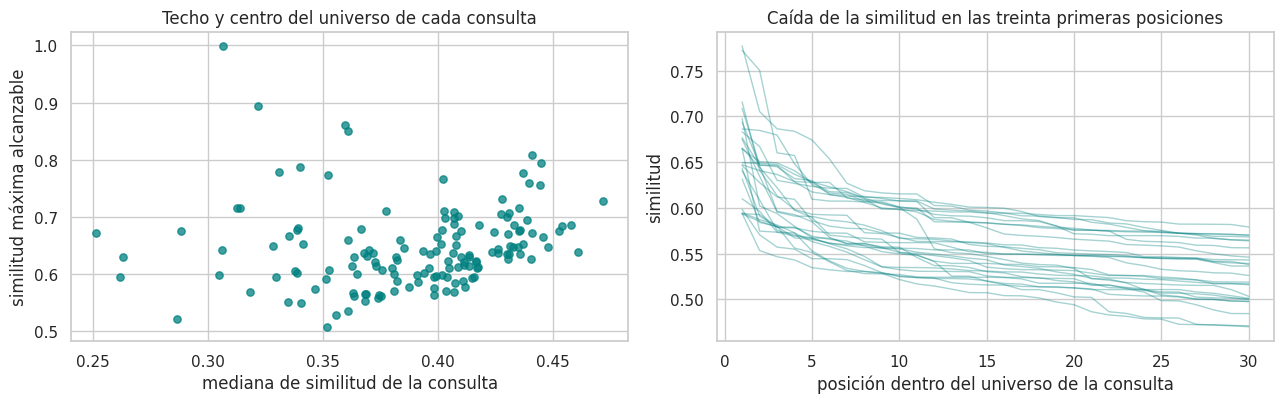

In [ ]:
def rango_promedio(valores, tolerancia=TOLERANCIA_EMPATE):
    """Rango descendente con rango promedio en los empates; dos similitudes a menos de la tolerancia se consideran iguales."""
    ordenados = np.sort(valores)
    hasta = np.searchsorted(ordenados, valores + tolerancia, side="right")
    desde = np.searchsorted(ordenados, valores - tolerancia, side="left")
    return (len(valores) - hasta) + (hasta - desde + 1) / 2.0


N_CANDIDATAS = SIMILITUD.shape[1]
RANGO = np.vstack([rango_promedio(SIMILITUD[i]) for i in range(SIMILITUD.shape[0])])
PERCENTIL = 100.0 * (1.0 - (RANGO - 1.0) / N_CANDIDATAS)
MEDIANA_CONSULTA = np.median(SIMILITUD, axis=1, keepdims=True)
DAM_CONSULTA = np.median(np.abs(SIMILITUD - MEDIANA_CONSULTA), axis=1, keepdims=True)
SEPARACION = (SIMILITUD - MEDIANA_CONSULTA) / (1.4826 * DAM_CONSULTA)

dispersion = pd.DataFrame({"maximo": SIMILITUD.max(axis=1), "mediana": MEDIANA_CONSULTA.ravel()})
valor_ilustrativo = float(np.median(SIMILITUD))
percentil_del_valor = 100.0 * (SIMILITUD < valor_ilustrativo).mean(axis=1)
rango_pares = np.array([RANGO[FILA_CONSULTA[a], COLUMNA_CANDIDATA[d]] for a, d in zip(pares_04a["id_formula_lujo"], pares_04a["id_formula_dupe"])])

assert np.allclose(rango_pares, pares_04a["rango_modelo_final"].to_numpy()), "El rango sobre la matriz completa no coincide con el del modelo"
assert np.isfinite(SEPARACION).all()
diferencias_entre_similitudes = np.concatenate([np.diff(np.sort(fila)) for fila in SIMILITUD])
BRECHA_MINIMA = float(diferencias_entre_similitudes[diferencias_entre_similitudes > TOLERANCIA_EMPATE].min())
assert BRECHA_MINIMA > 100 * TOLERANCIA_EMPATE, "La tolerancia de empate absorbería diferencias reales entre similitudes"
print(f"Menor diferencia real entre dos similitudes de una misma consulta: {BRECHA_MINIMA:.1e}; tolerancia de empate: {TOLERANCIA_EMPATE:.0e}")
print(f"La similitud máxima alcanzable va de {dispersion['maximo'].min():.3f} a {dispersion['maximo'].max():.3f} según la consulta")
print(f"La mediana del universo va de {dispersion['mediana'].min():.3f} a {dispersion['mediana'].max():.3f} según la consulta")
print(f"Una similitud de {valor_ilustrativo:.3f} ocupa el percentil {percentil_del_valor.min():.1f} en una consulta y el {percentil_del_valor.max():.1f} en otra")
print(f"Separación de la primera posición: mediana {np.median(SEPARACION.max(axis=1)):.2f}, mínimo {SEPARACION.max(axis=1).min():.2f}")

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.2))
ejes[0].scatter(dispersion["mediana"], dispersion["maximo"], s=28, color=COLOR_PRINCIPAL, alpha=0.75)
ejes[0].set_title("Techo y centro del universo de cada consulta")
ejes[0].set_xlabel("mediana de similitud de la consulta")
ejes[0].set_ylabel("similitud máxima alcanzable")
for fila in np.random.default_rng(SEMILLA).choice(SIMILITUD.shape[0], size=25, replace=False):
    ejes[1].plot(np.arange(1, 31), np.sort(SIMILITUD[fila])[::-1][:30], color=COLOR_PRINCIPAL, alpha=0.35, linewidth=1)
ejes[1].set_title("Caída de la similitud en las treinta primeras posiciones")
ejes[1].set_xlabel("posición dentro del universo de la consulta")
ejes[1].set_ylabel("similitud")
fig.tight_layout()
plt.show()

### Ficha S3. Calibración de la capa de etiquetas

**1. Definición y justificación de negocio.** La etiqueta es el producto final que la usuaria consume, y toda afirmación compromete la credibilidad del sistema. Su criterio debe medirse contra la única evidencia externa disponible: los pares documentados.

**2. Construcción.** El instrumento es el levantamiento: el cociente entre la proporción de pares documentados que caen en una banda y la proporción del universo que la banda ocupa. Un levantamiento de uno indica que la banda no informa; uno sustancialmente mayor, que concentra evidencia. Los dos umbrales se derivan de los datos:

* El umbral de separación del nivel más alto es el percentil diez de la separación que alcanza el primer candidato a lo largo de las consultas. Así el nivel más alto se niega a las consultas cuyo universo es plano, en las que ninguna alternativa destaca de verdad.
* El umbral de percentil del nivel intermedio es la mediana del percentil que alcanzan los pares documentados. Así los dos primeros niveles cubren la mitad de las equivalencias que la comunidad documenta, y el nivel más bajo cubre la otra mitad, sobre la que el sistema debe advertir en lugar de callar.

Ambos umbrales se redondean a seis decimales, que es la precisión con la que se publican en la configuración de la interfaz, de modo que el análisis y la interfaz aplican exactamente los mismos valores.

**4. Decisión de tratamiento.** Se adopta una escala de tres niveles. El levantamiento se concentra de forma abrupta en el extremo superior y las bandas intermedias apenas se distinguen del azar; una escala más fina atribuiría al sistema una precisión graduada que los datos no sostienen.

**6. Validación.** El levantamiento debe decrecer estrictamente del nivel uno al tres, el nivel más alto debe cubrir menos del dos por ciento del universo y debe poder emitirse en la mayoría de las consultas, ninguna de las cinco primeras posiciones de una consulta debe recibir la etiqueta de advertencia y los niveles deben permanecer idénticos ante una perturbación numérica del orden de la precisión de máquina.

Umbral de separación del nivel 1: 2.479
Umbral de percentil del nivel 2: 72.39

 nivel                                   etiqueta  porcion_universo  pares_documentados  porcion_pares  levantamiento  candidatas_por_consulta_mediana
     1     Equivalencia respaldada por la fórmula            0.0067                   5         0.1389        20.7500                              4.0
     2 Alternativa plausible con respaldo parcial            0.2705                  13         0.3611         1.3351                            134.0
     3                    Sin respaldo de fórmula            0.7228                  18         0.5000         0.6917                            360.0

Consultas con al menos una candidata de nivel 1: 132 de 147
Niveles idénticos ante ruido numérico del orden de la precisión de máquina: True


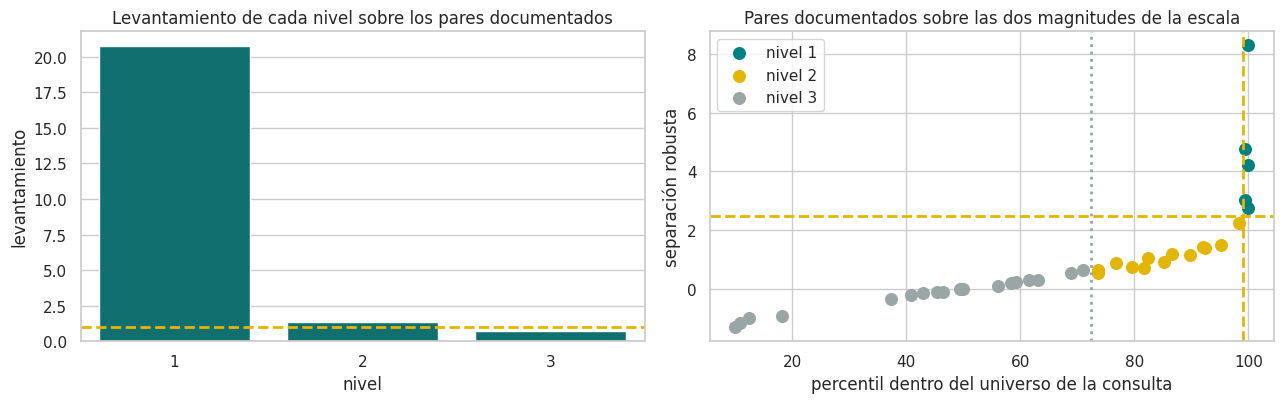

In [ ]:
percentil_pares = np.array([PERCENTIL[FILA_CONSULTA[a], COLUMNA_CANDIDATA[d]] for a, d in zip(pares_04a["id_formula_lujo"], pares_04a["id_formula_dupe"])])
separacion_pares = np.array([SEPARACION[FILA_CONSULTA[a], COLUMNA_CANDIDATA[d]] for a, d in zip(pares_04a["id_formula_lujo"], pares_04a["id_formula_dupe"])])
SEPARACION_NIVEL_1 = round(float(np.percentile(SEPARACION.max(axis=1), 10)), 6)
PERCENTIL_NIVEL_2 = round(float(np.median(percentil_pares)), 6)

ETIQUETAS = {1: "Equivalencia respaldada por la fórmula", 2: "Alternativa plausible con respaldo parcial", 3: "Sin respaldo de fórmula"}
DESCRIPCIONES = {
    1: "La fórmula base de esta alternativa es de las más próximas del catálogo accesible y destaca con claridad del resto de su universo.",
    2: "La fórmula base es compatible, pero no se distingue de un grupo amplio de alternativas igual de próximas.",
    3: "La fórmula base no respalda la equivalencia; existen muchas alternativas más próximas en el catálogo accesible.",
}


def nivel_de(percentil, separacion):
    return np.where((percentil >= PERCENTIL_NIVEL_1) & (separacion >= SEPARACION_NIVEL_1), 1, np.where(percentil >= PERCENTIL_NIVEL_2, 2, 3))


NIVEL = nivel_de(PERCENTIL, SEPARACION)
nivel_pares = nivel_de(percentil_pares, separacion_pares)


def niveles_desde(similitud):
    rango = np.vstack([rango_promedio(fila) for fila in similitud])
    mediana = np.median(similitud, axis=1, keepdims=True)
    separacion = (similitud - mediana) / (1.4826 * np.median(np.abs(similitud - mediana), axis=1, keepdims=True))
    return nivel_de(100.0 * (1.0 - (rango - 1.0) / similitud.shape[1]), separacion)


RUIDO_NUMERICO = np.random.default_rng(SEMILLA).uniform(-3e-16, 3e-16, SIMILITUD.shape)
NIVELES_ESTABLES = bool(np.array_equal(niveles_desde(SIMILITUD + RUIDO_NUMERICO), NIVEL))
calibracion = pd.DataFrame([
    {"nivel": n, "etiqueta": ETIQUETAS[n], "porcion_universo": float((NIVEL == n).mean()), "pares_documentados": int((nivel_pares == n).sum()),
     "porcion_pares": float((nivel_pares == n).mean()), "levantamiento": float((nivel_pares == n).mean() / (NIVEL == n).mean()),
     "candidatas_por_consulta_mediana": float(np.median((NIVEL == n).sum(axis=1)))}
    for n in (1, 2, 3)
])
consultas_con_nivel_1 = int((NIVEL == 1).any(axis=1).sum())
levantamientos = calibracion.set_index("nivel")["levantamiento"]

assert levantamientos[1] > levantamientos[2] > levantamientos[3] and levantamientos[1] > 1.0
assert calibracion.loc[0, "porcion_universo"] < 0.02 and consultas_con_nivel_1 / len(IDS_ALTA) > 0.80
assert (np.take_along_axis(NIVEL, ORDEN_COMPLETO[:, :K_NEGOCIO], axis=1) < 3).all()
assert NIVELES_ESTABLES, "Los niveles cambian ante ruido numérico del orden de la precisión de máquina"
print(f"Umbral de separación del nivel 1: {SEPARACION_NIVEL_1:.3f}")
print(f"Umbral de percentil del nivel 2: {PERCENTIL_NIVEL_2:.2f}")
print()
print(calibracion.round(4).to_string(index=False))
print()
print(f"Consultas con al menos una candidata de nivel 1: {consultas_con_nivel_1} de {len(IDS_ALTA)}")
print(f"Niveles idénticos ante ruido numérico del orden de la precisión de máquina: {NIVELES_ESTABLES}")

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.barplot(data=calibracion, x="nivel", y="levantamiento", ax=ejes[0], color=COLOR_PRINCIPAL)
ejes[0].axhline(1.0, color=COLOR_SECUNDARIO, linestyle="--", linewidth=2)
ejes[0].set_title("Levantamiento de cada nivel sobre los pares documentados")
colores_nivel = {1: COLOR_PRINCIPAL, 2: COLOR_SECUNDARIO, 3: COLOR_NEUTRO}
for n in (1, 2, 3):
    ejes[1].scatter(percentil_pares[nivel_pares == n], separacion_pares[nivel_pares == n], s=70, color=colores_nivel[n], label=f"nivel {n}")
ejes[1].axvline(PERCENTIL_NIVEL_2, color=COLOR_NEUTRO, linestyle=":", linewidth=2)
ejes[1].axvline(PERCENTIL_NIVEL_1, color=COLOR_SECUNDARIO, linestyle="--", linewidth=2)
ejes[1].axhline(SEPARACION_NIVEL_1, color=COLOR_SECUNDARIO, linestyle="--", linewidth=2)
ejes[1].set_title("Pares documentados sobre las dos magnitudes de la escala")
ejes[1].set_xlabel("percentil dentro del universo de la consulta")
ejes[1].set_ylabel("separación robusta")
ejes[1].legend()
fig.tight_layout()
plt.show()

### Ficha S4. Explicación del resultado

**1. Definición y justificación de negocio.** Un sistema que entrega una lista sin razones obliga a la usuaria a confiar o desconfiar en bloque. La explicación convierte el puntaje en un argumento verificable en la etiqueta del producto y sostiene la transparencia como promesa de marca.

**2. Construcción.** La similitud híbrida es aditiva y se descompone sin aproximaciones. Para vectores de vehículo $u, v$ y de perfil $p, q$,

$$\text{sim} = \alpha \sum_j \frac{u_j v_j}{\lVert u \rVert \lVert v \rVert} + (1-\alpha) \sum_m \frac{p_m q_m}{\lVert p \rVert \lVert q \rVert},$$

de modo que cada ingrediente y cada variable funcional aportan un sumando identificable.

**3. Diagnóstico.** Como el decaimiento seleccionado es uniforme, todos los ingredientes compartidos aportan exactamente el mismo sumando al coseno, y ordenarlos por aporte es imposible.

**4. Decisión de tratamiento.** El orden de presentación es una decisión de comunicación y no una atribución del modelo. Los ingredientes compartidos se ordenan por su posición media de declaración en las dos fórmulas, la única aproximación pública a su concentración, y se señalan aparte los poco comunes, presentes en a lo sumo el cinco por ciento del catálogo, porque compartir un componente de uso general no es evidencia y compartir uno infrecuente sí.

In [ ]:
NOMBRE_INGREDIENTE = base_ponderada.drop_duplicates("ingrediente").set_index("ingrediente")["nombre_ingrediente"]
SOPORTE_INGREDIENTE = vocabulario_base.set_index("ingrediente")["soporte"]
UMBRAL_SOPORTE = SOPORTE_POCO_COMUN * len(formulas)
RANGO_EN_FORMULA = base_vocabulario.set_index(["id_formula", "ingrediente"])["rango_base"]
NOMBRE_VARIABLE = {
    "n_ingredientes_base": "longitud del vehículo", "n_funciones": "diversidad de funciones", "n_destacados": "ingredientes destacados",
    "prop_emoliente": "carga emoliente", "prop_control_viscosidad": "control de viscosidad", "prop_antioxidante": "carga antioxidante",
    "prop_perfume": "carga de perfume", "prop_conservador": "sistema conservador", "prop_solvente": "carga de solventes",
    "prop_humectante": "carga humectante", "prop_emulsionante": "carga emulsionante", "prop_tensioactivo": "carga tensioactiva",
    "prop_identico_piel": "componentes idénticos a la piel", "prop_abrasivo": "carga abrasiva", "prop_calmante": "carga calmante",
    "prop_antimicrobiano": "carga antimicrobiana", "prop_regulador_ph": "regulación de pH", "prop_comunicador_celular": "comunicadores celulares",
    "prop_quelante": "agentes quelantes", "prop_exfoliante": "carga exfoliante", "prop_aclarante": "agentes aclarantes",
    "prop_superstar": "ingredientes de calificación superior", "prop_goodie": "ingredientes bien calificados",
    "prop_no_take": "ingredientes sin calificación favorable", "prop_icky": "ingredientes mal calificados",
    "prop_sin_calificacion": "ingredientes sin calificación editorial", "rango_primer_emoliente": "posición del primer emoliente",
    "rango_primer_humectante": "posición del primer humectante", "rango_primer_control_viscosidad": "posición del primer estructurante",
}


def explicar(id_lujo, id_dupe, n_ingredientes=6, n_variables=4):
    fila_lujo, fila_dupe = IDX_FORMULA[id_lujo], IDX_FORMULA[id_dupe]
    u, v = np.asarray(MATRIZ_BASE[fila_lujo].todense()).ravel(), np.asarray(MATRIZ_BASE[fila_dupe].todense()).ravel()
    aporte_ingredientes = (u * v) / (np.linalg.norm(u) * np.linalg.norm(v))
    p, q = MATRIZ_PERFIL[fila_lujo], MATRIZ_PERFIL[fila_dupe]
    aporte_perfil = (p * q) / (np.linalg.norm(p) * np.linalg.norm(q))
    coseno_ingredientes, coseno_perfil = float(aporte_ingredientes.sum()), float(aporte_perfil.sum())
    similitud = ALFA * coseno_ingredientes + (1.0 - ALFA) * coseno_perfil

    compartidos = []
    for columna in np.flatnonzero(aporte_ingredientes > 0):
        ingrediente = vocabulario[columna]
        rango_lujo, rango_dupe = float(RANGO_EN_FORMULA[(id_lujo, ingrediente)]), float(RANGO_EN_FORMULA[(id_dupe, ingrediente)])
        soporte_catalogo = int(SOPORTE_INGREDIENTE.get(ingrediente, 0))
        compartidos.append({"ingrediente": NOMBRE_INGREDIENTE.get(ingrediente, ingrediente), "rango_lujo": rango_lujo, "rango_dupe": rango_dupe,
                            "rango_promedio": (rango_lujo + rango_dupe) / 2.0, "formulas_del_catalogo": soporte_catalogo,
                            "poco_comun": soporte_catalogo <= UMBRAL_SOPORTE})
    compartidos = pd.DataFrame(compartidos, columns=["ingrediente", "rango_lujo", "rango_dupe", "rango_promedio", "formulas_del_catalogo", "poco_comun"])
    compartidos = compartidos.sort_values(["rango_promedio", "formulas_del_catalogo"], kind="stable").reset_index(drop=True)
    perfil = pd.DataFrame({"variable": [NOMBRE_VARIABLE.get(x, x) for x in VARIABLES_PERFIL], "valor_lujo": p, "valor_dupe": q, "aporte": aporte_perfil}
                          ).sort_values("aporte", ascending=False, kind="stable").reset_index(drop=True)

    destacados = compartidos.head(n_ingredientes)["ingrediente"].tolist()
    distintivos = compartidos.loc[compartidos["poco_comun"], "ingrediente"].head(3).tolist()
    familias = perfil.head(n_variables)["variable"].tolist()
    if len(compartidos) == 0:
        encabezado = "No comparten ningún ingrediente de la base química visible para el modelo."
    elif len(compartidos) == 1:
        encabezado = f"Comparten un solo ingrediente de la base química visible para el modelo, {destacados[0]}."
    else:
        encabezado = f"Comparten {len(compartidos)} ingredientes de la base química visible para el modelo, encabezados por {', '.join(destacados[:3])}."
    resumen = (encabezado + (f" Coincidencias poco comunes en el catálogo: {', '.join(distintivos)}." if distintivos else "")
               + f" La arquitectura funcional coincide sobre todo en {', '.join(familias[:2])}.")
    return {"similitud": similitud, "coseno_ingredientes": coseno_ingredientes, "coseno_perfil": coseno_perfil,
            "aporte_relativo_ingredientes": ALFA * coseno_ingredientes / similitud, "aporte_relativo_perfil": (1.0 - ALFA) * coseno_perfil / similitud,
            "ingredientes_compartidos": compartidos, "perfil_funcional": perfil.head(n_variables), "resumen": resumen}


diferencias_descomposicion = [
    abs(explicar(par["id_formula_lujo"], par["id_formula_dupe"])["similitud"] - SIMILITUD[FILA_CONSULTA[par["id_formula_lujo"]], COLUMNA_CANDIDATA[par["id_formula_dupe"]]])
    for _, par in pares_04a.iterrows()
]
assert max(diferencias_descomposicion) < 1e-9, "La descomposición no reconstruye la similitud de la matriz"

par_ejemplo = pares_04a.sort_values("rango_modelo_final", kind="stable").iloc[0]
ejemplo = explicar(par_ejemplo["id_formula_lujo"], par_ejemplo["id_formula_dupe"])
print(f"{par_ejemplo['marca_lujo']} {par_ejemplo['linea_lujo']} contra {par_ejemplo['marca_dupe']} {par_ejemplo['linea_dupe']}")
print(f"Similitud {ejemplo['similitud']:.4f}; aporte de ingredientes {ejemplo['aporte_relativo_ingredientes']:.1%}, aporte de perfil {ejemplo['aporte_relativo_perfil']:.1%}")
print()
print(ejemplo["ingredientes_compartidos"].head(8).round(2).to_string(index=False))
print()
print(ejemplo["perfil_funcional"].round(3).to_string(index=False))
print()
print(ejemplo["resumen"])

Charlotte Tilbury Matte Revolution contra KIKO Milano Smart Fusion Lipstick
Similitud 0.7659; aporte de ingredientes 44.3%, aporte de perfil 55.7%

                                           ingrediente  rango_lujo  rango_dupe  rango_promedio  formulas_del_catalogo  poco_comun
                                            Polybutene         6.0         1.0             3.5                    212       False
                                          Polyethylene         5.0         3.0             4.0                    122       False
          Cera Microcristallina (Microcrystalline Wax)         4.0         4.0             4.0                    140       False
                         Caprylic/​Capric Triglyceride        11.0         2.0             6.5                    215       False
                                   Dicalcium Phosphate         9.0         5.0             7.0                     50       False
                                        Ethyl Vanillin        10.0      

### Ficha S5. Arquetipos de fórmula, modelo no supervisado secundario

**1. Definición y justificación de negocio.** El motor de recuperación responde consultas pero no describe el catálogo. Una partición en arquetipos aporta vocabulario: permite que la interfaz diga a qué familia de construcción pertenece una fórmula antes de compararla con nada.

**2. Construcción.** Se agrupa el catálogo sobre el perfil funcional escalado mediante k medias con inicialización múltiple, y la calidad de cada partición se evalúa con el coeficiente de silueta. La representación se fija antes de elegir el número de grupos, por un criterio de información retenida: el mínimo número de componentes principales que conserva el ochenta por ciento de la varianza. La silueta crece de forma mecánica al reducir la dimensión, porque las distancias se concentran menos, de modo que elegir la representación por silueta máxima premiaría la pérdida de información.

**4. Decisión de tratamiento.** Se adopta la partición de silueta máxima dentro de la representación fijada. Valores bajos de silueta indican que el espacio de fórmulas es un continuo y no un conjunto de grupos separados, coherente con haber evaluado el modelo con métricas de recuperación y no de cohesión. Los arquetipos se usan como etiqueta descriptiva del catálogo y no como evidencia de segmentos naturales del mercado. Cada arquetipo se nombra por las dos variables en que su perfil medio más se aleja de la media global.

Componentes necesarios para retener el 80% de la varianza: 11

 k  silueta  grupo_menor
 2   0.1462          302
 3   0.1327          147
 4   0.1407          130
 5   0.1459           36
 6   0.1492           35
 7   0.1508           36
 8   0.1408           36
 9   0.1376           34
10   0.1434            3

Dependencia de la silueta respecto de la dimensión de la representación
 componentes  varianza_retenida  silueta_maxima
           2              0.308           0.371
           3              0.422           0.308
           5              0.555           0.227
          11              0.809           0.151
          29              1.000           0.120

Arquetipos: 7, silueta 0.1508
 arquetipo                                                                              nombre  formulas  gama_alta formato_dominante
         0 Perfil dominado por ingredientes sin calificación favorable y control de viscosidad       164         38             barra
         1                 

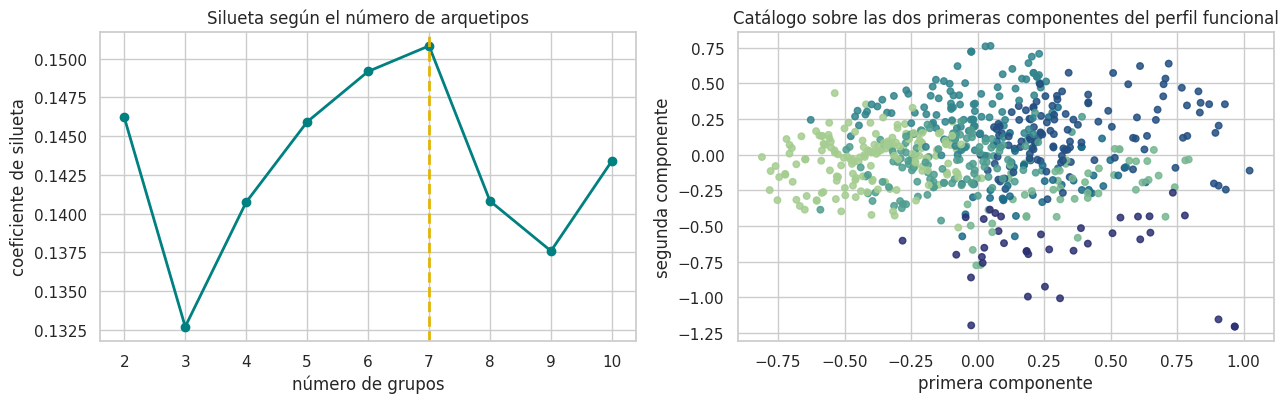

In [ ]:
analisis_componentes = PCA(random_state=SEMILLA).fit(MATRIZ_PERFIL)
varianza_acumulada = np.cumsum(analisis_componentes.explained_variance_ratio_)
N_COMPONENTES = int(np.argmax(varianza_acumulada >= VARIANZA_RETENIDA) + 1)
REPRESENTACION = PCA(n_components=N_COMPONENTES, random_state=SEMILLA).fit_transform(MATRIZ_PERFIL)

barrido_k = []
for k in REJILLA_K:
    etiquetas_k = KMeans(n_clusters=k, n_init=20, random_state=SEMILLA).fit_predict(REPRESENTACION)
    barrido_k.append({"k": k, "silueta": float(silhouette_score(REPRESENTACION, etiquetas_k)), "grupo_menor": int(np.bincount(etiquetas_k).min())})
barrido_k = pd.DataFrame(barrido_k)
K_ARQUETIPOS = int(barrido_k.loc[barrido_k["silueta"].idxmax(), "k"])

sensibilidad_representacion = []
for componentes in sorted({2, 3, 5, N_COMPONENTES, len(VARIABLES_PERFIL)}):
    datos = MATRIZ_PERFIL if componentes == len(VARIABLES_PERFIL) else PCA(n_components=componentes, random_state=SEMILLA).fit_transform(MATRIZ_PERFIL)
    sensibilidad_representacion.append({
        "componentes": componentes,
        "varianza_retenida": 1.0 if componentes == len(VARIABLES_PERFIL) else float(varianza_acumulada[componentes - 1]),
        "silueta_maxima": max(float(silhouette_score(datos, KMeans(n_clusters=k, n_init=20, random_state=SEMILLA).fit_predict(datos))) for k in REJILLA_K),
    })

modelo_arquetipos = KMeans(n_clusters=K_ARQUETIPOS, n_init=20, random_state=SEMILLA).fit(REPRESENTACION)
ARQUETIPO = modelo_arquetipos.labels_
SILUETA_FINAL = float(silhouette_score(REPRESENTACION, ARQUETIPO))
media_grupo = pd.DataFrame(MATRIZ_PERFIL, columns=VARIABLES_PERFIL).assign(arquetipo=ARQUETIPO).groupby("arquetipo")[VARIABLES_PERFIL].mean()
desviacion_arquetipo = media_grupo - pd.DataFrame(MATRIZ_PERFIL, columns=VARIABLES_PERFIL).mean()
nombres_arquetipo = {
    a: "Perfil dominado por " + " y ".join(NOMBRE_VARIABLE.get(v, v) for v in desviacion_arquetipo.loc[a].sort_values(ascending=False, kind="stable").index[:2])
    for a in range(K_ARQUETIPOS)
}
resumen_arquetipos = pd.DataFrame({
    "arquetipo": range(K_ARQUETIPOS), "nombre": [nombres_arquetipo[a] for a in range(K_ARQUETIPOS)], "formulas": np.bincount(ARQUETIPO),
    "gama_alta": [int(((ARQUETIPO == a) & formulas["gama"].eq("alta").to_numpy()).sum()) for a in range(K_ARQUETIPOS)],
    "formato_dominante": [formulas.loc[ARQUETIPO == a, "formato"].mode().iloc[0] for a in range(K_ARQUETIPOS)],
})

assert len(ARQUETIPO) == len(formulas) and np.bincount(ARQUETIPO).min() >= 10
assert SILUETA_FINAL == barrido_k["silueta"].max() and len(set(nombres_arquetipo.values())) == K_ARQUETIPOS
print(f"Componentes necesarios para retener el {VARIANZA_RETENIDA:.0%} de la varianza: {N_COMPONENTES}")
print()
print(barrido_k.round(4).to_string(index=False))
print()
print("Dependencia de la silueta respecto de la dimensión de la representación")
print(pd.DataFrame(sensibilidad_representacion).round(3).to_string(index=False))
print()
print(f"Arquetipos: {K_ARQUETIPOS}, silueta {SILUETA_FINAL:.4f}")
print(resumen_arquetipos.to_string(index=False))

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.2))
ejes[0].plot(barrido_k["k"], barrido_k["silueta"], marker="o", color=COLOR_PRINCIPAL, linewidth=2)
ejes[0].axvline(K_ARQUETIPOS, color=COLOR_SECUNDARIO, linestyle="--", linewidth=2)
ejes[0].set_title("Silueta según el número de arquetipos")
ejes[0].set_xlabel("número de grupos")
ejes[0].set_ylabel("coeficiente de silueta")
ejes[1].scatter(REPRESENTACION[:, 0], REPRESENTACION[:, 1], c=ARQUETIPO, cmap="crest", s=22, alpha=0.85)
ejes[1].set_title("Catálogo sobre las dos primeras componentes del perfil funcional")
ejes[1].set_xlabel("primera componente")
ejes[1].set_ylabel("segunda componente")
fig.tight_layout()
plt.show()

### Ficha S6. Tabla de catálogo para la interfaz

**1. Definición y justificación de negocio.** La interfaz no debe conocer la estructura analítica del proyecto. Necesita una sola tabla, una fila por fórmula, con los atributos que muestra y aquellos por los que filtra, en términos que la usuaria reconozca.

**2. Construcción.** Se resuelve el nombre comercial de cada marca, se toma el nombre de producto de la capa de presentación de la sección 11 junto con su clave de línea, se colapsan los efectos declarados en una lista legible, se traducen la aptitud vegana y la clasificación ética y se adjunta el arquetipo.

**4. Decisión de tratamiento.** El filtro ético se implementa con dos estados y no con tres, porque ninguna marca económica del catálogo queda en zona gris y un tercer estado nunca cambiaría el resultado. El filtro vegano conserva solo la aptitud vegana por fórmula y excluye el origen incierto y la dependencia del tono, porque una promesa vegana que admite casos dudosos no es una promesa.

In [ ]:
NOMBRE_MARCA = {
    "benefit": "Benefit", "catrice": "Catrice", "chanel": "Chanel", "charlotte-tilbury": "Charlotte Tilbury", "clinique": "Clinique",
    "dior": "Dior", "elf": "e.l.f.", "essence": "essence", "fenty-beauty": "Fenty Beauty", "kiko": "KIKO Milano", "laneige": "Laneige",
    "loreal": "L'Oreal", "mac": "MAC", "maybelline": "Maybelline", "milani": "Milani", "nyx": "NYX", "revlon": "Revlon",
    "revolution": "Revolution", "too-faced": "Too Faced", "wet-n-wild": "Wet n Wild",
}
NOMBRE_EFECTO = {
    "efecto_voluminizador": "voluminizador", "efecto_larga_duracion": "larga duración", "efecto_transfer_proof": "resistente a transferencia",
    "efecto_resistente_agua": "resistente al agua", "efecto_hidratante": "hidratante", "efecto_reparador": "reparador",
    "efecto_proteccion_solar": "protección solar",
}
NOMBRE_VEGANA = {"vegana_por_formula": "vegana por fórmula", "no_vegana": "no vegana", "origen_incierto": "origen incierto", "depende_del_tono": "depende del tono"}
NOMBRE_ETICO = {"certificado": "libre de crueldad animal", "zona_gris": "evidencia contradictoria", "no_libre": "no libre de crueldad animal", "sin_dato": "sin clasificación"}
assert set(formulas["marca"]) <= set(NOMBRE_MARCA)

nombres_por_formula = nombres_catalogo.set_index("id_formula")
catalogo = pd.DataFrame({
    "id_formula": formulas["id_formula"],
    "marca": formulas["marca"].map(NOMBRE_MARCA),
    "marca_catalogo": formulas["marca"],
    "nombre": formulas["id_formula"].map(nombres_por_formula["nombre_comercial"]),
    "gama": formulas["gama"],
    "formato": formulas["formato"],
    "acabado": formulas["acabado"],
    "efectos": [", ".join(NOMBRE_EFECTO[c] for c in NOMBRE_EFECTO if bool(fila[c])) or "sin efecto declarado" for _, fila in formulas.iterrows()],
    "aptitud_vegana": formulas["aptitud_vegana"].map(NOMBRE_VEGANA),
    "es_vegana": formulas["aptitud_vegana"].eq("vegana_por_formula"),
    "clasificacion_etica": formulas["marca"].map(clasificacion_por_marca).fillna("sin_dato").map(NOMBRE_ETICO),
    "es_libre_crueldad": formulas["marca"].map(clasificacion_por_marca).eq("certificado"),
    "arquetipo": ARQUETIPO,
    "nombre_arquetipo": [nombres_arquetipo[a] for a in ARQUETIPO],
    "n_ingredientes_base": formulas["n_ingredientes_base"],
    "formato_baja_confianza": formulas["formato_baja_confianza"].astype(bool),
    "url_representante": formulas["url_representante"],
    "clave_linea": formulas["id_formula"].map(nombres_por_formula["clave_linea"]),
    "es_representante_linea": formulas["id_formula"].map(nombres_por_formula["es_representante_linea"]).astype(bool),
})
CATALOGO_POR_ID = catalogo.set_index("id_formula")
FORMATOS_DISPONIBLES = sorted(catalogo.loc[catalogo["gama"].eq("economica"), "formato"].unique())

economicas = catalogo.loc[catalogo["gama"].eq("economica")]
cobertura_filtros = pd.DataFrame([
    {"solo_libres_crueldad": libres, "solo_veganas": veganas,
     "candidatas": int(((economicas["es_libre_crueldad"] | (not libres)) & (economicas["es_vegana"] | (not veganas))).sum())}
    for libres in (False, True) for veganas in (False, True)
])
assert catalogo["id_formula"].is_unique and catalogo[["marca", "nombre", "clave_linea", "url_representante"]].notna().all().all()
assert catalogo["clasificacion_etica"].ne(NOMBRE_ETICO["sin_dato"]).all()
assert not economicas["clasificacion_etica"].eq(NOMBRE_ETICO["zona_gris"]).any(), "Hay fórmulas económicas en zona gris"
print(f"Catálogo: {len(catalogo)} fórmulas, {catalogo['marca'].nunique()} marcas, {catalogo['clave_linea'].nunique()} líneas comerciales")
print(f"Fórmulas cuyo nombre visible difiere del título de página: {int((catalogo['nombre'] != formulas['nombre_representante']).sum())}")
print()
print("Tamaño del universo económico bajo cada combinación de filtros")
print(cobertura_filtros.to_string(index=False))
print()
print(catalogo.head(4)[["id_formula", "marca", "nombre", "gama", "formato", "aptitud_vegana", "clasificacion_etica"]].to_string(index=False))

Catálogo: 645 fórmulas, 20 marcas, 548 líneas comerciales
Fórmulas cuyo nombre visible difiere del título de página: 166

Tamaño del universo económico bajo cada combinación de filtros
 solo_libres_crueldad  solo_veganas  candidatas
                False         False         498
                False          True         354
                 True         False         426
                 True          True         324

id_formula   marca                            nombre gama formato   aptitud_vegana         clasificacion_etica
     F0001 Benefit                         Gogo Tint alta   tinte  origen incierto no libre de crueldad animal
     F0002 Benefit                 Benefit Love Tint alta   tinte  origen incierto no libre de crueldad animal
     F0003 Benefit       Posietint Cheek & Lip Stain alta   tinte  origen incierto no libre de crueldad animal
     F0004 Benefit Benetint Liquid Lip & Cheek Stain alta   tinte depende del tono no libre de crueldad animal


### Ficha S7. Función de recomendación

**1. Definición y justificación de negocio.** Es el flujo principal del producto: la usuaria elige un producto de gama alta, declara sus restricciones y espera una lista corta de alternativas accesibles. La función es pura, depende solo de sus argumentos y de las estructuras precalculadas, para que la interfaz no pueda alterar el modelo por accidente.

**3. Diagnóstico.** La decisión delicada es sobre qué universo se calculan el percentil y la etiqueta. Si se calcularan sobre el universo filtrado, activar un filtro ascendería a una candidata mediocre al primer lugar y la interfaz la etiquetaría como equivalencia respaldada sin que nada en la fórmula hubiera cambiado.

**4. Decisión de tratamiento.** El percentil, la separación y la etiqueta se calculan siempre sobre el universo económico completo: los filtros determinan qué se muestra, no qué tan buena es una alternativa. La función emite avisos explícitos cuando los filtros vacían el universo, cuando lo reducen por debajo del umbral, cuando no reúnen las alternativas solicitadas y cuando ninguna alcanza el nivel de respaldo más alto, y todo resultado declara el alcance de lo que el sistema mide.

**6. Validación.** Se comprueba que la función respeta el número de alternativas, que toda alternativa cumple los filtros, que el orden es decreciente en similitud, que el rango y la etiqueta de una candidata no cambian al activar filtros, que los avisos se emiten en sus condiciones y que las entradas inválidas se rechazan.

In [ ]:
MENSAJE_ALCANCE = "Same Same compara la base química del producto, no el color. La equivalencia de tono debe confirmarse por separado."
ES_LIBRE_CRUELDAD = CATALOGO_POR_ID.loc[IDS_ECONOMICA, "es_libre_crueldad"].to_numpy()
ES_VEGANA = CATALOGO_POR_ID.loc[IDS_ECONOMICA, "es_vegana"].to_numpy()
FORMATO_CANDIDATAS = CATALOGO_POR_ID.loc[IDS_ECONOMICA, "formato"].to_numpy()
COLUMNAS_RESULTADO = ["posicion", "id_formula", "marca", "nombre", "formato", "acabado", "efectos", "similitud", "rango_en_catalogo",
                      "percentil", "separacion", "nivel", "etiqueta", "aptitud_vegana", "clasificacion_etica", "arquetipo", "explicacion", "url_representante"]


def construir_universo(solo_libres_crueldad=False, solo_veganas=False, formatos=None):
    mascara = np.ones(len(IDS_ECONOMICA), dtype=bool)
    if solo_libres_crueldad:
        mascara &= ES_LIBRE_CRUELDAD
    if solo_veganas:
        mascara &= ES_VEGANA
    if formatos is not None:
        desconocidos = set(formatos) - set(FORMATOS_DISPONIBLES)
        if desconocidos:
            raise ValueError(f"Formatos no disponibles en el catálogo: {sorted(desconocidos)}")
        mascara &= np.isin(FORMATO_CANDIDATAS, list(formatos))
    return mascara


def recomendar(id_lujo, k=None, solo_libres_crueldad=False, solo_veganas=False, formatos=None):
    if id_lujo not in FILA_CONSULTA:
        raise ValueError(f"{id_lujo} no es una fórmula de gama alta del catálogo")
    k = K_NEGOCIO if k is None else int(k)
    if k < 1:
        raise ValueError("El número de alternativas solicitadas debe ser al menos uno")
    fila = FILA_CONSULTA[id_lujo]
    mascara = construir_universo(solo_libres_crueldad, solo_veganas, formatos)
    disponibles = int(mascara.sum())
    consulta = {"id_formula": id_lujo, "marca": CATALOGO_POR_ID.at[id_lujo, "marca"], "nombre": CATALOGO_POR_ID.at[id_lujo, "nombre"],
                "formato": CATALOGO_POR_ID.at[id_lujo, "formato"], "candidatas_disponibles": disponibles, "candidatas_en_catalogo": len(IDS_ECONOMICA)}
    if disponibles == 0:
        avisos = ["Los filtros seleccionados no dejan ninguna alternativa en el catálogo. Reduce las restricciones para obtener resultados.", MENSAJE_ALCANCE]
        return {"consulta": consulta, "resultados": pd.DataFrame(columns=COLUMNAS_RESULTADO), "avisos": avisos}

    indices = np.flatnonzero(mascara)
    seleccion = indices[np.argsort(-SIMILITUD[fila, indices], kind="stable")][:k]
    filas_resultado = []
    for posicion, columna in enumerate(seleccion, start=1):
        id_candidata = IDS_ECONOMICA[columna]
        nivel = int(nivel_de(PERCENTIL[fila, columna], SEPARACION[fila, columna]))
        filas_resultado.append({
            "posicion": posicion, "id_formula": id_candidata, "marca": CATALOGO_POR_ID.at[id_candidata, "marca"],
            "nombre": CATALOGO_POR_ID.at[id_candidata, "nombre"], "formato": CATALOGO_POR_ID.at[id_candidata, "formato"],
            "acabado": CATALOGO_POR_ID.at[id_candidata, "acabado"], "efectos": CATALOGO_POR_ID.at[id_candidata, "efectos"],
            "similitud": float(SIMILITUD[fila, columna]), "rango_en_catalogo": float(RANGO[fila, columna]),
            "percentil": float(PERCENTIL[fila, columna]), "separacion": float(SEPARACION[fila, columna]), "nivel": nivel, "etiqueta": ETIQUETAS[nivel],
            "aptitud_vegana": CATALOGO_POR_ID.at[id_candidata, "aptitud_vegana"], "clasificacion_etica": CATALOGO_POR_ID.at[id_candidata, "clasificacion_etica"],
            "arquetipo": CATALOGO_POR_ID.at[id_candidata, "nombre_arquetipo"], "explicacion": explicar(id_lujo, id_candidata)["resumen"],
            "url_representante": CATALOGO_POR_ID.at[id_candidata, "url_representante"],
        })
    resultados = pd.DataFrame(filas_resultado, columns=COLUMNAS_RESULTADO)
    avisos = []
    if len(resultados) < k:
        avisos.append(f"Los filtros dejan solo {len(resultados)} alternativas, menos de las {k} solicitadas.")
    if disponibles < UNIVERSO_MINIMO_AVISO:
        avisos.append(f"Los filtros reducen el catálogo a {disponibles} alternativas de {len(IDS_ECONOMICA)}. Con un universo tan pequeño, la posición relativa deja de ser informativa.")
    if not (resultados["nivel"] == 1).any():
        avisos.append("Ninguna alternativa alcanza el nivel de equivalencia respaldada para este producto. Las opciones mostradas son las más próximas disponibles, no equivalencias verificadas.")
    avisos.append(MENSAJE_ALCANCE)
    return {"consulta": consulta, "resultados": resultados, "avisos": avisos}


demostracion = recomendar("F0144")
print(f"Consulta: {demostracion['consulta']['marca']} {demostracion['consulta']['nombre']}")
print(demostracion["resultados"][["posicion", "marca", "nombre", "formato", "similitud", "rango_en_catalogo", "percentil", "separacion", "etiqueta"]].round(3).to_string(index=False))
print()
print(demostracion["resultados"].iloc[0]["explicacion"])
restringida = recomendar("F0144", solo_libres_crueldad=True, solo_veganas=True, formatos=["tinte"])
print()
print(f"Con filtros estrictos quedan {restringida['consulta']['candidatas_disponibles']} candidatas")
print(restringida["resultados"][["posicion", "marca", "nombre", "similitud", "rango_en_catalogo", "etiqueta"]].round(3).to_string(index=False))
for aviso in restringida["avisos"]:
    print(f"Aviso: {aviso}")

Consulta: Charlotte Tilbury Matte Revolution Lipstick
 posicion       marca                                nombre formato  similitud  rango_en_catalogo  percentil  separacion                               etiqueta
        1 KIKO Milano                 Smart Fusion Lipstick   barra      0.766                1.0    100.000       4.229 Equivalencia respaldada por la fórmula
        2      Milani Supercharged Cheek And Lip Multistick   barra      0.723                2.0     99.799       3.732 Equivalencia respaldada por la fórmula
        3 KIKO Milano      Gossamer Emotion Creamy Lipstick   barra      0.670                3.0     99.598       3.120 Equivalencia respaldada por la fórmula
        4     essence         Extreme Shine Volume Lipgloss   gloss      0.658                4.0     99.398       2.975 Equivalencia respaldada por la fórmula
        5     Catrice                    Demi Matt Lipstick   barra      0.644                5.0     99.197       2.809 Equivalencia respaldada p

In [ ]:
sin_filtros = recomendar("F0428")
con_filtros = recomendar("F0428", solo_libres_crueldad=True, solo_veganas=True)
assert len(sin_filtros["resultados"]) == K_NEGOCIO and sin_filtros["resultados"]["similitud"].is_monotonic_decreasing
assert con_filtros["resultados"]["clasificacion_etica"].eq(NOMBRE_ETICO["certificado"]).all()
assert con_filtros["resultados"]["aptitud_vegana"].eq(NOMBRE_VEGANA["vegana_por_formula"]).all()
assert recomendar("F0428", formatos=["barra"])["resultados"]["formato"].eq("barra").all()
comunes = set(sin_filtros["resultados"]["id_formula"]) & set(con_filtros["resultados"]["id_formula"])
assert comunes, "No hay candidatas comunes para comprobar la invariancia del percentil"
for id_comun in comunes:
    a, b = sin_filtros["resultados"].set_index("id_formula").loc[id_comun], con_filtros["resultados"].set_index("id_formula").loc[id_comun]
    assert a["rango_en_catalogo"] == b["rango_en_catalogo"] and a["nivel"] == b["nivel"], "El rango o la etiqueta cambian al activar filtros"
vacia = recomendar("F0428", formatos=[])
estrecha = recomendar("F0428", solo_libres_crueldad=True, solo_veganas=True, formatos=["tinte"])
assert vacia["resultados"].empty and "ninguna alternativa" in vacia["avisos"][0]
assert any("deja de ser informativa" in aviso for aviso in estrecha["avisos"])
assert len(recomendar("F0428", k=3)["resultados"]) == 3
assert all(MENSAJE_ALCANCE in r["avisos"] for r in (sin_filtros, con_filtros, vacia, estrecha))
for entrada, argumentos in [("F0213", {}), ("F0428", {"formatos": ["inexistente"]}), ("F0428", {"k": 0})]:
    try:
        recomendar(entrada, **argumentos)
    except ValueError:
        continue
    raise AssertionError(f"La función no rechaza la entrada inválida {entrada} con {argumentos}")
print("Las propiedades de la función de recomendación quedan verificadas")

Las propiedades de la función de recomendación quedan verificadas


### Ficha S8. Función de validación

**1. Definición y justificación de negocio.** Es el flujo que da nombre al proyecto. La usuaria llega con un par concreto, el producto de lujo y el sustituto que vio en redes, y pide un veredicto. A diferencia de la recomendación, aquí el sistema no elige: debe pronunciarse sobre la pareja que le presentan, incluso cuando la respuesta honesta es desaconsejar la compra.

**3. Diagnóstico.** La verdad de referencia mostró que los pares con evidencia comunitaria más fuerte son los peor recuperados, porque la comunidad valida por tono y el sistema por vehículo. Un veredicto negativo no significa que el sustituto sea malo: significa que la fórmula no lo respalda.

**4. Decisión de tratamiento.** El veredicto se deriva del nivel mediante una correspondencia declarada y siempre declara su alcance. Un nivel alto produce una confirmación limitada a la fórmula que remite la verificación del tono a la usuaria; un nivel bajo produce una advertencia que distingue entre ausencia de respaldo y evidencia de mal producto, y se acompaña de la alternativa mejor posicionada para esa consulta.

**6. Validación.** La prueba más exigente es reproducir, par a par, el rango de las treinta y seis parejas de la verdad de referencia y comprobar que el veredicto coincide con el nivel que la calibración asignó a cada una.

In [ ]:
VEREDICTOS = {
    1: ("Confirmación de compra sobre la fórmula. La base química de esta alternativa es de las más próximas del catálogo accesible y destaca de su universo. "
        "La coincidencia de tono no forma parte de esta evaluación y debes confirmarla tú."),
    2: ("Compra con reservas. La base química es compatible, pero un grupo amplio de alternativas resulta igual de próximo, "
        "de modo que la evidencia de formulación no distingue a esta opción de las demás."),
    3: ("Advertencia de compra. La base química no respalda la equivalencia: el catálogo accesible ofrece muchas alternativas más próximas. "
        "Esto no significa que el producto sea de mala calidad, sino que su fórmula no sostiene la comparación que se le atribuye."),
}


def validar(id_lujo, id_dupe):
    if id_lujo not in FILA_CONSULTA:
        raise ValueError(f"{id_lujo} no es una fórmula de gama alta del catálogo")
    if id_dupe not in COLUMNA_CANDIDATA:
        raise ValueError(f"{id_dupe} no es una fórmula de gama económica del catálogo")
    fila, columna = FILA_CONSULTA[id_lujo], COLUMNA_CANDIDATA[id_dupe]
    nivel = int(nivel_de(PERCENTIL[fila, columna], SEPARACION[fila, columna]))
    mejor = IDS_ECONOMICA[int(np.argmax(SIMILITUD[fila]))]
    detalle = explicar(id_lujo, id_dupe)
    return {
        "consulta": {"id_formula": id_lujo, "marca": CATALOGO_POR_ID.at[id_lujo, "marca"], "nombre": CATALOGO_POR_ID.at[id_lujo, "nombre"]},
        "candidata": {"id_formula": id_dupe, "marca": CATALOGO_POR_ID.at[id_dupe, "marca"], "nombre": CATALOGO_POR_ID.at[id_dupe, "nombre"]},
        "similitud": float(SIMILITUD[fila, columna]), "rango_en_catalogo": float(RANGO[fila, columna]), "candidatas_en_catalogo": len(IDS_ECONOMICA),
        "percentil": float(PERCENTIL[fila, columna]), "separacion": float(SEPARACION[fila, columna]), "nivel": nivel,
        "etiqueta": ETIQUETAS[nivel], "descripcion": DESCRIPCIONES[nivel], "veredicto": VEREDICTOS[nivel],
        "mismo_formato": bool(CATALOGO_POR_ID.at[id_lujo, "formato"] == CATALOGO_POR_ID.at[id_dupe, "formato"]),
        "alternativa_mejor_posicionada": {"id_formula": mejor, "marca": CATALOGO_POR_ID.at[mejor, "marca"], "nombre": CATALOGO_POR_ID.at[mejor, "nombre"]},
        "explicacion": detalle["resumen"], "ingredientes_compartidos": detalle["ingredientes_compartidos"], "alcance": MENSAJE_ALCANCE,
    }


for id_par in ("P010", "P028", "P029"):
    par = pares_04a.loc[pares_04a["id_par"].eq(id_par)].iloc[0]
    informe = validar(par["id_formula_lujo"], par["id_formula_dupe"])
    print(f"[{id_par}] {informe['consulta']['marca']} {informe['consulta']['nombre']} contra {informe['candidata']['marca']} {informe['candidata']['nombre']}")
    print(f"  Posición {informe['rango_en_catalogo']:.0f} de {informe['candidatas_en_catalogo']}, percentil {informe['percentil']:.1f}, separación {informe['separacion']:.2f}")
    print(f"  {informe['etiqueta']}. {informe['veredicto']}")
    print(f"  {informe['explicacion']}")
    if informe["nivel"] > 1:
        mejor = informe["alternativa_mejor_posicionada"]
        print(f"  Alternativa mejor posicionada para esta consulta: {mejor['marca']} {mejor['nombre']}")
    print()

informes = [validar(par["id_formula_lujo"], par["id_formula_dupe"]) for _, par in pares_04a.iterrows()]
assert np.allclose([i["rango_en_catalogo"] for i in informes], pares_04a["rango_modelo_final"].to_numpy())
assert np.array_equal([i["nivel"] for i in informes], nivel_pares) and all(i["veredicto"] == VEREDICTOS[i["nivel"]] for i in informes)
for argumentos in [("F0213", "F0356"), ("F0144", "F0428")]:
    try:
        validar(*argumentos)
    except ValueError:
        continue
    raise AssertionError(f"La función no rechaza la pareja inválida {argumentos}")
print(f"Pares de referencia validados: {len(informes)}; distribución de veredictos: {pd.Series([i['nivel'] for i in informes]).value_counts().sort_index().to_dict()}")

registrar("matriz completa", "insumo del sistema", "Reconstrucción de las 147 por 498 similitudes desde la base química, verificada contra el ranking exportado",
          "El ranking truncado no permite validar un par cuya alternativa cae fuera de las cincuenta primeras posiciones", "Sistema consultable")
registrar("escala de comparación", "transformación", "Percentil dentro del universo de la consulta y separación robusta respecto de su mediana",
          "El coseno absoluto no es comparable entre consultas porque la densidad del vecindario varía con el producto", "Sistema consultable")
registrar("empates de similitud", "robustez numérica", "Rango promedio con tolerancia de un billonésimo entre similitudes",
          "El coseno de vehículos idénticos puede diferir en el último dígito según el procesador; un empate roto por ese ruido cambiaría el nivel de una candidata", "Sistema consultable")

registrar("capa de etiquetas", "calibración", f"Tres niveles: percentil {PERCENTIL_NIVEL_1:.0f} y separación {SEPARACION_NIVEL_1:.2f} para el alto, percentil {PERCENTIL_NIVEL_2:.1f} para el intermedio",
          "Umbrales derivados de los datos; el levantamiento se concentra en el extremo superior y no sostiene una escala más fina", "Sistema consultable")
registrar("explicación", "presentación", "Ingredientes compartidos ordenados por posición media y marcados como poco comunes bajo el cinco por ciento del catálogo",
          "Con decaimiento uniforme todos los ingredientes compartidos aportan lo mismo; el orden es una decisión de comunicación", "Sistema consultable")
registrar("arquetipos", "modelo no supervisado", f"k medias con {K_ARQUETIPOS} grupos sobre {N_COMPONENTES} componentes principales, silueta {SILUETA_FINAL:.3f}",
          "La representación se fija por varianza retenida porque la silueta crece de forma mecánica al reducir la dimensión", "Sistema consultable")
registrar("percentil bajo filtros", "regla de negocio", "Percentil, separación y etiqueta siempre sobre el universo económico completo",
          "Calcularlos sobre el universo filtrado haría que la etiqueta informara sobre la restricción y no sobre la fórmula", "Sistema consultable")
registrar("alcance declarado", "transparencia", "Todo resultado y todo veredicto declaran que el sistema compara fórmula y no color",
          "Los pares con evidencia comunitaria más fuerte son los peor recuperados, lo que indica que la comunidad valida por tono", "Sistema consultable")

[P010] Charlotte Tilbury Matte Revolution Lipstick contra KIKO Milano Smart Fusion Lipstick
  Posición 1 de 498, percentil 100.0, separación 4.23
  Equivalencia respaldada por la fórmula. Confirmación de compra sobre la fórmula. La base química de esta alternativa es de las más próximas del catálogo accesible y destaca de su universo. La coincidencia de tono no forma parte de esta evaluación y debes confirmarla tú.
  Comparten 8 ingredientes de la base química visible para el modelo, encabezados por Polybutene, Polyethylene, Cera Microcristallina (Microcrystalline Wax). Coincidencias poco comunes en el catálogo: Carthamus Tinctorius (Safflower) Seed Oil. La arquitectura funcional coincide sobre todo en carga antioxidante, ingredientes sin calificación favorable.

[P028] Fenty Beauty Slip Shine Sheer Shiny Lipstick contra Maybelline Color Sensational Lipstick
  Posición 220 de 498, percentil 56.0, separación 0.08
  Sin respaldo de fórmula. Advertencia de compra. La base química no respa

## 16. Precios de referencia en pesos mexicanos

**Objetivo.** Incorporar el precio como criterio de decisión. La propuesta de valor de Same Same es el ahorro: una equivalencia de fórmula solo se vuelve accionable cuando la usuaria sabe cuánto deja de pagar. Esta sección asigna a cada línea comercial del catálogo un precio de referencia y un rango en pesos mexicanos, declara el nivel de evidencia que sostiene cada cifra y cuantifica el ahorro en las equivalencias documentadas.

**Fundamento.** Las listas INCI no contienen precios y ningún minorista mexicano publica el surtido completo de las veinte marcas del catálogo. Se levantaron observaciones de precio en tiendas en una sola fecha y las líneas no observadas se completan con una jerarquía de estimación que usa siempre la información más cercana disponible: primero la propia línea, después la misma marca en el mismo formato y, en último lugar, un modelo log-lineal que combina el efecto de la marca y el del formato. Es una imputación multivariada y no una media global, porque el precio de un labial depende conjuntamente de quién lo fabrica y de qué tipo de producto es.

Constantes de la etapa:

* `TIPO_CAMBIO_USD_MXN = 17.71`. Tipo de cambio FIX publicado en el Diario Oficial de la Federación para el 28 de septiembre de 2026, fecha de consulta de los precios. Convierte los precios oficiales en Estados Unidos de las marcas con poca presencia en minoristas mexicanos.
* `MARCA_REFERENCIA_PRECIO = "essence"` y `FORMATO_REFERENCIA_PRECIO = "barra"`. Categorías de referencia del modelo log-lineal. La marca es la económica de mayor presencia en minoristas mexicanos y el formato es la barra, el labial por antonomasia, de modo que cada coeficiente se lee como el multiplicador del precio frente a un labial en barra de essence.
* `NIVELES_EVIDENCIA_PRECIO`. Los cuatro niveles de la jerarquía, del dato más directo al más inferido.

In [ ]:
TIPO_CAMBIO_USD_MXN = 17.71
MARCA_REFERENCIA_PRECIO = "essence"
FORMATO_REFERENCIA_PRECIO = "barra"
CANAL_OFICIAL_EXTRANJERO = "Precio oficial en EE. UU. (convertido)"
NIVELES_EVIDENCIA_PRECIO = ["Observado en México", "Precio oficial en EE. UU. convertido", "Estimado por marca y formato", "Estimado por modelo"]

### Ficha P1. Observaciones de precio en tiendas

**1. Definición y justificación de negocio.** Cada observación registra el precio regular de la presentación estándar de un producto en una tienda y, cuando existe, el precio con descuento vigente, junto con la dirección de la publicación y la fecha de consulta. Es la única fuente de precio del proyecto y, al igual que las demás decisiones manuales, se versiona como dato.

**2. Construcción.** Las fuentes son minoristas con operación en México (Sephora, Ulta Beauty, Liverpool, Walmart en artículos vendidos por la propia tienda, Sally Beauty y Sanborns), una tienda en línea con envío a México y precios en pesos, y los precios de lista en Estados Unidos de Catrice, KIKO Milano, Milani y Revolution, tomados del sitio oficial de cada marca o, en el caso de Revolution, de un minorista estadounidense, porque son marcas con pocos precios consultables en tiendas mexicanas. Cada observación se enlaza con cero, una o varias líneas comerciales del catálogo; las que no se enlazan corresponden a productos de la marca ausentes del catálogo INCI y conservan valor para el nivel de marca y formato y para el modelo.

**4. Decisión de tratamiento.** Se excluyen las presentaciones mini, los tamaños de viaje, las recargas, los vendedores externos o importadores y los precios atípicos, porque no representan lo que paga una compradora en el canal habitual. Ninguna observación se elimina: se marca como no incluida y se documenta su motivo, de modo que el criterio de exclusión es auditable.

**6. Validación.** Identificadores únicos, líneas enlazadas existentes en el catálogo y de la misma marca que la observación, moneda extranjera solo en el canal oficial extranjero, precio con descuento siempre menor que el regular y una sola fecha de consulta.

In [ ]:
observaciones_precio = pd.read_csv(localizar("observaciones_precios.csv"))
observaciones_precio["lineas"] = [[] if pd.isna(valor) else str(valor).split("|") for valor in observaciones_precio["claves_linea"]]

lineas_precio = (
    catalogo.loc[catalogo["es_representante_linea"], ["clave_linea", "marca", "nombre", "gama", "formato"]]
    .rename(columns={"nombre": "nombre_linea"})
    .sort_values(["gama", "marca", "formato", "nombre_linea"], kind="stable")
    .reset_index(drop=True)
)
lineas_precio["n_formulas"] = lineas_precio["clave_linea"].map(catalogo.groupby("clave_linea").size())
marca_de_linea = lineas_precio.set_index("clave_linea")["marca"]
gama_por_marca = catalogo.groupby("marca")["gama"].agg(lambda serie: serie.iloc[0])
observaciones_precio["gama"] = observaciones_precio["marca"].map(gama_por_marca)
FECHA_CONSULTA_PRECIOS = observaciones_precio["fecha_consulta"].iloc[0]

assert catalogo.groupby("marca")["gama"].nunique().eq(1).all() and lineas_precio["clave_linea"].is_unique
assert observaciones_precio["id_observacion"].is_unique and observaciones_precio["gama"].notna().all()
assert all(clave in marca_de_linea.index and marca_de_linea[clave] == marca
           for marca, claves in zip(observaciones_precio["marca"], observaciones_precio["lineas"]) for clave in claves)
assert observaciones_precio.loc[observaciones_precio["moneda"].ne("MXN"), "canal"].eq(CANAL_OFICIAL_EXTRANJERO).all()
assert not (observaciones_precio["precio_oferta"] >= observaciones_precio["precio_regular"]).any()
assert observaciones_precio["fecha_consulta"].nunique() == 1

print(f"Observaciones: {len(observaciones_precio)}; incluidas: {int(observaciones_precio['incluida'].sum())}; fecha de consulta: {FECHA_CONSULTA_PRECIOS}")
print(f"Líneas comerciales con al menos una observación incluida: "
      f"{len({c for claves, inc in zip(observaciones_precio['lineas'], observaciones_precio['incluida']) if inc for c in claves})} de {len(lineas_precio)}")
print()
print(pd.crosstab(observaciones_precio["canal"], observaciones_precio["gama"], margins=True, margins_name="total").to_string())
print()
print("Motivos de exclusión")
print(observaciones_precio.loc[~observaciones_precio["incluida"], "motivo_exclusion"].value_counts().to_string())

Observaciones: 156; incluidas: 139; fecha de consulta: 2026-09-28
Líneas comerciales con al menos una observación incluida: 133 de 548

gama                                    alta  economica  total
canal                                                         
Minorista en México                       67         50    117
Precio oficial en EE. UU. (convertido)     0         23     23
Tienda en línea con envío a México         0          3      3
Vendedor externo o importador              0         13     13
total                                     67         89    156

Motivos de exclusión
motivo_exclusion
Importador; KIKO Milano sin distribución oficial amplia en México                          4
Vendedor externo de importación (Nocnoc)                                                   3
Precio atípico de vendedor externo (más del doble del precio de la marca en minoristas)    3
Presentación mini                                                                          1
Recarga     

### Ficha P2. Conversión a pesos mexicanos

**1. Definición y justificación de negocio.** El precio que importa a la usuaria es el que pagaría en México. Para las marcas observadas solo en su sitio oficial de Estados Unidos, el precio en dólares debe llevarse a pesos con un criterio explícito.

**3. Diagnóstico.** La paridad cambiaria es el supuesto más neutral cuando no se conoce el margen de importación. Milani es la excepción: la marca sí tiene un producto con precio en Ulta Beauty México, de modo que su diferencial entre ambos mercados puede medirse en lugar de suponerse.

**4. Decisión de tratamiento.** Catrice, KIKO Milano y Revolution se convierten al tipo de cambio FIX. Milani se convierte con su diferencial propio, el cociente entre el precio de un mismo producto en México y su precio oficial en Estados Unidos, que ya incorpora el margen con el que la marca llega al mercado mexicano. La observación estadounidense de ese par se usa solo para el diferencial y no para asignar precio. El precio mínimo de cada observación es el menor entre el regular y el de descuento.

In [ ]:
par_milani = observaciones_precio.loc[observaciones_precio["par_diferencial"].notna()].set_index("par_diferencial")
assert set(par_milani.index) == {"mexico", "estados_unidos"} and par_milani["marca"].eq("Milani").all()
FACTOR_MILANI = float(par_milani.at["mexico", "precio_regular"] / par_milani.at["estados_unidos", "precio_regular"])

factor_conversion = np.where(observaciones_precio["moneda"].eq("MXN"), 1.0,
                             np.where(observaciones_precio["marca"].eq("Milani"), FACTOR_MILANI, TIPO_CAMBIO_USD_MXN))
observaciones_precio["precio_regular_mxn"] = observaciones_precio["precio_regular"] * factor_conversion
observaciones_precio["precio_oferta_mxn"] = observaciones_precio["precio_oferta"] * factor_conversion
observaciones_precio["precio_minimo_mxn"] = observaciones_precio[["precio_regular_mxn", "precio_oferta_mxn"]].min(axis=1)
observaciones_precio["canal_mexicano"] = observaciones_precio["canal"].ne(CANAL_OFICIAL_EXTRANJERO)

print(f"Tipo de cambio aplicado a Catrice, KIKO Milano y Revolution: {TIPO_CAMBIO_USD_MXN:.2f} pesos por dólar")
print(f"Diferencial propio de Milani: {FACTOR_MILANI:.2f} pesos por dólar de lista, "
      f"{FACTOR_MILANI / TIPO_CAMBIO_USD_MXN - 1:.0%} por encima de la paridad cambiaria")
print()
print(observaciones_precio.loc[observaciones_precio["moneda"].ne("MXN")]
      .groupby("marca")[["precio_regular", "precio_regular_mxn"]].agg(["count", "median"]).round(2).to_string())

Tipo de cambio aplicado a Catrice, KIKO Milano y Revolution: 17.71 pesos por dólar
Diferencial propio de Milani: 29.03 pesos por dólar de lista, 64% por encima de la paridad cambiaria

            precio_regular        precio_regular_mxn        
                     count median              count  median
marca                                                       
Catrice                 10   6.50                 10  115.12
KIKO Milano              4  13.50                  4  239.08
Milani                   8  11.49                  8  333.54
Revolution               1   8.00                  1  141.68


### Ficha P3. Factor de promoción típica

**1. Definición y justificación de negocio.** El precio regular es el techo de lo que paga una compradora, pero las temporadas de descuento son frecuentes en cosmética. El piso del rango debe reflejar la rebaja a la que se puede acceder de forma habitual, no una liquidación excepcional.

**2. Construcción.** Para cada gama se toma la mediana del cociente entre el precio regular y el precio con descuento en las publicaciones mexicanas incluidas que muestran ambos. La mediana resiste las promociones extremas de un solo artículo.

**3. Diagnóstico.** Las marcas de gama alta mantienen precios casi uniformes entre tiendas y descuentan poco; las económicas rotan promociones con más frecuencia. Un único factor para todo el catálogo subestimaría la rebaja accesible en gama económica y la exageraría en gama alta.

In [ ]:
incluidas_precio = observaciones_precio.loc[observaciones_precio["incluida"]].copy()
con_descuento = incluidas_precio.loc[incluidas_precio["canal_mexicano"] & incluidas_precio["precio_regular_mxn"].notna()
                                     & incluidas_precio["precio_oferta_mxn"].notna()]
cociente_descuento = con_descuento["precio_regular_mxn"] / con_descuento["precio_oferta_mxn"]
FACTOR_PROMOCION = cociente_descuento.groupby(con_descuento["gama"]).median().to_dict()

assert set(FACTOR_PROMOCION) == {"alta", "economica"}
print(cociente_descuento.groupby(con_descuento["gama"]).agg(["count", "median", "min", "max"])
      .rename(columns={"count": "publicaciones", "median": "factor", "min": "minimo", "max": "maximo"}).round(3).to_string())
print()
print(f"Descuento típico: gama alta {1 - 1 / FACTOR_PROMOCION['alta']:.1%}, gama económica {1 - 1 / FACTOR_PROMOCION['economica']:.1%}")

           publicaciones  factor  minimo  maximo
gama                                            
alta                   1   1.134   1.134   1.134
economica             22   1.250   1.040   1.667

Descuento típico: gama alta 11.8%, gama económica 20.0%


### Ficha P4. Modelo log-lineal de precio por marca y formato

**1. Definición y justificación de negocio.** Cuando una marca no tiene ninguna observación en un formato, hace falta una estimación que combine lo que se sabe de la marca en otros formatos con lo que se sabe del formato en otras marcas.

**2. Construcción.** Sobre las observaciones incluidas con precio regular se ajusta por mínimos cuadrados ordinarios

$$\ln(\text{precio}) = \beta_0 + \sum_{m} \gamma_m \, \mathbb{1}[\text{marca} = m] + \sum_{f} \delta_f \, \mathbb{1}[\text{formato} = f] + \varepsilon,$$

con essence y barra como categorías de referencia. La escala logarítmica convierte los efectos en multiplicadores, $e^{\gamma_m}$ y $e^{\delta_f}$, que es como se comportan los precios de una marca frente a otra: una marca de lujo no cuesta una cantidad fija más, cuesta varias veces más.

**3. Diagnóstico.** El modelo es aditivo en escala logarítmica y no admite interacción entre marca y formato, porque la mayoría de las combinaciones tiene una o ninguna observación y una interacción no sería estimable. La desviación estándar residual $s$ mide cuánto se aleja un precio individual de la predicción y define el ancho del rango estimado.

**6. Validación.** La matriz de diseño debe tener rango completo, todas las marcas y formatos del catálogo deben estar representados en el ajuste y el coeficiente de determinación debe mostrar que marca y formato explican la mayor parte de la variación del precio.

Observaciones del ajuste: 138; parámetros: 26; R cuadrada: 0.9567; desviación estándar residual: 0.1972
Un precio individual se aleja típicamente de la predicción por un factor de 1.22
Precio predicho para un labial en barra de essence: 74 pesos

     nivel  coeficiente  multiplicador  n_observaciones
    aceite        0.077          1.080               11
   balsamo       -0.055          0.946               17
     barra        0.000          1.000               33
delineador       -0.270          0.763               12
     gloss       -0.068          0.934               37
   liquido        0.140          1.150               19
     tinte        0.071          1.073                9

            nivel  coeficiente  multiplicador  n_observaciones
           Chanel        2.672         14.472               15
             Dior        2.581         13.214               13
Charlotte Tilbury        2.442         11.496                4
        Too Faced        2.283          9.802       

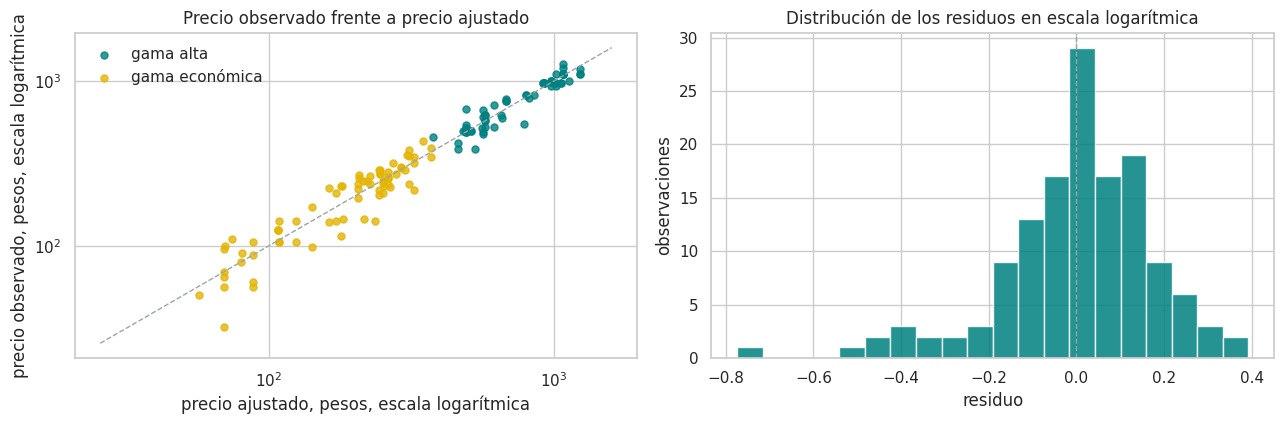

In [ ]:
ajuste_precio = incluidas_precio.loc[incluidas_precio["precio_regular_mxn"].notna()].copy()
marcas_ajuste = sorted(ajuste_precio["marca"].unique())
formatos_ajuste = sorted(ajuste_precio["formato"].unique())
columnas_marca = [m for m in marcas_ajuste if m != MARCA_REFERENCIA_PRECIO]
columnas_formato = [f for f in formatos_ajuste if f != FORMATO_REFERENCIA_PRECIO]
DISENO_PRECIO = np.column_stack(
    [np.ones(len(ajuste_precio))]
    + [ajuste_precio["marca"].eq(m).to_numpy(dtype=float) for m in columnas_marca]
    + [ajuste_precio["formato"].eq(f).to_numpy(dtype=float) for f in columnas_formato]
)
logaritmo_precio = np.log(ajuste_precio["precio_regular_mxn"].to_numpy(dtype=float))
coeficientes_precio, _, rango_diseno, _ = np.linalg.lstsq(DISENO_PRECIO, logaritmo_precio, rcond=None)
residuos_precio = logaritmo_precio - DISENO_PRECIO @ coeficientes_precio
N_AJUSTE_PRECIO, P_AJUSTE_PRECIO = DISENO_PRECIO.shape
S_MODELO_PRECIO = float(np.sqrt(residuos_precio @ residuos_precio / (N_AJUSTE_PRECIO - P_AJUSTE_PRECIO)))
R2_MODELO_PRECIO = float(1 - (residuos_precio @ residuos_precio) / np.sum((logaritmo_precio - logaritmo_precio.mean()) ** 2))

INTERCEPTO_PRECIO = float(coeficientes_precio[0])
EFECTO_MARCA = {MARCA_REFERENCIA_PRECIO: 0.0, **{m: float(coeficientes_precio[1 + i]) for i, m in enumerate(columnas_marca)}}
EFECTO_FORMATO = {FORMATO_REFERENCIA_PRECIO: 0.0,
                  **{f: float(coeficientes_precio[1 + len(columnas_marca) + i]) for i, f in enumerate(columnas_formato)}}

assert rango_diseno == P_AJUSTE_PRECIO, "La matriz de diseño del modelo de precio no tiene rango completo"
assert set(lineas_precio["marca"]) <= set(EFECTO_MARCA) and set(lineas_precio["formato"]) <= set(EFECTO_FORMATO)

tabla_modelo_precio = pd.DataFrame(
    [{"termino": "intercepto", "nivel": "", "coeficiente": INTERCEPTO_PRECIO, "n_observaciones": N_AJUSTE_PRECIO}]
    + [{"termino": "marca", "nivel": m, "coeficiente": EFECTO_MARCA[m], "n_observaciones": int(ajuste_precio["marca"].eq(m).sum())}
       for m in sorted(EFECTO_MARCA)]
    + [{"termino": "formato", "nivel": f, "coeficiente": EFECTO_FORMATO[f], "n_observaciones": int(ajuste_precio["formato"].eq(f).sum())}
       for f in sorted(EFECTO_FORMATO)]
)
tabla_modelo_precio["multiplicador"] = np.exp(tabla_modelo_precio["coeficiente"])
tabla_modelo_precio["es_referencia"] = tabla_modelo_precio["nivel"].isin([MARCA_REFERENCIA_PRECIO, FORMATO_REFERENCIA_PRECIO])

print(f"Observaciones del ajuste: {N_AJUSTE_PRECIO}; parámetros: {P_AJUSTE_PRECIO}; "
      f"R cuadrada: {R2_MODELO_PRECIO:.4f}; desviación estándar residual: {S_MODELO_PRECIO:.4f}")
print(f"Un precio individual se aleja típicamente de la predicción por un factor de {np.exp(S_MODELO_PRECIO):.2f}")
print(f"Precio predicho para un labial en barra de {MARCA_REFERENCIA_PRECIO}: {np.exp(INTERCEPTO_PRECIO):.0f} pesos")
print()
print(tabla_modelo_precio.loc[tabla_modelo_precio["termino"].eq("formato"), ["nivel", "coeficiente", "multiplicador", "n_observaciones"]]
      .round(3).to_string(index=False))
print()
print(tabla_modelo_precio.loc[tabla_modelo_precio["termino"].eq("marca")].sort_values("coeficiente", ascending=False, kind="stable")
      [["nivel", "coeficiente", "multiplicador", "n_observaciones"]].round(3).to_string(index=False))

ajustado_precio = DISENO_PRECIO @ coeficientes_precio
es_alta_ajuste = ajuste_precio["gama"].eq("alta").to_numpy()
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.4))
for mascara_gama, color, nombre in ((es_alta_ajuste, COLOR_PRINCIPAL, "gama alta"), (~es_alta_ajuste, COLOR_SECUNDARIO, "gama económica")):
    ejes[0].scatter(np.exp(ajustado_precio[mascara_gama]), np.exp(logaritmo_precio[mascara_gama]), s=26, alpha=0.8, color=color, label=nombre)
limites = [np.exp(logaritmo_precio.min()) * 0.8, np.exp(logaritmo_precio.max()) * 1.25]
ejes[0].plot(limites, limites, color=COLOR_NEUTRO, linestyle="--", linewidth=1)
ejes[0].set_xscale("log")
ejes[0].set_yscale("log")
ejes[0].set_title("Precio observado frente a precio ajustado")
ejes[0].set_xlabel("precio ajustado, pesos, escala logarítmica")
ejes[0].set_ylabel("precio observado, pesos, escala logarítmica")
ejes[0].legend(frameon=False)
ejes[1].hist(residuos_precio, bins=20, color=COLOR_PRINCIPAL, alpha=0.85)
ejes[1].axvline(0, color=COLOR_NEUTRO, linestyle="--", linewidth=1)
ejes[1].set_title("Distribución de los residuos en escala logarítmica")
ejes[1].set_xlabel("residuo")
ejes[1].set_ylabel("observaciones")
fig.tight_layout()
plt.show()

**Lectura.** La marca y el formato explican la mayor parte de la variación del logaritmo del precio; el resto corresponde a diferencias entre productos de una misma marca y formato, que el modelo no distingue por diseño. Los efectos de marca reproducen la segmentación del mercado: las casas de lujo multiplican entre seis y quince veces el precio de la referencia económica, mientras que las marcas económicas se ubican entre una y cuatro veces y media. El formato, en cambio, mueve el precio poco: ningún formato se aleja más de una cuarta parte del precio de la barra.

### Ficha P5. Asignación jerárquica del precio por línea comercial

**1. Definición y justificación de negocio.** La interfaz muestra un rango por línea comercial, que es la unidad que la usuaria reconoce en el anaquel. Cada rango debe declarar qué tan directo es el dato que lo sostiene.

**2. Construcción.** Para cada línea se aplica el primer nivel disponible:

1. **Observado en México** o **Precio oficial en EE. UU. convertido**: la línea tiene al menos una observación incluida. La referencia es el promedio de sus precios regulares, el máximo es el mayor precio regular y el mínimo es el menor entre el precio más bajo observado, con promociones, y el máximo dividido entre el factor de promoción típica de su gama.
2. **Estimado por marca y formato**: la línea no fue observada, pero sí otros productos de la misma marca en el mismo formato. Se aplican las mismas reglas sobre esas observaciones, bajo el supuesto de que una marca fija precios similares dentro de un formato.
3. **Estimado por modelo**: la combinación de marca y formato no tiene observaciones. La referencia es la predicción $\hat{p} = e^{\hat{\beta}_0 + \hat{\gamma}_m + \hat{\delta}_f}$ y el rango es $[\hat{p}\,e^{-s},\ \hat{p}\,e^{s}]$.

**4. Decisión de tratamiento.** Los mínimos se redondean a múltiplos de cinco pesos, los rangos estimados por modelo a múltiplos de diez y las referencias y máximos observados a pesos enteros, con redondeo aritmético de medios hacia arriba. La precisión aparente de un rango inferido no debe superar la de su fuente.

**6. Validación.** Toda línea recibe un nivel y un rango, todos los precios son positivos y el mínimo nunca supera la referencia ni la referencia al máximo.

Líneas comerciales por nivel de evidencia del precio
gama                                  alta  economica  total
nivel_evidencia                                             
Observado en México                     62         49    111
Precio oficial en EE. UU. convertido     0         22     22
Estimado por marca y formato            46        217    263
Estimado por modelo                     23        129    152
total                                  131        417    548

     gama             marca  lineas  con_observacion  referencia_mediana  minimo  maximo
     alta            Chanel      17               14              1100.0     820    1280
     alta              Dior      22               13               975.0     855    1280
     alta Charlotte Tilbury      15                5               830.0     545    1120
     alta         Too Faced      11                5               760.0     485    1020
     alta           Benefit       5                1               625.0  

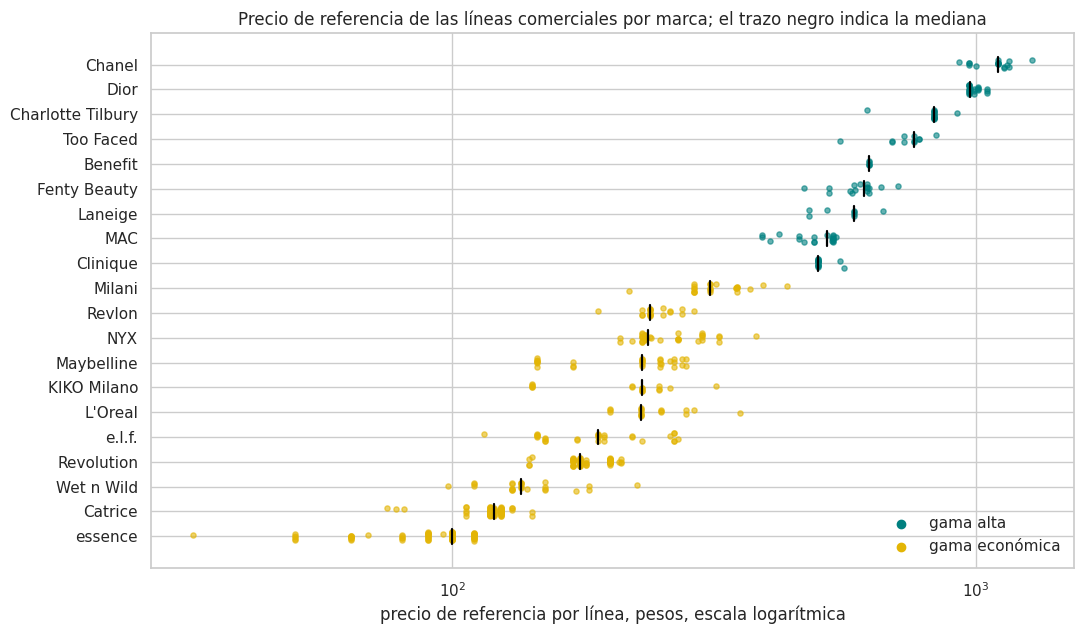

In [ ]:
def redondear(valor, multiplo=1):
    """Redondeo aritmético con medios hacia arriba al múltiplo indicado."""
    return int(math.floor(valor / multiplo + 0.5) * multiplo)


observacion_por_linea = (
    incluidas_precio[["id_observacion", "lineas", "canal_mexicano", "precio_regular_mxn", "precio_minimo_mxn"]]
    .explode("lineas").dropna(subset=["lineas"]).rename(columns={"lineas": "clave_linea"})
)
filas_precio = []
for linea in lineas_precio.itertuples(index=False):
    propias = observacion_por_linea.loc[observacion_por_linea["clave_linea"].eq(linea.clave_linea)]
    misma_marca_formato = incluidas_precio.loc[incluidas_precio["marca"].eq(linea.marca) & incluidas_precio["formato"].eq(linea.formato)]
    factor = FACTOR_PROMOCION[linea.gama]
    prediccion = math.exp(INTERCEPTO_PRECIO + EFECTO_MARCA[linea.marca] + EFECTO_FORMATO[linea.formato])
    if len(propias) or len(misma_marca_formato):
        fuente = propias if len(propias) else misma_marca_formato
        assert fuente["precio_regular_mxn"].notna().any()
        if len(propias):
            nivel = NIVELES_EVIDENCIA_PRECIO[0] if propias["canal_mexicano"].any() else NIVELES_EVIDENCIA_PRECIO[1]
        else:
            nivel = NIVELES_EVIDENCIA_PRECIO[2]
        referencia = redondear(fuente["precio_regular_mxn"].mean())
        maximo = redondear(fuente["precio_regular_mxn"].max())
        minimo = redondear(min(fuente["precio_minimo_mxn"].min(), maximo / factor), 5)
    else:
        nivel = NIVELES_EVIDENCIA_PRECIO[3]
        referencia = redondear(prediccion, 10)
        maximo = redondear(prediccion * math.exp(S_MODELO_PRECIO), 10)
        minimo = redondear(prediccion * math.exp(-S_MODELO_PRECIO), 10)
    filas_precio.append({"clave_linea": linea.clave_linea, "observaciones_linea": len(propias), "observaciones_marca_formato": len(misma_marca_formato),
                         "nivel_evidencia": nivel, "factor_promocion": factor, "prediccion_modelo": prediccion,
                         "precio_referencia": referencia, "precio_min": minimo, "precio_max": maximo})

precios_linea = lineas_precio.merge(pd.DataFrame(filas_precio), on="clave_linea", validate="one_to_one")
precios_linea["texto_interfaz"] = [f"Entre ${minimo:,} y ${maximo:,} MXN" for minimo, maximo in zip(precios_linea["precio_min"], precios_linea["precio_max"])]

assert len(precios_linea) == catalogo["clave_linea"].nunique() and precios_linea["nivel_evidencia"].isin(NIVELES_EVIDENCIA_PRECIO).all()
assert (precios_linea["precio_min"] > 0).all()
assert (precios_linea["precio_min"] <= precios_linea["precio_referencia"]).all() and (precios_linea["precio_referencia"] <= precios_linea["precio_max"]).all()

cobertura_precio = pd.crosstab(precios_linea["nivel_evidencia"], precios_linea["gama"], margins=True, margins_name="total").reindex(NIVELES_EVIDENCIA_PRECIO + ["total"])
print("Líneas comerciales por nivel de evidencia del precio")
print(cobertura_precio.to_string())
print()
resumen_marcas_precio = (
    precios_linea.groupby(["gama", "marca"])
    .agg(lineas=("clave_linea", "size"),
         con_observacion=("observaciones_linea", lambda serie: int((serie > 0).sum())),
         referencia_mediana=("precio_referencia", "median"), minimo=("precio_min", "min"), maximo=("precio_max", "max"))
    .reset_index().sort_values(["gama", "referencia_mediana"], ascending=[True, False], kind="stable")
)
print(resumen_marcas_precio.to_string(index=False))

orden_marcas = resumen_marcas_precio.sort_values("referencia_mediana", kind="stable")["marca"].tolist()
fig, eje = plt.subplots(figsize=(11, 6.5))
for posicion, marca in enumerate(orden_marcas):
    valores = precios_linea.loc[precios_linea["marca"].eq(marca), "precio_referencia"].to_numpy()
    color = COLOR_PRINCIPAL if gama_por_marca[marca] == "alta" else COLOR_SECUNDARIO
    eje.scatter(valores, np.full(len(valores), posicion) + np.random.default_rng(SEMILLA + posicion).uniform(-0.18, 0.18, len(valores)),
                s=14, alpha=0.6, color=color)
    eje.plot([np.median(valores)] * 2, [posicion - 0.3, posicion + 0.3], color="black", linewidth=1.6)
eje.set_yticks(range(len(orden_marcas)))
eje.set_yticklabels(orden_marcas)
eje.set_xscale("log")
eje.set_xlabel("precio de referencia por línea, pesos, escala logarítmica")
eje.set_title("Precio de referencia de las líneas comerciales por marca; el trazo negro indica la mediana")
eje.scatter([], [], color=COLOR_PRINCIPAL, label="gama alta")
eje.scatter([], [], color=COLOR_SECUNDARIO, label="gama económica")
eje.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

### Ficha P6. Precio por fórmula y ahorro en las equivalencias documentadas

**1. Definición y justificación de negocio.** La pregunta final de la usuaria combina las dos dimensiones del producto: cuánto ahorra y qué tanto respalda la fórmula esa decisión. El ahorro se calcula sobre los treinta y seis pares de la verdad de referencia y se cruza con el nivel de respaldo que el sistema asigna a cada uno.

**2. Construcción.** Cada fórmula hereda el precio de su línea comercial. El ahorro de un par es la diferencia entre las referencias de la fórmula de gama alta y de su alternativa, en pesos y como proporción del precio de gama alta.

**3. Diagnóstico.** El ahorro es aproximado: no normaliza por gramo o mililitro, porque las presentaciones de distinto contenido no se registraron de forma sistemática, y hereda la incertidumbre del nivel de evidencia de ambos precios.

Ahorro mediano en las 36 equivalencias documentadas: 568 pesos, 72.3% del precio de gama alta
Intervalo del ahorro proporcional: de 27.5% a 88.2%

Ahorro según el respaldo de la fórmula
                                                          pares  ahorro_mediano  ahorro_proporcional_mediano
nivel_formula etiqueta_formula                                                                              
1             Equivalencia respaldada por la fórmula          5           545.0                        0.680
2             Alternativa plausible con respaldo parcial     13           601.0                        0.771
3             Sin respaldo de fórmula                        18           492.5                        0.723

Equivalencias con respaldo de fórmula de nivel 1
id_par        marca_lujo                    linea_lujo  precio_lujo  marca_dupe                       linea_dupe  precio_dupe  ahorro_proporcion
  P002           Benefit                      Benetint          625     es

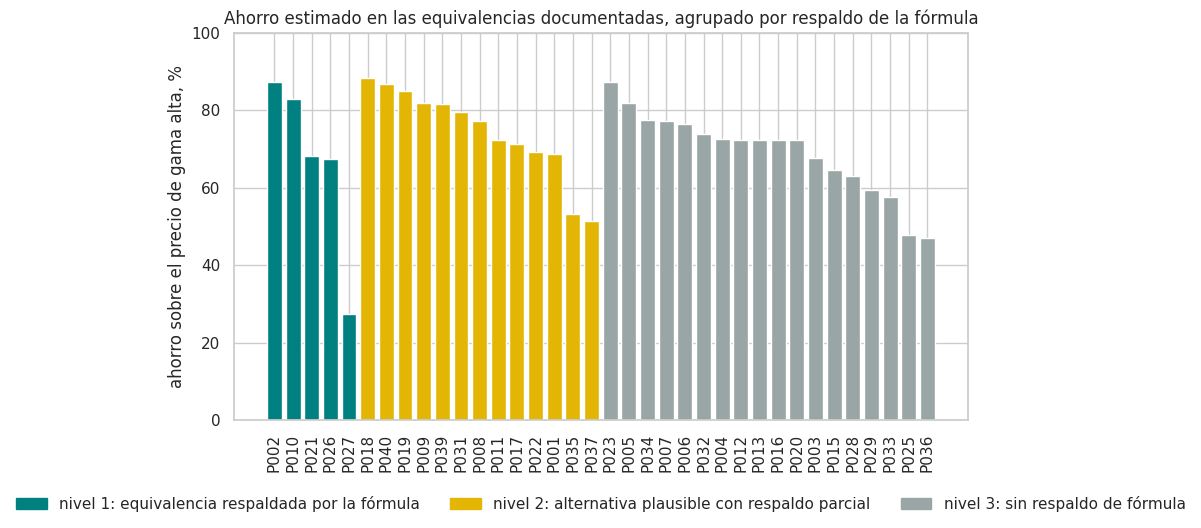


                      archivo  filas  columnas   kb
 observaciones_precio_mxn.csv    156        21 39.6
            modelo_precio.csv     28         6  1.7
            precios_linea.csv    548        15 98.2
          precios_formula.csv    645        11 98.0
ahorro_pares_documentados.csv     36        15  7.0


In [ ]:
precios_formula = catalogo[["id_formula", "clave_linea", "marca", "nombre", "gama", "formato"]].merge(
    precios_linea[["clave_linea", "nivel_evidencia", "precio_referencia", "precio_min", "precio_max", "texto_interfaz"]],
    on="clave_linea", how="left", validate="many_to_one")
assert precios_formula["precio_referencia"].notna().all() and len(precios_formula) == len(catalogo)
precio_de_formula = precios_formula.set_index("id_formula")

ahorro_pares = pares_04a[["id_par", "marca_lujo", "linea_lujo", "id_formula_lujo", "marca_dupe", "linea_dupe", "id_formula_dupe"]].copy()
ahorro_pares["precio_lujo"] = ahorro_pares["id_formula_lujo"].map(precio_de_formula["precio_referencia"])
ahorro_pares["nivel_precio_lujo"] = ahorro_pares["id_formula_lujo"].map(precio_de_formula["nivel_evidencia"])
ahorro_pares["precio_dupe"] = ahorro_pares["id_formula_dupe"].map(precio_de_formula["precio_referencia"])
ahorro_pares["nivel_precio_dupe"] = ahorro_pares["id_formula_dupe"].map(precio_de_formula["nivel_evidencia"])
ahorro_pares["ahorro_mxn"] = ahorro_pares["precio_lujo"] - ahorro_pares["precio_dupe"]
ahorro_pares["ahorro_proporcion"] = ahorro_pares["ahorro_mxn"] / ahorro_pares["precio_lujo"]
ahorro_pares["nivel_formula"] = nivel_pares
ahorro_pares["etiqueta_formula"] = ahorro_pares["nivel_formula"].map(ETIQUETAS)

print(f"Ahorro mediano en las {len(ahorro_pares)} equivalencias documentadas: {ahorro_pares['ahorro_mxn'].median():,.0f} pesos, "
      f"{ahorro_pares['ahorro_proporcion'].median():.1%} del precio de gama alta")
print(f"Intervalo del ahorro proporcional: de {ahorro_pares['ahorro_proporcion'].min():.1%} a {ahorro_pares['ahorro_proporcion'].max():.1%}")
print()
print("Ahorro según el respaldo de la fórmula")
print(ahorro_pares.groupby(["nivel_formula", "etiqueta_formula"])
      .agg(pares=("id_par", "size"), ahorro_mediano=("ahorro_mxn", "median"), ahorro_proporcional_mediano=("ahorro_proporcion", "median"))
      .round(3).to_string())
print()
print("Equivalencias con respaldo de fórmula de nivel 1")
print(ahorro_pares.loc[ahorro_pares["nivel_formula"].eq(1),
                       ["id_par", "marca_lujo", "linea_lujo", "precio_lujo", "marca_dupe", "linea_dupe", "precio_dupe", "ahorro_proporcion"]]
      .round(3).to_string(index=False))

fig, eje = plt.subplots(figsize=(11, 5.5))
orden_ahorro = ahorro_pares.sort_values(["nivel_formula", "ahorro_proporcion"], ascending=[True, False], kind="stable")
colores_nivel = {1: COLOR_PRINCIPAL, 2: COLOR_SECUNDARIO, 3: COLOR_NEUTRO}
eje.bar(range(len(orden_ahorro)), orden_ahorro["ahorro_proporcion"] * 100, color=orden_ahorro["nivel_formula"].map(colores_nivel))
eje.set_xticks(range(len(orden_ahorro)))
eje.set_xticklabels(orden_ahorro["id_par"], rotation=90)
eje.set_ylabel("ahorro sobre el precio de gama alta, %")
eje.set_ylim(0, 100)
eje.set_title("Ahorro estimado en las equivalencias documentadas, agrupado por respaldo de la fórmula")
eje.legend(handles=[Patch(color=color, label=f"nivel {nivel}: {ETIQUETAS[nivel].lower()}") for nivel, color in colores_nivel.items()],
           frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3)
fig.tight_layout()
plt.show()

registrar("precio de referencia", "variable de negocio", "Rango en pesos por línea comercial con nivel de evidencia declarado",
          "El ahorro es la propuesta de valor; una equivalencia sin precio no es accionable", "Precios de referencia")
registrar("precio no observado", "imputación multivariada", "Jerarquía: línea observada, misma marca y formato, modelo log-lineal de marca y formato",
          "El precio depende conjuntamente de la marca y del formato; una media global ignoraría ambos", "Precios de referencia")
registrar("moneda extranjera", "transformación", f"Tipo de cambio FIX {TIPO_CAMBIO_USD_MXN} y diferencial propio de Milani {FACTOR_MILANI:.2f}",
          "Paridad cambiaria cuando el margen de importación es desconocido; diferencial medido cuando la marca tiene precio en México", "Precios de referencia")
registrar("piso del rango", "regla de negocio", "Mínimo entre el precio más bajo observado y el máximo dividido entre el factor de promoción de la gama",
          "El piso refleja la rebaja habitual de temporada y no una liquidación excepcional", "Precios de referencia")
print()
print(exportar({
    "observaciones_precio_mxn.csv": observaciones_precio.drop(columns=["lineas"]),
    "modelo_precio.csv": tabla_modelo_precio,
    "precios_linea.csv": precios_linea,
    "precios_formula.csv": precios_formula,
    "ahorro_pares_documentados.csv": ahorro_pares,
}).to_string(index=False))

**Lectura.** Cerca de la mitad de las líneas de gama alta tiene precio observado en México, porque sus marcas se venden en los mismos minoristas departamentales; en gama económica menos de una de cada cinco líneas tiene observación directa y la jerarquía de estimación sostiene la mayor parte del catálogo. El factor de promoción de gama alta descansa en una sola publicación con descuento: confirma que estas marcas casi no rebajan, pero es el parámetro más frágil de la sección. En KIKO Milano el precio convertido a paridad es el de su canal oficial; los importadores registrados entre las observaciones excluidas cobran entre dos y cuatro veces y media más, de modo que el ahorro de sus equivalencias supone una compra en el canal de la marca.

El ahorro en las equivalencias documentadas supera la cuarta parte del precio de gama alta en todos los casos y ronda las tres cuartas partes en la mediana, lo que confirma que el incentivo económico que impulsa la búsqueda de sustitutos es real. El cruce con el respaldo de la fórmula es el aporte distintivo del sistema: el ahorro es comparable entre los tres niveles, de modo que el precio por sí solo no distingue una buena equivalencia de una mala. Es la fórmula la que separa un ahorro bien fundado de una compra que solo se parece en el color.

## 17. Exportación y verificación de los artefactos de la aplicación

**Objetivo.** Entregar a la interfaz un conjunto mínimo de archivos planos que contenga todo lo que necesita para responder consultas, y demostrar que un lector independiente reconstruye con ellos exactamente el mismo sistema que se evaluó en este cuaderno.

**Fundamento.** El motor de la interfaz se ejecuta como servicio web ligero: lee archivos CSV y JSON con la biblioteca estándar y opera con álgebra lineal elemental, sin cargar el entorno analítico. Por eso la exportación no transporta objetos serializados de ninguna biblioteca, sino el dato primario, los rangos de declaración y el perfil escalado, junto con los parámetros que lo convierten en similitud, escala y etiqueta. Un artefacto que depende del dato primario y de parámetros explícitos es auditable; uno que depende de un objeto binario no lo es.

| Archivo | Contenido |
|---|---|
| `catalogo_app.csv` | Una fila por fórmula: marca, nombre comercial, línea, gama, formato, acabado, efectos, aptitud vegana, clasificación ética, arquetipo y dirección de la ficha |
| `tonos_app.csv` | Tono y calificador de presentación de cada fórmula |
| `ingredientes_app.csv` | Ingredientes del vocabulario dentro del corte de rango, con nombre, calificación editorial, soporte en el catálogo y marca de coincidencia poco común |
| `perfil_app.csv` | Las veintinueve variables del perfil funcional escaladas |
| `configuracion_app.json` | Hiperparámetros, umbrales de la escala, etiquetas, veredictos, avisos, arquetipos, filtros y desempeño declarado |
| `estadisticos_consulta_app.csv` | Mediana, desviación absoluta mediana, máximos y conteos por nivel de cada consulta |
| `matriz_similitud_app.csv` e `indice_matriz_app.json` | Matriz completa en precisión simple con sus identificadores de fila y columna, para auditoría |
| `pares_documentados.csv` | Verdad de referencia con el rango que el modelo asigna a cada par |
| `precios_linea_app.csv` | Rango de precio y nivel de evidencia por línea comercial |

### Ficha E1. Construcción de los artefactos

**2. Construcción.** Cada tabla se deriva de las estructuras ya validadas en las secciones anteriores, sin recalcular nada: el catálogo de la ficha S6, la base química con el corte de rango del modelo seleccionado, el perfil escalado, la escala y la calibración de las fichas S2 y S3, los arquetipos de la ficha S5 y los precios de la sección 16. La configuración reúne en un solo objeto todo parámetro que la interfaz necesita, de modo que ningún umbral quede escrito dentro del código del servicio.

In [ ]:
catalogo_app = catalogo.sort_values("id_formula", kind="stable").reset_index(drop=True)
tonos_app = nombres_catalogo[["id_formula", "tono", "calificador_presentacion"]].sort_values("id_formula", kind="stable").reset_index(drop=True)
ingredientes_app = (
    base_vocabulario.loc[base_vocabulario["rango_base"] <= RANGO_MAXIMO_MODELO, ["id_formula", "rango_base", "ingrediente", "nombre_ingrediente", "calificacion"]]
    .assign(formulas_del_catalogo=lambda tabla: tabla["ingrediente"].map(SOPORTE_INGREDIENTE).astype(int))
    .assign(poco_comun=lambda tabla: tabla["formulas_del_catalogo"] <= UMBRAL_SOPORTE)
    .sort_values(["id_formula", "rango_base"], kind="stable").reset_index(drop=True)
)
perfil_app = pd.concat([formulas[["id_formula"]], pd.DataFrame(MATRIZ_PERFIL, columns=VARIABLES_PERFIL)], axis=1)
estadisticos_app = pd.DataFrame({
    "id_formula_lujo": IDS_ALTA, "mediana": MEDIANA_CONSULTA.ravel(), "dam": DAM_CONSULTA.ravel(),
    "similitud_maxima": SIMILITUD.max(axis=1), "separacion_maxima": SEPARACION.max(axis=1),
    "candidatas_nivel_1": (NIVEL == 1).sum(axis=1), "candidatas_nivel_2": (NIVEL == 2).sum(axis=1),
})
matriz_app = pd.DataFrame(SIMILITUD.astype(np.float32))
indice_matriz_app = {"filas": IDS_ALTA.tolist(), "columnas": IDS_ECONOMICA.tolist()}
precios_linea_app = precios_linea[["clave_linea", "marca", "nombre_linea", "gama", "formato", "nivel_evidencia",
                                   "precio_referencia", "precio_min", "precio_max", "texto_interfaz"]].copy()
configuracion_app = {
    "modelo": {"funcion_similitud": configuracion_04a["funcion_similitud"], "decaimiento": DECAIMIENTO, "rango_maximo": RANGO_MAXIMO_MODELO,
               "alfa_ingredientes": ALFA, "politica_candidatos": POLITICA_CANDIDATOS, "k_negocio": K_NEGOCIO, "tolerancia_empate": TOLERANCIA_EMPATE, "semilla": SEMILLA},
    "escala": {"base": "percentil y separación robusta sobre el universo económico completo",
               "percentil_nivel_1": PERCENTIL_NIVEL_1, "separacion_nivel_1": round(SEPARACION_NIVEL_1, 6), "percentil_nivel_2": round(PERCENTIL_NIVEL_2, 6),
               "criterio_separacion": "percentil diez de la separación del primer candidato entre las consultas del catálogo",
               "criterio_percentil": "mediana del percentil alcanzado por los pares de equivalencia documentados"},
    "etiquetas": {str(n): {"etiqueta": ETIQUETAS[n], "descripcion": DESCRIPCIONES[n], "veredicto": VEREDICTOS[n]} for n in (1, 2, 3)},
    "avisos": {"universo_minimo": UNIVERSO_MINIMO_AVISO, "alcance": MENSAJE_ALCANCE},
    "arquetipos": {"k": K_ARQUETIPOS, "componentes": N_COMPONENTES, "varianza_retenida": round(float(varianza_acumulada[N_COMPONENTES - 1]), 6),
                   "silueta": round(SILUETA_FINAL, 6), "nombres": {str(a): nombres_arquetipo[a] for a in range(K_ARQUETIPOS)}},
    "filtros": {"formatos": FORMATOS_DISPONIBLES, "etico": ["todas", "solo libres de crueldad animal"], "vegano": ["todas", "solo veganas por fórmula"]},
    "precios": {"moneda": "MXN", "fecha_consulta": FECHA_CONSULTA_PRECIOS, "tipo_cambio_usd_mxn": TIPO_CAMBIO_USD_MXN, "niveles_evidencia": NIVELES_EVIDENCIA_PRECIO},
    "desempeno_declarado": configuracion_04a["desempeno_anclas_fuera"],
}

inventario_app = exportar({
    "catalogo_app.csv": catalogo_app, "tonos_app.csv": tonos_app, "ingredientes_app.csv": ingredientes_app, "perfil_app.csv": perfil_app,
    "estadisticos_consulta_app.csv": estadisticos_app, "pares_documentados.csv": pares_04a, "precios_linea_app.csv": precios_linea_app,
}, directorio=DIRECTORIO_APP)
matriz_app.to_csv(DIRECTORIO_APP / "matriz_similitud_app.csv", header=False, index=False)
(DIRECTORIO_APP / "indice_matriz_app.json").write_text(json.dumps(indice_matriz_app, ensure_ascii=False), encoding="utf-8")
(DIRECTORIO_APP / "configuracion_app.json").write_text(json.dumps(configuracion_app, ensure_ascii=False, indent=2), encoding="utf-8")
inventario_app = pd.concat([inventario_app.astype({"filas": object, "columnas": object}), pd.DataFrame([
    {"archivo": nombre, "filas": filas, "columnas": columnas, "kb": round((DIRECTORIO_APP / nombre).stat().st_size / 1024, 1)}
    for nombre, filas, columnas in [("matriz_similitud_app.csv", SIMILITUD.shape[0], SIMILITUD.shape[1]),
                                    ("indice_matriz_app.json", "", ""), ("configuracion_app.json", "", "")]
])], ignore_index=True)
print(inventario_app.to_string(index=False))

                      archivo filas columnas    kb
             catalogo_app.csv   645       19 222.6
                tonos_app.csv   645        3   7.1
         ingredientes_app.csv  8513        7 597.8
               perfil_app.csv   645       30 226.1
estadisticos_consulta_app.csv   147        7  12.9
       pares_documentados.csv    36       26   8.6
        precios_linea_app.csv   548       10  80.6
     matriz_similitud_app.csv   147      498 761.3
       indice_matriz_app.json                  5.7
       configuracion_app.json                  3.6


### Ficha E2. Verificación por reconstrucción independiente

**1. Definición y justificación de negocio.** Que los archivos existan no prueba que sean correctos. La prueba es que un lector que solo conoce los archivos, y no las variables de este cuaderno, reconstruya el sistema y obtenga las mismas respuestas. Si la interfaz y el análisis discreparan en un solo nivel, la usuaria recibiría un veredicto distinto del que se evaluó.

**2. Construcción.** El lector sigue el contrato del motor de la interfaz: lee los archivos desde disco, ordena el vocabulario alfabéticamente, lo que solo puede alterar el último dígito de la aritmética de coma flotante, construye la matriz binaria de ingredientes con el corte de rango de la configuración, normaliza por filas, combina los dos cosenos con el alfa de la configuración, calcula el rango con la tolerancia de empate de la configuración y asigna niveles con los umbrales de la configuración.

**6. Validación.** Se exige coincidencia de la matriz dentro de la tolerancia numérica, igualdad exacta de niveles en las 73,206 parejas, igualdad del rango de los treinta y seis pares documentados, coherencia de la matriz exportada en precisión simple y cobertura completa de catálogo, tonos, perfil y precios.

In [ ]:
def leer_sistema_exportado(directorio):
    configuracion = json.loads((directorio / "configuracion_app.json").read_text(encoding="utf-8"))
    tolerancia = configuracion["modelo"]["tolerancia_empate"]
    catalogo_leido = pd.read_csv(directorio / "catalogo_app.csv").sort_values("id_formula", kind="stable")
    ingredientes_leidos = pd.read_csv(directorio / "ingredientes_app.csv")
    perfil_leido = pd.read_csv(directorio / "perfil_app.csv").set_index("id_formula").loc[catalogo_leido["id_formula"]]
    orden = catalogo_leido["id_formula"].tolist()
    posicion = {f: i for i, f in enumerate(orden)}
    vocabulario_leido = sorted(ingredientes_leidos["ingrediente"].unique())
    columna = {v: k for k, v in enumerate(vocabulario_leido)}
    dentro = ingredientes_leidos.loc[ingredientes_leidos["rango_base"] <= configuracion["modelo"]["rango_maximo"]]
    base = np.zeros((len(orden), len(vocabulario_leido)))
    base[dentro["id_formula"].map(posicion).to_numpy(), dentro["ingrediente"].map(columna).to_numpy()] = 1.0

    def normalizar(matriz):
        normas = np.linalg.norm(matriz, axis=1, keepdims=True)
        return matriz / np.where(normas == 0.0, 1.0, normas)

    def rango_de_fila(fila):
        ordenada = np.sort(fila)
        hasta = np.searchsorted(ordenada, fila + tolerancia, side="right")
        desde = np.searchsorted(ordenada, fila - tolerancia, side="left")
        return (len(fila) - hasta) + (hasta - desde + 1) / 2.0

    alta = np.flatnonzero(catalogo_leido["gama"].eq("alta").to_numpy())
    economica = np.flatnonzero(catalogo_leido["gama"].eq("economica").to_numpy())
    base_normalizada, perfil_normalizado = normalizar(base), normalizar(perfil_leido.to_numpy(dtype=float))
    alfa = configuracion["modelo"]["alfa_ingredientes"]
    similitud = (alfa * base_normalizada[alta] @ base_normalizada[economica].T
                 + (1.0 - alfa) * perfil_normalizado[alta] @ perfil_normalizado[economica].T)
    rango = np.vstack([rango_de_fila(fila) for fila in similitud])
    percentil = 100.0 * (1.0 - (rango - 1.0) / similitud.shape[1])
    mediana = np.median(similitud, axis=1, keepdims=True)
    separacion = (similitud - mediana) / (1.4826 * np.median(np.abs(similitud - mediana), axis=1, keepdims=True))
    escala = configuracion["escala"]
    nivel = np.where((percentil >= escala["percentil_nivel_1"]) & (separacion >= escala["separacion_nivel_1"]), 1,
                     np.where(percentil >= escala["percentil_nivel_2"], 2, 3))
    ids_alta = catalogo_leido["id_formula"].to_numpy()[alta]
    ids_economica = catalogo_leido["id_formula"].to_numpy()[economica]
    return {"similitud": similitud, "rango": rango, "nivel": nivel, "ids_alta": ids_alta, "ids_economica": ids_economica, "configuracion": configuracion}


reconstruido = leer_sistema_exportado(DIRECTORIO_APP)
matriz_leida = pd.read_csv(DIRECTORIO_APP / "matriz_similitud_app.csv", header=None).to_numpy()
indice_leido = json.loads((DIRECTORIO_APP / "indice_matriz_app.json").read_text(encoding="utf-8"))
pares_leidos = pd.read_csv(DIRECTORIO_APP / "pares_documentados.csv")
fila_leida = {f: i for i, f in enumerate(reconstruido["ids_alta"])}
columna_leida = {f: j for j, f in enumerate(reconstruido["ids_economica"])}
rango_pares_leido = np.array([reconstruido["rango"][fila_leida[a], columna_leida[d]] for a, d in zip(pares_leidos["id_formula_lujo"], pares_leidos["id_formula_dupe"])])

verificaciones = pd.DataFrame([
    {"verificacion": "identificadores de consulta y candidata", "resultado": bool(np.array_equal(reconstruido["ids_alta"], IDS_ALTA) and np.array_equal(reconstruido["ids_economica"], IDS_ECONOMICA))},
    {"verificacion": "matriz de similitud reconstruida", "resultado": bool(np.abs(reconstruido["similitud"] - SIMILITUD).max() < 1e-9)},
    {"verificacion": "niveles de las 73,206 parejas", "resultado": bool(np.array_equal(reconstruido["nivel"], NIVEL))},
    {"verificacion": "rango de los pares documentados", "resultado": bool(np.allclose(rango_pares_leido, pares_04a["rango_modelo_final"].to_numpy()))},
    {"verificacion": "matriz exportada en precisión simple", "resultado": bool(matriz_leida.shape == SIMILITUD.shape and np.abs(matriz_leida - SIMILITUD).max() < 1e-6)},
    {"verificacion": "índice de la matriz exportada", "resultado": indice_leido == indice_matriz_app},
    {"verificacion": "tono y precio para cada fórmula del catálogo", "resultado": bool(
        set(pd.read_csv(DIRECTORIO_APP / "tonos_app.csv")["id_formula"]) == set(catalogo["id_formula"])
        and set(pd.read_csv(DIRECTORIO_APP / "precios_linea_app.csv")["clave_linea"]) == set(catalogo["clave_linea"]))},
    {"verificacion": "tolerancia de empate igual a la evaluada", "resultado": reconstruido["configuracion"]["modelo"]["tolerancia_empate"] == TOLERANCIA_EMPATE},
    {"verificacion": "desempeño declarado igual al evaluado", "resultado": reconstruido["configuracion"]["desempeno_declarado"] == configuracion_04a["desempeno_anclas_fuera"]},
])
print(f"Diferencia máxima entre la matriz reconstruida y la evaluada: {np.abs(reconstruido['similitud'] - SIMILITUD).max():.2e}")
print(f"Diferencia máxima introducida por la precisión simple: {np.abs(matriz_leida - SIMILITUD).max():.2e}")
print()
print(verificaciones.to_string(index=False))
assert verificaciones["resultado"].all(), "La reconstrucción independiente no reproduce el sistema evaluado"

Diferencia máxima entre la matriz reconstruida y la evaluada: 3.33e-16
Diferencia máxima introducida por la precisión simple: 5.85e-08

                                verificacion  resultado
     identificadores de consulta y candidata       True
            matriz de similitud reconstruida       True
               niveles de las 73,206 parejas       True
             rango de los pares documentados       True
        matriz exportada en precisión simple       True
               índice de la matriz exportada       True
tono y precio para cada fórmula del catálogo       True
    tolerancia de empate igual a la evaluada       True
       desempeño declarado igual al evaluado       True


### Ficha E3. Bitácora de decisiones e inventario de salidas

**1. Definición y justificación de negocio.** Cada decisión de tratamiento de este cuaderno se registró en el momento de tomarla, con su criterio y la etapa a la que pertenece. La bitácora consolidada permite auditar el proyecto sin releerlo y es el insumo del documento formal.

In [ ]:
registrar("artefactos de la interfaz", "exportación", "Archivos planos con el dato primario y parámetros explícitos, verificados por reconstrucción independiente",
          "Un artefacto que depende del dato primario y de parámetros explícitos es auditable; un objeto binario no lo es", "Exportación")
bitacora_decisiones = pd.DataFrame(BITACORA)
print(exportar({
    "calibracion_etiquetas.csv": calibracion, "barrido_arquetipos.csv": barrido_k, "resumen_arquetipos.csv": resumen_arquetipos,
    "estadisticos_consulta.csv": estadisticos_app, "bitacora_decisiones.csv": bitacora_decisiones,
}).to_string(index=False))
print()
print(f"Decisiones registradas: {len(bitacora_decisiones)}")
print(bitacora_decisiones.groupby("etapa", sort=False).size().rename("decisiones").to_string())
print()
salidas = pd.DataFrame([
    {"carpeta": ruta.parent.name, "archivo": ruta.name, "kb": round(ruta.stat().st_size / 1024, 1)}
    for ruta in sorted(DIRECTORIO_SALIDA.rglob("*")) if ruta.is_file()
])
print(salidas.groupby("carpeta").agg(archivos=("archivo", "size"), kb=("kb", "sum")).round(1).to_string())
print(f"Ubicación de las salidas: {DIRECTORIO_SALIDA}")

                  archivo  filas  columnas   kb
calibracion_etiquetas.csv      3         7  0.4
   barrido_arquetipos.csv      9         3  0.2
   resumen_arquetipos.csv      7         5  0.6
estadisticos_consulta.csv    147         7 12.9
  bitacora_decisiones.csv     57         5 11.8

Decisiones registradas: 57
etapa
Adquisición                     2
Limpieza                       10
Análisis exploratorio           5
Valores extremos                1
Aptitud vegana                  1
Ingeniería de variables         8
Capa de presentación            4
Verdad de referencia            5
Modelo de similitud             7
Política de línea comercial     1
Sistema consultable             8
Precios de referencia           4
Exportación                     1

           archivos       kb
carpeta                     
analitico        44  13007.3
app              10   1926.3
Ubicación de las salidas: /content/salidas_same_same


## 18. Conclusiones, recomendaciones y siguientes pasos

### Conclusiones

**1. La pregunta de compra tiene respuesta verificable en la etiqueta.** A partir de 797 direcciones de producto de veintidós marcas se construyó un catálogo de 645 fórmulas labiales únicas de veinte marcas, 147 de gama alta y 498 económicas, agrupadas en 548 líneas comerciales. La unidad de análisis es la base química, el vehículo sin colorantes, porque los tonos de una misma línea comparten vehículo y difieren solo en pigmentos; comparar tonos habría multiplicado observaciones idénticas y confundido color con formulación.

**2. El modelo supera con claridad a las referencias y declara su desempeño sin optimismo.** La similitud híbrida, 0.55 del coseno sobre la presencia de los quince primeros ingredientes del vehículo y 0.45 del coseno sobre el perfil funcional de veintinueve variables, se seleccionó entre 336 configuraciones dejando fuera una ancla de gama alta a la vez. Evaluado sobre anclas que no participaron en su selección, alcanza un MRR macro de 0.204, unas siete veces el de la referencia aleatoria y cuatro veces el de la referencia por popularidad, y recupera la equivalencia documentada entre las cinco primeras alternativas en una de cada cuatro anclas. La diferencia entre el desempeño sobre el conjunto de selección y el desempeño sobre anclas dejadas fuera, 0.083 de MRR macro, se reporta como optimismo por selección y no como mérito del modelo. Con treinta y seis pares, la mejora frente al modelo base no alcanza significancia estadística, y así se declara.

**3. La comunidad valida por tono y el sistema por vehículo.** Los pares con evidencia comunitaria más fuerte son los peor recuperados. La lectura no es que el modelo falle, sino que responde otra pregunta: la comunidad confirma que dos productos se ven igual en los labios, y el sistema mide si están construidos igual. Parte de la brecha proviene además de la granularidad de la evidencia; al contar como acierto cualquier fórmula de la línea documentada, el MRR macro sobre anclas dejadas fuera sube de 0.20 a 0.27 sin tocar el modelo.

**4. La escala de tres niveles concentra la evidencia donde promete.** El nivel de equivalencia respaldada cubre menos del uno por ciento del universo de comparación y concentra veinte veces más pares documentados de los que le corresponderían por azar. Los umbrales se derivaron de los datos y la escala no se refinó más allá de lo que el levantamiento sostiene. La mitad de las equivalencias que circulan en redes queda sin respaldo de fórmula, y el sistema lo advierte en lugar de callarlo.

**5. El espacio de fórmulas es un continuo.** La partición en siete arquetipos tiene una silueta de 0.15, de modo que los arquetipos sirven como vocabulario descriptivo del catálogo y no como segmentos naturales del mercado. El resultado es coherente con haber resuelto el problema como recuperación por similitud y no como clasificación.

**6. El ahorro es real, pero no discrimina.** Con precios observados en tiendas mexicanas y una jerarquía de imputación multivariada para las líneas no observadas, el ahorro mediano en las equivalencias documentadas ronda las tres cuartas partes del precio de gama alta, y es comparable entre los tres niveles de respaldo. El precio explica por qué se buscan sustitutos; la fórmula es lo que distingue un sustituto bien fundado de uno que solo se parece en el color. Esa combinación es la propuesta de valor de Same Same.

**7. El sistema es reproducible y auditable de extremo a extremo.** Todas las cifras se obtienen de una instantánea versionada y de insumos curados con su justificación; cada decisión quedó registrada en la bitácora con su criterio, y los artefactos de la interfaz se verificaron por reconstrucción independiente, par por par y nivel por nivel.

### Recomendaciones

* **Para la usuaria.** Tratar el nivel de equivalencia respaldada como confirmación sobre la fórmula y verificar siempre el tono por separado; tratar el nivel sin respaldo como una señal para revisar alternativas mejor posicionadas antes de comprar, no como un juicio sobre la calidad del producto.
* **Para el diseño del producto.** Mostrar el precio y el ahorro junto a la etiqueta de respaldo, porque cada dimensión responde una mitad de la decisión. Separar visualmente la evidencia de fórmula de la evidencia comunitaria, para que un par popular en redes no se lea como validado por el sistema.
* **Para la operación de datos.** Programar la actualización de la instantánea de ingredientes y de las observaciones de precio con una cadencia fija, porque las marcas reformulan y los precios cambian por temporada; cada actualización debe volver a ejecutar la verificación por reconstrucción antes de publicarse.

### Limitaciones

* La verdad de referencia es pequeña, treinta y seis pares sobre doce anclas, y una sola ancla concentra más de la tercera parte de los pares. Las métricas se reportan en agregación macro por ancla para contener ese efecto, pero su intervalo de incertidumbre es amplio.
* El orden de declaración INCI es la única aproximación pública a la concentración, y solo es informativo por encima del uno por ciento; el sistema no conoce concentraciones reales.
* El formato imputado de la mayoría de las fórmulas sin formato declarado es de baja confianza y queda marcado. La similitud no depende del formato, pero sí los filtros de la interfaz y el precio estimado por marca y formato.
* Los precios corresponden a una sola fecha de consulta y no se normalizan por contenido neto. En cuatro marcas con poca presencia en minoristas mexicanos, parte de los precios proviene del precio oficial en Estados Unidos convertido.
* El catálogo proviene de una sola fuente de formulación y cubre las líneas que esa fuente publica, no el surtido completo de cada marca.

### Siguientes pasos

1. **Vista de analista para el equipo comercial.** Un tablero de inteligencia de negocio sobre los mismos artefactos: cobertura por marca y arquetipo, brechas de precio entre arquetipos equivalentes, marcas económicas con más equivalencias respaldadas y consultas sin alternativa de nivel alto, que señalan oportunidades de surtido.
2. **Asistente conversacional con llamadas a funciones.** Un modelo de lenguaje que interprete la consulta en lenguaje natural, identifique el producto y los filtros y llame a las funciones de recomendación y validación como herramientas. El veredicto seguiría emitiéndolo el sistema calibrado; el modelo de lenguaje solo traduciría la conversación y la respuesta.
3. **Dimensión de color.** Incorporar datos de tono, por ejemplo coordenadas de color de las muestras publicadas por las marcas, para responder la mitad de la pregunta que hoy se delega a la usuaria y cerrar la brecha entre la validación comunitaria y la de fórmula.
4. **Ampliación de la verdad de referencia.** Recolectar equivalencias sobre más anclas y con captura estructurada de la fuente, para estrechar la incertidumbre de las métricas y permitir una calibración por formato.
5. **Precios automatizados y por contenido neto.** Sustituir la captura manual por una recolección periódica en minoristas mexicanos, respetando sus políticas de acceso, y registrar el contenido neto para comparar precio por gramo o mililitro.

## 19. Referencias

Arthur, D., & Vassilvitskii, S. (2007). k-means++: The advantages of careful seeding. En *Proceedings of the Eighteenth Annual ACM-SIAM Symposium on Discrete Algorithms* (pp. 1027-1035). Society for Industrial and Applied Mathematics.

Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5-32. https://doi.org/10.1023/A:1010933404324

Cruelty-Free Kitty. (2026). *Cruelty-free brand list*. https://www.crueltyfreekitty.com

Diario Oficial de la Federación. (2012). *Norma Oficial Mexicana NOM-141-SSA1/SCFI-2012, Etiquetado para productos cosméticos preenvasados. Etiquetado sanitario y comercial*. Secretaría de Salud y Secretaría de Economía.

Diario Oficial de la Federación. (2026, 28 de septiembre). *Tipo de cambio para solventar obligaciones denominadas en moneda extranjera pagaderas en la República Mexicana*. Banco de México.

Géron, A. (2022). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (3.ª ed.). O'Reilly Media.

INKEEDecoder. (2026). *Base de datos de productos cosméticos y listas de ingredientes*. https://inkeedecoder.com

Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: A review and recent developments. *Philosophical Transactions of the Royal Society A, 374*(2065), 20150202. https://doi.org/10.1098/rsta.2015.0202

Leys, C., Ley, C., Klein, O., Bernard, P., & Licata, L. (2013). Detecting outliers: Do not use standard deviation around the mean, use absolute deviation around the median. *Journal of Experimental Social Psychology, 49*(4), 764-766. https://doi.org/10.1016/j.jesp.2013.03.013

Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2008). Isolation forest. En *2008 Eighth IEEE International Conference on Data Mining* (pp. 413-422). IEEE. https://doi.org/10.1109/ICDM.2008.17

Manning, C. D., Raghavan, P., & Schütze, H. (2008). *Introduction to information retrieval*. Cambridge University Press.

Parlamento Europeo y Consejo de la Unión Europea. (2009). Reglamento (CE) n.º 1223/2009 sobre los productos cosméticos. *Diario Oficial de la Unión Europea, L 342*, 59-209.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

People for the Ethical Treatment of Animals. (2026). *Beauty Without Bunnies* y *Animal-derived ingredients resource*. https://crueltyfree.peta.org

Ratcliff, J. W., & Metzener, D. E. (1988). Pattern matching: The gestalt approach. *Dr. Dobb's Journal, 13*(7), 46-51.

Ross, B. C. (2014). Mutual information between discrete and continuous data sets. *PLoS ONE, 9*(2), e87357. https://doi.org/10.1371/journal.pone.0087357

Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics, 20*, 53-65. https://doi.org/10.1016/0377-0427(87)90125-7

Rousseeuw, P. J., & Van Driessen, K. (1999). A fast algorithm for the minimum covariance determinant estimator. *Technometrics, 41*(3), 212-223. https://doi.org/10.1080/00401706.1999.10485670

Siddiqi, N. (2006). *Credit risk scorecards: Developing and implementing intelligent credit scoring*. John Wiley & Sons.

Temptalia. (2026). *Dupe list and product database*. https://www.temptalia.com

U.S. Food and Drug Administration. (2024). *21 CFR 701.3. Designation of ingredients*. Code of Federal Regulations.

Voorhees, E. M. (1999). The TREC-8 question answering track report. En *Proceedings of the Eighth Text REtrieval Conference* (pp. 77-82). National Institute of Standards and Technology.

Wilcoxon, F. (1945). Individual comparisons by ranking methods. *Biometrics Bulletin, 1*(6), 80-83. https://doi.org/10.2307/3001968